# Proyecto Integrador — Lending Club Loan Data

## Nombres: Juan Camilo Oñoro Araujo - 200177329 y María Carolina Cantillo Orozco - 200179105
## Fecha: 27/09/2026

## MACHINE LEARNING


# EDA 

Parte 1. Importar librerías necesarias y cionfuguraciones

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.1.0 | numpy 1.25.2


Parte 2. Ruta de acceso al archivo y tipos de datos

In [2]:
FILE_PATH = Path("accepted_2007_to_2018Q4.csv") / "accepted_2007_to_2018Q4.csv"

assert FILE_PATH.exists(), f"No se encontró el archivo: {FILE_PATH.resolve()}"
print(f"Archivo : {FILE_PATH.resolve()}")
print(f"Tamaño  : {FILE_PATH.stat().st_size / 1e9:.2f} GB en disco")

# Columnas de baja cardinalidad → category (ahorra mucha memoria)
LOW_CARDINALITY_COLS = [
    "term", "grade", "sub_grade", "emp_length",
    "home_ownership", "verification_status", "loan_status",
    "pymnt_plan", "purpose", "initial_list_status",
    "application_type", "hardship_flag", "hardship_type",
    "hardship_reason", "hardship_status", "hardship_loan_status",
    "disbursement_method", "debt_settlement_flag",
    "settlement_status", "verification_status_joint",
    "last_pymnt_d", "next_pymnt_d", "last_credit_pull_d",
    "issue_d", "addr_state"
]

dtype_map = {col: "category" for col in LOW_CARDINALITY_COLS}
dtype_map["id"] = "str"

Archivo : E:\Documents\MachineLearningUN\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv
Tamaño  : 1.68 GB en disco


Parte 3. Carga completa del dataset de préstamos

In [3]:
print("Cargando dataset completo con pandas...")
t_inicio = time.time()

df = pd.read_csv(FILE_PATH, dtype=dtype_map, low_memory=False)

# float64 → float32 para reducir memoria
float_cols = df.select_dtypes(include="float64").columns
df[float_cols] = df[float_cols].astype("float32")

t_pandas = time.time() - t_inicio
mem_df = df.memory_usage(deep=True).sum() / 1e6

print(f"Filas           : {df.shape[0]:,}")
print(f"Columnas        : {df.shape[1]:,}")
print(f"Memoria en RAM  : {mem_df:.0f} MB")
print(f"Tiempo de carga : {t_pandas:.1f} s")

Cargando dataset completo con pandas...
Filas           : 2,260,701
Columnas        : 151
Memoria en RAM  : 2668 MB
Tiempo de carga : 36.7 s


Primeras fila

In [4]:
df.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0000,3600.0000,3600.0000,36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0000,24700.0000,24700.0000,36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0000,20000.0000,20000.0000,60 months,10.7800,432.6600,B,B4,truck driver,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.7800,0.0000,Aug-2000,695.0000,699.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0000,35000.0000,35000.0000,60 months,14.8500,829.9000,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0000,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.0600,0.0000,Sep-2008,785.0000,789.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0000,10400.0000,10400.0000,60 months,22.4500,289.9100,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0000,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.3700,1.0000,Jun-1998,695.0000,699.0000,3.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Última fila

In [5]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0000,40000.0000,40000.0000,60 months,10.4900,859.5600,B,B3,Vice President,9 years,MORTGAGE,227000.0000,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.7500,7.0000,Feb-1995,705.0000,709.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0000,24000.0000,24000.0000,60 months,14.4900,564.5600,C,C4,Program Manager,6 years,RENT,110000.0000,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.3000,0.0000,Jul-1999,660.0000,664.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0000,44.8200,1.0000
2260698,88215728,NaN,14000.0000,14000.0000,14000.0000,60 months,14.4900,329.3300,C,C4,Customer Service Technician,10+ years,MORTGAGE,95000.0000,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.3600,0.0000,Jun-1996,660.0000,664.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Opcional, carga con PySpark

In [6]:
try:
    from pyspark.sql import SparkSession

    spark = (SparkSession.builder
             .appName("LendingClub_EDA")
             .master("local[*]")
             .config("spark.driver.memory", "8g")
             .getOrCreate())

    t_inicio = time.time()
    sdf = spark.read.csv(str(FILE_PATH), header=True, inferSchema=True)
    n_spark = sdf.count()          # Spark es lazy: count() obliga a leer todo
    t_spark = time.time() - t_inicio

    print(f"Spark  → filas: {n_spark:,} | columnas: {len(sdf.columns)} | tiempo: {t_spark:.1f} s")
    print(f"pandas → filas: {df.shape[0]:,} | columnas: {df.shape[1]} | tiempo: {t_pandas:.1f} s")
except Exception as e:
    print("Spark no disponible; se omite la comparación.")
    print(f"Motivo: {type(e).__name__}")


Spark  → filas: 2,260,701 | columnas: 151 | tiempo: 7.6 s
pandas → filas: 2,260,701 | columnas: 151 | tiempo: 36.7 s


Parte 4. Filtro de filas que no son información de préstamos

In [7]:
mask_no_prestamo = pd.to_numeric(df["id"], errors="coerce").isna()
print(f"Filas cuyo id no es numérico: {mask_no_prestamo.sum()}")
display(df.loc[mask_no_prestamo, ["id", "loan_amnt", "loan_status"]])

n_antes = len(df)
df = df.loc[~mask_no_prestamo].reset_index(drop=True)
df["id"] = df["id"].astype("Int64")

print(f"Filas antes : {n_antes:,}")
print(f"Filas ahora : {len(df):,}  (eliminadas: {n_antes - len(df)})")
print(f"¿id único?  : {df['id'].is_unique}")

df.tail()

Filas cuyo id no es numérico: 33


,id,loan_amnt,loan_status
421095,Total amount funded in policy code 1: 6417608175,NaN,NaN
421096,Total amount funded in policy code 2: 1944088810,NaN,NaN
528961,Total amount funded in policy code 1: 1741781700,NaN,NaN
528962,Total amount funded in policy code 2: 564202131,NaN,NaN
651664,Total amount funded in policy code 1: 1791201400,NaN,NaN
651665,Total amount funded in policy code 2: 651669342,NaN,NaN
749520,Total amount funded in policy code 1: 1443412975,NaN,NaN
749521,Total amount funded in policy code 2: 511988838,NaN,NaN
877716,Total amount funded in policy code 1: 2063142975,NaN,NaN
877717,Total amount funded in policy code 2: 823319310,NaN,NaN


Filas antes : 2,260,701
Filas ahora : 2,260,668  (eliminadas: 33)
¿id único?  : True


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260663,89885898,NaN,24000.0000,24000.0000,24000.0000,60 months,12.7900,543.5000,C,C1,Unit Operator,7 years,MORTGAGE,95000.0000,Source Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,Home improvement,356xx,AL,19.6100,0.0000,Dec-1999,665.0000,669.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260664,88977788,NaN,24000.0000,24000.0000,24000.0000,60 months,10.4900,515.7400,B,B3,Database Administrator,10+ years,MORTGAGE,108000.0000,Not Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,840xx,UT,34.9400,0.0000,Feb-1991,695.0000,699.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260665,88985880,NaN,40000.0000,40000.0000,40000.0000,60 months,10.4900,859.5600,B,B3,Vice President,9 years,MORTGAGE,227000.0000,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.7500,7.0000,Feb-1995,705.0000,709.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260666,88224441,NaN,24000.0000,24000.0000,24000.0000,60 months,14.4900,564.5600,C,C4,Program Manager,6 years,RENT,110000.0000,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.3000,0.0000,Jul-1999,660.0000,664.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0000,44.8200,1.0000
2260667,88215728,NaN,14000.0000,14000.0000,14000.0000,60 months,14.4900,329.3300,C,C4,Customer Service Technician,10+ years,MORTGAGE,95000.0000,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.3600,0.0000,Jun-1996,660.0000,664.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Dimensiones y tipos de datos obtendidos leyendo después del filtro:

In [8]:
print(f"DIMENSIONES: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")

print("DISTRIBUCIÓN DE TIPOS DE DATOS")
for dtype, count in df.dtypes.astype(str).value_counts().items():
    print(f"  {dtype:<12}: {count:>4} columnas")

DIMENSIONES: 2,260,668 filas × 151 columnas

DISTRIBUCIÓN DE TIPOS DE DATOS
  float32     :  113 columnas
  category    :   25 columnas
  object      :   12 columnas
  Int64       :    1 columnas


Parte 5. info()

In [9]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype   
---   ------                                      --------------    -----   
 0    id                                          2260668 non-null  Int64   
 1    member_id                                   0 non-null        float32 
 2    loan_amnt                                   2260668 non-null  float32 
 3    funded_amnt                                 2260668 non-null  float32 
 4    funded_amnt_inv                             2260668 non-null  float32 
 5    term                                        2260668 non-null  category
 6    int_rate                                    2260668 non-null  float32 
 7    installment                                 2260668 non-null  float32 
 8    grade                                       2260668 non-null  category
 9    sub_grade                        

Se observa de que hay algunas columnas con 0 no nulos, como memeber_id. Hay otras que les fatan datos como a desc settlement_percenage y settlement term. 

Parte 6. Resumen de nulos

In [10]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct_nulos": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
}).sort_values("pct_nulos", ascending=False)

print(f"Columnas sin nulos           : {(nulos['nulos'] == 0).sum()}")
print(f"Columnas con > 70 % de nulos : {(nulos['pct_nulos'] > 70).sum()}")
print(f"Columnas 100 % nulas         : {(nulos['pct_nulos'] == 100).sum()}")
print(f"Celdas nulas totales         : {nulos['nulos'].sum() / df.size * 100:.2f} %")

nulos.head(30)

Columnas sin nulos           : 38
Columnas con > 70 % de nulos : 41
Columnas 100 % nulas         : 1
Celdas nulas totales         : 31.78 %


,nulos,pct_nulos,dtype
member_id,2260668,100.0000,float32
orig_projected_additional_accrued_interest,2252017,99.6173,float32
hardship_end_date,2249751,99.5171,object
hardship_start_date,2249751,99.5171,object
hardship_type,2249751,99.5171,category
hardship_reason,2249751,99.5171,category
hardship_status,2249751,99.5171,category
deferral_term,2249751,99.5171,float32
hardship_last_payment_amount,2249751,99.5171,float32
hardship_payoff_balance_amount,2249751,99.5171,float32


Hay que asignar un tratamiento a las columnas con datos nulos según su porcentaje. Si una columna supera el 70 % de nulos se puede eliminar, porque entrenar un modelo con una proporción tan alta de datos imputados no es recomendable. La tabla muestra las 30 columnas con más nulos.


Parte 7. Descripción de variables numéricas 

In [11]:
IDENTIFICADORES_NUM = ["id", "member_id"]
with pd.option_context("display.max_rows", None):
    display(df.drop(columns=IDENTIFICADORES_NUM).describe().T)



,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0000,15046.9326,9190.2451,500.0000,8000.0000,12900.0000,20000.0000,40000.0000
funded_amnt,2260668.0000,15041.6650,9188.4131,500.0000,8000.0000,12875.0000,20000.0000,40000.0000
funded_amnt_inv,2260668.0000,15023.4453,9192.3320,0.0000,8000.0000,12800.0000,20000.0000,40000.0000
int_rate,2260668.0000,13.0928,4.8321,5.3100,9.4900,12.6200,15.9900,30.9900
installment,2260668.0000,445.8070,267.1735,4.9300,251.6500,377.9900,593.3200,1719.8300
annual_inc,2260664.0000,77992.4453,112696.2031,0.0000,46000.0000,65000.0000,93000.0000,110000000.0000
dti,2258957.0000,18.8242,14.1833,-1.0000,11.8900,17.8400,24.4900,999.0000
delinq_2yrs,2260639.0000,0.3069,0.8672,0.0000,0.0000,0.0000,0.0000,58.0000
fico_range_low,2260668.0000,698.5884,33.0104,610.0000,675.0000,690.0000,715.0000,845.0000
fico_range_high,2260668.0000,702.5886,33.0112,614.0000,679.0000,694.0000,719.0000,850.0000


La tabla muestra las estadísticas básicas de las 112 variables numéricas. Se excluyeron `id` y `member_id`: son identificadores (y `member_id` está vacía), así que sus estadísticas no tienen significado. Destacan `policy_code`, constante (siempre 1), que no aporta información y se descartará, y varios valores imposibles que se analizan en la Parte 11: `dti` entre −1 y 999, `annual_inc` = 0 y `revol_util` de hasta 892 %.


Parte 8. Descripción de variables categóricas y de texto 

In [12]:
df.describe(include=["category", "object"]).T

,count,unique,top,freq
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1076751
pymnt_plan,2260668,2,n,2260048


El plazo (`term`) tiene dos valores: 36 meses, el más frecuente (71 %), y 60 meses. Los préstamos se emitieron entre junio de 2007 y diciembre de 2018 (`issue_d`); las fechas de 2019 que aparecen corresponden a pagos posteriores (`last_pymnt_d`, `next_pymnt_d`), no a nuevos préstamos. Las categorías más frecuentes son: grado B, propósito `debt_consolidation`, vivienda MORTGAGE y "10+ years" de antigüedad laboral. `emp_title` tiene más de 500,000 valores distintos, lo que confirma que es texto libre.


A. Variables Numéricas 

Estilo de gráficas

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
from scipy import stats
from IPython.display import display

COLOR = {
    "principal":  "#2a78d6",   # azul: color de serie por defecto
    "secundario": "#eb6834",   # naranja: solo para destacar
    "texto":      "#0b0b0b",
    "texto_2":    "#52514e",
    "tenue":      "#898781",   # gris: categorías raras / outliers
    "rejilla":    "#e1e0d9",
    "eje":        "#c3c2b7",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Calibri", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.labelcolor": COLOR["texto_2"],
    "axes.edgecolor": COLOR["eje"],
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR["rejilla"],
    "grid.linewidth": 0.6,
    "xtick.color": COLOR["texto_2"],
    "ytick.color": COLOR["texto_2"],
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "text.color": COLOR["texto"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)

# Separador de miles en ejes (sin romper valores pequeños como 0.5)
fmt_miles = mtick.FuncFormatter(lambda x, _: f"{x:,.0f}" if abs(x) >= 1000 else f"{x:g}")

Parte 9. Convertir emp length a número y elegir las variables clave

El enunciado cuenta emp_length como numérica, pero viene como texto ("10+ years", "< 1 year"). Se crea emp_length_num, que va de 0 a 10.

In [14]:
emp = df["emp_length"].astype("string").str.replace("< 1 year", "0", regex=False)
df["emp_length_num"] = pd.to_numeric(emp.str.extract(r"(\d+)")[0], errors="coerce").astype("float32")

# Verificación de la conversión
display(df[["emp_length", "emp_length_num"]].drop_duplicates().sort_values("emp_length_num"))

NUM_VARS = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_high",
            "emp_length_num", "revol_util", "revol_bal", "open_acc", "total_acc", "pub_rec"]

,emp_length,emp_length_num
27,< 1 year,0.0000
11,1 year,1.0000
22,2 years,2.0000
4,3 years,3.0000
5,4 years,4.0000
18,5 years,5.0000
8,6 years,6.0000
13,7 years,7.0000
15,8 years,8.0000
26,9 years,9.0000


Parte 10. Estadísticos descriptivos e IQR para las variables numéricas

Se calcula para las 113 variables numéricas y luego se muestran las 12 clave.

Estas 12 variables incluyen las que menciona el enunciado (`loan_amnt`, `int_rate`, `annual_inc`, `dti`, `fico_range_high` y `emp_length`, convertida a `emp_length_num`) y otras 6 clásicas del riesgo de crédito (`installment`, `revol_util`, `revol_bal`, `open_acc`, `total_acc` y `pub_rec`). Todas **se conocen antes de aprobar el crédito**, así que no hay fuga de información. Once de ellas tienen menos del 1 % de nulos; `emp_length_num` tiene 6.5 %. Las estadísticas de las 113 variables numéricas se calculan en la tabla completa (`resumen_num`).


Esto se verificará a la hora de hacer la correlación r con default. No se ha filtrado o muestrado nada del dataset hasta ahora. 

In [15]:
def resumen_numerico(data, columnas):
    filas = []
    for col in columnas:
        s = data[col].dropna().astype("float64")
        if s.empty:
            continue
        q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
        filas.append({
            "variable": col, "n": len(s),
            "media": s.mean(), "mediana": q2, "desv_std": s.std(),
            "min": s.min(), "p25": q1, "p50": q2, "p75": q3, "max": s.max(),
            "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
            "n_outliers": n_out, "pct_outliers": n_out / len(s) * 100,
            "asimetria": s.skew(), "curtosis": s.kurt(),
        })
    return pd.DataFrame(filas).set_index("variable")

cols_numericas = [c for c in df.select_dtypes(include="number").columns
                  if c not in ["id", "member_id"]]
resumen_num = resumen_numerico(df, cols_numericas)

print(f"Variables numéricas analizadas: {len(resumen_num)}")
display(resumen_num.loc[NUM_VARS].style.format("{:,.2f}"))

Variables numéricas analizadas: 113


,n,media,mediana,desv_std,min,p25,p50,p75,max,IQR,lim_inf,lim_sup,n_outliers,pct_outliers,asimetria,curtosis
variable,,,,,,,,,,,,,,,,
loan_amnt,"2,260,668.00","15,046.93","12,900.00","9,190.25",500.00,"8,000.00","12,900.00","20,000.00","40,000.00","12,000.00","-10,000.00","38,000.00","35,215.00",1.56,0.78,-0.12
int_rate,"2,260,668.00",13.09,12.62,4.83,5.31,9.49,12.62,15.99,30.99,6.50,-0.26,25.74,"41,099.00",1.82,0.77,0.59
installment,"2,260,668.00",445.81,377.99,267.17,4.93,251.65,377.99,593.32,"1,719.83",341.67,-260.86,"1,105.83","66,312.00",2.93,1.00,0.69
annual_inc,"2,260,664.00","77,992.43","65,000.00","112,696.20",0.00,"46,000.00","65,000.00","93,000.00","110,000,000.00","47,000.00","-24,500.00","163,500.00","110,041.00",4.87,493.89,"439,001.66"
dti,"2,258,957.00",18.82,17.84,14.18,-1.00,11.89,17.84,24.49,999.00,12.60,-7.01,43.39,"21,590.00",0.96,29.20,"1,755.26"
fico_range_high,"2,260,668.00",702.59,694.00,33.01,614.00,679.00,694.00,719.00,850.00,40.00,619.00,779.00,"74,846.00",3.31,1.19,1.32
emp_length_num,"2,113,761.00",5.93,6.00,3.72,0.00,2.00,6.00,10.00,10.00,8.00,-10.00,22.00,0.00,0.00,-0.20,-1.52
revol_util,"2,258,866.00",50.34,50.30,24.71,0.00,31.50,50.30,69.40,892.30,37.90,-25.35,126.25,114.00,0.01,0.01,-0.22
revol_bal,"2,260,668.00","16,658.46","11,324.00","22,948.31",0.00,"5,950.00","11,324.00","20,246.00","2,904,836.00","14,296.00","-15,494.00","41,690.00","137,095.00",6.06,13.23,643.20


Parte 11. Outliers

In [16]:
outliers = (resumen_num.loc[NUM_VARS, ["p25", "p75", "IQR", "lim_inf", "lim_sup",
                                       "min", "max", "n_outliers", "pct_outliers"]]
            .sort_values("pct_outliers", ascending=False))
display(outliers.style.format("{:,.2f}"))

sin_dispersion = resumen_num.query("IQR == 0").index.tolist()
print(f"Variables con IQR = 0 ({len(sin_dispersion)}): cualquier valor distinto de la mediana cuenta como outlier.")
print(sin_dispersion)


,p25,p75,IQR,lim_inf,lim_sup,min,max,n_outliers,pct_outliers
variable,,,,,,,,,
pub_rec,0.00,0.00,0.00,0.00,0.00,0.00,86.00,"357,881.00",15.83
revol_bal,"5,950.00","20,246.00","14,296.00","-15,494.00","41,690.00",0.00,"2,904,836.00","137,095.00",6.06
annual_inc,"46,000.00","93,000.00","47,000.00","-24,500.00","163,500.00",0.00,"110,000,000.00","110,041.00",4.87
open_acc,8.00,14.00,6.00,-1.00,23.00,0.00,101.00,"84,754.00",3.75
fico_range_high,679.00,719.00,40.00,619.00,779.00,614.00,850.00,"74,846.00",3.31
installment,251.65,593.32,341.67,-260.86,"1,105.83",4.93,"1,719.83","66,312.00",2.93
int_rate,9.49,15.99,6.50,-0.26,25.74,5.31,30.99,"41,099.00",1.82
total_acc,15.00,31.00,16.00,-9.00,55.00,1.00,176.00,"39,411.00",1.74
loan_amnt,"8,000.00","20,000.00","12,000.00","-10,000.00","38,000.00",500.00,"40,000.00","35,215.00",1.56


Variables con IQR = 0 (21): cualquier valor distinto de la mediana cuenta como outlier.
['delinq_2yrs', 'pub_rec', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_accts_ever_120_pd', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'pub_rec_bankruptcies', 'tax_liens', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'deferral_term', 'hardship_length']


Lo que sale: pub_rec tiene 15.8 % de outliers porque su IQR es 0 (casi todos valen 0), así que en este caso el método no sirve. Hay valores imposibles: dti va de −1 a 999, annual_inc va de 0 a 110 millones y revol_util llega a 892 %.

Parte 12. Histogramas

Para que la forma se observe con claridad, se omite el 0.5% de cada extremo. Los extremos completos se ven en los box plots

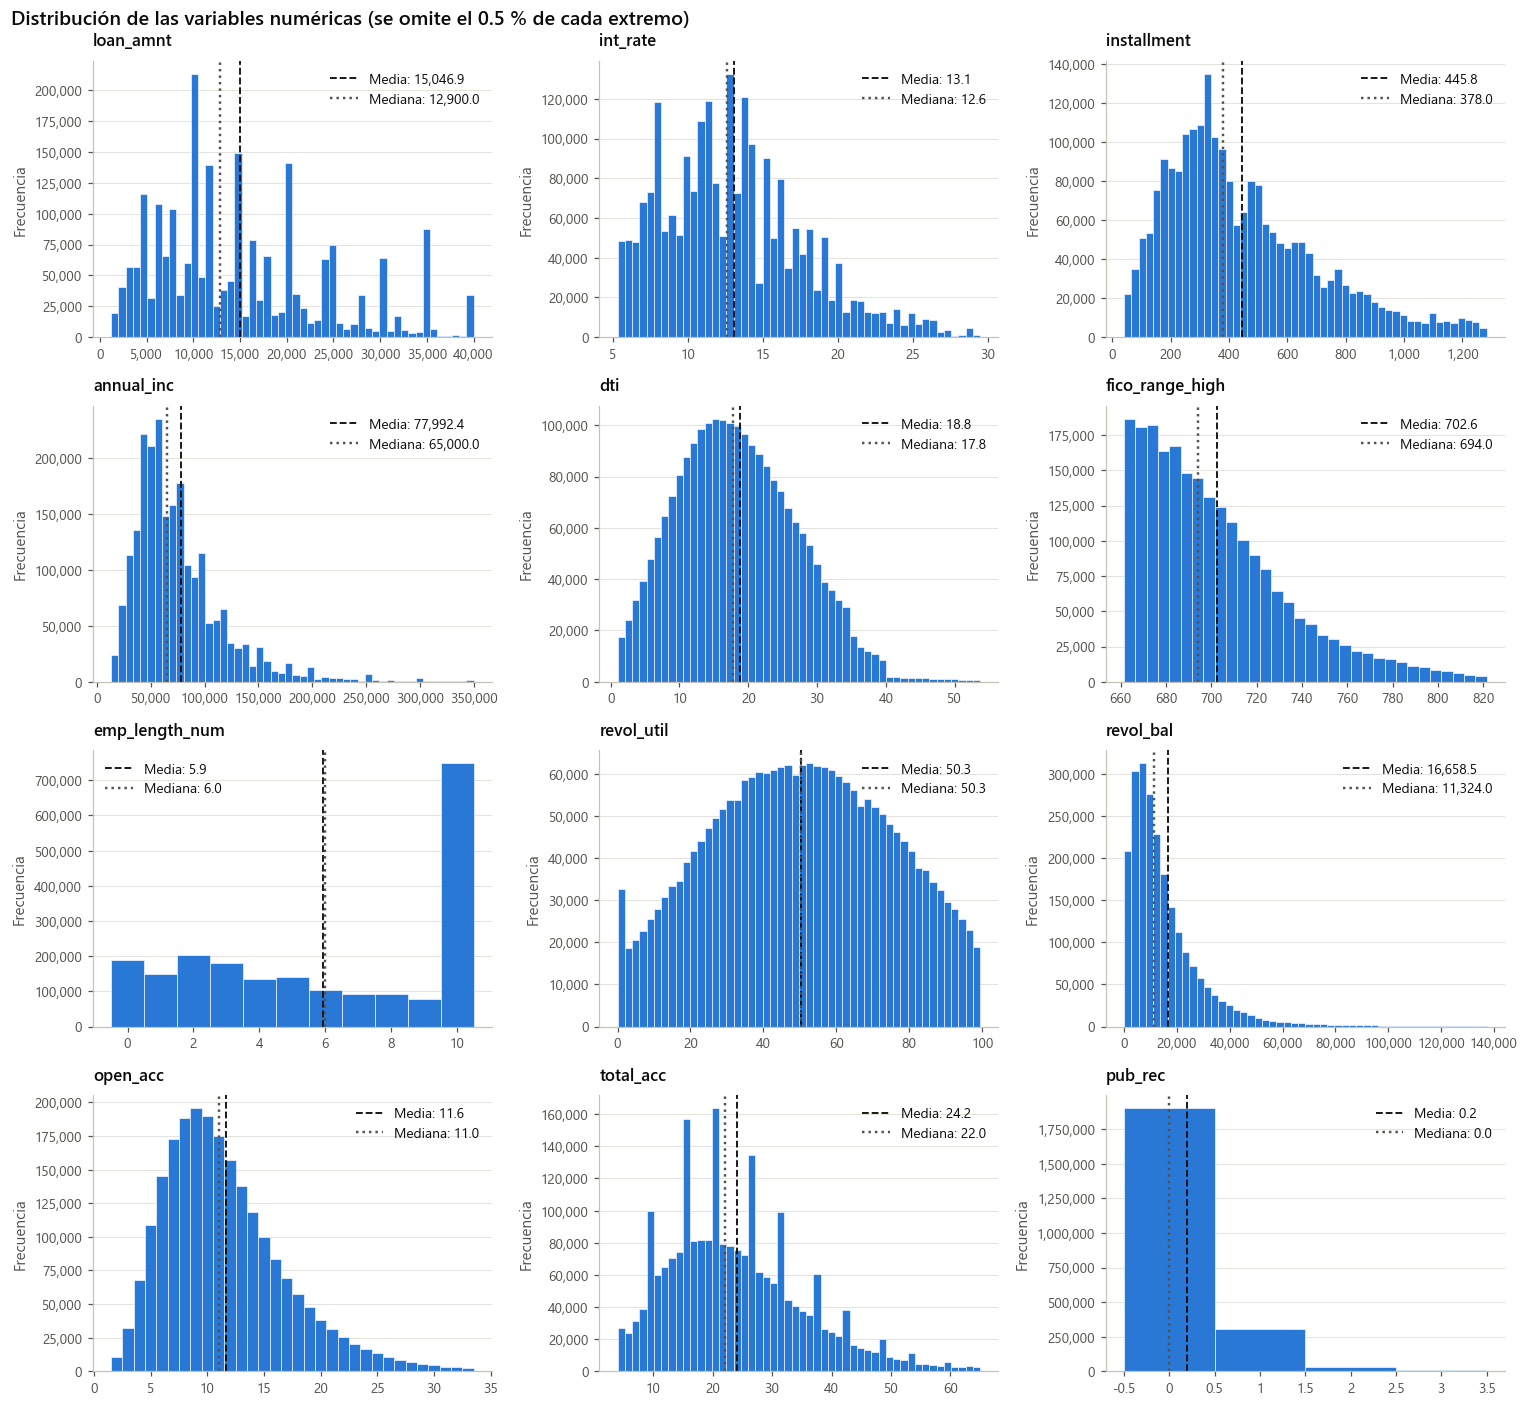

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for ax, col in zip(axes.flat, NUM_VARS):
    s = df[col].dropna()
    lo, hi = s.quantile([0.005, 0.995])
    s_vis = s[(s >= lo) & (s <= hi)]

    unicos = np.unique(s_vis)
    if len(unicos) <= 60:                      # variable discreta: una barra por valor
        paso = np.diff(unicos).min()
        bins = np.arange(unicos[0] - paso / 2, unicos[-1] + paso, paso)
    else:
        bins = 50

    ax.hist(s_vis, bins=bins, color=COLOR["principal"], edgecolor="white", linewidth=0.4)
    ax.axvline(s.mean(), color=COLOR["texto"], linestyle="--", linewidth=1.2,
               label=f"Media: {s.mean():,.1f}")
    ax.axvline(s.median(), color=COLOR["texto_2"], linestyle=":", linewidth=1.6,
               label=f"Mediana: {s.median():,.1f}")
    ax.set_title(col)
    ax.set_ylabel("Frecuencia")
    ax.yaxis.set_major_formatter(fmt_miles)
    ax.xaxis.set_major_formatter(fmt_miles)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="best")

fig.suptitle("Distribución de las variables numéricas (se omite el 0.5 % de cada extremo)",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_histogramas.png")
plt.show()


Se observa que: 

Los montos más solicitados son 10,000 USD (8.3 % de los préstamos), 20,000 USD (5.8 %) y 15,000 USD (5.5 %): predominan los montos redondos. El máximo permitido es 40,000 USD.


La mayor parte de los créditos tienen tasas entre el 7% y el 15%. 

La cuota preferida es de alrededor de 370 dólares. 

Más del 90% de las personas que solicitan ganan entre 20.000 y 150.000 dólares al año.

Más del 50% de las personas tienen cupo usado de sus tarjetas entre 30 y 70%. 

Parte 13. Box plots (los que tienen asimetría mayor a 3 se muestran en escala log porque si no quedaría aplastada)

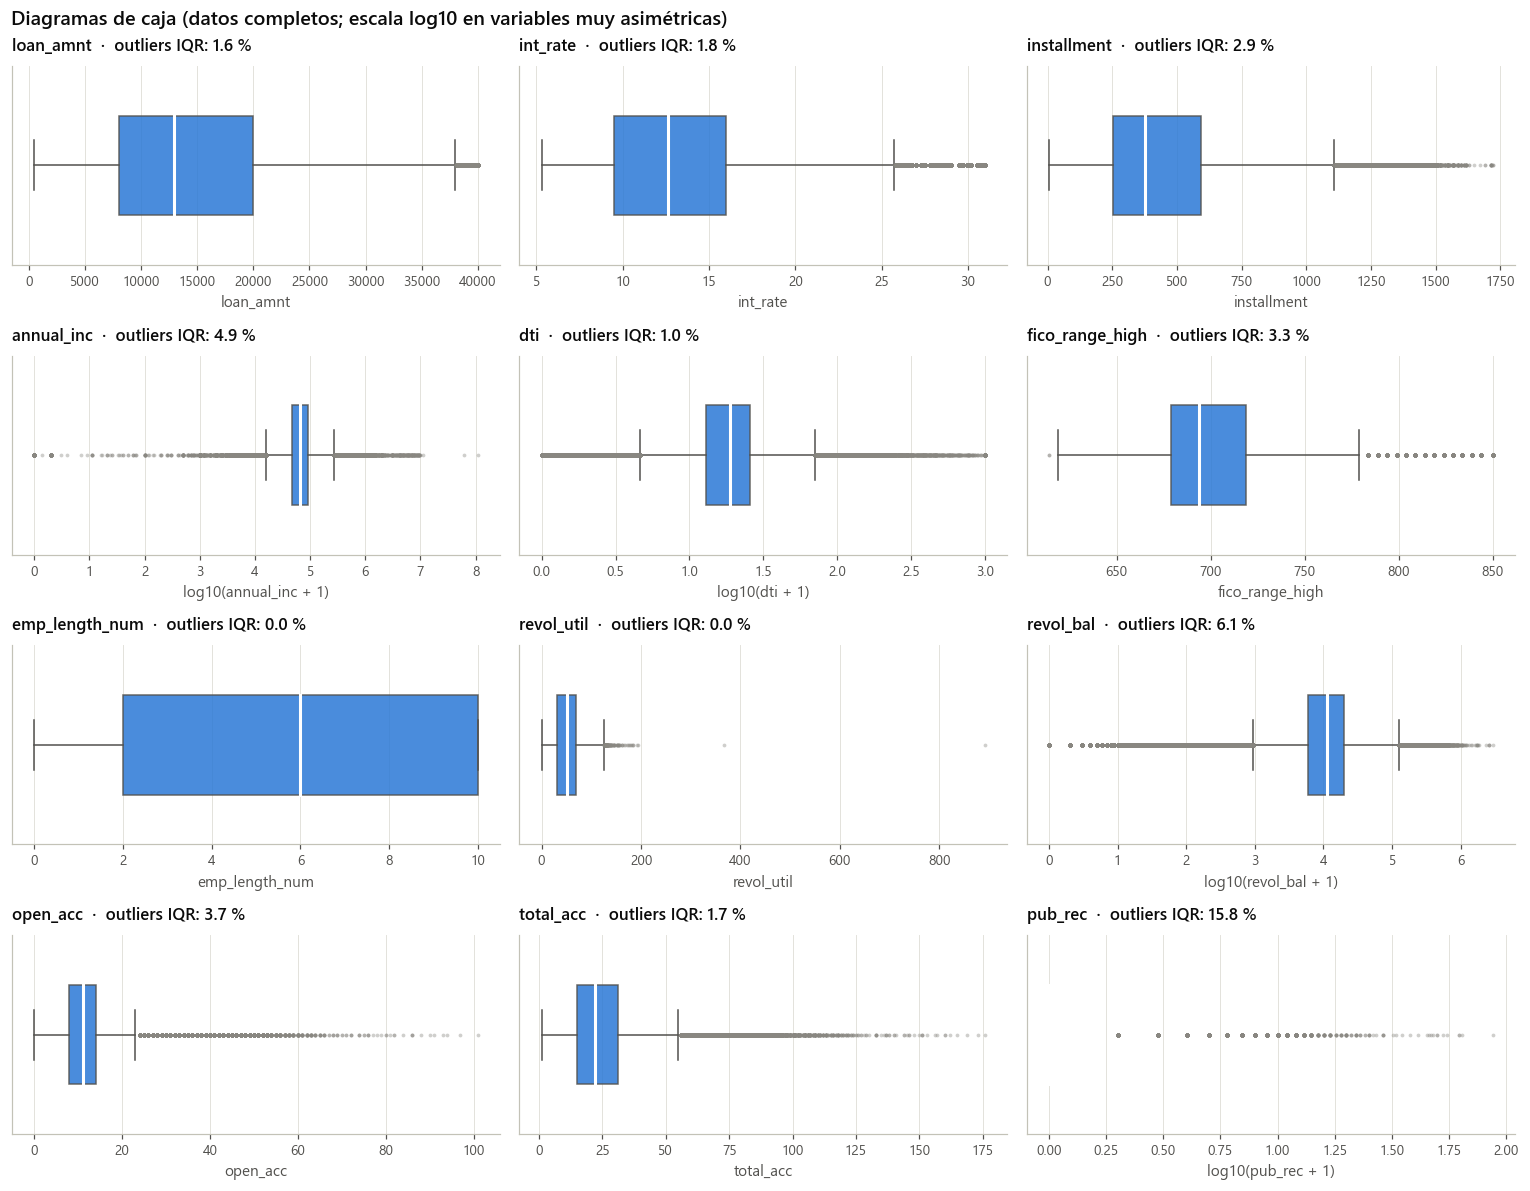

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, NUM_VARS):
    s = df[col].dropna().astype("float64")
    usar_log = resumen_num.loc[col, "asimetria"] > 3
    valores = np.log10(s.clip(lower=0) + 1) if usar_log else s

    ax.boxplot(valores, vert=False, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=COLOR["principal"], edgecolor=COLOR["texto_2"], alpha=0.85),
               medianprops=dict(color="white", linewidth=2),
               whiskerprops=dict(color=COLOR["texto_2"]),
               capprops=dict(color=COLOR["texto_2"]),
               flierprops=dict(marker="o", markersize=2.5, markerfacecolor=COLOR["tenue"],
                               markeredgecolor="none", alpha=0.4))
    for linea in ax.lines:
        linea.set_rasterized(True)             # evita archivos pesados con miles de puntos

    ax.set_yticks([])
    ax.grid(axis="y", visible=False)
    ax.set_title(f"{col}  ·  outliers IQR: {resumen_num.loc[col, 'pct_outliers']:.1f} %")
    ax.set_xlabel(f"log10({col} + 1)" if usar_log else col)

fig.suptitle("Diagramas de caja (datos completos; escala log10 en variables muy asimétricas)",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_boxplots.png")
plt.show()

La mayor proporción de outliers está en `pub_rec` (registros públicos negativos). Esto ocurre porque casi todos los valores son 0 (Q1 = Q3 = 0), así que el método IQR marca como outlier cualquier registro ≥ 1; en realidad indica que la mayoría de los solicitantes no tiene antecedentes negativos. En `loan_amnt` se confirma que el 50 % central de los préstamos está entre 8,000 y 20,000 USD. La cuota mensual (`installment`) tiene una mediana de 378 USD y una media de 446 USD, coherente con el histograma. `annual_inc`, `dti` y `revol_bal` muestran outliers extremos incluso en escala logarítmica.


Parte 14. Normalidad y transformaciones (Shapiro-Wilk solo admite hasta 5,000 datos, así que se usa la prueba de D'Agostino-Pearson, `stats.normaltest`, con los datos completos)


In [19]:
def recomendar_transformacion(asim, minimo):
    if abs(asim) < 0.5:
        return "Aprox. simétrica: no requiere"
    if abs(asim) < 1:
        return "Asimetría moderada: opcional"
    if minimo > 0:
        return "Asimetría fuerte: log o Box-Cox"
    return "Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)"

filas = []
for col in resumen_num.index:                     # todas las variables numéricas (Parte 10)
    s = df[col].dropna().astype("float64")
    fila = {"variable": col, "clave": "✓" if col in NUM_VARS else "", "n": len(s),
            "asimetria": resumen_num.loc[col, "asimetria"], "curtosis": resumen_num.loc[col, "curtosis"]}
    if s.nunique() < 2 or len(s) < 20:            # constantes o casi vacías: la prueba no aplica
        fila.update({"K2_DAgostino": np.nan, "p_value": np.nan, "¿normal? (p > 0.05)": "—",
                     "recomendación": "Constante o casi vacía: no aplica"})
    else:
        k2, p = stats.normaltest(s)               # D'Agostino-Pearson con los datos completos
        fila.update({"K2_DAgostino": k2, "p_value": p, "¿normal? (p > 0.05)": "Sí" if p > 0.05 else "No",
                     "recomendación": recomendar_transformacion(fila["asimetria"], s.min())})
    filas.append(fila)

normalidad = (pd.DataFrame(filas).set_index("variable")
              .sort_values("asimetria", key=lambda x: x.abs(), ascending=False))

print(f"Variables evaluadas: {len(normalidad)}")
display(normalidad["recomendación"].value_counts().to_frame("n_variables"))
display(normalidad.style.format({"n": "{:,}", "asimetria": "{:.2f}", "curtosis": "{:.2f}",
                                 "K2_DAgostino": "{:,.0f}", "p_value": "{:.2e}"}, na_rep="—"))




Variables evaluadas: 113


,n_variables
recomendación,
Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos),73
Aprox. simétrica: no requiere,19
Asimetría fuerte: log o Box-Cox,11
Asimetría moderada: opcional,7
Constante o casi vacía: no aplica,3


,clave,n,asimetria,curtosis,K2_DAgostino,p_value,¿normal? (p > 0.05),recomendación
variable,,,,,,,,
tot_coll_amt,,"2,190,392",852.01,803765.25,"15,644,917",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
annual_inc,✓,"2,260,664",493.89,439001.66,"14,119,774",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
delinq_amnt,,"2,260,639",102.65,16006.00,"9,052,276",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
num_tl_120dpd_2m,,"2,107,011",55.81,5541.59,"6,897,664",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
total_rev_hi_lim,,"2,190,392",32.56,7520.93,"5,967,927",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
tax_liens,,"2,260,563",32.07,3476.33,"6,079,601",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
dti,✓,"2,258,957",29.20,1755.26,"5,820,891",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
acc_now_delinq,,"2,260,639",22.91,1256.70,"5,290,274",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)
num_tl_30dpd,,"2,190,392",22.52,622.43,"5,022,875",0.00e+00,No,Asimetría fuerte: log1p o Yeo-Johnson (hay ceros o negativos)


Se evaluó la normalidad de las 113 variables numéricas con la prueba de D'Agostino-Pearson sobre los datos completos. Ninguna es normal (p ≈ 0 en las 110 evaluables). Con más de 2 millones de observaciones, la prueba detecta hasta la desviación más pequeña, así que la decisión de transformar se basa en la asimetría.

84 variables tienen asimetría fuerte (|asimetría| ≥ 1). Las más extremas son tot_coll_amt (852), annual_inc (494), delinq_amnt (103) y dti (29). Como la mayoría contiene ceros (conteos y montos), se recomienda log1p o Yeo-Johnson; Box-Cox solo aplica a las 11 estrictamente positivas.
19 variables son aproximadamente simétricas y no requieren transformación, entre ellas revol_util, bc_util, emp_length_num y mths_since_last_delinq.
La transformación es relevante para los modelos sensibles a la escala y a la forma de la distribución (LogisticRegression, LinearSVC, NaiveBayes); los modelos basados en árboles no la necesitan

Ejemplo del efecto de la transformación log en annual_inc:

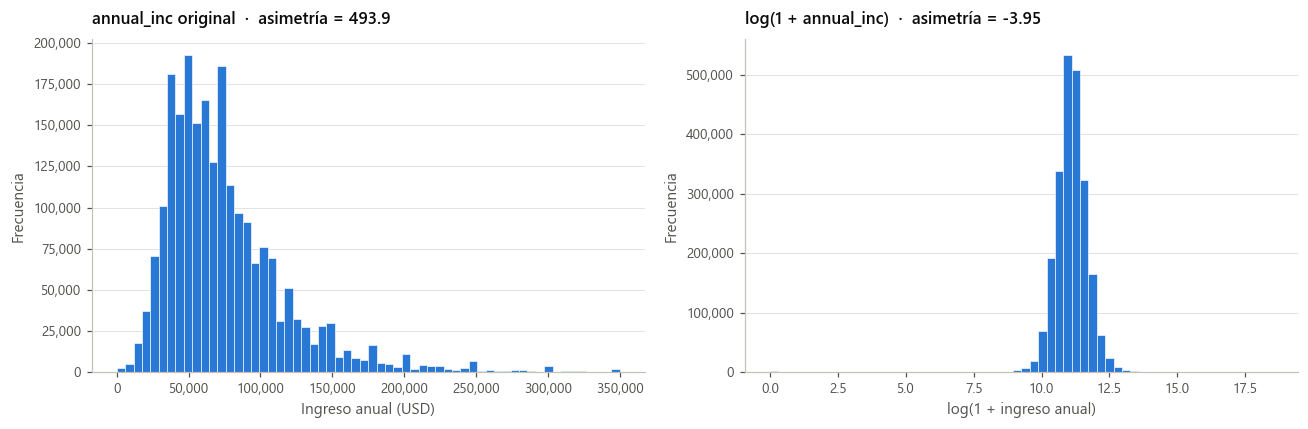

In [20]:
s = df["annual_inc"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(s[s <= s.quantile(0.995)], bins=60, color=COLOR["principal"], edgecolor="white", linewidth=0.4)
axes[0].set_title(f"annual_inc original  ·  asimetría = {s.skew():.1f}")
axes[0].set_xlabel("Ingreso anual (USD)")
axes[0].xaxis.set_major_formatter(fmt_miles)

axes[1].hist(np.log1p(s), bins=60, color=COLOR["principal"], edgecolor="white", linewidth=0.4)
axes[1].set_title(f"log(1 + annual_inc)  ·  asimetría = {np.log1p(s).skew():.2f}")
axes[1].set_xlabel("log(1 + ingreso anual)")

for ax in axes:
    ax.set_ylabel("Frecuencia")
    ax.yaxis.set_major_formatter(fmt_miles)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_transformacion_log.png")
plt.show()

Parte 15. Tasa de faltantes y umbral del 30%

In [21]:
UMBRAL_NULOS = 30   # %

faltantes = pd.DataFrame({
    "tipo": np.where(df.dtypes.apply(pd.api.types.is_numeric_dtype), "numérica", "categórica"),
    "nulos": df.isna().sum(),
    "pct_nulos": df.isna().mean() * 100,
}).sort_values("pct_nulos", ascending=False)

def decision_nulos(pct):
    if pct == 0:
        return "Sin nulos"
    if pct <= 5:
        return "Imputación simple"
    if pct <= UMBRAL_NULOS:
        return "Imputación (evaluar)"
    return "Eliminar o imputación avanzada"

faltantes["decision"] = faltantes["pct_nulos"].apply(decision_nulos)

display(faltantes["decision"].value_counts().to_frame("n_variables"))
print(f"\nVariables por encima del umbral de {UMBRAL_NULOS} %:")
display(faltantes.query("pct_nulos > @UMBRAL_NULOS").style.format({"nulos": "{:,}", "pct_nulos": "{:.2f}"}))


,n_variables
decision,
Eliminar o imputación avanzada,58
Imputación simple,50
Sin nulos,38
Imputación (evaluar),6



Variables por encima del umbral de 30 %:


,tipo,nulos,pct_nulos,decision
member_id,numérica,"2,260,668",100.00,Eliminar o imputación avanzada
orig_projected_additional_accrued_interest,numérica,"2,252,017",99.62,Eliminar o imputación avanzada
hardship_type,categórica,"2,249,751",99.52,Eliminar o imputación avanzada
hardship_loan_status,categórica,"2,249,751",99.52,Eliminar o imputación avanzada
hardship_reason,categórica,"2,249,751",99.52,Eliminar o imputación avanzada
deferral_term,numérica,"2,249,751",99.52,Eliminar o imputación avanzada
hardship_amount,numérica,"2,249,751",99.52,Eliminar o imputación avanzada
hardship_start_date,categórica,"2,249,751",99.52,Eliminar o imputación avanzada
hardship_end_date,categórica,"2,249,751",99.52,Eliminar o imputación avanzada
payment_plan_start_date,categórica,"2,249,751",99.52,Eliminar o imputación avanzada


Las variables con más de 30 % de nulos no se imputan de forma simple. La decisión final (Parte 38) es: más de 70 % → eliminar; entre 30 % y 70 % → imputar con la mediana y agregar un indicador de faltante. En las numéricas se usa la mediana y no la moda, por la asimetría (Parte 14).

Gráfica resumen

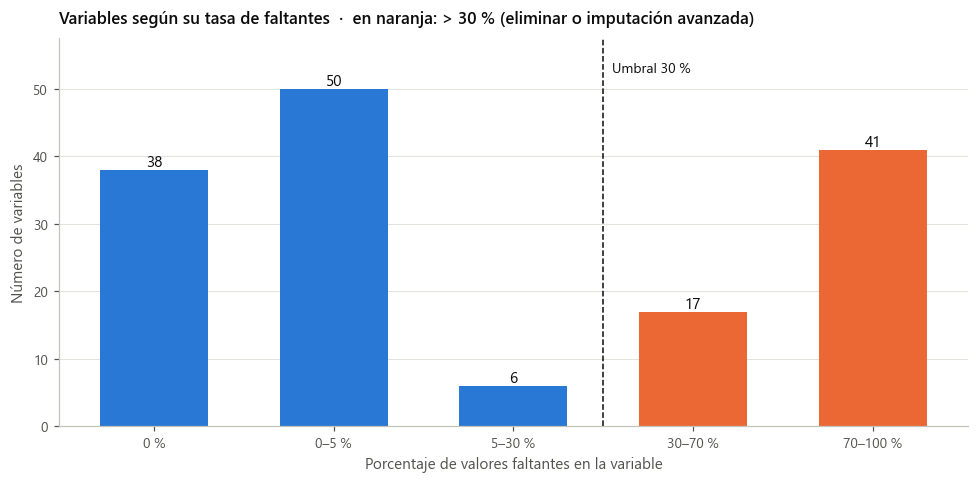

In [22]:
tramos = pd.cut(faltantes["pct_nulos"], bins=[-0.001, 0, 5, UMBRAL_NULOS, 70, 100],
                labels=["0 %", "0–5 %", f"5–{UMBRAL_NULOS} %", f"{UMBRAL_NULOS}–70 %", "70–100 %"])
conteo = tramos.value_counts().sort_index()
colores = [COLOR["principal"]] * 3 + [COLOR["secundario"]] * 2

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar(conteo.index.astype(str), conteo.values, color=colores, width=0.6)
for barra, v in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width() / 2, v, f"{v}",
            ha="center", va="bottom", fontsize=10, color=COLOR["texto"])
ax.axvline(2.5, color=COLOR["texto"], linestyle="--", linewidth=1)
ax.text(2.55, conteo.max() * 1.05, f"Umbral {UMBRAL_NULOS} %", fontsize=9, color=COLOR["texto"])
ax.set_ylim(0, conteo.max() * 1.15)
ax.set_xlabel("Porcentaje de valores faltantes en la variable")
ax.set_ylabel("Número de variables")
ax.grid(axis="x", visible=False)
ax.set_title(f"Variables según su tasa de faltantes  ·  en naranja: > {UMBRAL_NULOS} % (eliminar o imputación avanzada)")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_faltantes.png")
plt.show()


B. Variables categóricas

Parte 16. Frecuencia absoluta y relativa

In [23]:
CAT_VARS = ["purpose", "home_ownership", "addr_state", "verification_status",
            "grade", "term", "emp_length", "application_type"]
UMBRAL_RARA = 1   # %

# --- 1) Clasificación y resumen de TODAS las columnas no numéricas ---
cols_categoricas = [c for c in df.select_dtypes(include=["category", "object"]).columns if c != "id"]
COLS_FECHA = [c for c in cols_categoricas if c.endswith("_d") or "date" in c or "earliest_cr_line" in c]
COLS_TEXTO = ["url", "desc", "title", "emp_title", "zip_code"]

def tipo_categorica(col):
    if col in COLS_FECHA:
        return "Fecha (mes-año)"
    if col in COLS_TEXTO:
        return "Texto libre o código"
    return "Categórica"

filas = []
for col in cols_categoricas:
    vc = df[col].value_counts(dropna=True)
    pct = vc / len(df) * 100
    filas.append({
        "variable": col,
        "tipo": tipo_categorica(col),
        "clave": "✓" if col in CAT_VARS else "",
        "n_categorias": len(vc),
        "categoria_mas_frecuente": str(vc.index[0]) if len(vc) else "—",
        "pct_mas_frecuente": pct.iloc[0] if len(vc) else np.nan,
        "n_bajo_1pct": int((pct < UMBRAL_RARA).sum()),
        "pct_nulos": df[col].isna().mean() * 100,
    })
resumen_cat = pd.DataFrame(filas).set_index("variable").sort_values(["tipo", "n_categorias"])

display(resumen_cat["tipo"].value_counts().to_frame("n_columnas"))
display(resumen_cat.style.format({"pct_mas_frecuente": "{:.2f} %", "pct_nulos": "{:.2f} %"}))

# --- 2) Frecuencia absoluta y relativa de TODAS las categóricas ---
CAT_TODAS = resumen_cat.index[resumen_cat["tipo"] == "Categórica"].tolist()

def tabla_frecuencias(data, col):
    abs_ = data[col].value_counts(dropna=False)
    tabla = pd.DataFrame({"frecuencia": abs_, "porcentaje": abs_ / len(data) * 100})
    tabla.index = [("(faltante)" if pd.isna(i) else str(i)) for i in tabla.index]
    tabla.index.name = col
    tabla["baja_frecuencia"] = np.where(tabla["porcentaje"] < UMBRAL_RARA, "Sí", "")
    return tabla

frecuencias = {col: tabla_frecuencias(df, col) for col in CAT_TODAS}

for col in CAT_TODAS:
    marca = "  ← variable clave" if col in CAT_VARS else ""
    print(f"\n{col}  ({df[col].nunique()} categorías){marca}")
    display(frecuencias[col].style.format({"frecuencia": "{:,}", "porcentaje": "{:.2f} %"}))



,n_columnas
tipo,
Categórica,21
Fecha (mes-año),11
Texto libre o código,5


,tipo,clave,n_categorias,categoria_mas_frecuente,pct_mas_frecuente,n_bajo_1pct,pct_nulos
variable,,,,,,,
hardship_type,Categórica,,1,INTEREST ONLY-3 MONTHS DEFERRAL,0.48 %,1,99.52 %
term,Categórica,✓,2,36 months,71.21 %,0,0.00 %
pymnt_plan,Categórica,,2,n,99.97 %,1,0.00 %
initial_list_status,Categórica,,2,w,67.92 %,0,0.00 %
application_type,Categórica,✓,2,Individual,94.66 %,0,0.00 %
hardship_flag,Categórica,,2,N,99.96 %,1,0.00 %
disbursement_method,Categórica,,2,Cash,96.54 %,0,0.00 %
debt_settlement_flag,Categórica,,2,N,98.49 %,0,0.00 %
verification_status,Categórica,✓,3,Source Verified,39.20 %,0,0.00 %



hardship_type  (1 categorías)


,frecuencia,porcentaje,baja_frecuencia
hardship_type,,,
(faltante),"2,249,751",99.52 %,
INTEREST ONLY-3 MONTHS DEFERRAL,"10,917",0.48 %,Sí



term  (2 categorías)  ← variable clave


...

,frecuencia,porcentaje,baja_frecuencia
purpose,,,
debt_consolidation,"1,277,877",56.53 %,
credit_card,"516,971",22.87 %,
home_improvement,"150,457",6.66 %,
other,"139,440",6.17 %,
major_purchase,"50,445",2.23 %,
medical,"27,488",1.22 %,
small_business,"24,689",1.09 %,
car,"24,013",1.06 %,
vacation,"15,525",0.69 %,Sí



sub_grade  (35 categorías)


,frecuencia,porcentaje,baja_frecuencia
sub_grade,,,
C1,"145,903",6.45 %,
B5,"140,288",6.21 %,
B4,"139,793",6.18 %,
B3,"131,514",5.82 %,
C2,"131,116",5.80 %,
C3,"129,193",5.71 %,
C4,"127,115",5.62 %,
B2,"126,621",5.60 %,
B1,"125,341",5.54 %,



addr_state  (51 categorías)  ← variable clave


,frecuencia,porcentaje,baja_frecuencia
addr_state,,,
CA,"314,533",13.91 %,
NY,"186,389",8.24 %,
TX,"186,335",8.24 %,
FL,"161,991",7.17 %,
IL,"91,173",4.03 %,
NJ,"83,132",3.68 %,
PA,"76,939",3.40 %,
OH,"75,132",3.32 %,
GA,"74,196",3.28 %,


Se definió un umbral de rara de 1%. Hay que agrupar varias clases. 

De las 37 columnas no numéricas:

21 son categóricas y se analizan con tablas de frecuencia.
11 son fechas en formato mes-año (issue_d, earliest_cr_line, last_pymnt_d…). Las fechas no se tratan como categorías: en el preprocesamiento se convertirán en variables numéricas, como el año de emisión o la antigüedad del historial crediticio (issue_d − earliest_cr_line). Las fechas posteriores al otorgamiento se eliminarán por fuga.
5 son texto libre o códigos (url, desc, title, emp_title, zip_code), con miles o millones de valores distintos (url es única por préstamo), así que no admiten análisis de frecuencias.
Entre las categóricas hay varias casi constantes: pymnt_plan ("n" en 99.97 %), hardship_flag (99.96 %) y disbursement_method (96.5 %), que aportan poca información. Las hardship_* y settlement_* tienen más del 98 % de nulos y son posteriores al préstamo.

Parte 17. Categorías con menos del 1%

In [24]:
resumen_raras = pd.DataFrame({
    col: {
        "n_categorias": len(t),
        "n_bajo_1pct": (t["baja_frecuencia"] == "Sí").sum(),
        "pct_filas_afectadas": round(t.loc[t["baja_frecuencia"] == "Sí", "porcentaje"].sum(), 2),
        "categorias_raras": ", ".join(t.index[t["baja_frecuencia"] == "Sí"][:10]),
    } for col, t in frecuencias.items()
}).T
display(resumen_raras)

def agrupar_raras(serie, umbral=UMBRAL_RARA, etiqueta="Otros"):
    pct = serie.value_counts(normalize=True) * 100
    raras = pct[pct < umbral].index
    return serie.astype("object").where(~serie.isin(raras), etiqueta).astype("category")

# Ejemplo: cómo quedaría purpose al agrupar (no se modifica df todavía)
display(agrupar_raras(df["purpose"]).value_counts(normalize=True).mul(100).round(2).to_frame("% tras agrupar"))


,n_categorias,n_bajo_1pct,pct_filas_afectadas,categorias_raras
hardship_type,2,1,0.4800,INTEREST ONLY-3 MONTHS DEFERRAL
term,2,0,0.0000,
pymnt_plan,2,1,0.0300,y
initial_list_status,2,0,0.0000,
application_type,2,0,0.0000,
hardship_flag,2,1,0.0400,Y
disbursement_method,2,0,0.0000,
debt_settlement_flag,2,0,0.0000,
verification_status,3,0,0.0000,
verification_status_joint,4,0,0.0000,


,% tras agrupar
purpose,
debt_consolidation,56.5300
credit_card,22.8700
home_improvement,6.6600
other,6.1700
major_purchase,2.2300
Otros,2.1800
medical,1.2200
small_business,1.0900
car,1.0600


Lo que sale:

purpose: 6 categorías raras (vacation, moving, house, wedding, renewable_energy, educational), que suman 2.2 %.
home_ownership: ANY, OTHER y NONE suman solo 0.05 %.
grade: G tiene 0.5 %, pero no conviene agruparla, porque es ordinal y es el grado de mayor riesgo.
addr_state: 23 estados tienen menos del 1 %; para esta variable es mejor agrupar por región que usar "Otros".

Parte 18. Gráficos de barras

Las variables ordinales (grade, term, emp_length) se muestran en su orden natural; las demás, por frecuencia. En gris aparecen las categorías con menos del 1 %.

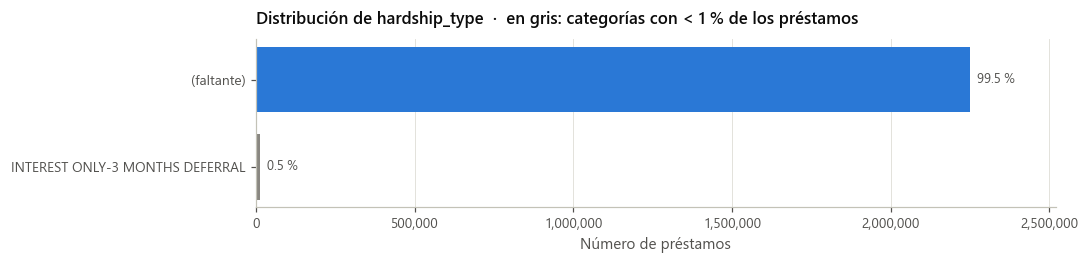

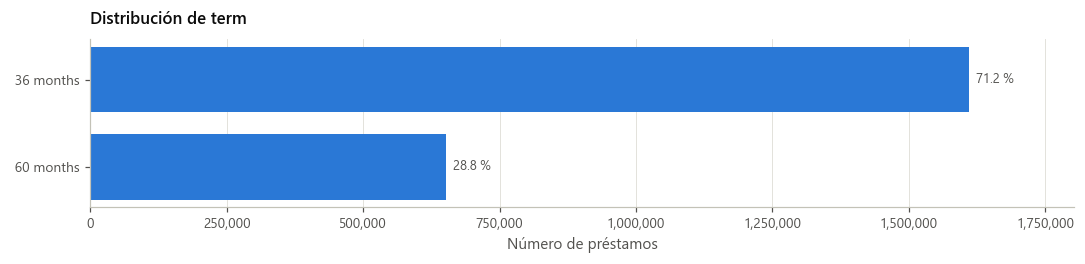

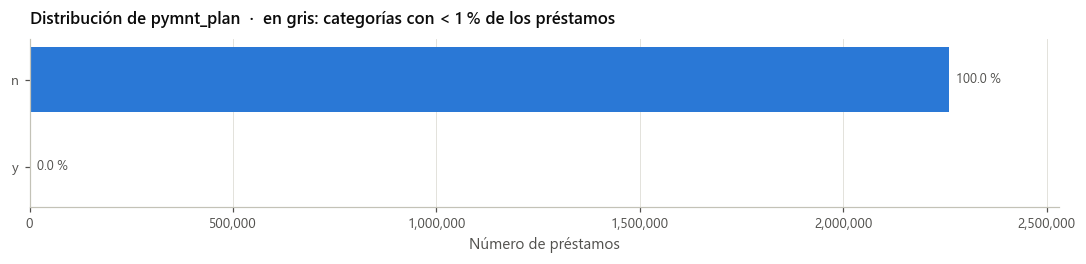

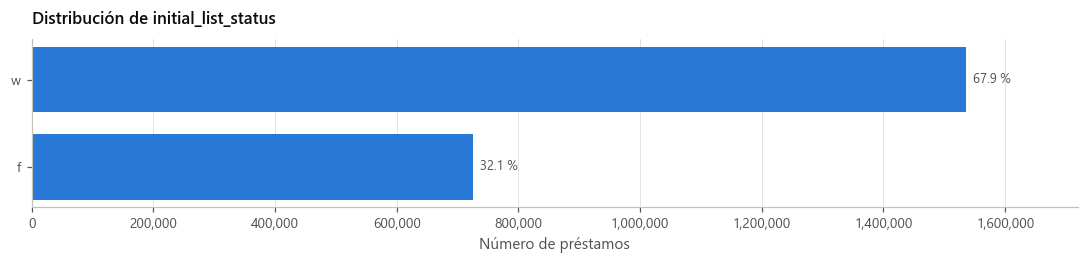

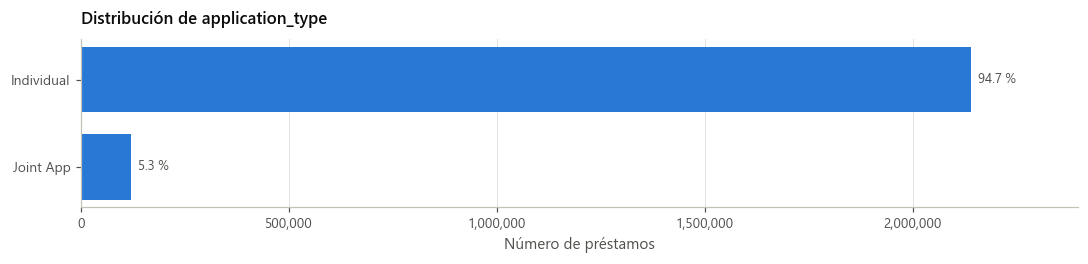

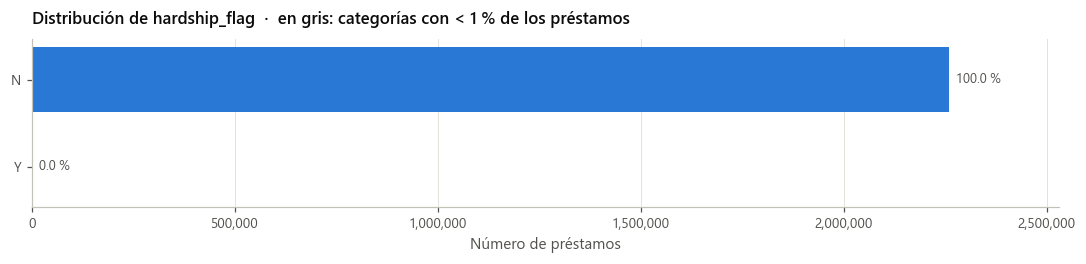

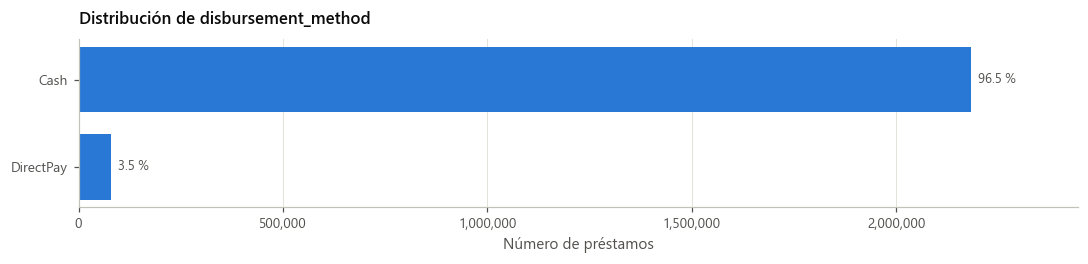

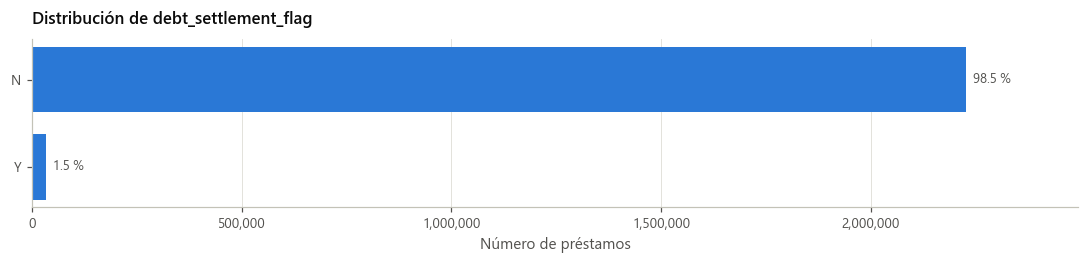

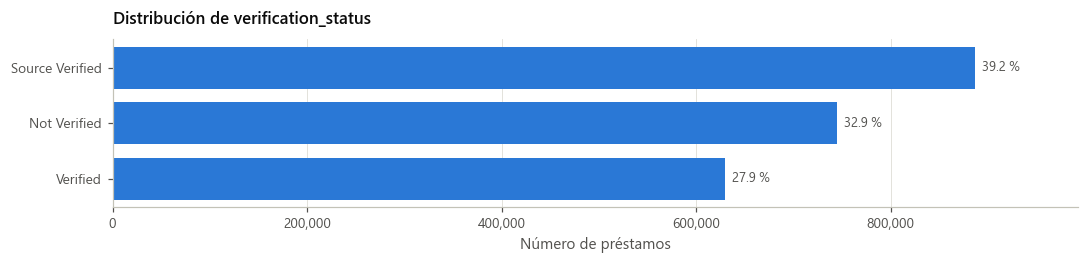

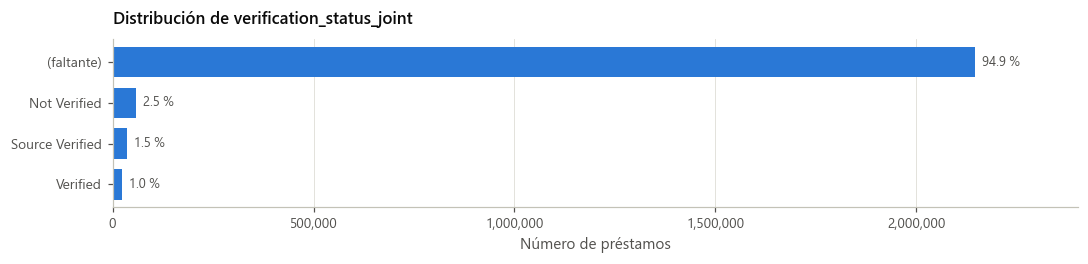

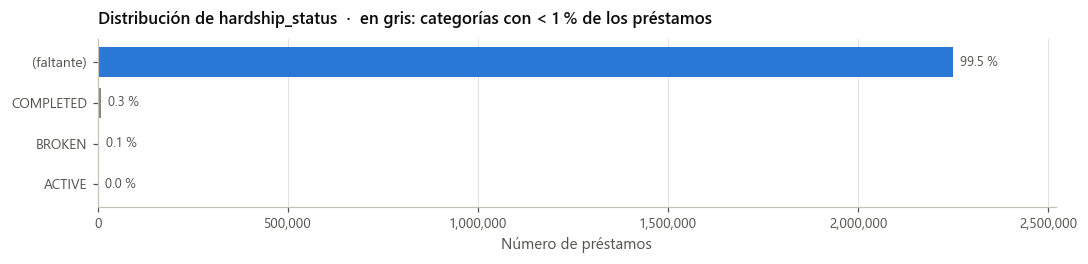

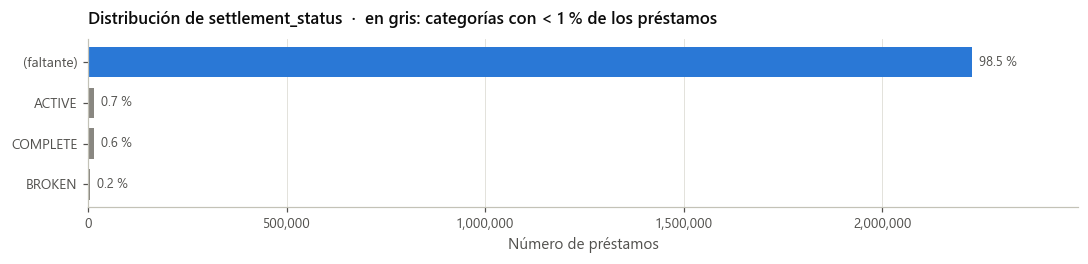

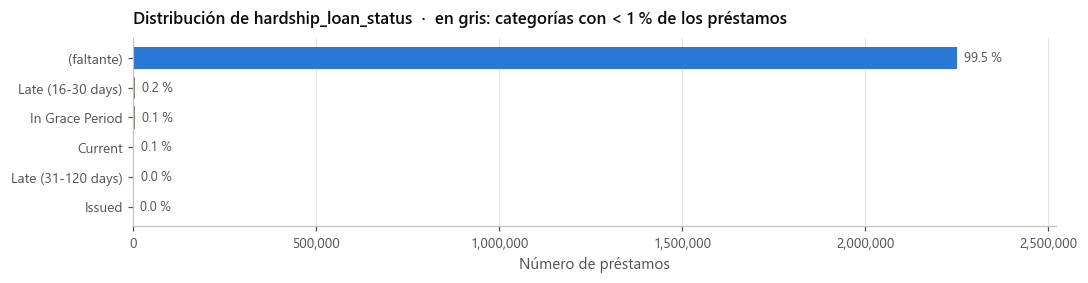

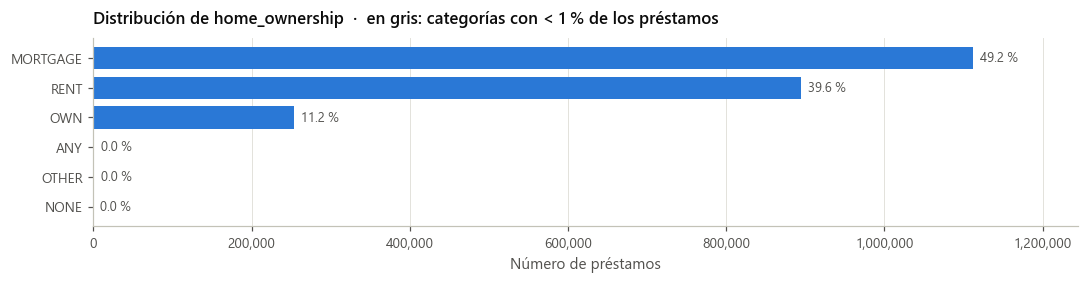

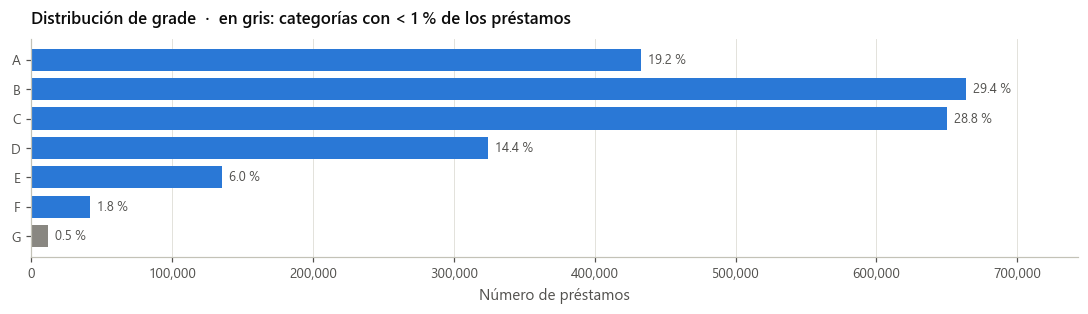

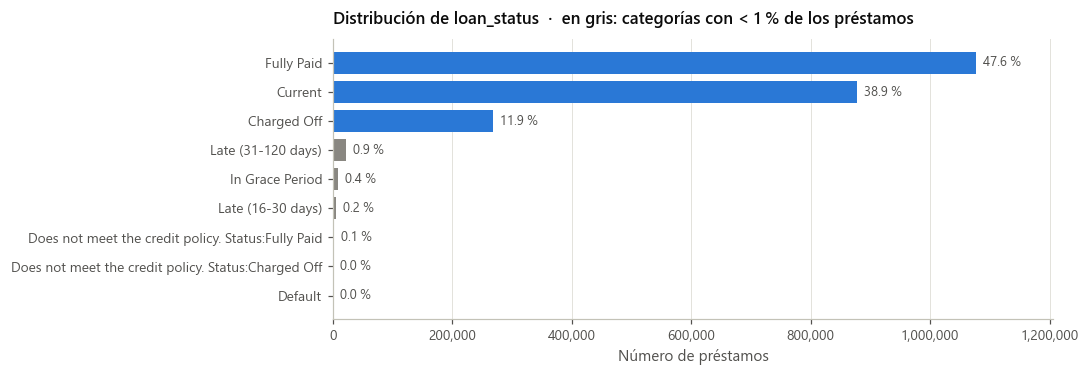

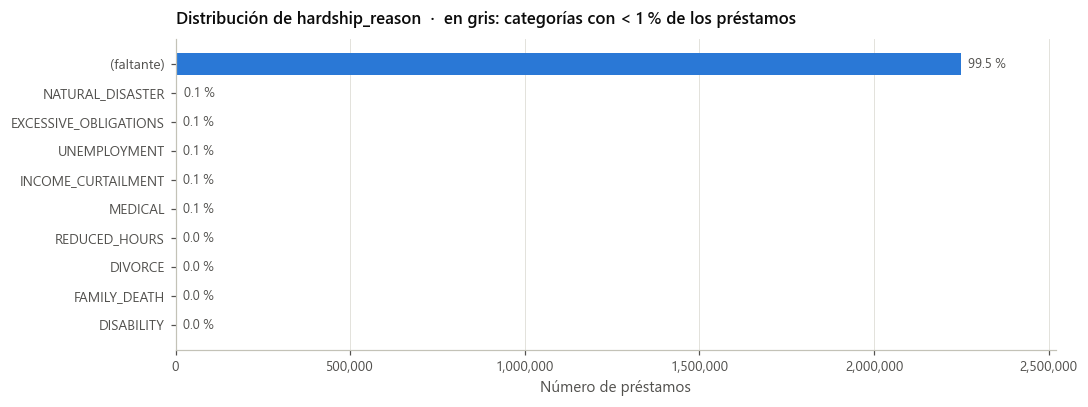

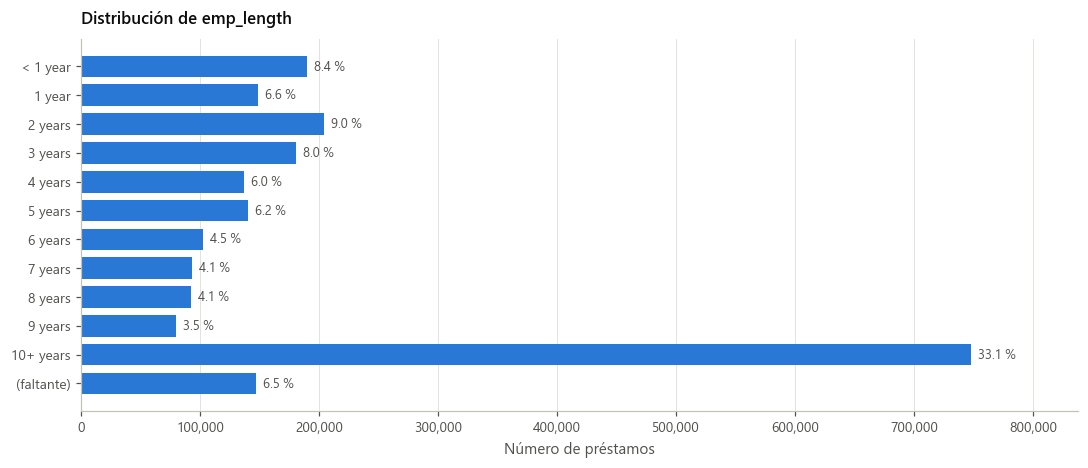

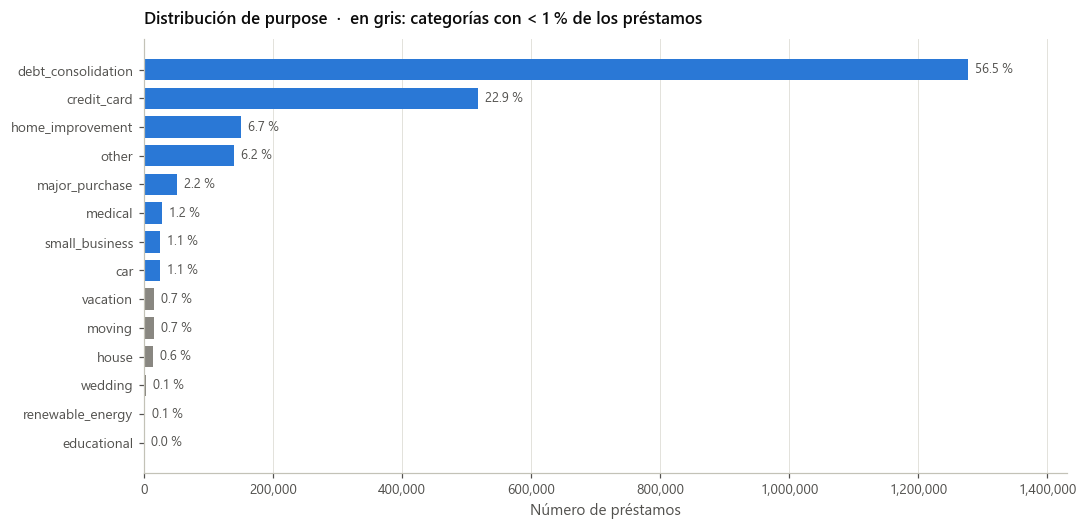

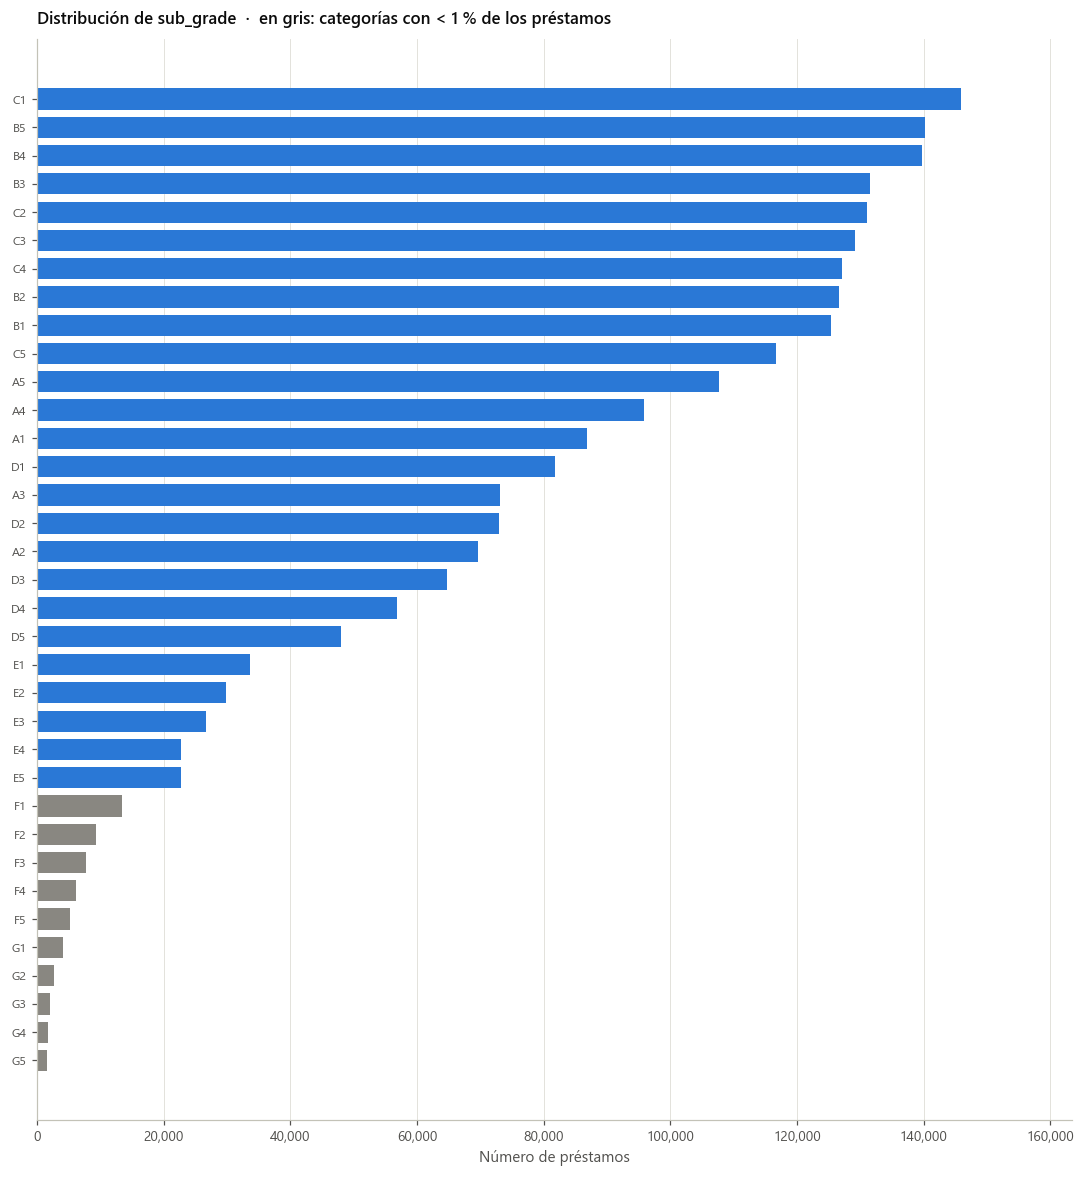

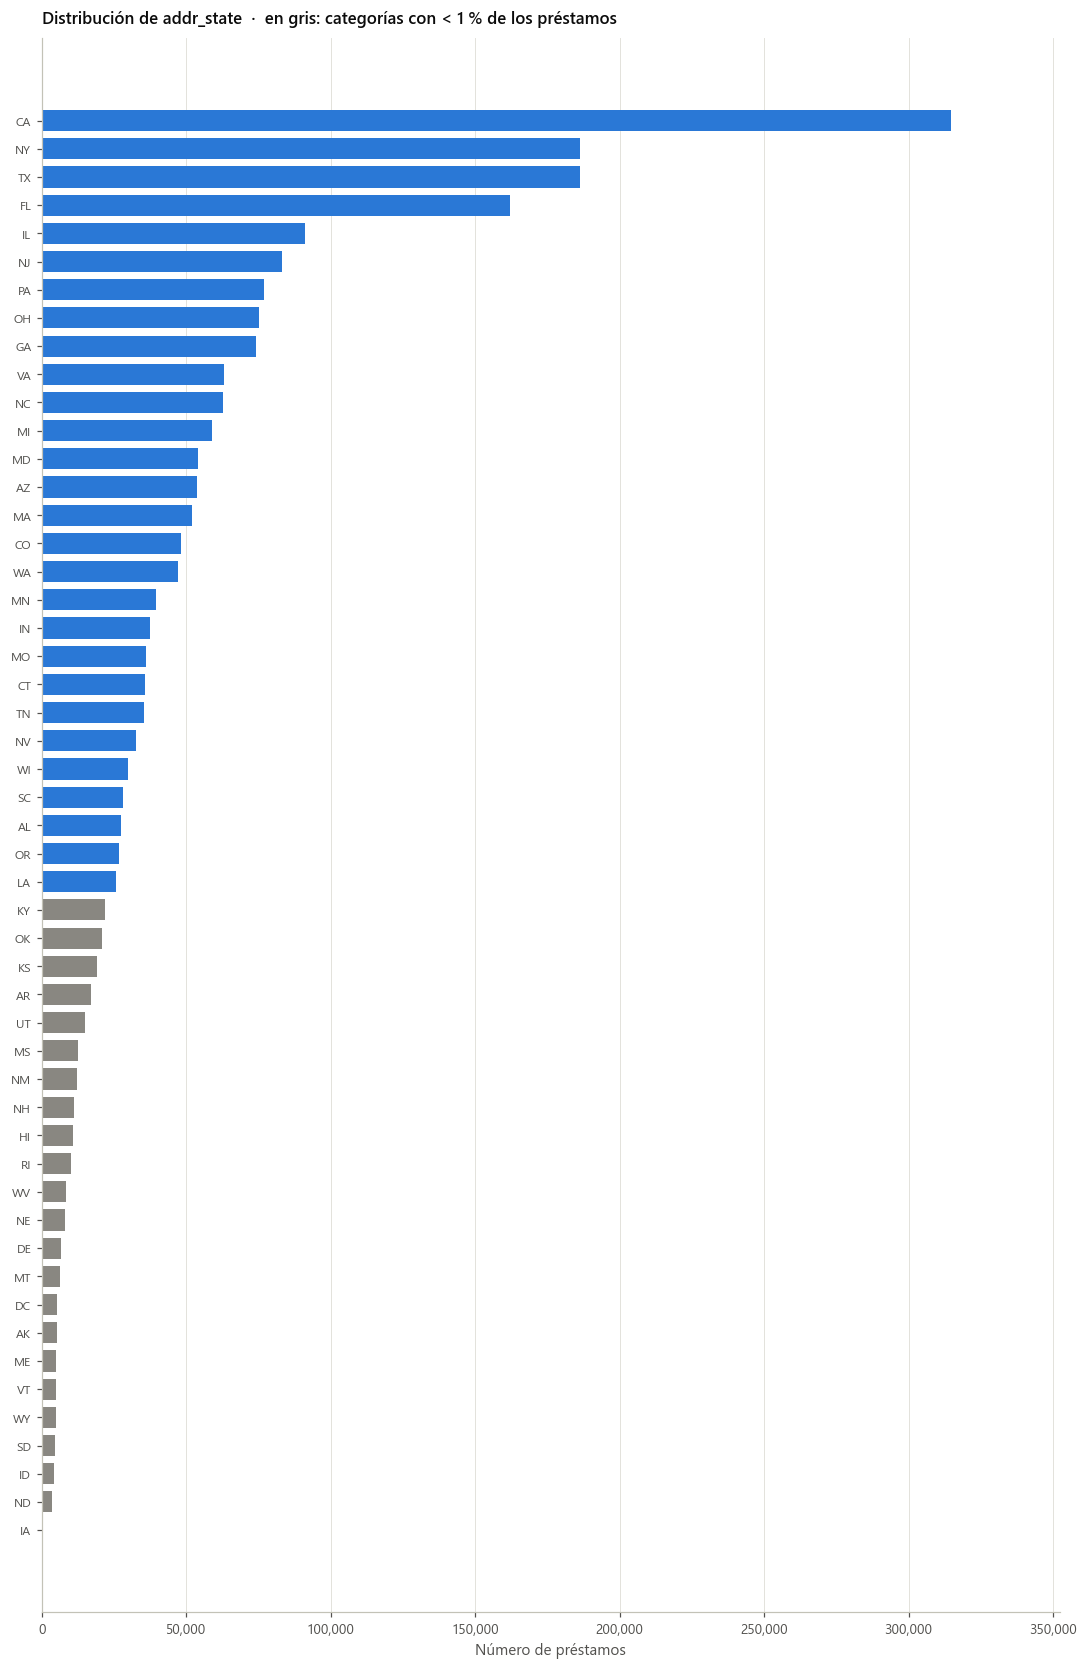

In [25]:
ORDEN = {
    "grade": list("ABCDEFG"),
    "term": [" 36 months", " 60 months"],
    "emp_length": ["< 1 year"] + [f"{i} year{'s' if i > 1 else ''}" for i in range(1, 10)]
                  + ["10+ years", "(faltante)"],
}

for col in CAT_TODAS:
    t = frecuencias[col]
    if col in ORDEN:
        t = t.loc[[c for c in ORDEN[col] if c in t.index][::-1]]
    else:
        t = t.sort_values("frecuencia")
    n = len(t)
    colores = np.where(t["baja_frecuencia"] == "Sí", COLOR["tenue"], COLOR["principal"])

    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.28 * n + 1)))
    ax.barh(t.index, t["frecuencia"], color=colores, height=0.75)
    if n <= 20:
        for i, (f, p) in enumerate(zip(t["frecuencia"], t["porcentaje"])):
            ax.text(f, i, f"  {p:.1f} %", va="center", fontsize=8.5, color=COLOR["texto_2"])
    ax.xaxis.set_major_formatter(fmt_miles)
    ax.set_xlabel("Número de préstamos")
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=8 if n > 20 else 9)
    ax.margins(x=0.12)

    titulo = f"Distribución de {col}"
    if (t["baja_frecuencia"] == "Sí").any():
        titulo += f"  ·  en gris: categorías con < {UMBRAL_RARA} % de los préstamos"
    ax.set_title(titulo)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"02_barras_{col}.png")
    plt.show()

Parte 19. Categorías redundantes

In [26]:
print("home_ownership:", df["home_ownership"].value_counts().to_dict())
print("verification_status:", df["verification_status"].value_counts().to_dict())

print("\nloan_status:")
print(df["loan_status"].value_counts().to_string())

print("\n¿sub_grade empieza siempre por grade?:",
      (df["sub_grade"].astype(str).str[0] == df["grade"].astype(str)).all())
print("Diferencia fico_range_high − fico_range_low:",
      (df["fico_range_high"] - df["fico_range_low"]).value_counts().head(3).to_dict())

emp_title = df["emp_title"].dropna()
print(f"\nemp_title → únicos originales: {emp_title.nunique():,}")
print(f"emp_title → únicos tras minúsculas y sin espacios: {emp_title.str.lower().str.strip().nunique():,}")
print(emp_title[emp_title.str.lower().str.strip() == "teacher"].value_counts().head(5))

print(f"\ntitle: {df['title'].nunique():,} valores únicos  vs  purpose: {df['purpose'].nunique()}")
print(df["title"].value_counts().head(8))


home_ownership: {'MORTGAGE': 1111450, 'RENT': 894929, 'OWN': 253057, 'ANY': 996, 'OTHER': 182, 'NONE': 54}
verification_status: {'Source Verified': 886231, 'Not Verified': 744806, 'Verified': 629631}

loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40

¿sub_grade empieza siempre por grade?: True
Diferencia fico_range_high − fico_range_low: {4.0: 2260227, 5.0: 441}

emp_title → únicos originales: 512,694
emp_title → únicos tras minúsculas y sin espacios: 4

**Hallazgos de la Parte 19 — categorías y variables redundantes**

| Qué se revisó | Qué se encontró | Decisión |
|---|---|---|
| `home_ownership` | MORTGAGE, RENT y OWN suman el 99.95 %; ANY (996), OTHER (182) y NONE (54) son casi nulas | Unificar ANY, OTHER y NONE en **"OTHER"** |
| `verification_status` | Verified, Source Verified y Not Verified | Se mantienen separadas: en la Parte 26 tienen tasas de default distintas (15.9 %, 12.3 % y 8.0 %) |
| `loan_status` | Incluye "Does not meet the credit policy. Status: Fully Paid / Charged Off" (2,749 préstamos) | Se mantienen como en el dataset original, según la regla del enunciado para `default` (Parte 21) |
| `grade` vs `sub_grade` | `sub_grade` empieza siempre por `grade` (100 %) | Usar solo una de las dos en el modelo |
| `fico_range_low` vs `fico_range_high` | Siempre difieren en 4 puntos (441 casos en 5) | Usar solo una |
| `emp_title` | 512,694 valores únicos; 411,810 al normalizar mayúsculas y espacios | Normalizar el texto si se usa |
| `title` vs `purpose` | `title` (63,154 valores) es texto libre que repite `purpose` (14 categorías) | Eliminar `title` |

En resumen, se identificaron categorías casi vacías que conviene unificar y pares de variables que repiten la misma información (`grade`/`sub_grade`, `fico_low`/`fico_high`, `title`/`purpose`). Estas redundancias se confirman numéricamente en las Partes 30 (V de Cramér = 1.00) y 31 (r = 1.00).


Parte 20. Faltantes en las categóricas y tratamiento

In [27]:
cols_cat = df.select_dtypes(include=["category", "object"]).columns
nulos_cat = pd.DataFrame({
    "nulos": df[cols_cat].isna().sum(),
    "pct_nulos": df[cols_cat].isna().mean() * 100,
}).sort_values("pct_nulos", ascending=False)

def tratamiento_categorica(pct):
    if pct == 0:
        return "Sin nulos"
    if pct < 5:
        return "Imputar con la moda"
    if pct <= UMBRAL_NULOS:
        return "Categoría 'Desconocido'"
    return "Eliminar la variable"

nulos_cat["tratamiento"] = nulos_cat["pct_nulos"].apply(tratamiento_categorica)
display(nulos_cat.query("nulos > 0").style.format({"nulos": "{:,}", "pct_nulos": "{:.2f}"}))


,nulos,pct_nulos,tratamiento
hardship_end_date,"2,249,751",99.52,Eliminar la variable
payment_plan_start_date,"2,249,751",99.52,Eliminar la variable
hardship_type,"2,249,751",99.52,Eliminar la variable
hardship_reason,"2,249,751",99.52,Eliminar la variable
hardship_status,"2,249,751",99.52,Eliminar la variable
hardship_start_date,"2,249,751",99.52,Eliminar la variable
hardship_loan_status,"2,249,751",99.52,Eliminar la variable
settlement_date,"2,226,422",98.49,Eliminar la variable
debt_settlement_flag_date,"2,226,422",98.49,Eliminar la variable
settlement_status,"2,226,422",98.49,Eliminar la variable


Esta tabla es preliminar. El tratamiento definitivo está en la Parte 38. Hay tres diferencias: emp_title y title se eliminan (texto libre); last_pymnt_d, next_pymnt_d y last_credit_pull_d se eliminan por fuga; y emp_length usa la categoría "Missing".

C. Variable objetivo

Parte 21. Distribución de "default"

Definición de default. Se aplica la regla del enunciado (9.10.3): default = 1 si loan_status es "Charged Off" y default = 0 en cualquier otro caso, sobre los 2.260.668 préstamos del dataset completo, sin eliminar ninguna fila. Así, la clase 0 incluye los préstamos pagados (Fully Paid) y también los que aún están vigentes o en mora al momento del corte (Current, Late, In Grace Period), cuyo desenlace final todavía no se conoce.

Limitación: una parte de los préstamos vigentes podría caer en default en el futuro, así que la tasa observada (11.88 %) es un límite inferior de la tasa real. Tampoco quedan en la clase 1 los 761 préstamos "Does not meet the credit policy. Status: Charged Off", porque su texto no coincide exactamente con "Charged Off".

In [28]:
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

y = df["default"]
clases = pd.DataFrame({
    "frecuencia": y.value_counts().sort_index(),
    "porcentaje": y.value_counts(normalize=True).sort_index() * 100,
})
clases.index = ["0 = No Charged Off", "1 = Charged Off"]
display(clases.style.format({"frecuencia": "{:,}", "porcentaje": "{:.2f} %"}))

print(f"Préstamos analizados  : {len(y):,}")
print(f"Razón de desbalance   : {clases['frecuencia'].iloc[0] / clases['frecuencia'].iloc[1]:.2f} : 1")
print("\nComposición de la clase 0:")
print(df.loc[y == 0, "loan_status"].value_counts().to_string())


,frecuencia,porcentaje
0 = No Charged Off,"1,992,109",88.12 %
1 = Charged Off,"268,559",11.88 %


Préstamos analizados  : 2,260,668
Razón de desbalance   : 7.42 : 1

Composición de la clase 0:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Charged Off                                                  0


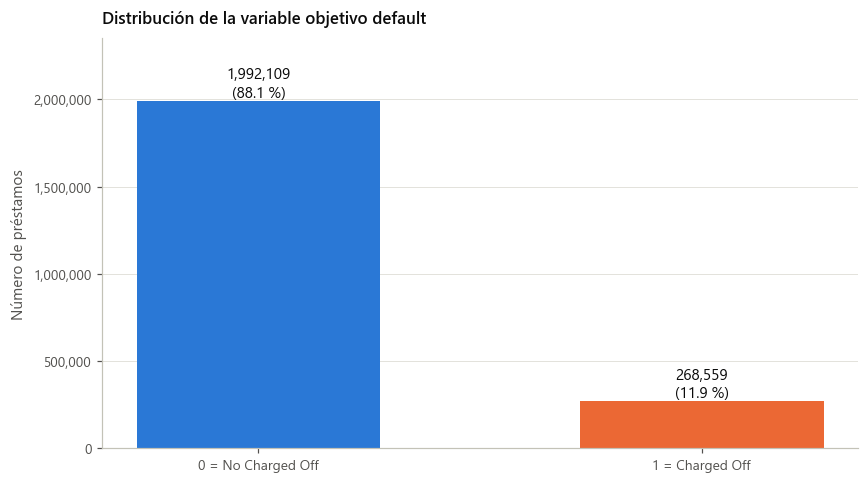

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(clases.index, clases["frecuencia"],
                color=[COLOR["principal"], COLOR["secundario"]], width=0.55)
for barra, f, p in zip(barras, clases["frecuencia"], clases["porcentaje"]):
    ax.text(barra.get_x() + barra.get_width() / 2, f, f"{f:,}\n({p:.1f} %)",
            ha="center", va="bottom", fontsize=10, color=COLOR["texto"])
ax.yaxis.set_major_formatter(fmt_miles)
ax.set_ylabel("Número de préstamos")
ax.set_ylim(0, clases["frecuencia"].max() * 1.18)
ax.grid(axis="x", visible=False)
ax.set_title("Distribución de la variable objetivo default")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_variable_objetivo.png")
plt.show()


Lo que sale: 1,992,109 préstamos sin Charged Off (88.1 %) y 268,559 Charged Off (11.9 %), una razón de **7.4 : 1**. Es un **desbalance importante**. Qué implica para el modelado:

- **Accuracy engaña:** un modelo que siempre prediga "no default" acertaría el 88 %.
- Se usarán métricas centradas en la clase minoritaria: AUC-ROC, AUC-PR, F1 y recall de la clase 1.
- La partición train/test será estratificada (`stratify=y`), y la validación cruzada, `StratifiedKFold`.
- El desbalance se tratará con **pesos por clase** (`class_weight="balanced"` en scikit-learn, `weightCol` en PySpark). No se usará undersampling, porque el enunciado prohíbe reducir filas.


**Advertencia metodológica: sesgo temporal de la etiqueta.** Con la regla del enunciado, los préstamos vigentes (Current: 878,317) quedan en la clase 0 aunque todavía no se sepa si pagarán. Como la mayoría de ellos es reciente, la tasa de default observada **cae artificialmente en los últimos años**:

| Año de emisión | 2014 | 2015 | 2016 | 2017 | 2018 |
|---|---|---|---|---|---|
| % de préstamos aún vigentes | 5 % | 10 % | 31 % | 59 % | **86 %** |
| Tasa de default observada | 17.5 % | 18.0 % | 15.7 % | 8.8 % | **1.8 %** |

En consecuencia, las variables que caracterizan a los préstamos **recientes** aparecen como "protectoras" sin serlo; por ejemplo, `disbursement_method = DirectPay` (1.8 % de default) y `application_type = Joint App` (5.3 %), que existen principalmente desde 2017. Estas asociaciones reflejan que el préstamo **aún no ha tenido tiempo de caer en default**. En el modelado se incluirá el **año de emisión** como variable de control y se interpretarán con cautela las variables asociadas a la fecha.


Preparación

Parte 22. Subconjunto con desenlace conocido y utilidades

Se trabaja con los 1,345,310 préstamos que tienen default (0 o 1). Todas las figuras y pruebas de esta sección usan los datos completos; la única excepción es el pairplot (Parte 32), que según el enunciado se hace con una muestra representativa.

In [30]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Solo préstamos con desenlace conocido y las columnas que se analizan
dm = df.loc[df["default"].notna(), NUM_VARS + CAT_VARS + ["sub_grade", "default"]].copy()
dm["default"] = dm["default"].astype("int8")

CLASE_COLOR  = {0: COLOR["principal"], 1: COLOR["secundario"]}
CLASE_NOMBRE = {0: "0 = No Charged Off", 1: "1 = Charged Off"}
TASA_GLOBAL  = dm["default"].mean() * 100

# Variables muy asimétricas (Parte 10) → se grafican en escala log10
VARS_LOG = [c for c in NUM_VARS if resumen_num.loc[c, "asimetria"] > 3]

# Datos completos para los gráficos de densidad (el enunciado prohíbe el muestreo)
muestra = dm

def valores_para_grafico(serie, col):
    return np.log10(serie.clip(lower=0) + 1) if col in VARS_LOG else serie

def etiqueta_eje(col):
    return f"log10({col} + 1)" if col in VARS_LOG else col

def fmt_p(p):
    return "p < 1e-300" if p == 0 else f"p = {p:.2e}"

print(f"Préstamos analizados             : {len(dm):,}")
print(f"Tasa global de default           : {TASA_GLOBAL:.2f} %")
print(f"Variables en escala log10        : {VARS_LOG}")
print(f"Datos para gráficos de densidad  : {len(muestra):,} (completos)")


Préstamos analizados             : 2,260,668
Tasa global de default           : 11.88 %
Variables en escala log10        : ['annual_inc', 'dti', 'revol_bal', 'pub_rec']
Datos para gráficos de densidad  : 2,260,668 (completos)


A. Variables numéricas vs default

Parte 23. Boxplots y plots de violin por clase

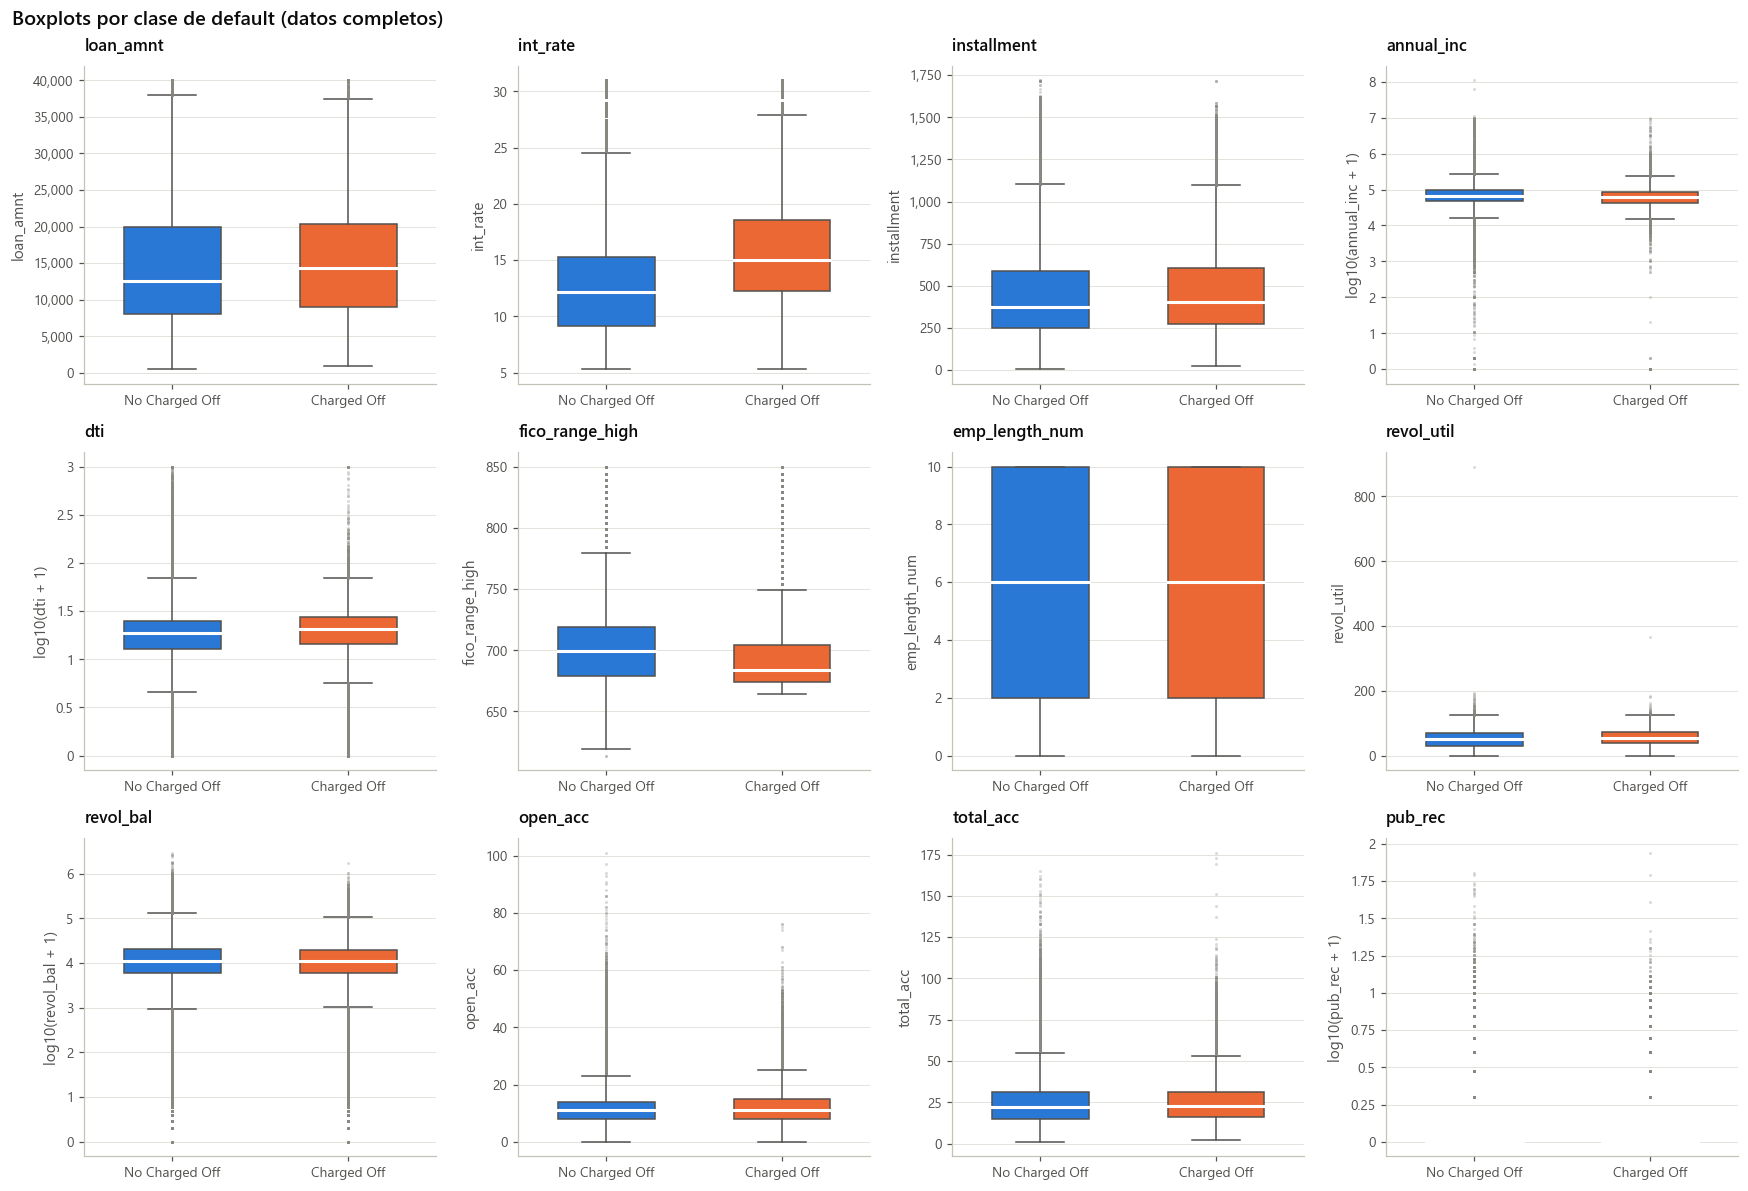

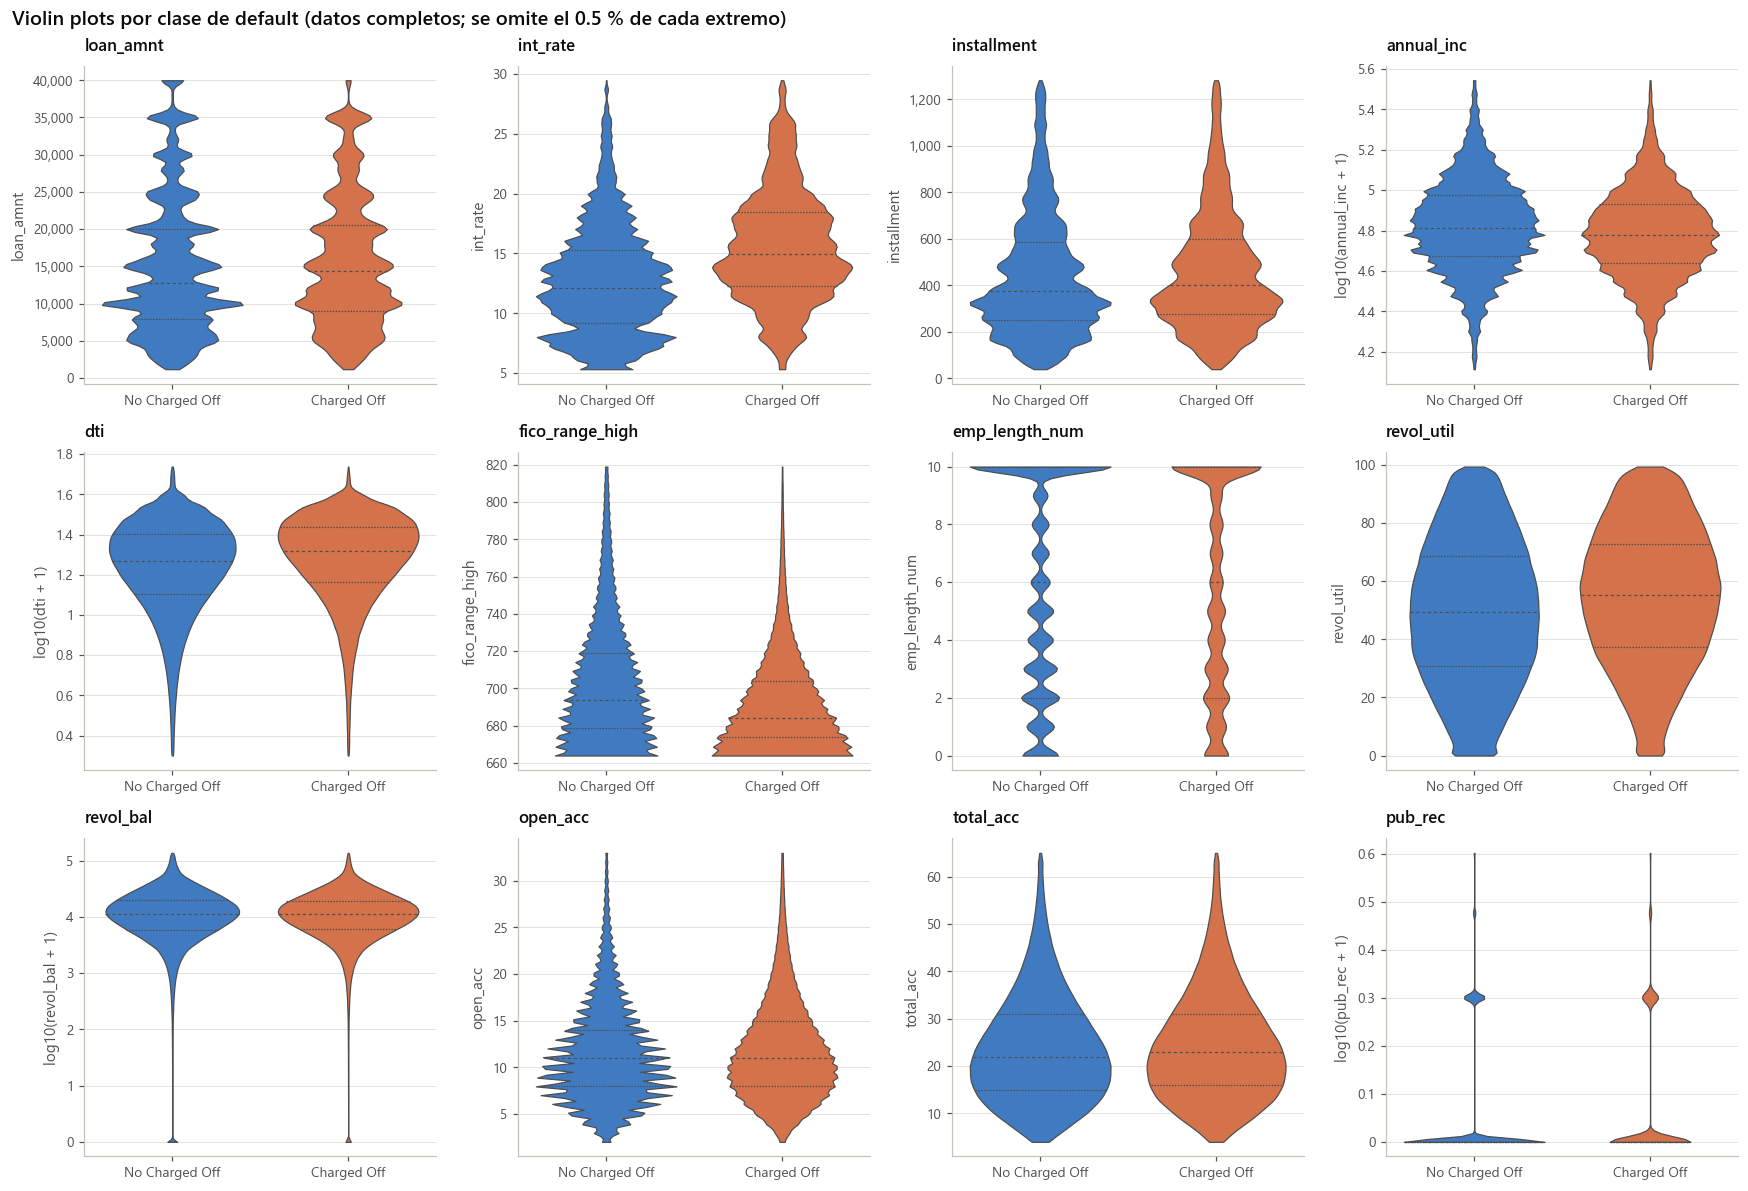

In [31]:
# --- Boxplots (datos completos) ---
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.flat, NUM_VARS):
    datos = [valores_para_grafico(dm.loc[dm["default"] == k, col].dropna().astype("float64"), col)
             for k in (0, 1)]
    cajas = ax.boxplot(datos, widths=0.55, patch_artist=True,
                       medianprops=dict(color="white", linewidth=2),
                       whiskerprops=dict(color=COLOR["texto_2"]), capprops=dict(color=COLOR["texto_2"]),
                       flierprops=dict(marker="o", markersize=2, markerfacecolor=COLOR["tenue"],
                                       markeredgecolor="none", alpha=0.3))
    for caja, k in zip(cajas["boxes"], (0, 1)):
        caja.set(facecolor=CLASE_COLOR[k], edgecolor=COLOR["texto_2"])
    for linea in ax.lines:
        linea.set_rasterized(True)
    ax.set_xticks([1, 2], ["No Charged Off", "Charged Off"])
    ax.set_title(col)
    ax.set_ylabel(etiqueta_eje(col))
    ax.yaxis.set_major_formatter(fmt_miles)
    ax.grid(axis="x", visible=False)
fig.suptitle("Boxplots por clase de default (datos completos)",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_boxplots_por_clase.png")
plt.show()

# --- Violin plots (datos completos) ---
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.flat, NUM_VARS):
    datos = muestra[[col, "default"]].dropna()
    lo, hi = datos[col].quantile([0.005, 0.995])
    datos = datos[(datos[col] >= lo) & (datos[col] <= hi)]
    datos[col] = valores_para_grafico(datos[col].astype("float64"), col)
    sns.violinplot(data=datos, x="default", y=col, palette=CLASE_COLOR, inner="quartile",
                   cut=0, linewidth=0.8, ax=ax)
    ax.set_xticks([0, 1], ["No Charged Off", "Charged Off"])
    ax.set_xlabel("")
    ax.set_title(col)
    ax.set_ylabel(etiqueta_eje(col))
    ax.yaxis.set_major_formatter(fmt_miles)
    ax.grid(axis="x", visible=False)
fig.suptitle("Violin plots por clase de default (datos completos; se omite el 0.5 % de cada extremo)",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_violines_por_clase.png")
plt.show()


### Análisis de los boxplots y violin plots por clase

**Lectura general.** En las 12 variables las distribuciones de ambas clases **se superponen en gran medida**: ninguna variable separa por sí sola a los préstamos en default de los demás. Las diferencias están en el desplazamiento de la mediana y de los cuartiles. `int_rate` y `fico_range_high` son las únicas con desplazamientos claros, lo que coincide con que son las de mayor correlación punto-biserial (Parte 24). *Nota:* la clase 0 incluye préstamos pagados y vigentes (Parte 21).

**1. `loan_amnt`.** La mediana sube de 12,525 USD (clase 0) a **14,350 USD** (Charged Off), y Q1 de 8,000 a 9,000; la media pasa de 14,977 a 15,565. La dispersión es similar (desviación ≈ 9,000; IQR 12,000 frente a 11,400). Los violines conservan los picos en montos redondos del histograma (Parte 12). Los outliers (1.7 % y 0.6 %) están cerca del tope de 40,000 USD: son el máximo permitido, no errores. **Efecto despreciable** (r = 0.021).

**2. `int_rate`.** Es la variable con **mayor separación**: la mediana pasa de 12.1 % a **15.1 %**, Q1 de 9.2 % a 12.3 % y Q3 de 15.3 % a 18.6 %. El cuartil inferior de los Charged Off ya está cerca de la mediana de la clase 0. El 16.3 % de los Charged Off paga más de 20 %, frente al 6.7 % de la clase 0. La dispersión es casi igual (IQR ≈ 6.2), así que la diferencia está en la **posición**. Los outliers (≈ 2 %) son tasas altas legítimas (hasta 31 %) de los grados F y G. **Es el mejor predictor numérico** (r = 0.199), porque la tasa ya incorpora la evaluación de riesgo de Lending Club.

**3. `installment`.** La mediana pasa de 375 a **403 USD**, con dispersión similar (IQR ≈ 335). Replica el patrón de `loan_amnt`, porque la cuota se calcula a partir del monto (r = 0.95, Parte 29). **Redundante con `loan_amnt`** (r = 0.027).

**4. `annual_inc` (escala log).** Los Charged Off ganan menos: mediana de 65,175 frente a **60,000 USD**, y media de 79,016 frente a 70,401. En ambas clases la media supera ampliamente a la mediana (fuerte sesgo, Parte 14). En escala log los violines son casi simétricos y parecidos. Los outliers (≈ 4.7 % por clase) están en los dos extremos: ingresos de 0 y de hasta 11 millones. **Efecto pequeño e inverso** (r_rank = −0.10); requiere transformación log.

**5. `dti` (escala log).** La mediana sube de 17.6 a **19.8** y toda la caja se desplaza (Q1 de 11.7 a 13.6; Q3 de 24.2 a 26.3). En ambas clases aparece el valor imposible de 999 (Parte 11). **Efecto pequeño** (r_rank = 0.12); hay que tratar los valores −1 y 999 en el preprocesamiento.

**6. `fico_range_high`.** Es la segunda variable más relevante, con relación **inversa**: la mediana baja de 699 a **684**, Q3 de 719 a 704 y el P90 de 749 a 724. Los Charged Off tienen **menos dispersión** (IQR 30 frente a 40) y se concentran en la zona baja: el 52.1 % tiene FICO ≤ 684, frente al 37.2 % de la clase 0. El violín muestra el piso de ≈ 660 que exige la política. Los outliers (≈ 3.6 %) son puntajes altos legítimos. **Efecto pequeño** (r = −0.119).

**7. `emp_length_num`.** Las distribuciones son **idénticas**: misma mediana (6), Q1 (2) y Q3 (10). El violín tiene forma de reloj de arena, grueso en 10 años ("10+ years", ≈ 35 % en ambas clases). No hay outliers (variable acotada entre 0 y 10). **No discrimina** (r = −0.007). Lo informativo es el **faltante**: el 7.9 % de los Charged Off no declara su antigüedad laboral, frente al 6.3 % de la clase 0.

**8. `revol_util`.** La mediana sube de 49.5 % a **55.5 %**; la caja se desplaza unos 6 puntos. Los violines son casi simétricos (asimetría ≈ 0, Parte 14), así que no requiere transformación. El 16.6 % de los Charged Off usa más del 80 % de su cupo, frente al 13.2 %. Casi no hay outliers, salvo errores aislados como 892 %. **Efecto pequeño** (r = 0.066), y es la **tercera** variable clave más relacionada con `default`.

**9. `revol_bal` (escala log).** Es de las pocas variables donde la clase 0 tiene un valor **mayor**: media de 16,834 frente a 15,354, con medianas casi iguales (11,360 frente a 11,072). Es la variable clave con más outliers (≈ 6 % por clase). **No discrimina** (r = −0.021); `revol_util`, que relativiza el saldo con el límite, es más útil.

**10. `open_acc`.** Misma mediana (11); Q3 sube de 14 a 15. **Efecto despreciable** (r = 0.019).

**11. `total_acc`.** Distribuciones casi idénticas (medianas de 22 y 23). **Efecto despreciable** (r = 0.017).

**12. `pub_rec` (escala log).** La caja **colapsa en 0** en ambas clases, porque la mayoría no tiene registros públicos. El método IQR marca como outlier cualquier valor ≥ 1 (15.4 % frente a 19.3 %). La diferencia útil es que los Charged Off tienen **con más frecuencia al menos un registro** (19.3 % frente a 15.4 %). **Conviene transformarla en binaria** ("tiene o no registros públicos").

**Síntesis**

| Variable | Mediana clase 0 → Charged Off | Efecto |
|---|---|---|
| `int_rate` | 12.1 → 15.1 % | **Mediano** (el mayor) |
| `fico_range_high` | 699 → 684 | Pequeño (inverso) |
| `revol_util` | 49.5 → 55.5 % | Pequeño |
| `dti` | 17.6 → 19.8 | Pequeño |
| `annual_inc` | 65,175 → 60,000 | Pequeño (inverso) |
| `loan_amnt` / `installment` | 12,525 → 14,350 / 375 → 403 | Despreciable; redundantes entre sí |
| `pub_rec` | 0 → 0 (19.3 % frente a 15.4 % con ≥ 1) | Despreciable; mejor como binaria |
| `emp_length_num`, `revol_bal`, `open_acc`, `total_acc` | ≈ iguales | Despreciable |

Los outliers aparecen en proporciones similares en ambas clases, así que no son propios de los malos pagadores: reflejan la asimetría de las variables. Por eso **no se eliminan**; se tratarán con transformaciones (log / Yeo-Johnson) y, en los valores imposibles (`dti` = −1 / 999, `revol_util` = 892 %), con un tratamiento puntual.



Parte 24. Diferencias de medias, t de Welch, Mann-Whiteny y correlación punto biserial

En la Parte 14 ninguna variable resultó normal, así que la prueba principal es Mann-Whitney; la t de Welch se reporta para comparar. Con más de un millón de datos, casi cualquier diferencia sale con p ≈ 0. Por eso también se reporta el tamaño del efecto (rank-biserial y punto-biserial), que indica si la diferencia es grande y no solo si existe.

Variables evaluadas: 113  ·  elegibles para el modelo (sin fuga, ≤ 70 % nulos): 73


,n_variables
significativa (p<0.05),
Sí,102
No,8
No aplica (constante o casi vacía),3


,todas,elegibles,fuga
efecto,,,
Despreciable,59,43,7
Grande,4,0,4
Mediano,7,1,4
Pequeño,40,28,6
—,3,1,2


,clave,fuga,pct_nulos,n_0,n_1,media_0,media_1,dif_medias,mediana_0,mediana_1,t_Welch,p_t,p_MannWhitney,r_rank_biserial,r_punto_biserial,significativa (p<0.05),efecto
variable,,,,,,,,,,,,,,,,,
last_fico_range_high,,✓,0.0 %,"1,992,109","268,559",703.73,568.44,-135.29,704.00,559.00,-1202.8,0.00e+00,0.00e+00,-0.887,-0.600,Sí,Grande
last_fico_range_low,,✓,0.0 %,"1,992,109","268,559",698.25,507.11,-191.13,700.00,555.00,-517.5,0.00e+00,0.00e+00,-0.887,-0.557,Sí,Grande
recoveries,,✓,0.0 %,"1,992,109","268,559",0.23,"1,209.46","1,209.23",0.00,592.20,339.2,0.00e+00,0.00e+00,0.687,0.523,Sí,Grande
collection_recovery_fee,,✓,0.0 %,"1,992,109","268,559",0.05,201.53,201.48,0.00,80.10,317.0,0.00e+00,0.00e+00,0.657,0.497,Sí,Grande
total_rec_prncp,,✓,0.0 %,"1,992,109","268,559","10,195.72","4,387.88","-5,807.84","8,000.00","3,157.31",-582.0,0.00e+00,0.00e+00,-0.458,-0.226,Sí,Mediano
out_prncp,,✓,0.0 %,"1,992,109","268,559","4,774.03",0.00,"-4,774.03",0.00,0.00,-881.1,0.00e+00,0.00e+00,-0.456,-0.210,Sí,Mediano
out_prncp_inv,,✓,0.0 %,"1,992,109","268,559","4,772.98",0.00,"-4,772.98",0.00,0.00,-881.0,0.00e+00,0.00e+00,-0.456,-0.210,Sí,Mediano
int_rate,✓,,0.0 %,"1,992,109","268,559",12.74,15.71,2.97,12.13,15.05,295.7,0.00e+00,0.00e+00,0.355,0.199,Sí,Mediano
last_pymnt_amnt,,✓,0.0 %,"1,992,109","268,559","3,827.97",472.42,"-3,355.55",664.31,389.98,-729.6,0.00e+00,0.00e+00,-0.354,-0.180,Sí,Mediano


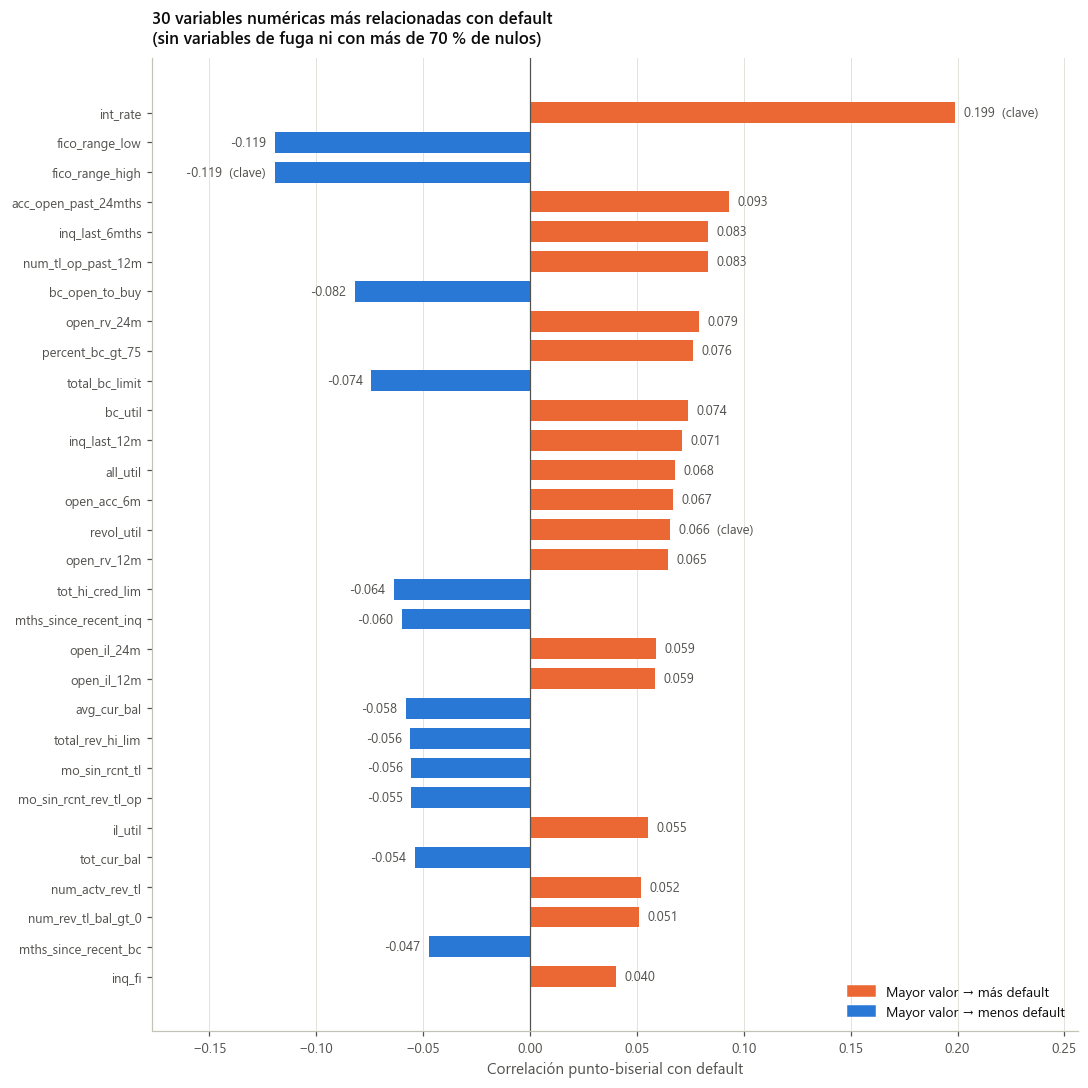

In [32]:
# Variables numéricas que solo se conocen DESPUÉS de otorgar el préstamo (fuga de información)
POSTERIORES_NUM = [
    "funded_amnt_inv", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", "total_rec_prncp",
    "total_rec_int", "total_rec_late_fee", "recoveries", "collection_recovery_fee", "last_pymnt_amnt",
    "last_fico_range_high", "last_fico_range_low", "settlement_amount", "settlement_percentage",
    "settlement_term", "deferral_term", "hardship_amount", "hardship_length", "hardship_dpd",
    "orig_projected_additional_accrued_interest", "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",
]

mask_modelo = df["default"].notna()
y_todas = df.loc[mask_modelo, "default"].astype("int8")
cols_prueba = [c for c in df.select_dtypes(include="number").columns
               if c not in ["id", "member_id", "default"]]

filas = []
for col in cols_prueba:
    x = df.loc[mask_modelo, col].astype("float64")
    valido = x.notna()
    x0 = x[valido & (y_todas == 0)]
    x1 = x[valido & (y_todas == 1)]
    fila = {"variable": col,
            "clave": "✓" if col in NUM_VARS else "",
            "fuga": "✓" if col in POSTERIORES_NUM else "",
            "pct_nulos": (~valido).mean() * 100,
            "n_0": len(x0), "n_1": len(x1)}
    if min(len(x0), len(x1)) < 30 or x[valido].nunique() < 2:
        fila["significativa (p<0.05)"] = "No aplica (constante o casi vacía)"
        filas.append(fila)
        continue
    t_stat, p_t = stats.ttest_ind(x1, x0, equal_var=False)
    u_stat, p_u = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    r_pb, _ = stats.pointbiserialr(y_todas[valido], x[valido])
    fila.update({
        "media_0": x0.mean(), "media_1": x1.mean(), "dif_medias": x1.mean() - x0.mean(),
        "mediana_0": x0.median(), "mediana_1": x1.median(),
        "t_Welch": t_stat, "p_t": p_t, "p_MannWhitney": p_u,
        "r_rank_biserial": 2 * u_stat / (len(x0) * len(x1)) - 1,
        "r_punto_biserial": r_pb,
        "significativa (p<0.05)": "Sí" if p_u < 0.05 else "No",
    })
    filas.append(fila)

pruebas_todas = (pd.DataFrame(filas).set_index("variable")
                 .sort_values("r_punto_biserial", key=abs, ascending=False, na_position="last"))

def magnitud(r):
    if pd.isna(r):
        return "—"
    r = abs(r)
    return "Despreciable" if r < 0.1 else "Pequeño" if r < 0.3 else "Mediano" if r < 0.5 else "Grande"

pruebas_todas["efecto"] = pruebas_todas["r_rank_biserial"].apply(magnitud)

# Subconjunto de las 12 variables clave (lo usa la Parte 25)
pruebas_num = pruebas_todas.loc[[c for c in pruebas_todas.index if c in NUM_VARS]]

elegibles = pruebas_todas.query("fuga == '' and pct_nulos <= 70")
print(f"Variables evaluadas: {len(pruebas_todas)}  ·  elegibles para el modelo (sin fuga, ≤ 70 % nulos): {len(elegibles)}")
display(pruebas_todas["significativa (p<0.05)"].value_counts().to_frame("n_variables"))
display(pd.DataFrame({"todas": pruebas_todas["efecto"].value_counts(),
                      "elegibles": elegibles["efecto"].value_counts(),
                      "fuga": pruebas_todas.query("fuga == '✓'")["efecto"].value_counts()}).fillna(0).astype(int))

display(pruebas_todas.style.format({
    "pct_nulos": "{:.1f} %", "n_0": "{:,.0f}", "n_1": "{:,.0f}",
    "media_0": "{:,.2f}", "media_1": "{:,.2f}", "dif_medias": "{:,.2f}",
    "mediana_0": "{:,.2f}", "mediana_1": "{:,.2f}", "t_Welch": "{:.1f}",
    "p_t": "{:.2e}", "p_MannWhitney": "{:.2e}",
    "r_rank_biserial": "{:.3f}", "r_punto_biserial": "{:.3f}"}, na_rep="—"))

# Gráfico: 30 variables elegibles con mayor |r punto-biserial|
orden = elegibles.dropna(subset=["r_punto_biserial"]).head(30)["r_punto_biserial"].iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(orden.index, orden.values, height=0.7,
        color=np.where(orden.values > 0, COLOR["secundario"], COLOR["principal"]))
for i, (var, v) in enumerate(orden.items()):
    marca = "  (clave)" if var in NUM_VARS else ""
    ax.text(v + (0.004 if v >= 0 else -0.004), i, f"{v:.3f}{marca}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5, color=COLOR["texto_2"])
ax.axvline(0, color=COLOR["texto_2"], linewidth=0.8)
ax.set_xlabel("Correlación punto-biserial con default")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
ax.margins(x=0.18)
ax.legend(handles=[Patch(color=COLOR["secundario"], label="Mayor valor → más default"),
                   Patch(color=COLOR["principal"], label="Mayor valor → menos default")], loc="lower right")
ax.set_title("30 variables numéricas más relacionadas con default\n"
             "(sin variables de fuga ni con más de 70 % de nulos)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_punto_biserial.png")
plt.show()


### Análisis de las pruebas estadísticas por clase

**1. Elección de la prueba.** Como ninguna variable es normal (Parte 14), la prueba principal es **Mann-Whitney U**, que compara la posición de las distribuciones a partir de rangos, sin suponer normalidad. La **t de Welch** se reporta como complemento: con muestras tan grandes (1,992,109 y 268,559), el teorema central del límite hace válida la comparación de medias. En las 12 variables clave ambas pruebas coinciden.

**2. Significancia.** Las 12 variables tienen **p < 0.05** (p ≈ 0) en ambas pruebas. Sin embargo, con 2.26 millones de observaciones cualquier diferencia resulta significativa: `total_acc` difiere en solo 0.6 cuentas y aun así tiene p ≈ 0. Por eso la relevancia se mide con el **tamaño del efecto**.

**3. Tamaño del efecto.** Se usan la **r rank-biserial** (asociada a Mann-Whitney; mide la probabilidad de que un Charged Off tenga un valor mayor que uno de la clase 0, reescalada entre −1 y 1) y la **r punto-biserial** (Pearson con la variable binaria; su cuadrado indica el % de variabilidad de `default` que explica). Umbrales: |r| < 0.1 despreciable; 0.1–0.3 pequeño; 0.3–0.5 mediano.

| Variable | Media clase 0 → CO | r rank-biserial | r punto-biserial | r² | Efecto |
|---|---|---|---|---|---|
| `int_rate` | 12.74 → 15.71 % | **0.355** | **0.199** | 4.0 % | **Mediano** |
| `fico_range_high` | 704.0 → 691.9 | −0.217 | −0.119 | 1.4 % | Pequeño |
| `dti` | 18.64 → 20.17 | 0.120 | 0.035 | 0.1 % | Pequeño |
| `revol_util` | 49.7 → 54.8 % | 0.118 | 0.066 | 0.4 % | Pequeño |
| `annual_inc` | 79,016 → 70,401 | −0.103 | −0.025 | < 0.1 % | Pequeño |
| `installment` | 443 → 465 | 0.062 | 0.027 | < 0.1 % | Despreciable |
| `loan_amnt` | 14,977 → 15,565 | 0.053 | 0.021 | < 0.1 % | Despreciable |
| `pub_rec` | 0.19 → 0.25 | 0.040 | 0.032 | 0.1 % | Despreciable |
| `open_acc` | 11.57 → 11.90 | 0.039 | 0.019 | < 0.1 % | Despreciable |
| `total_acc` | 24.09 → 24.71 | 0.030 | 0.017 | < 0.1 % | Despreciable |
| `revol_bal` | 16,834 → 15,354 | −0.020 | −0.021 | < 0.1 % | Despreciable |
| `emp_length_num` | 5.94 → 5.86 | −0.015 | −0.007 | < 0.1 % | Despreciable |

**4. Interpretación.** `int_rate` es la única variable con efecto mediano: al tomar al azar un Charged Off y un préstamo de la clase 0, el primero tiene una tasa mayor en el **68 %** de los casos ((1 + 0.355) / 2). `fico_range_high`, `dti`, `revol_util` y `annual_inc` tienen efectos pequeños con la dirección esperada: menor puntaje, más endeudamiento, más uso del cupo y menor ingreso se asocian con más default. Las otras 7 variables tienen efectos despreciables.

**5. Diferencia entre las dos medidas.** En `dti` y `annual_inc`, la rank-biserial es claramente mayor que la punto-biserial (0.120 frente a 0.035 y −0.103 frente a −0.025). La correlación de Pearson se ve afectada por los **valores extremos** de la Parte 11, mientras que Mann-Whitney usa rangos y es robusta a ellos. Tratar los outliers o aplicar una transformación log (Parte 14) debería mejorar el aporte de estas variables en los modelos lineales.

**6. Implicaciones para el modelado.** La mejor variable explica solo el 4 % de la variabilidad de `default`: **ninguna predice el default por sí sola**. El modelo deberá combinar variables numéricas y categóricas (`sub_grade`, `verification_status`, `term`; Parte 26), y posiblemente captar interacciones, donde los modelos de árboles (RandomForest, GBT) suelen tener ventaja.


**Extensión a todas las variables.** De las 113 variables numéricas, 102 muestran diferencias significativas, 8 no son significativas y 3 son constantes. Las 4 de **efecto grande son todas variables de fuga**: `last_fico_range_high` y `last_fico_range_low` (r rank-biserial = −0.89), `recoveries` (0.69) y `collection_recovery_fee` (0.66). Estas variables describen lo que pasó después de otorgar el préstamo; por ejemplo, `recoveries` solo es mayor que 0 si el préstamo ya cayó en default. Usarlas daría un modelo artificialmente perfecto e inútil en la práctica, lo que **confirma que deben excluirse**.

Entre las **73 variables elegibles** (sin fuga y con 70 % de nulos o menos), `int_rate` es la única con efecto mediano, 28 tienen efecto pequeño y 43 despreciable. Tras `int_rate` (0.199) y `fico_range_high` / `fico_range_low` (−0.119, redundantes entre sí), aparecen variables que no estaban entre las 12 clave: `acc_open_past_24mths` (0.093), `inq_last_6mths` (0.083), `num_tl_op_past_12m` (0.083), `bc_open_to_buy` (−0.082), `open_rv_24m` (0.079) y `bc_util` (0.074). El patrón indica que **abrir muchas cuentas o hacer muchas consultas de crédito recientemente** se asocia con más riesgo, y que **tener más crédito disponible** se asocia con menos. Estas variables se considerarán en la selección de características.


Parte 25. KDE Comparativos de las 6 variables más relevantes

Se eligen las 6 con mayor r punto biserial de la parte 24

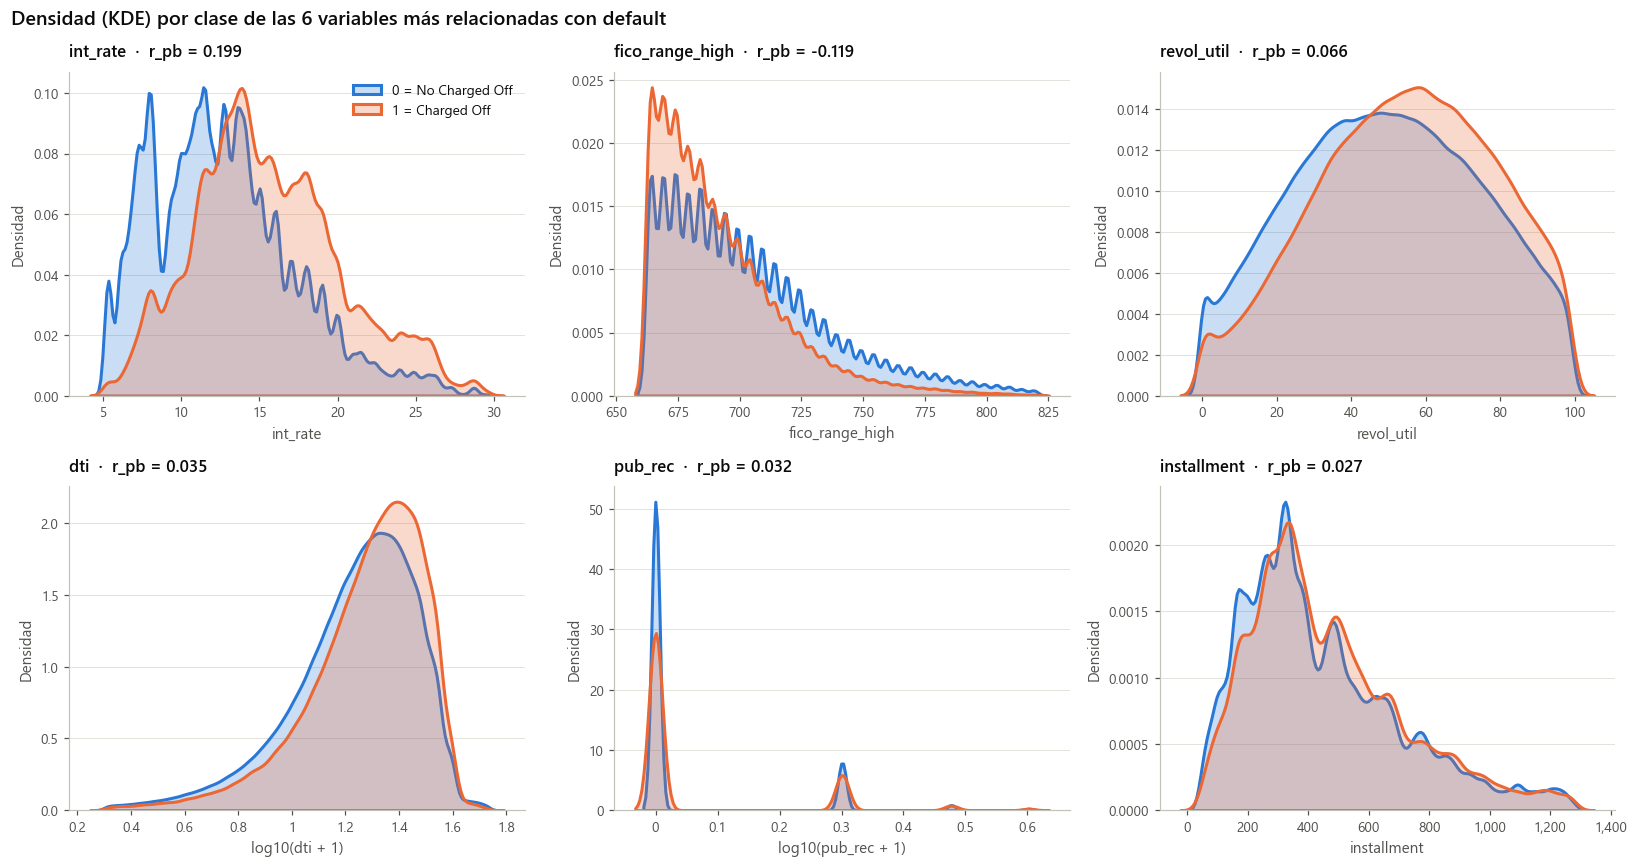

In [33]:
TOP_VARS = pruebas_num.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, TOP_VARS):
    datos = muestra[[col, "default"]].dropna()
    lo, hi = datos[col].quantile([0.005, 0.995])
    datos = datos[(datos[col] >= lo) & (datos[col] <= hi)]
    datos[col] = valores_para_grafico(datos[col].astype("float64"), col)
    for k in (0, 1):
        sns.kdeplot(datos.loc[datos["default"] == k, col], ax=ax, color=CLASE_COLOR[k],
                    fill=True, alpha=0.25, linewidth=2, label=CLASE_NOMBRE[k])
    ax.set_title(f"{col}  ·  r_pb = {pruebas_num.loc[col, 'r_punto_biserial']:.3f}")
    ax.set_xlabel(etiqueta_eje(col))
    ax.set_ylabel("Densidad")
    ax.xaxis.set_major_formatter(fmt_miles)
    ax.grid(axis="x", visible=False)
axes.flat[0].legend(loc="upper right")
fig.suptitle("Densidad (KDE) por clase de las 6 variables más relacionadas con default",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_kde_por_clase.png")
plt.show()


Las 6 variables con mayor |r punto-biserial| son `int_rate`, `fico_range_high`, `revol_util`, `dti`, `pub_rec` e `installment`. En `int_rate` la curva de los Charged Off está desplazada unos 3 puntos a la derecha: es la separación más visible. En `fico_range_high`, los Charged Off tienen un pico más alto en los puntajes bajos (660–690) y una cola más delgada hacia los altos. En `revol_util` y `dti` hay un desplazamiento leve hacia valores mayores. En `pub_rec` e `installment` las curvas casi coinciden. En todas las variables las densidades se superponen en gran medida, lo que confirma que ninguna separa las clases por sí sola.


B. Variables categóricas vs. default

Parte 26. Tablas de contigencia, chi cuadrado y V de Cramer

La V de Cramér va de 0 a 1 y mide la fuerza de la asociación; el p-value, igual que antes, sale ≈ 0 por el tamaño de la muestra.

In [34]:
# Variables categóricas que solo se conocen DESPUÉS de otorgar el préstamo (fuga de información)
FUGA_CAT = ["pymnt_plan", "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
            "hardship_loan_status", "debt_settlement_flag", "settlement_status"]
ALFA = 0.05

def cramer_v(tabla):
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    n = tabla.values.sum()
    k = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

def como_texto(serie):
    """Convierte a texto y marca los nulos como '(faltante)' para no perderlos en el crosstab."""
    return serie.astype("object").where(serie.notna(), "(faltante)").astype(str)

def magnitud_v(v):
    if pd.isna(v):
        return "—"
    return "Despreciable" if v < 0.1 else "Pequeña" if v < 0.3 else "Moderada" if v < 0.5 else "Grande"

mask_modelo = df["default"].notna()
y_mod = df.loc[mask_modelo, "default"].astype("int8")
TASA_GLOBAL = y_mod.mean() * 100
cols_chi = [c for c in CAT_TODAS if c != "loan_status"]      # loan_status es el origen de default

tablas_cat, filas = {}, []
for col in cols_chi:
    x = como_texto(df.loc[mask_modelo, col])
    conteos = pd.crosstab(x, y_mod)
    conteos.columns = ["n_fully_paid", "n_charged_off"]
    tabla = conteos.assign(n_total=conteos.sum(axis=1))
    tabla["tasa_default"] = tabla["n_charged_off"] / tabla["n_total"] * 100
    tabla["dif_vs_global"] = tabla["tasa_default"] - TASA_GLOBAL

    fila = {"variable": col,
            "clave": "✓" if col in CAT_VARS else "",
            "fuga": "✓" if col in FUGA_CAT else "",
            "pct_nulos": (x == "(faltante)").mean() * 100,
            "n_categorias": len(conteos)}
    if len(conteos) < 2:
        fila["decision"] = "No aplica (una sola categoría)"
        filas.append(fila)
        continue

    chi2, p, gl, esperadas = stats.chi2_contingency(conteos)
    n = conteos.values.sum()

    # Post-hoc: residuos estandarizados ajustados de la columna Charged Off
    prop_fila = conteos.sum(axis=1).values[:, None] / n
    prop_col = conteos.sum(axis=0).values[None, :] / n
    residuos = (conteos.values - esperadas) / np.sqrt(esperadas * (1 - prop_fila) * (1 - prop_col))
    tabla["residuo_ajustado"] = residuos[:, 1]
    critico = stats.norm.ppf(1 - ALFA / (2 * len(conteos)))           # corrección de Bonferroni
    tabla["significativa_posthoc"] = np.where(np.abs(tabla["residuo_ajustado"]) > critico, "Sí", "No")
    tablas_cat[col] = tabla

    pct_e5 = (esperadas < 5).mean() * 100
    fila.update({
        "chi2": chi2, "gl": gl, "p_value": p,
        "V_Cramer": cramer_v(conteos),
        "min_esperada": esperadas.min(),
        "pct_celdas_E<5": pct_e5,
        "supuesto_Cochran": "Cumple" if (pct_e5 <= 20 and esperadas.min() >= 1) else "No cumple",
        "tasa_min": tabla["tasa_default"].min(), "tasa_max": tabla["tasa_default"].max(),
        "cat_sig_posthoc": f"{(tabla['significativa_posthoc'] == 'Sí').sum()} de {len(tabla)}",
        "decision": "Rechazar H₀" if p < ALFA else "No rechazar H₀",
    })
    filas.append(fila)

pruebas_cat = (pd.DataFrame(filas).set_index("variable")
               .sort_values("V_Cramer", ascending=False, na_position="last"))
pruebas_cat["magnitud"] = pruebas_cat["V_Cramer"].apply(magnitud_v)

print(f"Variables evaluadas: {len(pruebas_cat)}  ·  tasa global de default: {TASA_GLOBAL:.2f} %")
display(pruebas_cat["decision"].value_counts().to_frame("n_variables"))
display(pruebas_cat.style.format({
    "pct_nulos": "{:.1f} %", "chi2": "{:,.1f}", "gl": "{:.0f}", "p_value": "{:.2e}", "V_Cramer": "{:.3f}",
    "min_esperada": "{:,.1f}", "pct_celdas_E<5": "{:.1f} %", "tasa_min": "{:.1f} %", "tasa_max": "{:.1f} %"},
    na_rep="—"))

# Tablas de contingencia con tasa de default y residuos ajustados por categoría
for col in tablas_cat:
    etiqueta = "  [FUGA]" if col in FUGA_CAT else ("  [clave]" if col in CAT_VARS else "")
    print(f"\n{col}{etiqueta}")
    display(tablas_cat[col].sort_values("tasa_default", ascending=False).style.format({
        "n_fully_paid": "{:,}", "n_charged_off": "{:,}", "n_total": "{:,}",
        "tasa_default": "{:.2f} %", "dif_vs_global": "{:+.2f}", "residuo_ajustado": "{:+.1f}"}))


Variables evaluadas: 20  ·  tasa global de default: 11.88 %


,n_variables
decision,
Rechazar H₀,20


,clave,fuga,pct_nulos,n_categorias,chi2,gl,p_value,V_Cramer,min_esperada,pct_celdas_E<5,supuesto_Cochran,tasa_min,tasa_max,cat_sig_posthoc,decision,magnitud
variable,,,,,,,,,,,,,,,,
settlement_status,,✓,98.5 %,4,"241,867.3",3,0.00e+00,0.327,598.4,0.0 %,Cumple,10.6 %,99.9 %,4 de 4,Rechazar H₀,Moderada
debt_settlement_flag,,✓,0.0 %,2,"241,530.2",1,0.00e+00,0.327,"4,068.3",0.0 %,Cumple,10.6 %,97.2 %,2 de 2,Rechazar H₀,Moderada
sub_grade,,,0.0 %,35,"116,768.4",34,0.00e+00,0.227,186.3,0.0 %,Cumple,1.6 %,39.6 %,35 de 35,Rechazar H₀,Pequeña
grade,✓,,0.0 %,7,"112,789.3",6,0.00e+00,0.223,"1,445.5",0.0 %,Cumple,3.3 %,37.5 %,7 de 7,Rechazar H₀,Pequeña
verification_status,✓,,0.0 %,3,"20,391.8",2,0.00e+00,0.095,"74,797.8",0.0 %,Cumple,8.0 %,15.8 %,3 de 3,Rechazar H₀,Despreciable
term,✓,,0.0 %,2,"16,135.4",1,0.00e+00,0.084,"77,326.2",0.0 %,Cumple,10.1 %,16.2 %,2 de 2,Rechazar H₀,Despreciable
hardship_status,,✓,99.5 %,4,"13,240.2",3,0.00e+00,0.077,98.8,0.0 %,Cumple,0.0 %,84.0 %,4 de 4,Rechazar H₀,Despreciable
initial_list_status,,,0.0 %,2,"11,140.3",1,0.00e+00,0.070,"86,151.2",0.0 %,Cumple,10.3 %,15.2 %,2 de 2,Rechazar H₀,Despreciable
disbursement_method,,,0.0 %,2,"7,894.7",1,0.00e+00,0.059,"9,280.6",0.0 %,Cumple,1.8 %,12.2 %,2 de 2,Rechazar H₀,Despreciable



hardship_type  [FUGA]


,n_fully_paid,n_charged_off,n_total,tasa_default,dif_vs_global,residuo_ajustado,significativa_posthoc
hardship_type,,,,,,,
INTEREST ONLY-3 MONTHS DEFERRAL,"6,857","4,060","10,917",37.19 %,+25.31,+81.9,Sí
(faltante),"1,985,252","264,499","2,249,751",11.76 %,-0.12,-81.9,Sí


...

,n_fully_paid,n_charged_off,n_total,tasa_default,dif_vs_global,residuo_ajustado,significativa_posthoc
purpose,,,,,,,
small_business,"20,109","4,580","24,689",18.55 %,+6.67,+32.6,Sí
renewable_energy,"1,224",221,"1,445",15.29 %,+3.41,+4.0,Sí
moving,"13,189","2,214","15,403",14.37 %,+2.49,+9.6,Sí
educational,368,56,424,13.21 %,+1.33,+0.8,No
debt_consolidation,"1,112,863","165,014","1,277,877",12.91 %,+1.03,+54.8,Sí
medical,"24,101","3,387","27,488",12.32 %,+0.44,+2.3,No
wedding,"2,076",279,"2,355",11.85 %,-0.03,-0.0,No
other,"123,055","16,385","139,440",11.75 %,-0.13,-1.5,No
house,"12,549","1,587","14,136",11.23 %,-0.65,-2.4,No



sub_grade


,n_fully_paid,n_charged_off,n_total,tasa_default,dif_vs_global,residuo_ajustado,significativa_posthoc
sub_grade,,,,,,,
G3,"1,265",829,"2,094",39.59 %,+27.71,+39.2,Sí
G2,"1,641","1,047","2,688",38.95 %,+27.07,+43.4,Sí
G4,"1,057",655,"1,712",38.26 %,+26.38,+33.7,Sí
F4,"3,797","2,327","6,124",38.00 %,+26.12,+63.3,Sí
G5,973,595,"1,568",37.95 %,+26.07,+31.9,Sí
F5,"3,228","1,939","5,167",37.53 %,+25.65,+57.0,Sí
F3,"5,047","2,744","7,791",35.22 %,+23.34,+63.8,Sí
F2,"6,041","3,264","9,305",35.08 %,+23.20,+69.3,Sí
G1,"2,672","1,434","4,106",34.92 %,+23.04,+45.7,Sí



addr_state  [clave]


,n_fully_paid,n_charged_off,n_total,tasa_default,dif_vs_global,residuo_ajustado,significativa_posthoc
addr_state,,,,,,,
AL,"23,358","3,926","27,284",14.39 %,+2.51,+12.9,Sí
AR,"14,654","2,420","17,074",14.17 %,+2.29,+9.3,Sí
LA,"22,166","3,593","25,759",13.95 %,+2.07,+10.3,Sí
OK,"17,808","2,883","20,691",13.93 %,+2.05,+9.2,Sí
NV,"28,214","4,443","32,657",13.61 %,+1.73,+9.7,Sí
MS,"10,921","1,718","12,639",13.59 %,+1.71,+6.0,Sí
NM,"10,413","1,573","11,986",13.12 %,+1.24,+4.2,Sí
NY,"162,176","24,213","186,389",12.99 %,+1.11,+15.5,Sí
SD,"3,959",590,"4,549",12.97 %,+1.09,+2.3,No


### Análisis inferencial: asociación entre las variables categóricas y `default`

**Población y variables.** Se analizan las **20 variables categóricas** (todas excepto `loan_status`, origen de la variable objetivo) sobre los **2,260,668 préstamos** (1,992,109 sin Charged Off y 268,559 Charged Off; tasa global de default: 11.88 %). Los nulos se tratan como una categoría más, "(faltante)".

**1. Hipótesis.** Para cada variable se aplica una prueba de independencia chi-cuadrado de Pearson:
- **H₀:** la variable y `default` son independientes.
- **H₁:** la tasa de default varía según la categoría.
- Nivel de significancia: **α = 0.05**.

**2. Supuestos.** Las observaciones son independientes: cada préstamo aparece una vez. La regla de Cochran (menos del 20 % de celdas con frecuencia esperada < 5 y ninguna < 1) **se cumple en las 20 variables**; el caso límite es `hardship_loan_status`, con 8.3 % de celdas con E < 5, por la categoría "Issued" (15 préstamos).

**3. Resultado general.** **Se rechaza H₀ en las 20 variables.** Con 2.26 millones de datos la prueba detecta hasta asociaciones mínimas, así que la **relevancia** se mide con la V de Cramér (umbrales de Cohen para 2 clases: < 0.1 despreciable; 0.1–0.3 pequeña; 0.3–0.5 moderada).

**4. Clasificación de las variables**

**A) Fuga de información (8): se excluyen del modelo**

| Variable | V | Hallazgo | Por qué es fuga |
|---|---|---|---|
| `settlement_status` | **0.327** | ACTIVE, BROKEN, COMPLETE: 93.5–99.9 % de default | Acuerdo de pago; solo existe después del impago |
| `debt_settlement_flag` | **0.327** | "Y": **97.2 %** frente a "N": 10.6 % | Ídem |
| `hardship_status` | 0.077 | BROKEN: 84.0 % | Plan de alivio solicitado durante la vida del préstamo |
| `hardship_reason` | 0.057 | Entre 26.1 % y 50.7 % | Motivo del plan de alivio |
| `hardship_loan_status` | 0.057 | Late (16-30 days): 43.7 % | Estado de pago al entrar al plan |
| `hardship_type` | 0.054 | 37.2 % | Tipo de plan de alivio |
| `hardship_flag` | 0.007 | "Y": 0 % de default (832 préstamos, todos vigentes) | Plan de alivio posterior |
| `pymnt_plan` | 0.006 | "y": 0 % de default (620 préstamos) | Plan de pago posterior |

Las dos variables con **mayor asociación de todo el análisis son de fuga**: incluirlas daría un modelo artificialmente perfecto.

**B) Relevantes (asociación pequeña)**

| Variable | χ² (gl) | V | Tasa mín. – máx. | Post-hoc |
|---|---|---|---|---|
| `sub_grade` | 116,768 (34) | **0.227** | 1.6 % – 39.6 % | 35 de 35 categorías significativas |
| `grade` | 112,789 (6) | **0.223** | 3.3 % (A) – 37.5 % (G) | 7 de 7 |

`grade` y `sub_grade` son los predictores categóricos más fuertes, con un gradiente monótono (residuos ajustados de −194 en A a +172 en E). Son redundantes entre sí (V = 1.00, Parte 30): se usará solo `sub_grade`.

**C) Débiles pero interpretables (V entre 0.03 y 0.1)**

| Variable | V | Hallazgo |
|---|---|---|
| `verification_status` | 0.095 | Verified 15.9 % > Source Verified 12.3 % > Not Verified 8.0 %: Lending Club verifica a los solicitantes que considera más riesgosos |
| `term` | 0.084 | 60 meses: 16.2 % frente a 36 meses: 10.1 %. La asociación está **atenuada por el sesgo temporal**: muchos préstamos a 60 meses siguen vigentes |
| `home_ownership` | 0.052 | RENT 13.9 % frente a MORTGAGE 10.3 %; OWN, OTHER y NONE no son significativas |
| `purpose` | 0.049 | `small_business` 18.6 % (el más alto); `car` 8.9 % y `credit_card` 9.7 % (los más bajos); 6 categorías sin diferencia significativa |
| `addr_state` | 0.038 | Tasas entre 5.6 % y 14.4 %; 34 de 51 estados difieren del esperado |
| `emp_length` | 0.027 | "(faltante)" tiene la tasa más alta (14.4 %); 5 de 12 niveles no difieren del esperado |

**D) Asociación influida por la fecha de emisión: usar con cautela**

| Variable | V | Hallazgo | Interpretación |
|---|---|---|---|
| `initial_list_status` | 0.070 | "f" 15.2 % frente a "w" 10.3 % | "w" predomina en los préstamos recientes, que aún están vigentes |
| `disbursement_method` | 0.059 | DirectPay 1.8 % frente a Cash 12.2 % | DirectPay existe desde 2017: casi todos sus préstamos siguen vigentes |
| `application_type` | 0.049 | Joint App 5.3 % frente a Individual 12.3 % | Las solicitudes conjuntas empezaron en 2017 |
| `verification_status_joint` | 0.046 | Todas sus categorías ≈ 5 % | Solo existe en solicitudes conjuntas (95 % de nulos): se elimina |

Estas asociaciones **no reflejan un menor riesgo real**, sino que los préstamos no han tenido tiempo de caer en default (Parte 21).

**5. Conclusiones**
1. Las 20 variables son estadísticamente dependientes de `default`, pero con fuerza muy desigual.
2. **8 variables son de fuga** y se eliminan, incluidas las dos con mayor asociación.
3. Los predictores categóricos útiles son **`sub_grade`** (o `grade`), seguidos por `verification_status`, `term`, `home_ownership`, `purpose`, `addr_state` y `emp_length`.
4. Las asociaciones de `disbursement_method`, `application_type` e `initial_list_status` están **influidas por la fecha de emisión**, y `verification_status_joint` se elimina por nulos.



Parte 27. Barras apiladas y tasa de default por categoría

Cada variable se muestra en una figura con dos paneles: a la izquierda, la frecuencia apilada por clase; a la derecha, la tasa de default comparada con la global.

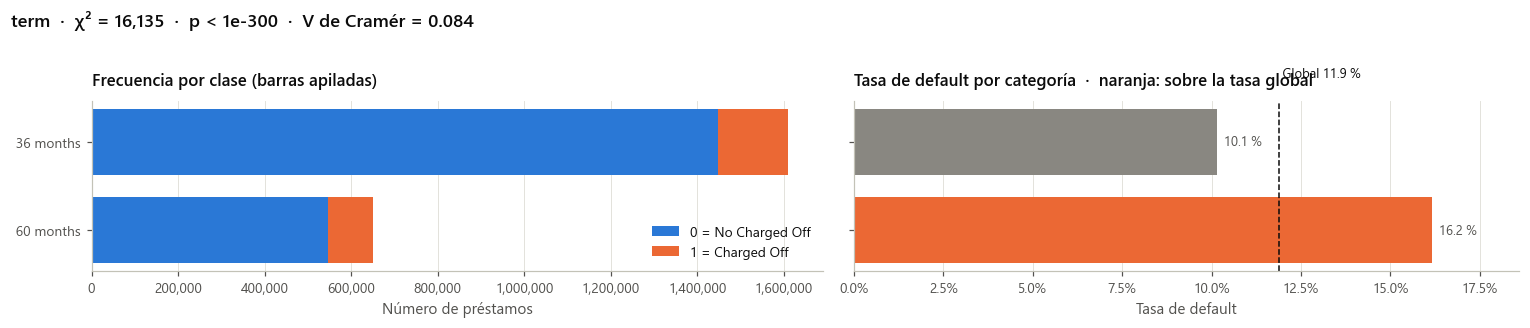

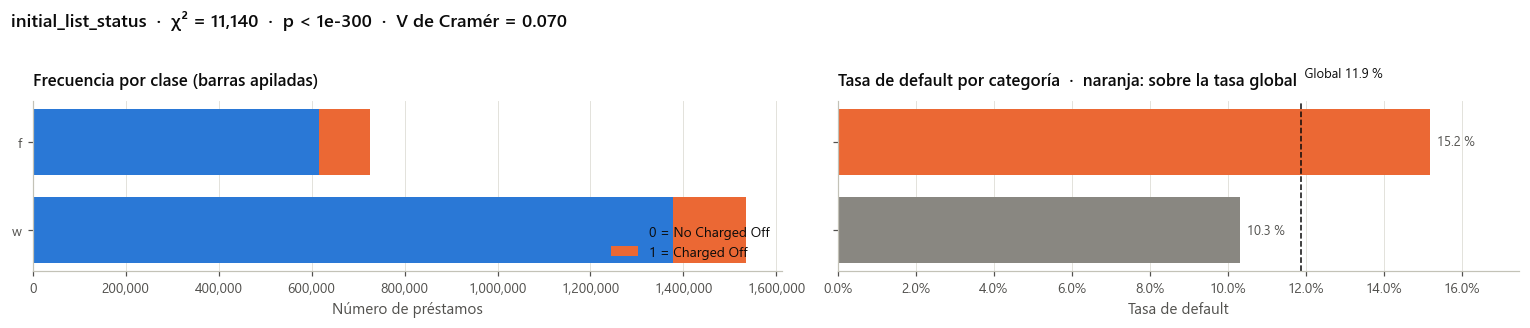

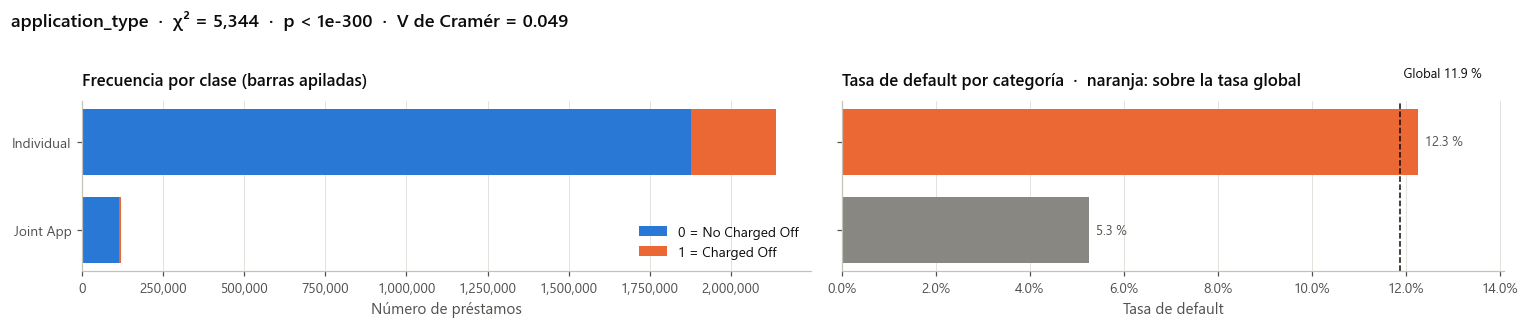

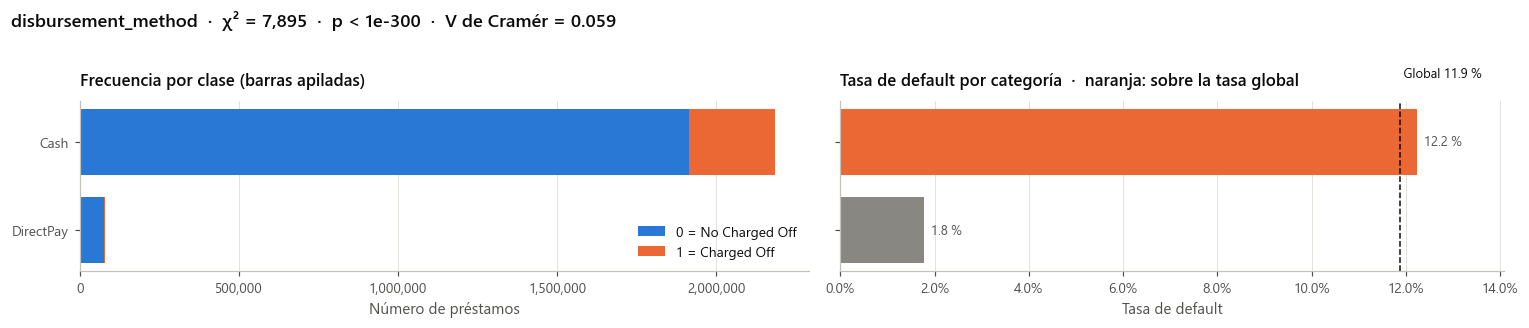

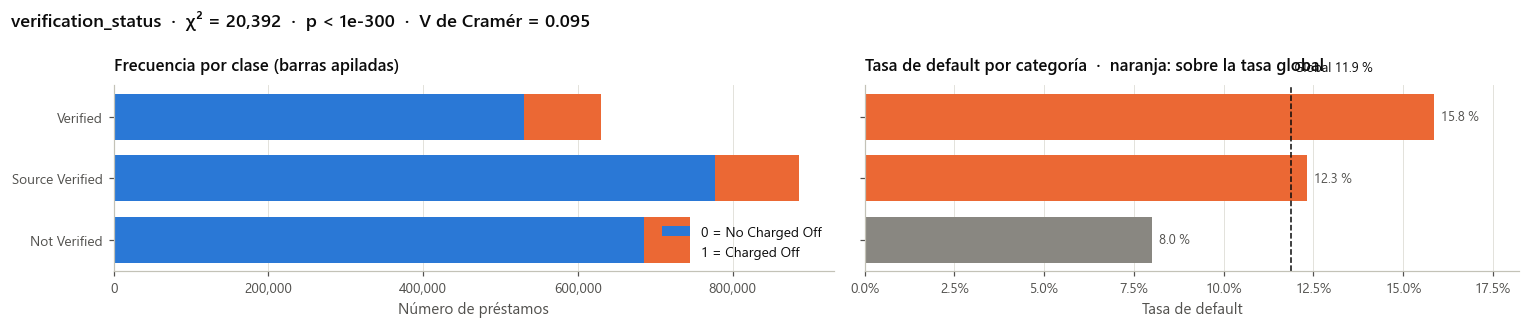

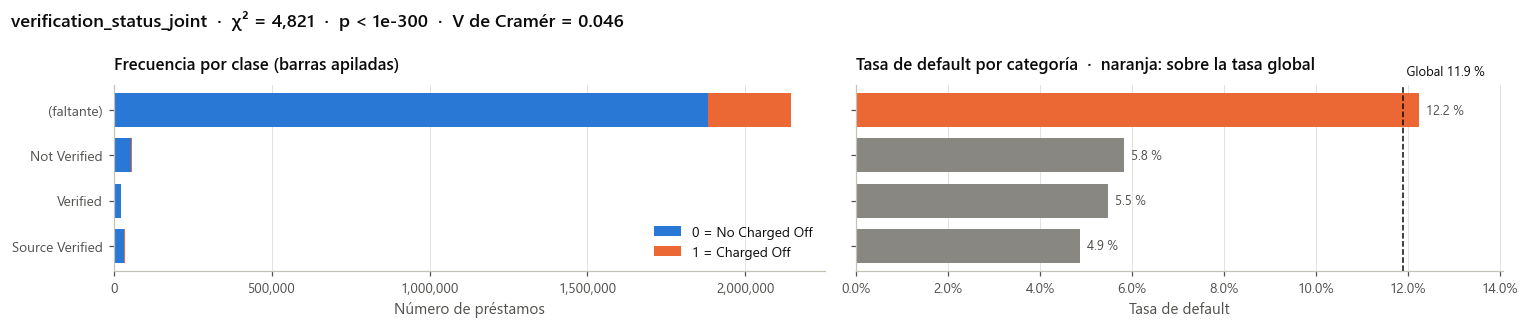

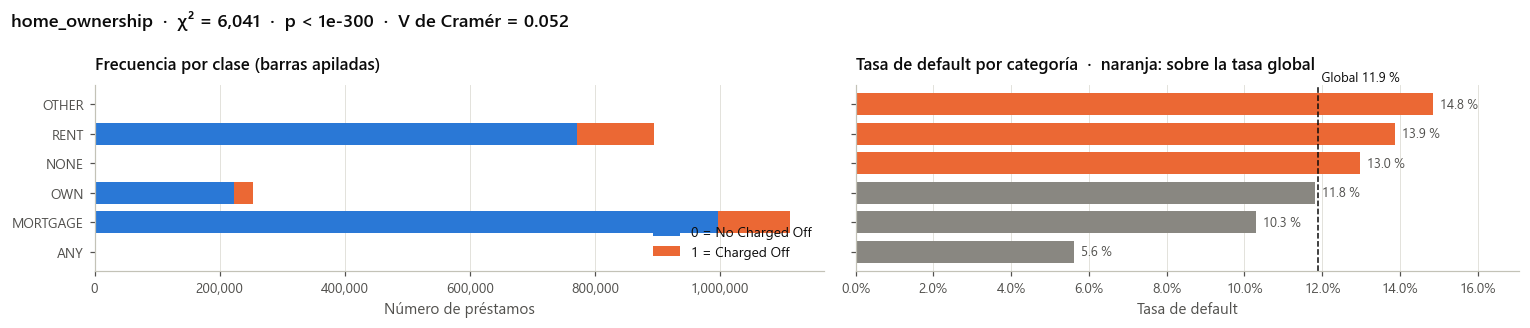

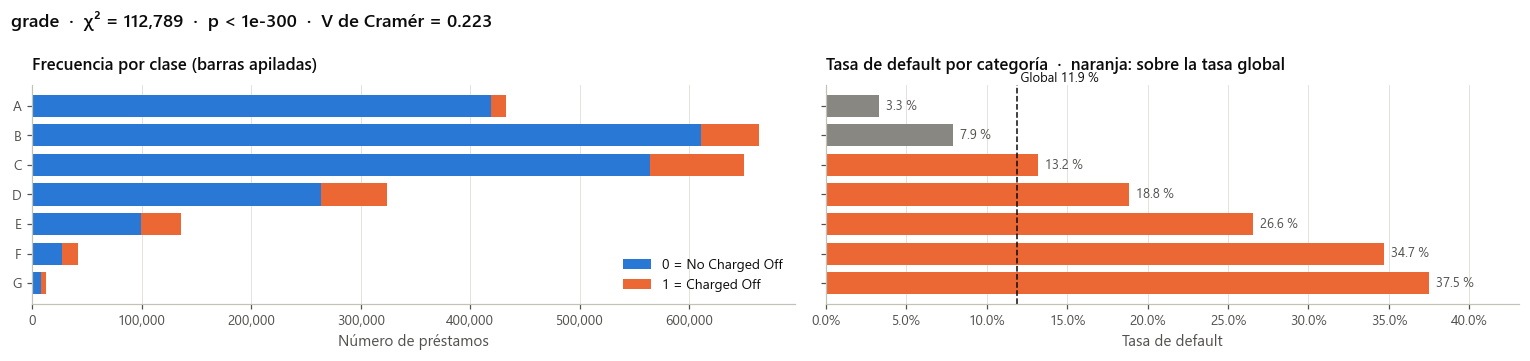

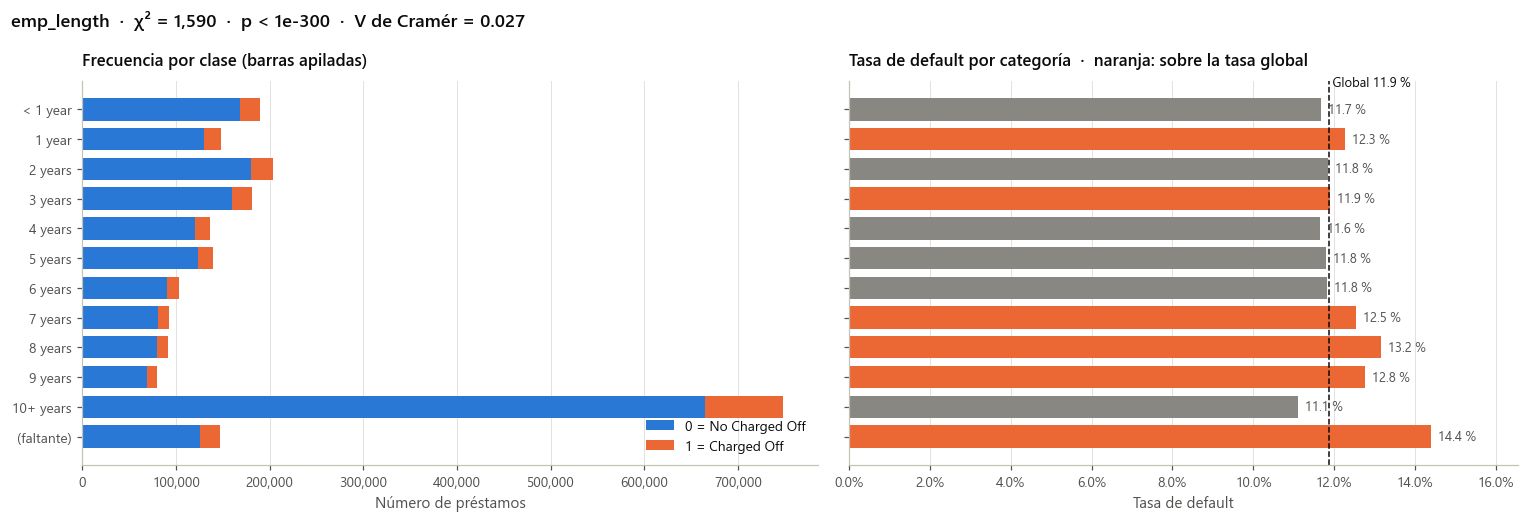

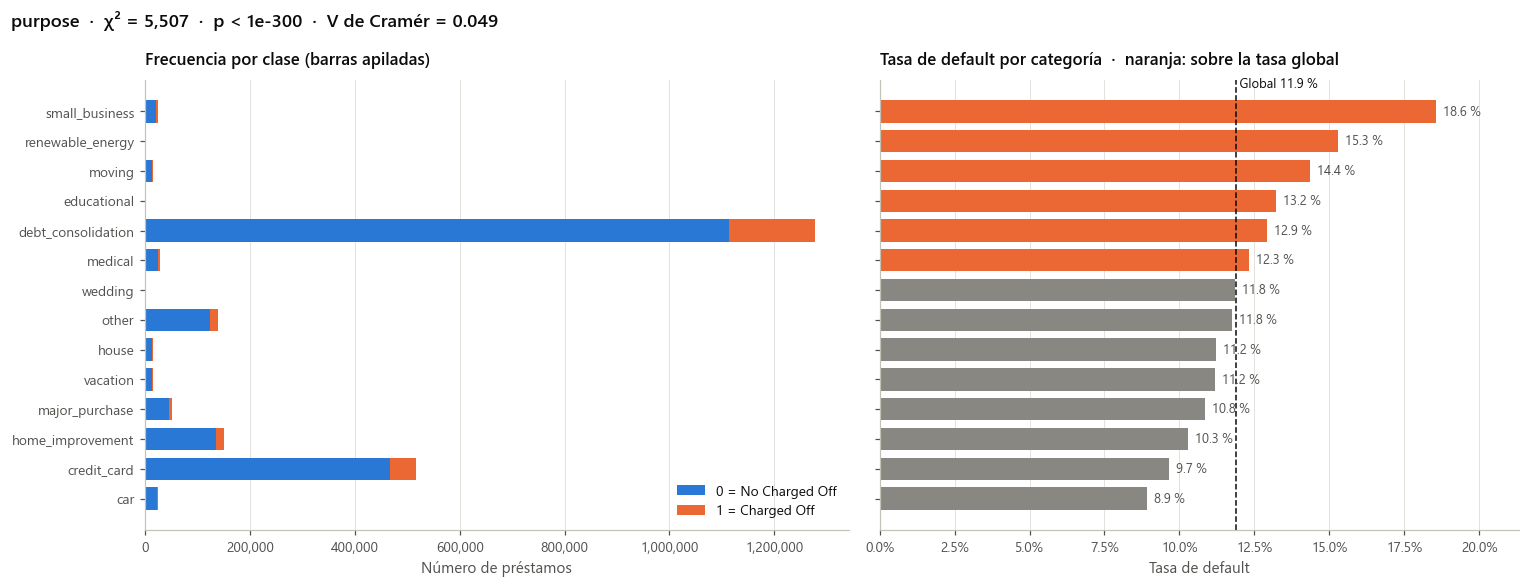

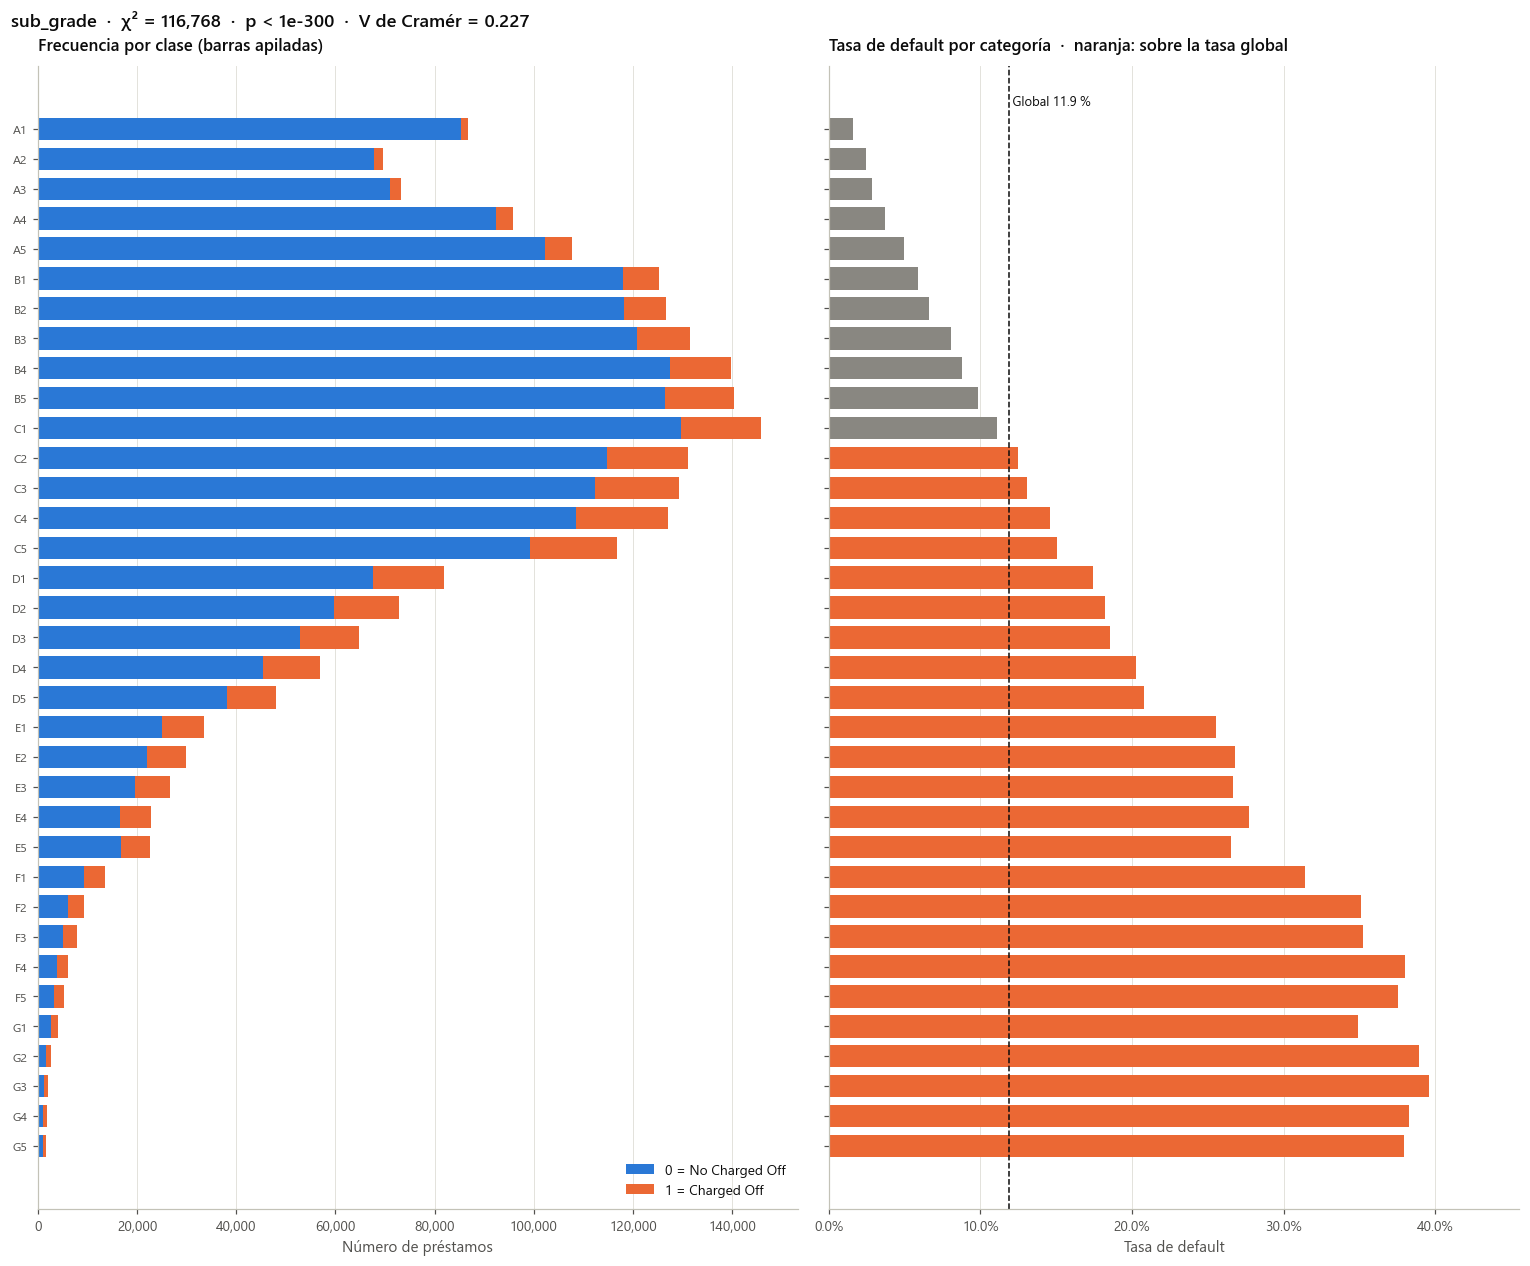

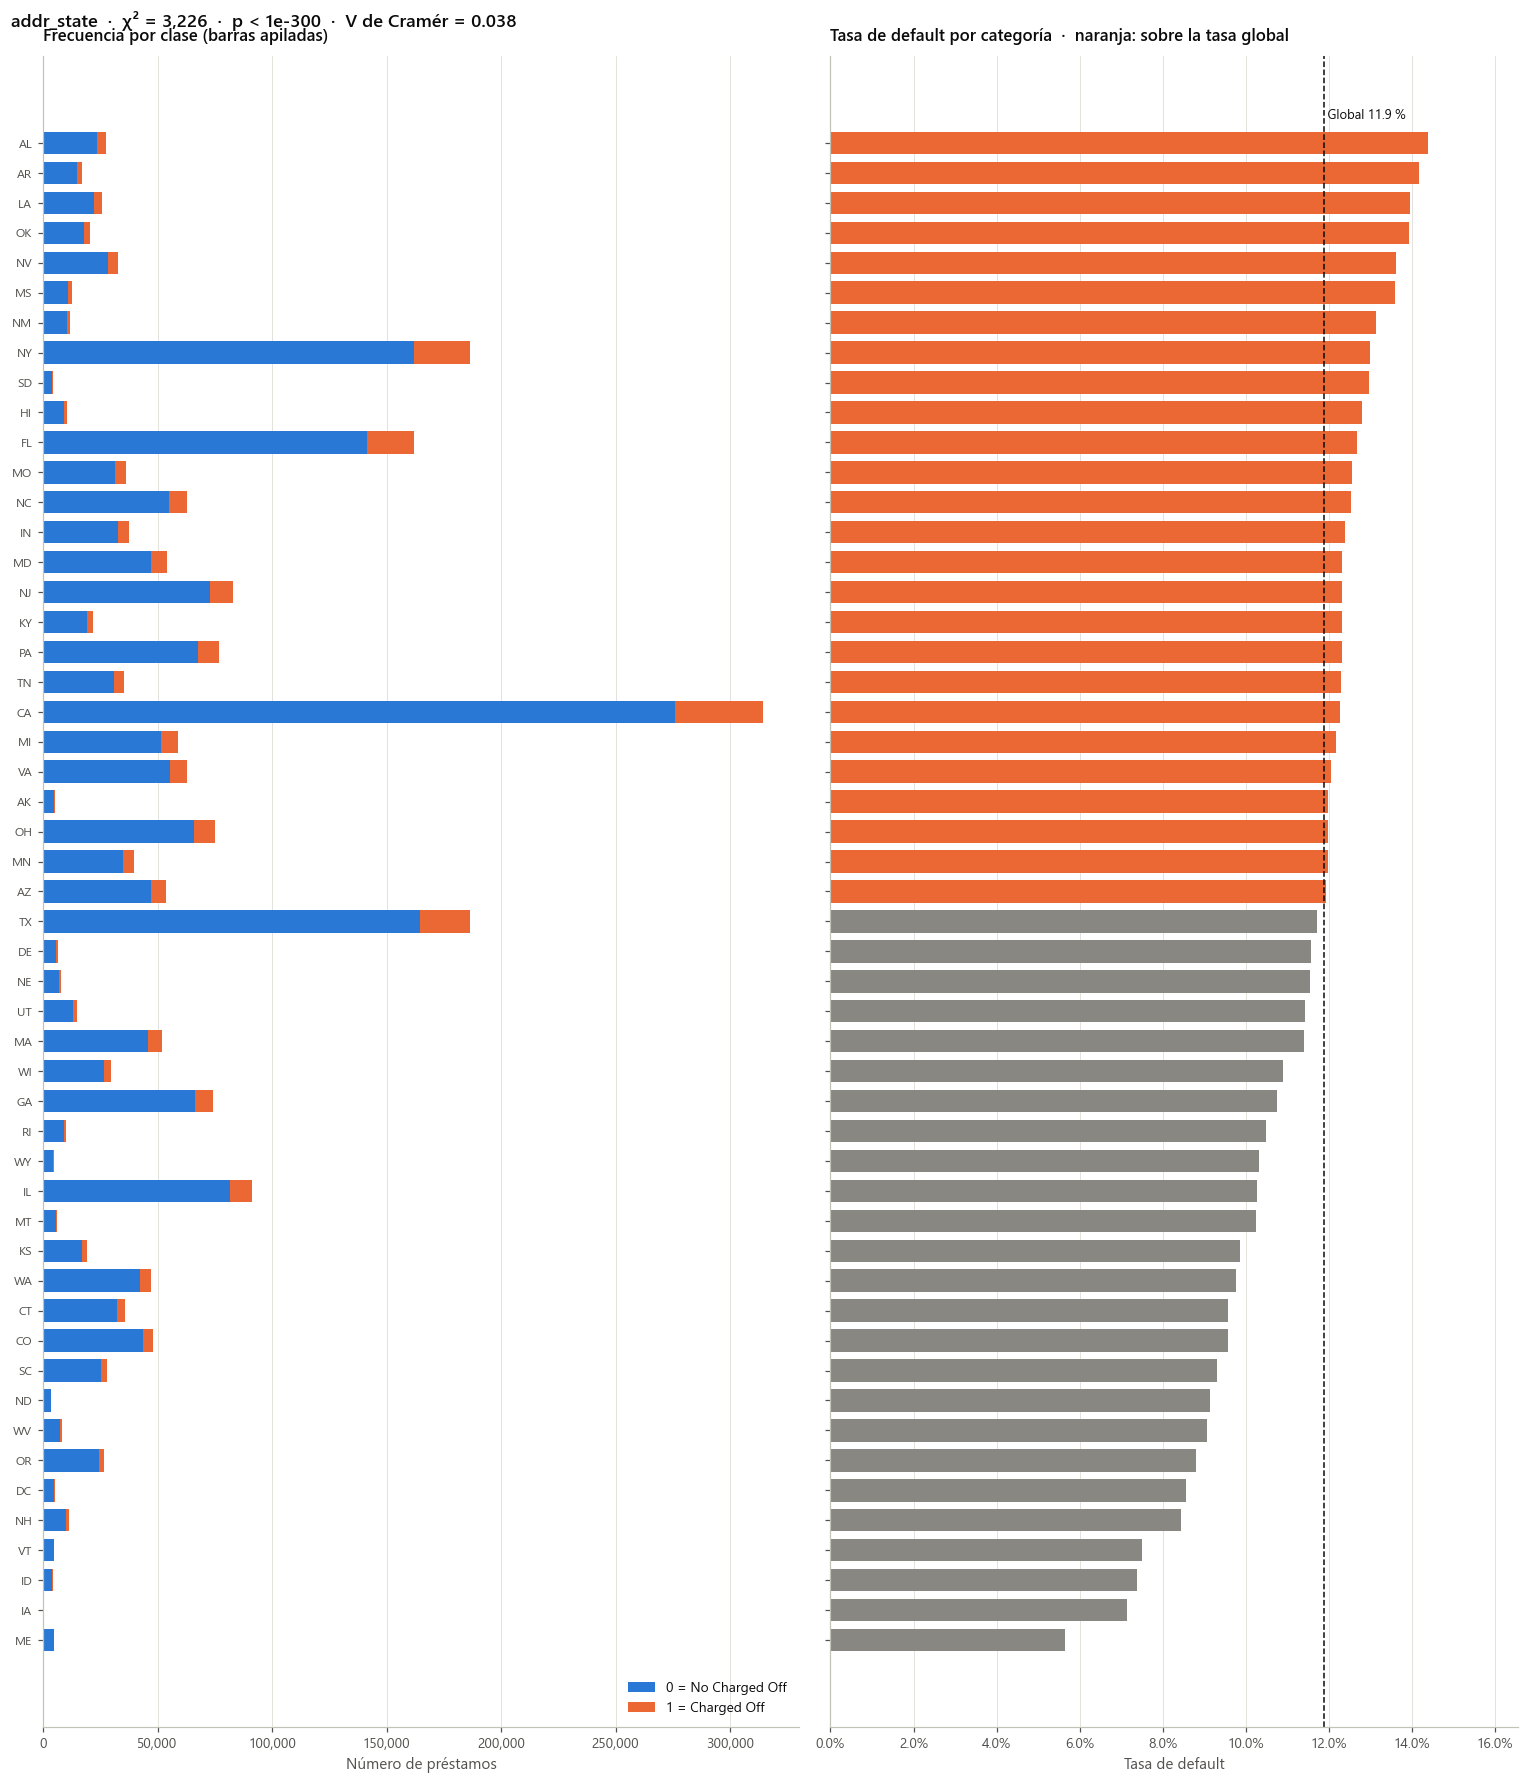

In [35]:
ORDEN["sub_grade"] = sorted(tablas_cat["sub_grade"].index)

for col in [c for c in tablas_cat if c not in FUGA_CAT]:
    tabla = tablas_cat[col]
    if col in ORDEN:
        tabla = tabla.loc[[c for c in ORDEN[col] if c in tabla.index][::-1]]
    else:
        tabla = tabla.sort_values("tasa_default")
    n = len(tabla)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(3, 0.3 * n + 1.2)), sharey=True,
                                   gridspec_kw={"width_ratios": [1.1, 1]})

    # Panel 1: frecuencia apilada
    ax1.barh(tabla.index, tabla["n_fully_paid"], color=CLASE_COLOR[0], height=0.75, label=CLASE_NOMBRE[0])
    ax1.barh(tabla.index, tabla["n_charged_off"], left=tabla["n_fully_paid"],
             color=CLASE_COLOR[1], height=0.75, label=CLASE_NOMBRE[1])
    ax1.xaxis.set_major_formatter(fmt_miles)
    ax1.set_xlabel("Número de préstamos")
    ax1.set_title("Frecuencia por clase (barras apiladas)")
    ax1.legend(loc="lower right")

    # Panel 2: tasa de default
    ax2.barh(tabla.index, tabla["tasa_default"], height=0.75,
             color=np.where(tabla["tasa_default"] > TASA_GLOBAL, COLOR["secundario"], COLOR["tenue"]))
    ax2.axvline(TASA_GLOBAL, color=COLOR["texto"], linestyle="--", linewidth=1)
    ax2.text(TASA_GLOBAL, n - 0.3, f" Global {TASA_GLOBAL:.1f} %", fontsize=8.5,
             color=COLOR["texto"], va="bottom")
    if n <= 20:
        for i, v in enumerate(tabla["tasa_default"]):
            ax2.text(v, i, f"  {v:.1f} %", va="center", fontsize=8.5, color=COLOR["texto_2"])
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_xlabel("Tasa de default")
    ax2.set_title("Tasa de default por categoría  ·  naranja: sobre la tasa global")
    ax2.margins(x=0.15)

    for ax in (ax1, ax2):
        ax.grid(axis="y", visible=False)
        ax.tick_params(axis="y", labelsize=8 if n > 20 else 9)

    fila = pruebas_cat.loc[col]
    fig.suptitle(f"{col}  ·  χ² = {fila['chi2']:,.0f}  ·  {fmt_p(fila['p_value'])}  ·  V de Cramér = {fila['V_Cramer']:.3f}",
                 x=0.01, ha="left", fontsize=12, fontweight="semibold")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"03_default_por_{col}.png")
    plt.show()


### Análisis de las barras apiladas y de la tasa de default por categoría

**Cómo leer cada figura.** El panel izquierdo muestra el **volumen** (préstamos por categoría y cuántos son Charged Off). El derecho muestra el **riesgo** (tasa de default frente a la global, 11.88 %). Volumen y riesgo no coinciden: las categorías pequeñas casi no se ven a la izquierda, pero pueden tener las tasas más altas a la derecha.

**1. `grade` (V = 0.223).** La tasa **crece de forma monótona**: A 3.3 %, B 7.9 %, C 13.2 %, D 18.8 %, E 26.6 %, F 34.7 % y G 37.5 %. El volumen se concentra en B y C (29 % cada uno), mientras que F y G, las de mayor riesgo, son solo el 2.4 % de los préstamos. C es el primer grado sobre la tasa global. **Es ordinal:** se codificará como número (A = 1, …, G = 7).

**2. `sub_grade` (V = 0.227).** Refina el patrón con 35 niveles, desde 1.6 % hasta 39.6 %. Hay diferencias dentro de cada grado, lo que explica su V algo mayor que la de `grade`. En F y G hay pequeñas irregularidades por el bajo volumen. Contiene toda la información de `grade`: **se conserva `sub_grade`**.

**3. `verification_status` (V = 0.095).** Resultado **contraintuitivo**: Verified 15.9 %, Source Verified 12.3 % y Not Verified 8.0 %, con volúmenes similares (28 %, 39 % y 33 %). Lending Club exige verificar los ingresos a los solicitantes que considera más riesgosos, así que la verificación **refleja el riesgo percibido**. Se mantienen las 3 categorías.

**4. `term` (V = 0.084).** Los préstamos a 60 meses tienen más default (16.2 % frente a 10.1 %) y son el 29 % del volumen. La diferencia es menor de lo esperado porque muchos préstamos a 60 meses **todavía están vigentes** y cuentan como clase 0 (Parte 21). Se codificará como binaria.

**5. `home_ownership` (V = 0.052).** RENT 13.9 %, OWN 11.8 % y MORTGAGE 10.3 %: tener hipoteca se asocia con menos riesgo. ANY, OTHER y NONE tienen tasas inestables (5.6 %–14.8 %) por su bajo volumen (54 a 996 préstamos): **se unifican en "OTHER"**.

**6. `purpose` (V = 0.049).** El volumen está dominado por `debt_consolidation` (56.5 %) y `credit_card` (22.9 %), pero el riesgo tiene otra jerarquía: **`small_business` 18.6 %** (la más alta), `renewable_energy` 15.3 % y `moving` 14.4 %. Las de menor riesgo son `car` (8.9 %) y `credit_card` (9.7 %). Las categorías con menos del 1 % se agruparán en "Otros".

**7. `addr_state` (V = 0.038).** Tasas entre 5.6 % y 14.4 %, con un patrón geográfico débil y 51 categorías. Conviene **agruparla por región** o usar codificación por tasa de default (target encoding), en lugar de 50 variables dummy.

**8. `emp_length` (V = 0.027).** Las tasas por antigüedad son **casi planas** (11.1 %–13.2 %). La categoría **"(faltante)" tiene 14.4 %**, la más alta: no declarar el empleo es la señal útil. Esto confirma la categoría "Missing" (Parte 38).

**9. `initial_list_status` (V = 0.070), `disbursement_method` (V = 0.059), `application_type` (V = 0.049) y `verification_status_joint` (V = 0.046).** Muestran diferencias grandes (por ejemplo, DirectPay 1.8 % y Joint App 5.3 %), pero se explican por la **fecha de emisión**: estas categorías corresponden sobre todo a préstamos de 2016–2018, que aún están vigentes (Parte 21). No deben interpretarse como menor riesgo.

**Síntesis**

| Grupo | Variables | Decisión |
|---|---|---|
| **Relevantes** | `sub_grade` (o `grade`) | Conservar `sub_grade`, con codificación ordinal |
| **Débiles pero útiles** | `verification_status`, `term`, `home_ownership`, `purpose`, `addr_state`, `emp_length` | Conservar, agrupando categorías raras y `addr_state` por región |
| **Influidas por la fecha** | `initial_list_status`, `application_type`, `disbursement_method` | Usar con cautela, controlando por el año de emisión; `disbursement_method` se elimina (96.5 % Cash) |
| **Eliminar** | `verification_status_joint` | Más de 70 % de nulos |

**Observación general.** Las categorías de mayor riesgo son las de **menor volumen** (F, G, `small_business`, "(faltante)"). Esto refuerza la necesidad de tratar el desbalance de clases (7.4 : 1) y de usar métricas distintas de la exactitud.


Parte 28. Categoría de alto riesgo

Se marcan las categorías cuya tasa de default supera 1.25 veces la global (> 14.85 %) y que tienen al menos 1,000 préstamos, para que la tasa sea confiable.

In [36]:
MIN_PRESTAMOS = 1000

# Categorías de alto riesgo en todas las variables sin fuga de información
vars_riesgo = [c for c in tablas_cat if c not in FUGA_CAT]

alto_riesgo = (
    pd.concat({col: tablas_cat[col] for col in vars_riesgo}, names=["variable", "categoria"])
    .query("n_total >= @MIN_PRESTAMOS and tasa_default > @TASA_GLOBAL * 1.25")
    .sort_values("tasa_default", ascending=False)
)

print(f"Categorías de alto riesgo (tasa > {TASA_GLOBAL * 1.25:.2f} % y ≥ {MIN_PRESTAMOS:,} préstamos): "
      f"{len(alto_riesgo)}")
display(alto_riesgo[["n_total", "tasa_default", "dif_vs_global"]]
        .style.format({"n_total": "{:,}", "tasa_default": "{:.2f} %", "dif_vs_global": "{:+.2f} pp"}))


Categorías de alto riesgo (tasa > 14.85 % y ≥ 1,000 préstamos): 30


### Análisis de las categorías de alto riesgo

**Criterio.** Tasa de default > **14.85 %** (1.25 × 11.88 %) y al menos **1,000 préstamos**. Se evaluaron todas las variables sin fuga de información.

**Resultado: 30 categorías de alto riesgo**, en cinco grupos:

**1. Calidad crediticia baja (25 de 30):** los grados **D (18.8 %), E (26.6 %), F (34.7 %) y G (37.5 %)** y los subgrados de **C5 (15.1 %) a G5**, con un máximo en **G3 (39.6 %)**. Desde C5 hasta G5 hay **630,757 préstamos (27.9 % de la cartera)**. El umbral se cruza dentro del grado C: C5 es de alto riesgo aunque el grado C en conjunto (13.2 %) no lo sea.

**2. Plazo largo:** `term` = 60 months (**16.2 %**; 650,914 préstamos). Es la categoría de alto riesgo **con mayor volumen**.

**3. Propósito:** `small_business` (**18.6 %**; 24,689 préstamos) y `renewable_energy` (15.3 %; 1,445 préstamos).

**4. Verificación del ingreso:** `verification_status` = Verified (**15.9 %**; 629,631 préstamos). Lending Club verifica a los solicitantes que considera más riesgosos.

**5. Tipo de listado:** `initial_list_status` = f (15.2 %). Esta asociación está **influida por la fecha**: los préstamos "f" son sobre todo antiguos y ya terminaron (Parte 21).

**Conclusiones**
1. **El riesgo está concentrado en el grado del préstamo:** 25 de las 30 categorías son grados o subgrados bajos.
2. Las categorías de alto riesgo coinciden con las variables de **mayor V de Cramér** (`sub_grade` y `grade`, Parte 26).
3. `term`, `purpose` y `verification_status`, aunque tienen una asociación global débil, contienen **segmentos concretos de alto riesgo** que el modelo puede aprovechar.



C. Multicolinealidad

Parte 29. Correlación de Pearson: todas las variables numéricas y heatmap

Se calcula con los 2.26 M préstamos y las 110 variables numéricas que no son constantes.

In [37]:
cols_corr = [c for c in df.select_dtypes(include="number").columns
             if c not in ["id", "member_id", "default"] and df[c].nunique() > 1]
corr_total = df[cols_corr].corr(method="pearson")

UMBRAL_CORR = 0.7
triangulo = corr_total.where(np.triu(np.ones(corr_total.shape, dtype=bool), k=1))
pares_altos = (triangulo.stack().rename("r").reset_index()
               .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
               .assign(abs_r=lambda d: d["r"].abs())
               .query("abs_r > @UMBRAL_CORR")
               .sort_values("abs_r", ascending=False))

print(f"Pares con |r| > {UMBRAL_CORR}: {len(pares_altos)} de {triangulo.count().sum():,}")
display(pares_altos.head(30).style.format({"r": "{:.3f}", "abs_r": "{:.3f}"}).hide(axis="index"))

print("\nEntre las variables clave (NUM_VARS):")
display(pares_altos[pares_altos["variable_1"].isin(NUM_VARS) & pares_altos["variable_2"].isin(NUM_VARS)]
        .style.format({"r": "{:.3f}", "abs_r": "{:.3f}"}).hide(axis="index"))


Pares con |r| > 0.7: 76 de 5,995


variable_1,variable_2,r,abs_r
hardship_amount,orig_projected_additional_accrued_interest,1.000,1.000
sec_app_fico_range_low,sec_app_fico_range_high,1.000,1.000
fico_range_low,fico_range_high,1.000,1.000
out_prncp,out_prncp_inv,1.000,1.000
loan_amnt,funded_amnt,1.000,1.000
total_pymnt,total_pymnt_inv,0.999,0.999
funded_amnt,funded_amnt_inv,0.999,0.999
loan_amnt,funded_amnt_inv,0.999,0.999
open_acc,num_sats,0.999,0.999
num_actv_rev_tl,num_rev_tl_bal_gt_0,0.984,0.984



Entre las variables clave (NUM_VARS):


variable_1,variable_2,r,abs_r
loan_amnt,installment,0.946,0.946
open_acc,total_acc,0.718,0.718


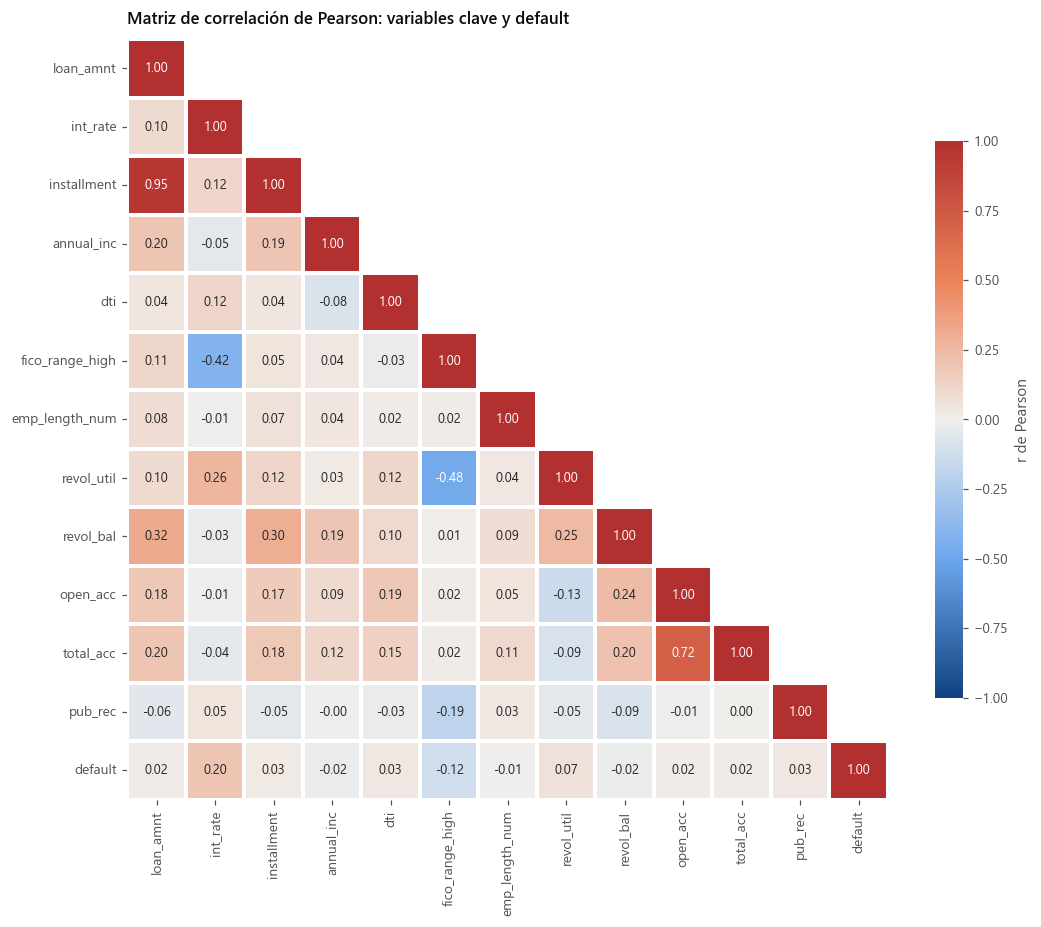

Bloques de variables con |r| > 0.7: 22 (60 variables en total)


,n_variables,r_promedio,variables
bloque,,,
1,8,0.83,"loan_amnt, funded_amnt, funded_amnt_inv, installment, hardship_amount, orig_projected_additional_accrued_interest, hardship_payoff_balance_amount, settlement_amount"
2,4,0.76,"open_rv_12m, open_rv_24m, acc_open_past_24mths, num_tl_op_past_12m"
3,4,0.80,"num_actv_bc_tl, num_actv_rev_tl, num_bc_sats, num_rev_tl_bal_gt_0"
4,3,0.91,"total_bal_il, total_bal_ex_mort, total_il_high_credit_limit"
5,3,0.82,"revol_util, bc_util, percent_bc_gt_75"
6,3,0.98,"total_pymnt, total_pymnt_inv, total_rec_prncp"
7,3,0.86,"tot_cur_bal, avg_cur_bal, tot_hi_cred_lim"
8,3,0.89,"open_acc, num_op_rev_tl, num_sats"
9,3,0.84,"mths_since_last_delinq, mths_since_recent_bc_dlq, mths_since_recent_revol_delinq"


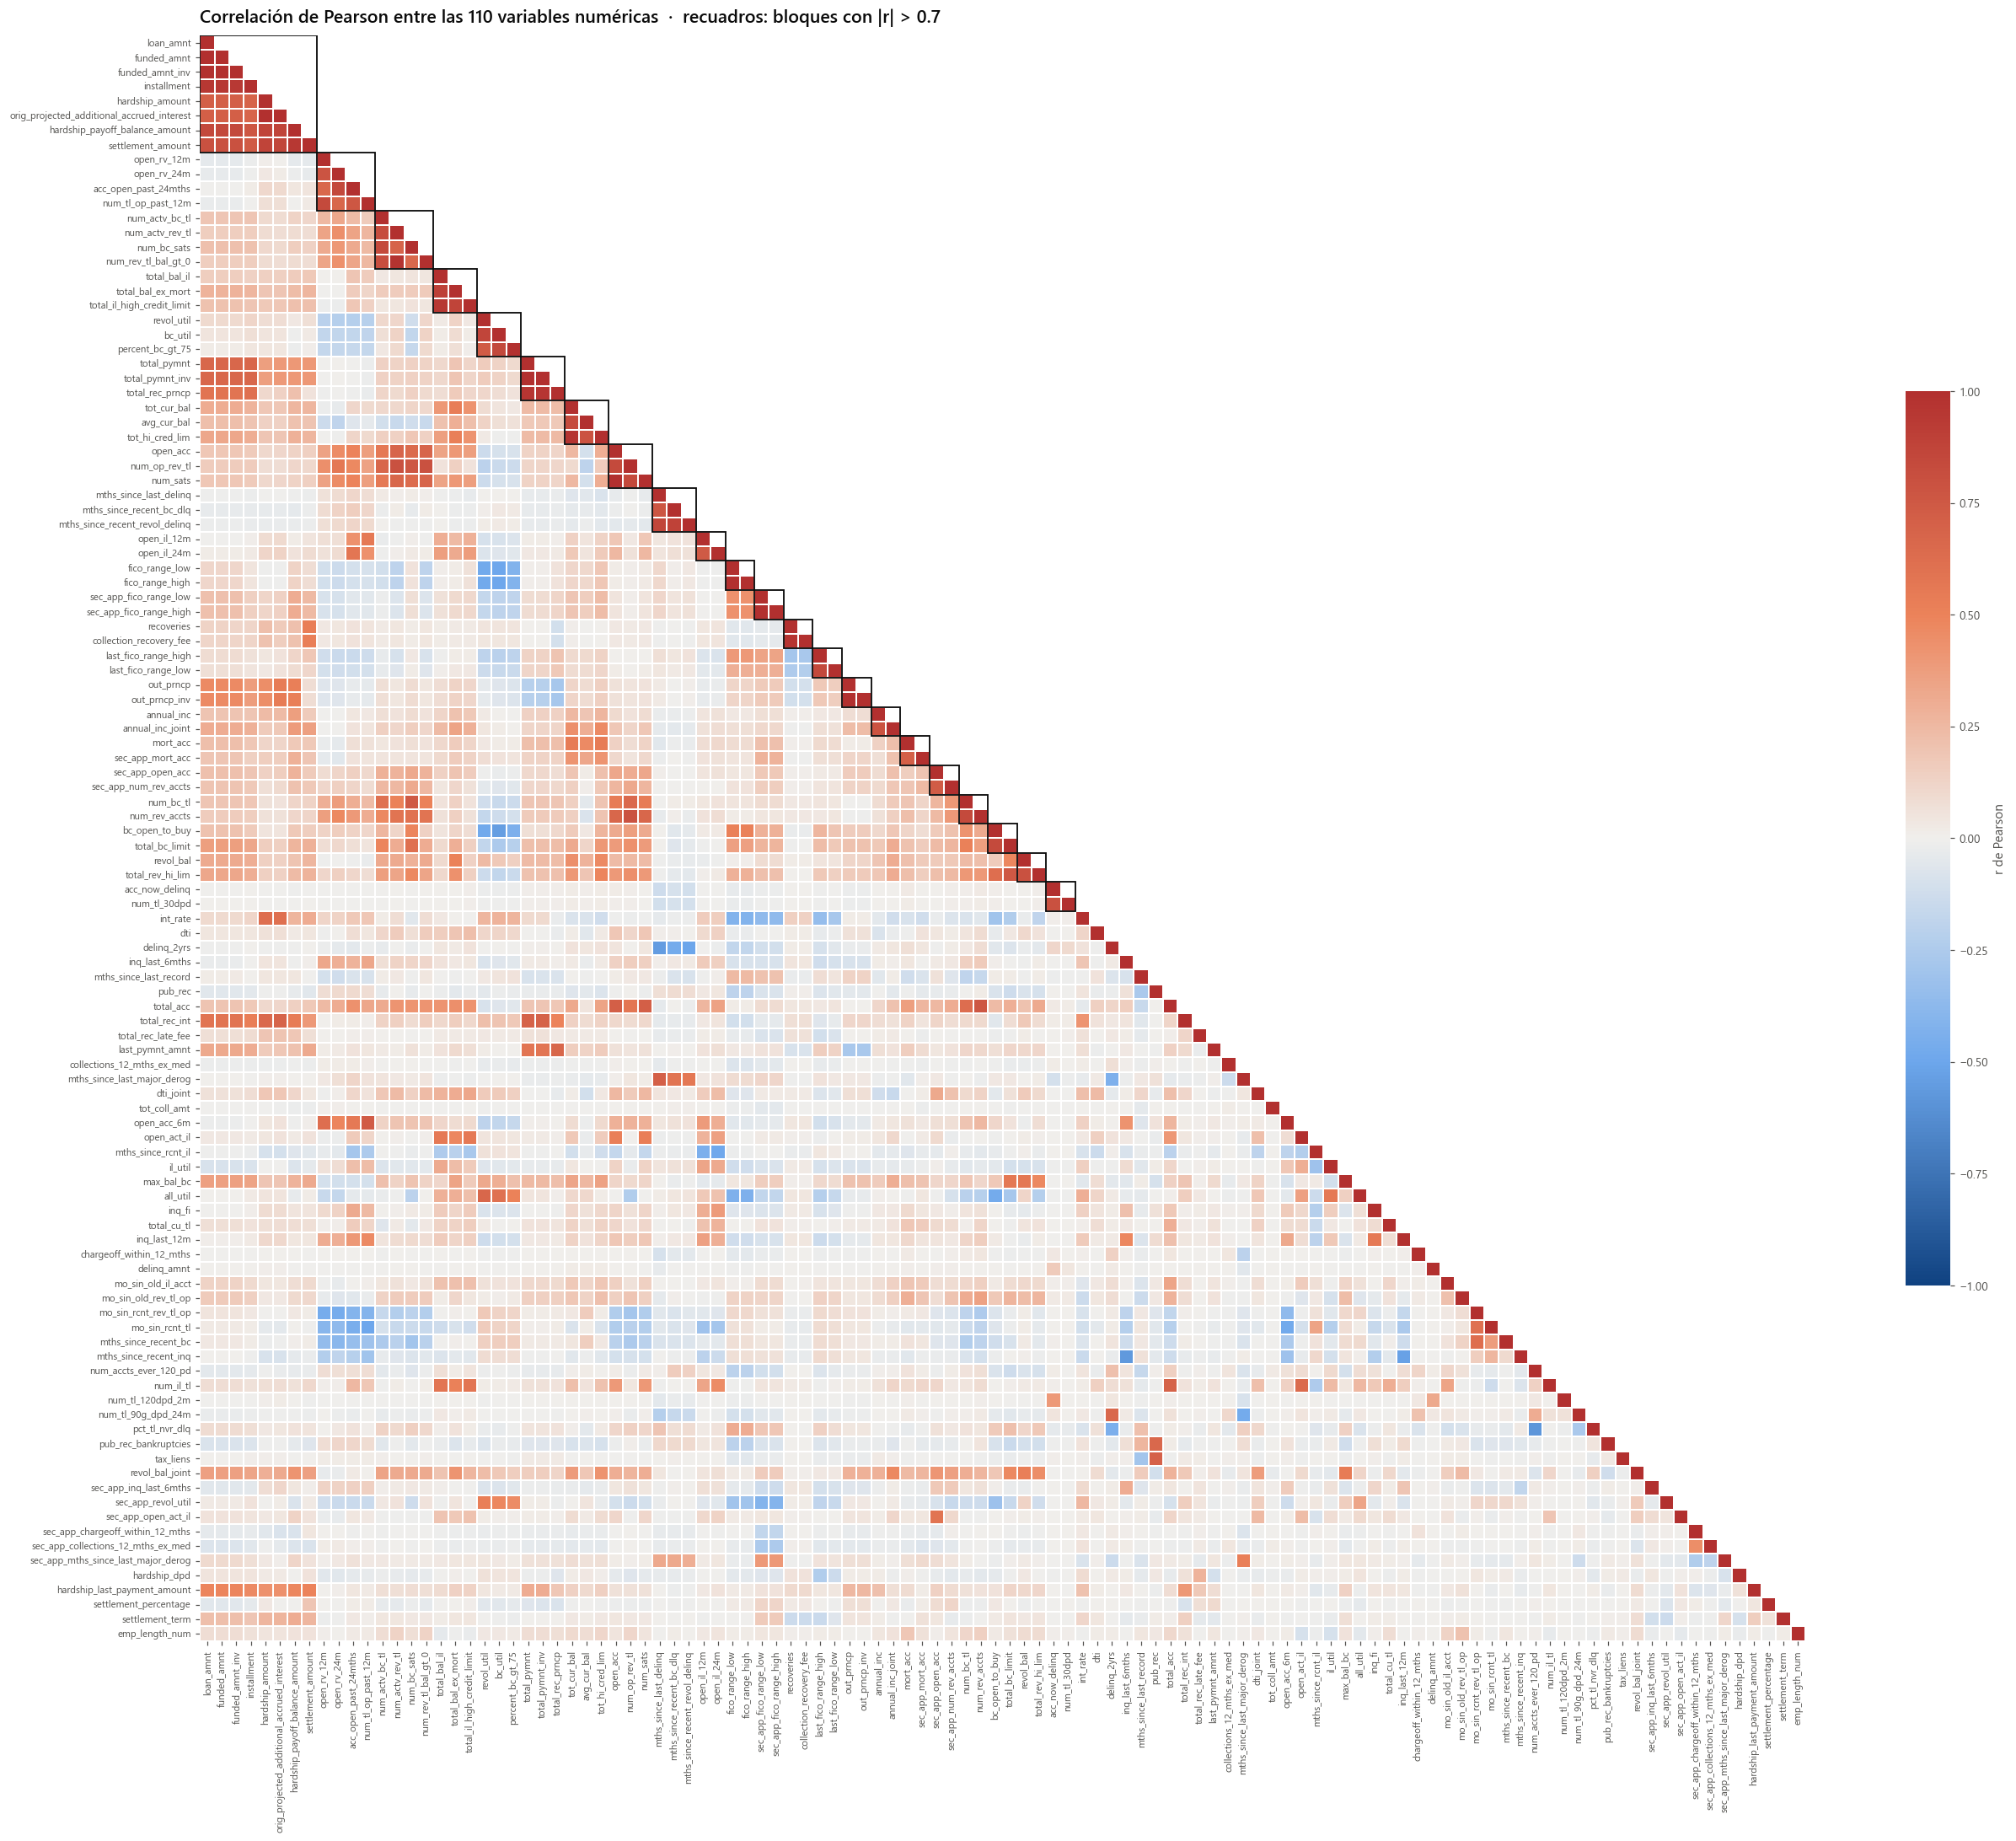

In [38]:
# Paleta divergente: azul (negativo) – gris neutro (0) – rojo (positivo)
CMAP_DIV = LinearSegmentedColormap.from_list("azul_rojo", ["#104281", "#6da7ec", "#f0efec", "#ec835a", "#b2302f"])

# Heatmap 1: variables clave + default (legible, con valores)
corr_clave = dm[NUM_VARS + ["default"]].astype("float64").corr()
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(corr_clave, mask=np.triu(np.ones_like(corr_clave, dtype=bool), k=1), cmap=CMAP_DIV,
            vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8.5},
            linewidths=1.5, linecolor="white", square=True,
            cbar_kws={"shrink": 0.7, "label": "r de Pearson"}, ax=ax)
ax.grid(False)
ax.set_title("Matriz de correlación de Pearson: variables clave y default")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_heatmap_correlacion.png")
plt.show()

# Heatmap 2: las 110 variables, reordenadas para que los bloques correlacionados queden juntos
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# 1) Agrupar variables por similitud (distancia = 1 − |r|) y cortar en |r| = 0.7
distancia = 1 - corr_total.abs().fillna(0)
np.fill_diagonal(distancia.values, 0)
Z = linkage(squareform(distancia.values, checks=False), method="average")
grupo = pd.Series(fcluster(Z, t=1 - UMBRAL_CORR, criterion="distance"), index=corr_total.index)

bloques = [list(v) for _, v in grupo.groupby(grupo).groups.items() if len(v) >= 2]
bloques.sort(key=len, reverse=True)

# 2) Tabla de bloques redundantes
tabla_bloques = pd.DataFrame([{
    "bloque": i,
    "n_variables": len(b),
    "r_promedio": corr_total.loc[b, b].where(~np.eye(len(b), dtype=bool)).abs().stack().mean(),
    "variables": ", ".join(b),
} for i, b in enumerate(bloques, 1)]).set_index("bloque")

print(f"Bloques de variables con |r| > {UMBRAL_CORR}: {len(bloques)} "
      f"({tabla_bloques['n_variables'].sum()} variables en total)")
display(tabla_bloques.style.format({"r_promedio": "{:.2f}"})
        .set_properties(subset=["variables"], **{"text-align": "left"}))

# 3) Heatmap completo: ordenado por bloques, triángulo inferior y recuadros en cada bloque
orden = [c for b in bloques for c in b] + [c for c in corr_total.index
                                           if c not in {x for b in bloques for x in b}]
corr_ord = corr_total.loc[orden, orden]

fig, ax = plt.subplots(figsize=(24, 21))
sns.heatmap(corr_ord, mask=np.triu(np.ones_like(corr_ord, dtype=bool), k=1), cmap=CMAP_DIV,
            vmin=-1, vmax=1, xticklabels=True, yticklabels=True,
            linewidths=0.3, linecolor="white", square=True,
            cbar_kws={"shrink": 0.5, "label": "r de Pearson"}, ax=ax)
ax.tick_params(labelsize=7.5)
ax.grid(False)

inicio = 0
for b in bloques:
    ax.add_patch(plt.Rectangle((inicio, inicio), len(b), len(b), fill=False,
                               edgecolor=COLOR["texto"], linewidth=1.2))
    inicio += len(b)

ax.set_title(f"Correlación de Pearson entre las {len(orden)} variables numéricas  ·  "
             f"recuadros: bloques con |r| > {UMBRAL_CORR}", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_heatmap_correlacion_completo.png", dpi=200)
plt.show()



Lo que sale: hay 76 pares con |r| > 0.7. Casi todos son copias o sumas de la misma cantidad:

loan_amnt, funded_amnt y funded_amnt_inv (r = 1.00)
fico_range_low y fico_range_high (1.00)
open_acc y num_sats (0.999)
loan_amnt e installment (0.95)
tot_cur_bal y tot_hi_cred_lim (0.98)

Fuga de información: varios pares de la lista (total_pymnt, total_rec_prncp, recoveries, out_prncp, last_pymnt_amnt, hardship_*, settlement_*) son datos que solo se conocen después de que el préstamo termina. Además de ser redundantes, habría que excluirlos del modelo porque le "revelan" la respuesta.

El heatmap agrupa las variables por similitud y enmarca 22 bloques con |r| > 0.7. Dentro de cada bloque, las variables miden prácticamente lo mismo; por ejemplo:

Bloque 1: loan_amnt, funded_amnt, funded_amnt_inv, installment (r ≈ 0.95–1.00)
Bloque 11: fico_range_low y fico_range_high (r = 1.00)
Bloque 8: open_acc, num_sats, num_op_rev_tl (r ≈ 0.84–1.00)
Para el modelado basta con conservar una variable por bloque. Además, varios bloques contienen información posterior al otorgamiento del préstamo (total_pymnt, recoveries, out_prncp, last_fico_range_*, hardship_*, settlement_*); esas variables se excluirán por fuga de información, independientemente de su correlación.

Parte 30. V de Cramér entre pares de variables categóricas

variable_1,variable_2,chi2,p_value,V_Cramer
grade,sub_grade,"13,564,008",0.00e+00,1.000
term,sub_grade,"353,601",0.00e+00,0.395
grade,term,"334,351",0.00e+00,0.385
verification_status,sub_grade,"163,699",0.00e+00,0.190
verification_status,grade,"140,465",0.00e+00,0.176
emp_length,application_type,"29,805",0.00e+00,0.115
home_ownership,addr_state,"144,596",0.00e+00,0.113
home_ownership,term,"26,852",0.00e+00,0.109
verification_status,emp_length,"53,081",0.00e+00,0.108
purpose,term,"23,698",0.00e+00,0.102


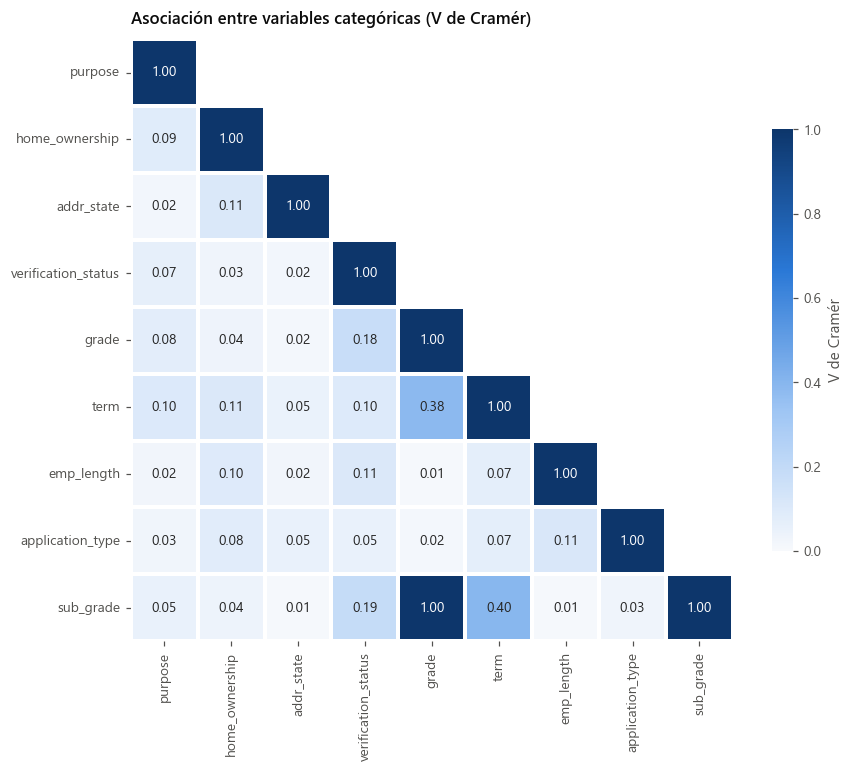

In [39]:
vars_cat_pares = CAT_VARS + ["sub_grade"]
matriz_v = pd.DataFrame(np.eye(len(vars_cat_pares)), index=vars_cat_pares, columns=vars_cat_pares)

filas = []
for i, a in enumerate(vars_cat_pares):
    for b in vars_cat_pares[i + 1:]:
        tabla = pd.crosstab(como_texto(dm[a]), como_texto(dm[b]))
        chi2, p, gl, _ = stats.chi2_contingency(tabla)
        v = cramer_v(tabla)
        matriz_v.loc[a, b] = matriz_v.loc[b, a] = v
        filas.append({"variable_1": a, "variable_2": b, "chi2": chi2, "p_value": p, "V_Cramer": v})

pares_cat = pd.DataFrame(filas).sort_values("V_Cramer", ascending=False)
display(pares_cat.head(10).style.format({"chi2": "{:,.0f}", "p_value": "{:.2e}", "V_Cramer": "{:.3f}"})
        .hide(axis="index"))

CMAP_SEC = LinearSegmentedColormap.from_list("azul", ["#f7f9fc", "#9ec5f4", "#2a78d6", "#0d366b"])
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(matriz_v, mask=np.triu(np.ones_like(matriz_v, dtype=bool), k=1), cmap=CMAP_SEC,
            vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=1.5, linecolor="white", square=True,
            cbar_kws={"shrink": 0.7, "label": "V de Cramér"}, ax=ax)
ax.grid(False)
ax.set_title("Asociación entre variables categóricas (V de Cramér)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_heatmap_cramer.png")
plt.show()


La única asociación fuerte entre variables categóricas es `grade` ↔ `sub_grade` (**V = 1.00**): una contiene a la otra, así que se conservará solo `sub_grade`. Le siguen `term` con `sub_grade` (V = 0.40) y con `grade` (V = 0.39), porque los préstamos a 60 meses suelen tener grados peores, y `verification_status` con el grado (V ≈ 0.18–0.19). El resto de pares tiene asociaciones débiles (V < 0.12), así que no hay más redundancias entre las variables categóricas.

Parte 31. Redundancia entre tipos de variables y decisión de exclusión

Para una variable categórica frente a una numérica se usa la razón de correlación η: va de 0 a 1 y mide cuánto de la variable numérica explica la categoría.

In [40]:
def razon_correlacion(categorica, numerica):
    datos = pd.DataFrame({"c": categorica, "y": numerica.astype("float64")}).dropna()
    medias = datos.groupby("c", observed=True)["y"].agg(["mean", "count"])
    ss_entre = (medias["count"] * (medias["mean"] - datos["y"].mean()) ** 2).sum()
    ss_total = ((datos["y"] - datos["y"].mean()) ** 2).sum()
    return np.sqrt(ss_entre / ss_total)

redundancias = pd.DataFrame([
    ("fico_range_high", "int_rate",        "r Pearson", dm["fico_range_high"].corr(dm["int_rate"])),
    ("fico_range_low",  "fico_range_high", "r Pearson", df["fico_range_low"].corr(df["fico_range_high"])),
    ("loan_amnt",       "installment",     "r Pearson", dm["loan_amnt"].corr(dm["installment"])),
    ("open_acc",        "total_acc",       "r Pearson", dm["open_acc"].corr(dm["total_acc"])),
    ("grade",           "int_rate",        "η",         razon_correlacion(dm["grade"], dm["int_rate"])),
    ("sub_grade",       "int_rate",        "η",         razon_correlacion(dm["sub_grade"], dm["int_rate"])),
    ("grade",           "sub_grade",       "V Cramér",  matriz_v.loc["grade", "sub_grade"]),
    ("term",            "int_rate",        "η",         razon_correlacion(dm["term"], dm["int_rate"])),
], columns=["variable_1", "variable_2", "medida", "valor"])
display(redundancias.style.format({"valor": "{:.3f}"}).hide(axis="index"))


variable_1,variable_2,medida,valor
fico_range_high,int_rate,r Pearson,-0.416
fico_range_low,fico_range_high,r Pearson,1.000
loan_amnt,installment,r Pearson,0.946
open_acc,total_acc,r Pearson,0.718
grade,int_rate,η,0.953
sub_grade,int_rate,η,0.977
grade,sub_grade,V Cramér,1.000
term,int_rate,η,0.373


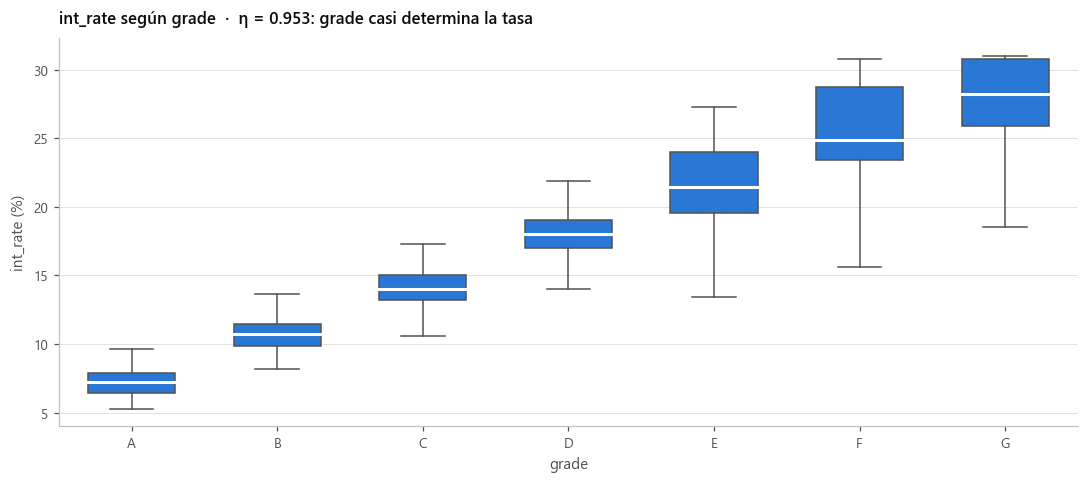

In [41]:
fig, ax = plt.subplots(figsize=(10, 4.5))
datos = [dm.loc[dm["grade"] == g, "int_rate"].dropna() for g in ORDEN["grade"]]
cajas = ax.boxplot(datos, widths=0.6, patch_artist=True, showfliers=False,
                   medianprops=dict(color="white", linewidth=2),
                   whiskerprops=dict(color=COLOR["texto_2"]), capprops=dict(color=COLOR["texto_2"]))
for caja in cajas["boxes"]:
    caja.set(facecolor=COLOR["principal"], edgecolor=COLOR["texto_2"])
ax.set_xticks(range(1, 8), ORDEN["grade"])
ax.set_xlabel("grade")
ax.set_ylabel("int_rate (%)")
ax.grid(axis="x", visible=False)
ax.set_title(f"int_rate según grade  ·  η = {razon_correlacion(dm['grade'], dm['int_rate']):.3f}: "
             "grade casi determina la tasa")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_int_rate_por_grade.png")
plt.show()


Se evaluaron los pares de variables potencialmente redundantes, incluidos los de tipo mixto, con la medida adecuada a cada caso: r de Pearson (numérica–numérica), razón de correlación η (categórica–numérica) y V de Cramér (categórica–categórica).

Redundancias que justifican excluir una variable:
fico_range_low ↔ fico_range_high (r = 1.00) → se conserva fico_range_high.
loan_amnt ↔ installment (r = 0.95) → se conserva loan_amnt.
grade ↔ sub_grade (V = 1.00) → se conserva sub_grade, que tiene más detalle.
La redundancia más relevante es entre tipos distintos: sub_grade explica casi toda la variación de int_rate (η = 0.977; grade, η = 0.953), porque Lending Club fija la tasa según el subgrado asignado. El boxplot lo confirma: cada grado ocupa un rango de tasas propio. Para los modelos lineales se evaluará conservar solo una de las dos (int_rate o sub_grade); para los modelos de árboles pueden mantenerse ambas.
Pares que NO son redundantes: `fico_range_high` ↔ `int_rate` (r = −0.42), el ejemplo del enunciado, tiene una relación solo moderada: la tasa depende del FICO, pero también del grado, el plazo y otros factores. Ambas se conservan, porque cada una aporta información propia sobre `default` (Parte 24). Lo mismo ocurre con `term` → `int_rate` (η = 0.37) y con `open_acc` ↔ `total_acc` (r = 0.72), que miden conceptos distintos.


D. Visualizaciones avanzadas sugeridas por el profesor

Parte 32. Pairplot/matriz de dispersión

Se agrupan el pairplot y la matriz de dispersión, porque el pairplot es una matriz de dispersión coloreada por clase y con la densidad en la diagonal. Usa una muestra estratificada de unos 5,000 préstamos, tal como sugiere el enunciado.

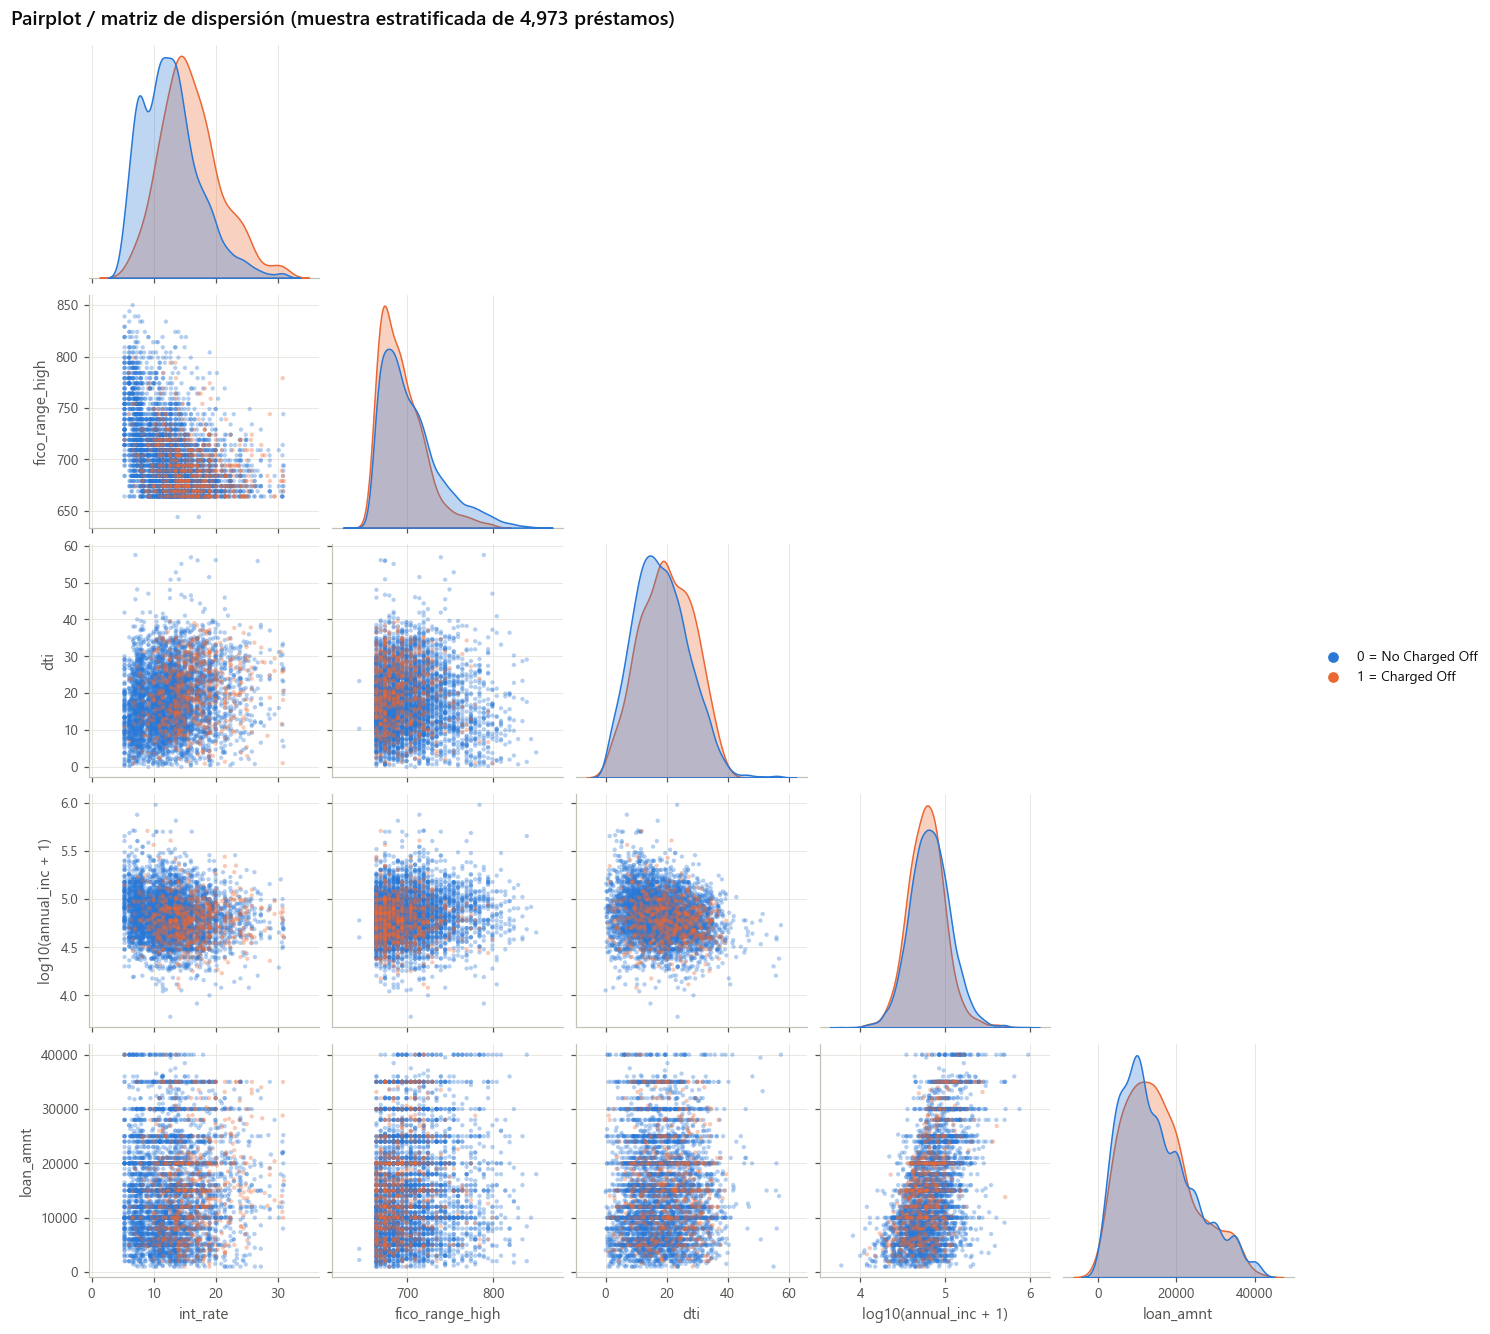

In [42]:
VARS_PAIR = ["int_rate", "fico_range_high", "dti", "annual_inc", "loan_amnt"]

muestra_pair = (dm.groupby("default", group_keys=False)
                  .sample(frac=5000 / len(dm), random_state=42)[VARS_PAIR + ["default"]]
                  .dropna())
muestra_pair = muestra_pair[muestra_pair["dti"] <= muestra_pair["dti"].quantile(0.995)]
muestra_pair["annual_inc"] = np.log10(muestra_pair["annual_inc"].clip(lower=0) + 1)
muestra_pair = muestra_pair.rename(columns={"annual_inc": "log10(annual_inc + 1)"})
muestra_pair["clase"] = muestra_pair["default"].map(CLASE_NOMBRE)
muestra_pair = muestra_pair.sort_values("default")   # los Charged Off se dibujan encima

g = sns.pairplot(muestra_pair.drop(columns="default"), hue="clase", corner=True,
                 palette={CLASE_NOMBRE[k]: CLASE_COLOR[k] for k in (0, 1)},
                 plot_kws=dict(s=8, alpha=0.35, linewidth=0),
                 diag_kws=dict(common_norm=False, fill=True, alpha=0.3),
                 height=2.4)
g._legend.set_title("")
for ax in g.axes.flat:
    if ax is not None:
        ax.grid(True, color=COLOR["rejilla"], linewidth=0.5)
g.fig.suptitle(f"Pairplot / matriz de dispersión (muestra estratificada de {len(muestra_pair):,} préstamos)",
               x=0.01, ha="left", y=1.01, fontsize=13, fontweight="semibold")
g.savefig(FIG_DIR / "03_pairplot.png")
plt.show()


Lo que sale: no aparecen patrones no lineales marcados. Se ve que los Charged Off se concentran en int_rate alto y FICO bajo (esquina inferior derecha de ese panel), y que loan_amnt crece con el ingreso. loan_amnt forma franjas horizontales porque la gente pide montos redondos (10,000, 20,000, 35,000).

E. Valores faltantes (análisis detallado)

Parte 33. Número y porcentaje de nulos por columna

Se reporta el número y el porcentaje de nulos de cada una de las 151 columnas originales sobre los 2,260,668 préstamos. Con la regla del enunciado todo el dataset es la población de análisis, así que las columnas `pct_nulos` y `pct_nulos_modelado` coinciden.

In [43]:
COLS_ORIGINALES = [c for c in df.columns if c not in ["emp_length_num", "default"]]
mask_modelo = df["default"].notna()

nulos_df = df[COLS_ORIGINALES].isna()          # matriz True/False de 2.26 M × 151
nulos_det = pd.DataFrame({
    "tipo": ["numérica" if pd.api.types.is_numeric_dtype(df[c]) else "categórica" for c in COLS_ORIGINALES],
    "n_nulos": nulos_df.sum(),
    "pct_nulos": nulos_df.mean() * 100,
    "pct_nulos_modelado": nulos_df[mask_modelo].mean() * 100,
}, index=COLS_ORIGINALES).sort_values("pct_nulos", ascending=False)

print(f"Columnas analizadas: {len(nulos_det)}  ·  con al menos un nulo: {(nulos_det['n_nulos'] > 0).sum()}")
display(nulos_det.style.format({"n_nulos": "{:,}", "pct_nulos": "{:.2f} %", "pct_nulos_modelado": "{:.2f} %"}))


Columnas analizadas: 151  ·  con al menos un nulo: 113


,tipo,n_nulos,pct_nulos,pct_nulos_modelado
member_id,numérica,"2,260,668",100.00 %,100.00 %
orig_projected_additional_accrued_interest,numérica,"2,252,017",99.62 %,99.62 %
hardship_end_date,categórica,"2,249,751",99.52 %,99.52 %
hardship_start_date,categórica,"2,249,751",99.52 %,99.52 %
hardship_type,categórica,"2,249,751",99.52 %,99.52 %
hardship_reason,categórica,"2,249,751",99.52 %,99.52 %
hardship_status,categórica,"2,249,751",99.52 %,99.52 %
deferral_term,numérica,"2,249,751",99.52 %,99.52 %
hardship_last_payment_amount,numérica,"2,249,751",99.52 %,99.52 %
hardship_payoff_balance_amount,numérica,"2,249,751",99.52 %,99.52 %


Parte 34. Mapa de calor de nulos

Pintar 2.26 M de filas en una imagen no se puede leer. Por eso se agrupan por mes de emisión: cada celda es el % de nulos de esa columna en ese mes. Así se usan todas las filas y, además, se ve cuándo aparece cada variable.

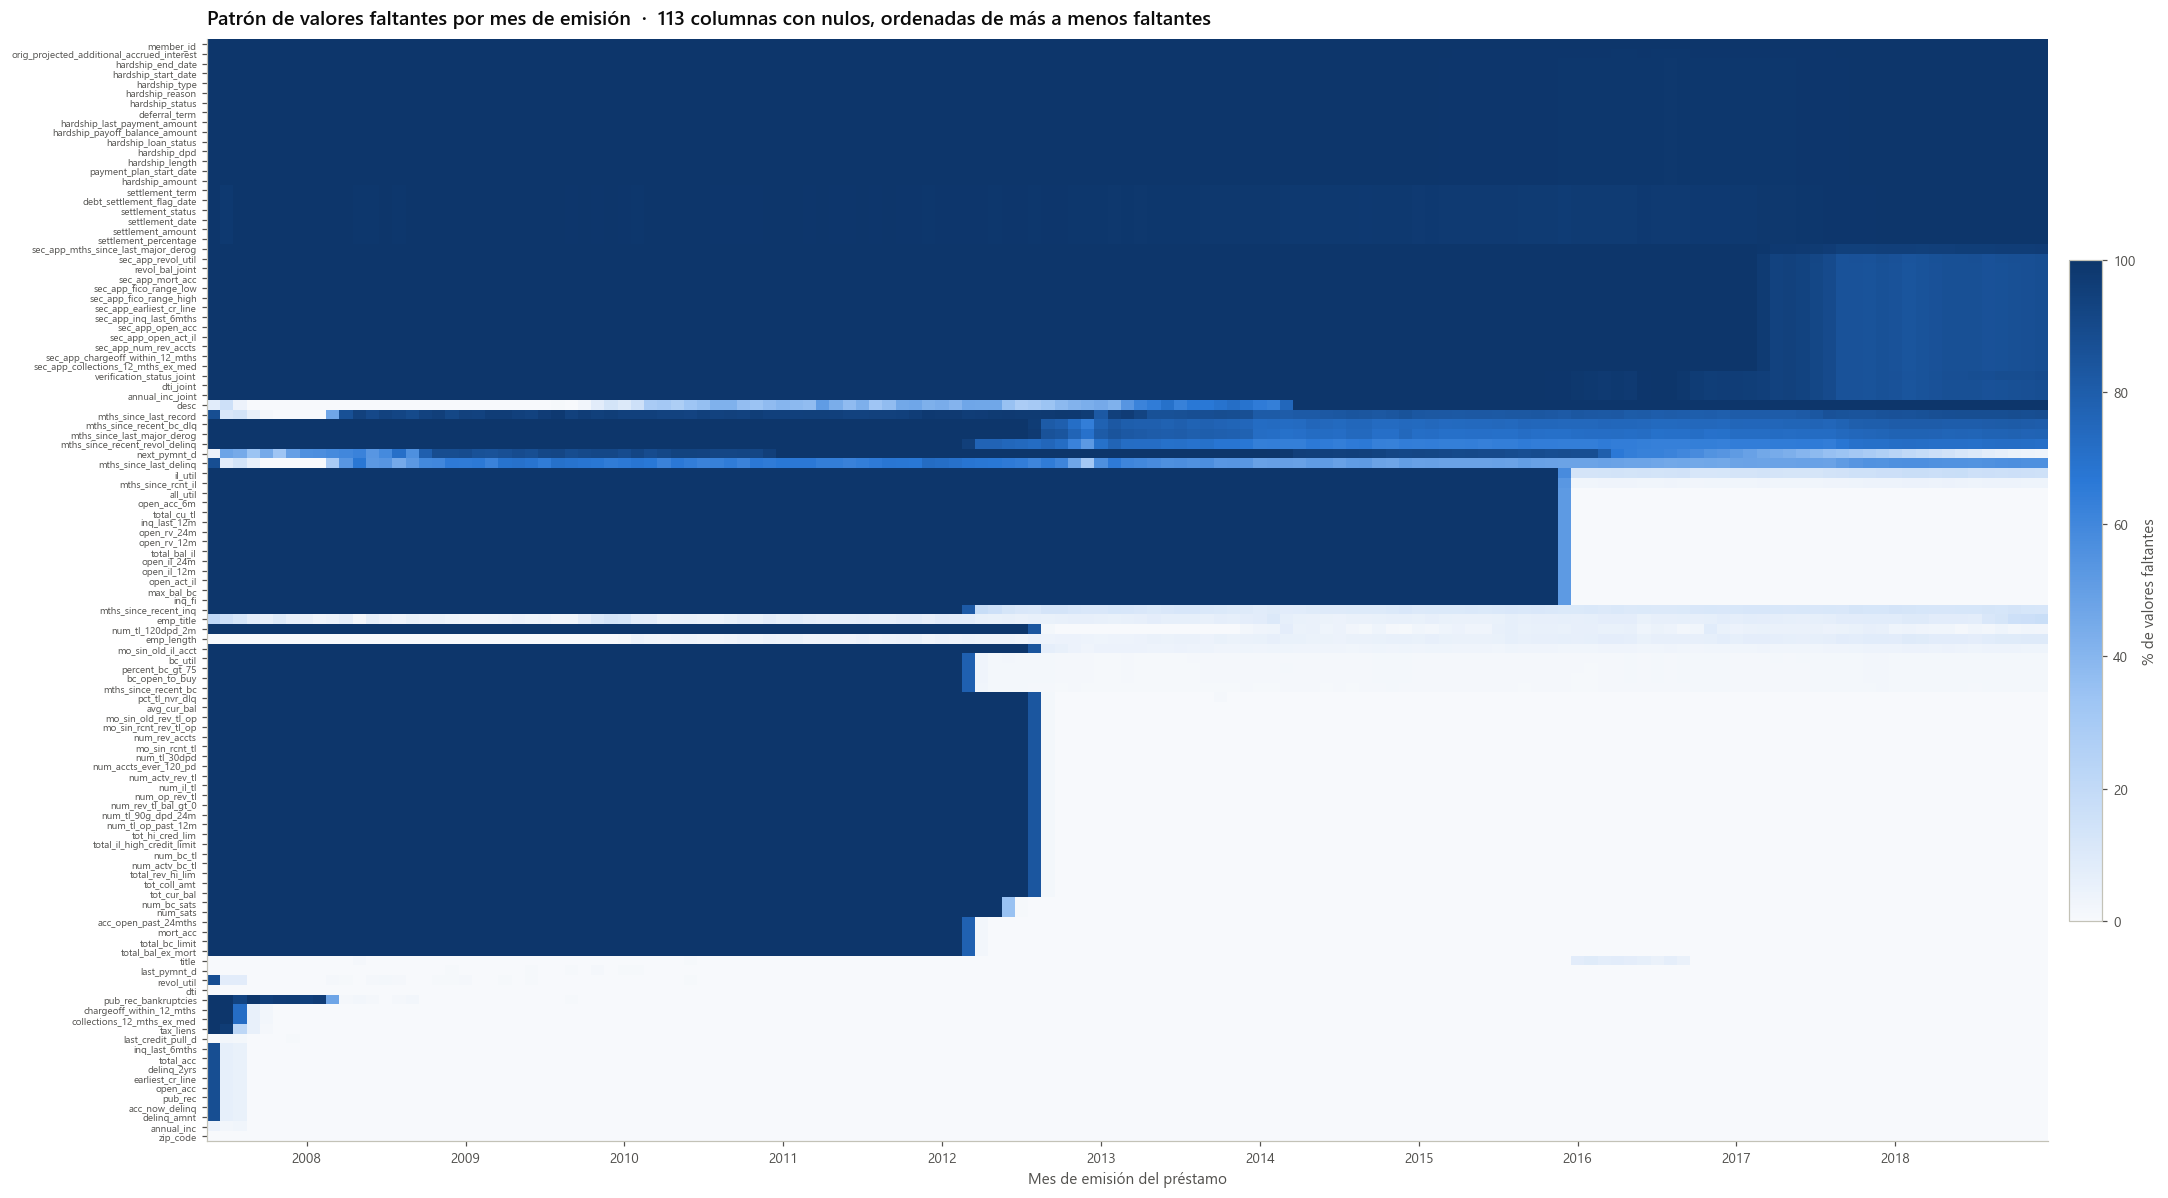

In [44]:
fecha = pd.to_datetime(df["issue_d"].astype(str), format="%b-%Y")
cols_con_nulos = nulos_det.index[nulos_det["n_nulos"] > 0].tolist()

nulos_por_mes = nulos_df[cols_con_nulos].groupby(fecha.dt.to_period("M")).mean() * 100

fig, ax = plt.subplots(figsize=(22, 11))
im = ax.imshow(nulos_por_mes.T.values, aspect="auto", cmap=CMAP_SEC, vmin=0, vmax=100,
               interpolation="nearest")
ax.set_yticks(range(len(cols_con_nulos)), cols_con_nulos, fontsize=6.5)
pos_enero = [i for i, p in enumerate(nulos_por_mes.index) if p.month == 1]
ax.set_xticks(pos_enero, [str(nulos_por_mes.index[i].year) for i in pos_enero])
ax.set_xlabel("Mes de emisión del préstamo")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label("% de valores faltantes")
ax.set_title(f"Patrón de valores faltantes por mes de emisión  ·  {len(cols_con_nulos)} columnas con nulos, "
             "ordenadas de más a menos faltantes", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_mapa_nulos_por_mes.png", dpi=200)
plt.show()


El mapa muestra que la mayoría de los nulos no son aleatorios, sino cronológicos: Lending Club agregó variables en distintas fechas, y los préstamos anteriores quedan vacíos en esas columnas.

Marzo y agosto de 2012: empiezan a registrarse bc_util, mort_acc, tot_cur_bal, num_*_tl, etc.
Diciembre de 2015: aparece el bloque open_acc_6m, il_util, inq_fi, all_util, etc. (38 % de nulos).
2017: aparecen las variables del segundo solicitante (sec_app_*), que solo se llenan en solicitudes conjuntas.
2014: desc deja de usarse.
Las variables hardship_* y settlement_* están casi vacías en todo el periodo.

Parte 35. ¿Se concentran en ciertas columnas?

Se buscan dos cosas: grupos de columnas que tienen exactamente las mismas filas vacías, y la correlación de nulidad, que mide si dos columnas tienden a quedar vacías a la vez.

Grupos de columnas con EXACTAMENTE las mismas filas vacías: 11 (73 columnas)


,n_columnas,pct_nulos,columnas
patrón,,,
1,16,3.11 %,"mo_sin_rcnt_tl, num_tl_30dpd, num_accts_ever_120_pd, num_actv_rev_tl, num_il_tl, num_op_rev_tl, num_rev_tl_bal_gt_0, num_tl_90g_dpd_24m, num_tl_op_past_12m, tot_hi_cred_lim, total_il_high_credit_limit, num_bc_tl, num_actv_bc_tl, total_rev_hi_lim, tot_coll_amt, tot_cur_bal"
2,13,99.52 %,"hardship_end_date, hardship_start_date, hardship_type, hardship_reason, hardship_status, deferral_term, hardship_last_payment_amount, hardship_payoff_balance_amount, hardship_loan_status, hardship_dpd, hardship_length, payment_plan_start_date, hardship_amount"
3,10,95.22 %,"sec_app_mort_acc, sec_app_fico_range_low, sec_app_fico_range_high, sec_app_earliest_cr_line, sec_app_inq_last_6mths, sec_app_open_acc, sec_app_open_act_il, sec_app_num_rev_accts, sec_app_chargeoff_within_12_mths, sec_app_collections_12_mths_ex_med"
4,8,38.31 %,"open_rv_24m, open_rv_12m, total_bal_il, open_il_24m, open_il_12m, open_act_il, max_bal_bc, inq_fi"
5,7,0.00 %,"total_acc, delinq_2yrs, earliest_cr_line, open_acc, pub_rec, acc_now_delinq, delinq_amnt"
6,6,98.49 %,"settlement_term, debt_settlement_flag_date, settlement_status, settlement_date, settlement_amount, settlement_percentage"
7,4,2.21 %,"acc_open_past_24mths, mort_acc, total_bc_limit, total_bal_ex_mort"
8,3,38.31 %,"open_acc_6m, total_cu_tl, inq_last_12m"
9,2,0.01 %,"chargeoff_within_12_mths, collections_12_mths_ex_med"


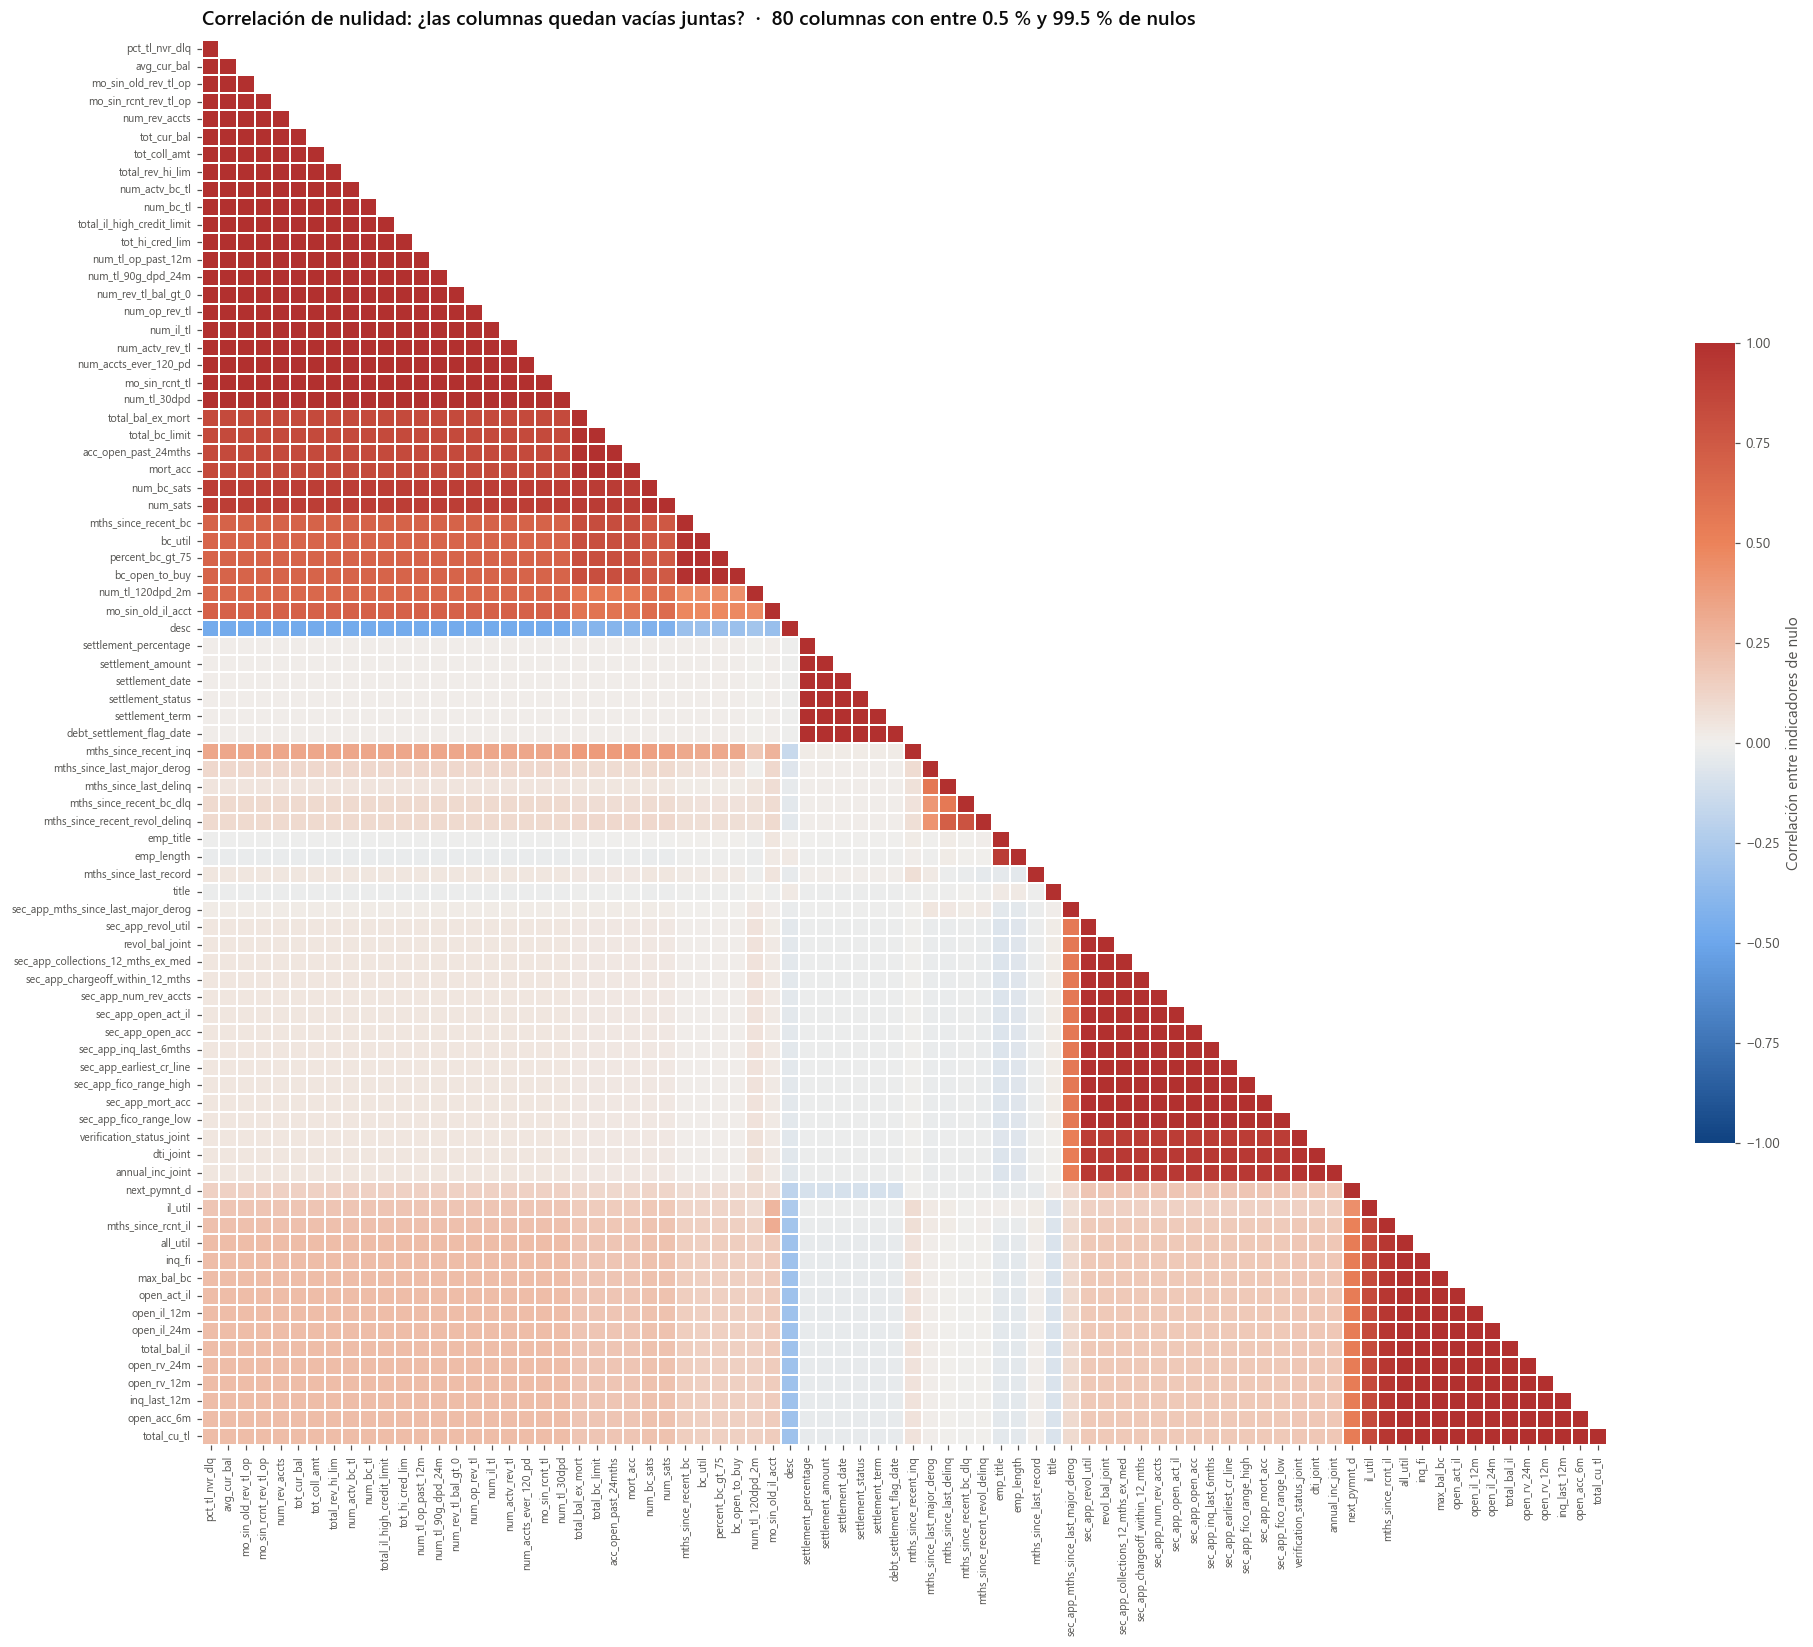

In [45]:
import hashlib

# 1) Columnas con exactamente el mismo patrón de filas vacías
firma = {c: hashlib.md5(np.packbits(nulos_df[c].values).tobytes()).hexdigest() for c in cols_con_nulos}
patrones = (pd.Series(firma).rename("firma").to_frame()
            .join(nulos_det[["n_nulos", "pct_nulos"]])
            .groupby("firma")
            .agg(n_columnas=("n_nulos", "size"), pct_nulos=("pct_nulos", "first"),
                 columnas=("n_nulos", lambda s: ", ".join(s.index)))
            .query("n_columnas >= 2")
            .sort_values("n_columnas", ascending=False)
            .reset_index(drop=True))
patrones.index = patrones.index + 1
patrones.index.name = "patrón"

print(f"Grupos de columnas con EXACTAMENTE las mismas filas vacías: {len(patrones)} "
      f"({patrones['n_columnas'].sum()} columnas)")
display(patrones.style.format({"pct_nulos": "{:.2f} %"})
        .set_properties(subset=["columnas"], **{"text-align": "left"}))

# 2) Correlación de nulidad (columnas con entre 0.5 % y 99.5 % de nulos)
cols_parciales = nulos_det.index[(nulos_det["pct_nulos"] > 0.5) & (nulos_det["pct_nulos"] < 99.5)].tolist()
corr_nulos = nulos_df[cols_parciales].astype("float32").corr()
orden = sns.clustermap(corr_nulos.fillna(0), method="average").dendrogram_row.reordered_ind
plt.close("all")
corr_nulos = corr_nulos.iloc[orden, orden]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr_nulos, mask=np.triu(np.ones_like(corr_nulos, dtype=bool), k=1), cmap=CMAP_DIV,
            vmin=-1, vmax=1, xticklabels=True, yticklabels=True, linewidths=0.3, linecolor="white",
            square=True, cbar_kws={"shrink": 0.5, "label": "Correlación entre indicadores de nulo"}, ax=ax)
ax.tick_params(labelsize=7)
ax.grid(False)
ax.set_title(f"Correlación de nulidad: ¿las columnas quedan vacías juntas?  ·  {len(cols_parciales)} columnas "
             "con entre 0.5 % y 99.5 % de nulos", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_correlacion_nulidad.png", dpi=200)
plt.show()


Los nulos se concentran en bloques de columnas: 73 columnas forman 11 grupos con exactamente las mismas filas vacías. Los más grandes son:

16 variables de historial crediticio (3.1 %)
13 hardship_* (99.5 %)
10 sec_app_* (95.2 %)
8 variables introducidas en 2015 (38.3 %)
La correlación de nulidad lo confirma: dentro de cada bloque los indicadores de nulo tienen r ≈ 1. En consecuencia, en el preprocesamiento basta con un indicador de faltante por bloque, no uno por columna.

Parte 36. ¿Se concentran en ciertas filas?

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
% nulos por fila,"2,260,668.00",31.78,7.23,3.31,26.49,27.81,29.14,37.09,38.41,60.26,69.54


umbral,n_filas,pct_filas
> 20 %,"2,154,420",95.30 %
> 30 %,"925,520",40.94 %
> 40 %,"76,918",3.40 %
> 50 %,"70,175",3.10 %


% medio de nulos por fila según application_type:
application_type
Individual   32.5000
Joint App    19.0000


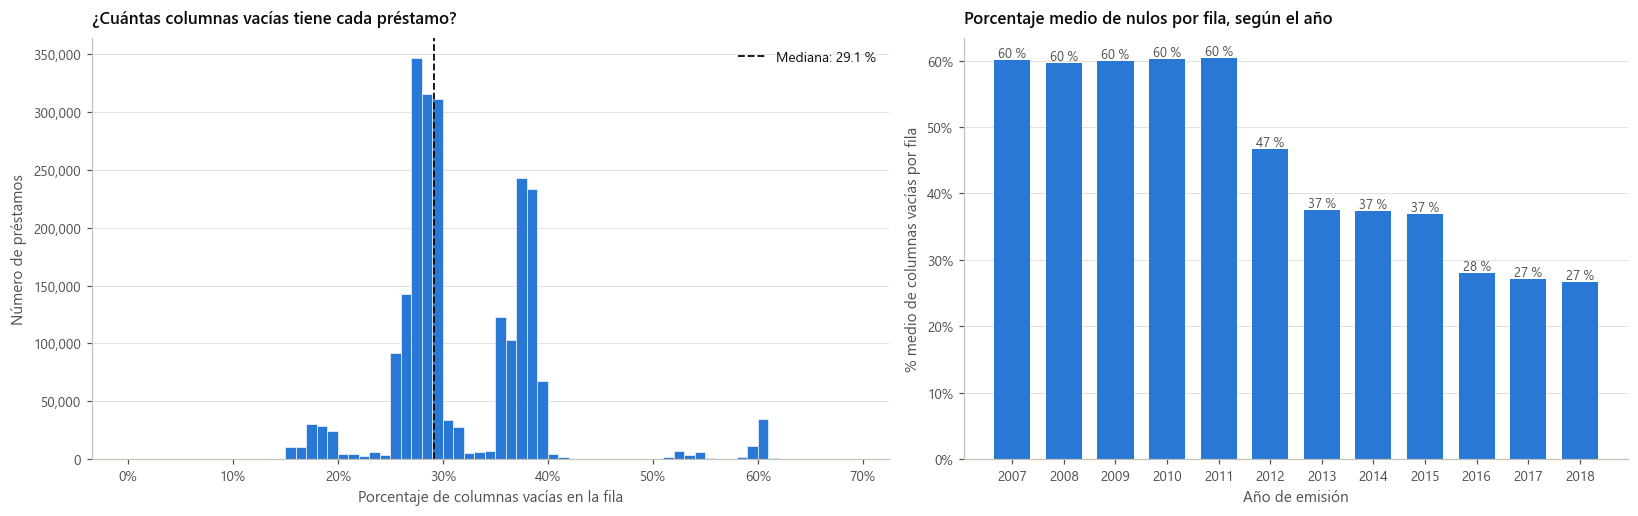

In [46]:
pct_nulos_fila = nulos_df.mean(axis=1) * 100

display(pct_nulos_fila.describe(percentiles=[.1, .25, .5, .75, .9, .99]).to_frame("% nulos por fila").T
        .style.format("{:,.2f}"))

conc_filas = pd.DataFrame({"umbral": ["> 20 %", "> 30 %", "> 40 %", "> 50 %"],
                           "n_filas": [(pct_nulos_fila > u).sum() for u in (20, 30, 40, 50)]})
conc_filas["pct_filas"] = conc_filas["n_filas"] / len(df) * 100
display(conc_filas.style.format({"n_filas": "{:,}", "pct_filas": "{:.2f} %"}).hide(axis="index"))

por_anio = pct_nulos_fila.groupby(fecha.dt.year).mean()
print("% medio de nulos por fila según application_type:")
print(pct_nulos_fila.groupby(df["application_type"], observed=True).mean().round(1).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.2, 1]})

ax1.hist(pct_nulos_fila, bins=np.arange(0, 70, 1), color=COLOR["principal"], edgecolor="white", linewidth=0.4)
ax1.axvline(pct_nulos_fila.median(), color=COLOR["texto"], linestyle="--", linewidth=1.2,
            label=f"Mediana: {pct_nulos_fila.median():.1f} %")
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
ax1.yaxis.set_major_formatter(fmt_miles)
ax1.set_xlabel("Porcentaje de columnas vacías en la fila")
ax1.set_ylabel("Número de préstamos")
ax1.grid(axis="x", visible=False)
ax1.legend()
ax1.set_title("¿Cuántas columnas vacías tiene cada préstamo?")

ax2.bar(por_anio.index.astype(str), por_anio.values, color=COLOR["principal"], width=0.7)
for x, v in zip(por_anio.index.astype(str), por_anio.values):
    ax2.text(x, v, f"{v:.0f} %", ha="center", va="bottom", fontsize=8.5, color=COLOR["texto_2"])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_xlabel("Año de emisión")
ax2.set_ylabel("% medio de columnas vacías por fila")
ax2.grid(axis="x", visible=False)
ax2.set_title("Porcentaje medio de nulos por fila, según el año")

fig.tight_layout()
fig.savefig(FIG_DIR / "04_nulos_por_fila.png")
plt.show()


Ningún préstamo está completo: el mínimo es 3.3 % de columnas vacías y la mediana 29.1 %. El histograma tiene varios picos (≈ 28 %, ≈ 38 % y ≈ 60 %) que corresponden a las "generaciones" de préstamos: los de 2007–2011 tienen 60 % de columnas vacías, los de 2013–2015 el 37 % y los de 2016–2018 el 27 %.

Las solicitudes conjuntas tienen menos nulos (19.0 % frente a 32.5 %), porque llenan las columnas del segundo solicitante. Eliminar filas con muchos nulos no es viable: se perderían casi todos los préstamos antiguos y se sesgaría la muestra hacia los años recientes.

Parte 37. Relación con default (prueba de MCAR)

MCAR: el nulo aparece por puro azar. Si fuera así, la tasa de default debería ser la misma cuando el dato falta que cuando está presente. Para cada columna se hace una chi-cuadrado entre el indicador de nulo y default: si p < 0.05, se rechaza MCAR.

Se prefirió esta prueba por variable en lugar de la prueba global de Little, porque con 2.26 M de filas la de Little rechaza cualquier desviación mínima y no dice qué variable es la problemática.

In [47]:
# Columnas que se eliminarán de todos modos (se usan aquí para filtrar la gráfica y en la Parte 38)
IDENTIFICADORES = ["id", "member_id", "url", "desc", "title", "emp_title", "zip_code"]
POSTERIORES = [
    "loan_status", "funded_amnt_inv", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
    "last_fico_range_high", "last_fico_range_low", "pymnt_plan", "debt_settlement_flag",
    "debt_settlement_flag_date", "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term", "hardship_flag", "hardship_type", "hardship_reason",
    "hardship_status", "deferral_term", "hardship_amount", "hardship_start_date", "hardship_end_date",
    "payment_plan_start_date", "hardship_length", "hardship_dpd", "hardship_loan_status",
    "orig_projected_additional_accrued_interest", "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",
]
MIN_FALTANTES = 1000   # mínimo de préstamos con nulo para que la tasa sea confiable

y = df.loc[mask_modelo, "default"].astype("int8").values
nulos_mod = nulos_df.loc[mask_modelo]

filas = []
for col in cols_con_nulos:
    faltante = nulos_mod[col].values
    n_falt = int(faltante.sum())
    if n_falt == 0 or n_falt == len(faltante):
        continue
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(faltante, y))
    tasa_falt = y[faltante].mean() * 100
    tasa_pres = y[~faltante].mean() * 100
    filas.append({
        "variable": col,
        "n_faltantes_modelado": n_falt,
        "pct_nulos_modelado": n_falt / len(faltante) * 100,
        "tasa_default_si_falta": tasa_falt,
        "tasa_default_si_presente": tasa_pres,
        "dif_pp": tasa_falt - tasa_pres,
        "chi2": chi2, "p_value": p,
        "V_Cramer": np.sqrt(chi2 / len(faltante)),
        "MCAR (p>0.05)": "Compatible" if p > 0.05 else "Rechazado",
    })
mcar = pd.DataFrame(filas).set_index("variable").sort_values("dif_pp", key=abs, ascending=False)

print(f"Variables evaluadas: {len(mcar)}  ·  MCAR rechazado: {(mcar['MCAR (p>0.05)'] == 'Rechazado').sum()}")
display(mcar.style.format({"n_faltantes_modelado": "{:,}", "pct_nulos_modelado": "{:.2f} %",
                           "tasa_default_si_falta": "{:.2f} %", "tasa_default_si_presente": "{:.2f} %",
                           "dif_pp": "{:+.2f}", "chi2": "{:,.1f}", "p_value": "{:.2e}", "V_Cramer": "{:.3f}"}))


Variables evaluadas: 112  ·  MCAR rechazado: 101


,n_faltantes_modelado,pct_nulos_modelado,tasa_default_si_falta,tasa_default_si_presente,dif_pp,chi2,p_value,V_Cramer,MCAR (p>0.05)
variable,,,,,,,,,
debt_settlement_flag_date,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
settlement_percentage,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
settlement_amount,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
settlement_date,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
settlement_status,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
settlement_term,"2,226,422",98.49 %,10.57 %,97.15 %,-86.58,"241,530.2",0.00e+00,0.327,Rechazado
last_pymnt_d,"2,427",0.11 %,95.30 %,11.79 %,+83.51,"16,144.2",0.00e+00,0.085,Rechazado
hardship_length,"2,249,751",99.52 %,11.76 %,37.19 %,-25.43,"6,710.5",0.00e+00,0.054,Rechazado
hardship_amount,"2,249,751",99.52 %,11.76 %,37.19 %,-25.43,"6,710.5",0.00e+00,0.054,Rechazado


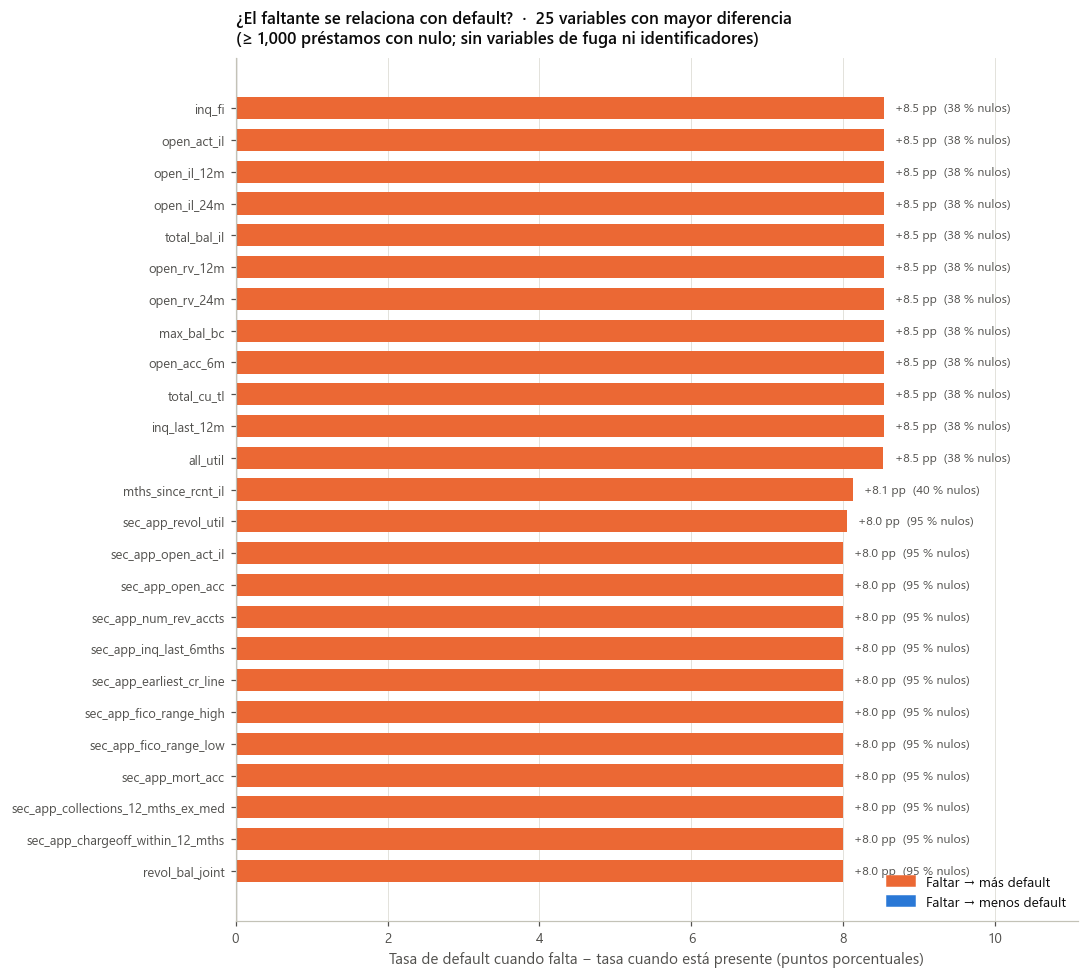

In [48]:
top = (mcar[(mcar["n_faltantes_modelado"] >= MIN_FALTANTES)
           & ~mcar.index.isin(IDENTIFICADORES + POSTERIORES)]
       .head(25).iloc[::-1])

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top.index, top["dif_pp"], height=0.7,
        color=np.where(top["dif_pp"] > 0, COLOR["secundario"], COLOR["principal"]))
for i, (v, pct) in enumerate(zip(top["dif_pp"], top["pct_nulos_modelado"])):
    ax.text(v + (0.15 if v >= 0 else -0.15), i, f"{v:+.1f} pp  ({pct:.0f} % nulos)", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color=COLOR["texto_2"])
ax.axvline(0, color=COLOR["texto_2"], linewidth=0.8)
ax.set_xlabel("Tasa de default cuando falta − tasa cuando está presente (puntos porcentuales)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
ax.margins(x=0.3)
ax.legend(handles=[Patch(color=COLOR["secundario"], label="Faltar → más default"),
                   Patch(color=COLOR["principal"], label="Faltar → menos default")], loc="lower right")
ax.set_title("¿El faltante se relaciona con default?  ·  25 variables con mayor diferencia\n"
             f"(≥ {MIN_FALTANTES:,} préstamos con nulo; sin variables de fuga ni identificadores)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_faltantes_vs_default.png")
plt.show()


Se evaluaron 112 variables y **se rechaza MCAR en 101**. Las 11 compatibles con MCAR tienen muy pocos nulos. Los datos **no faltan al azar**: el mecanismo es principalmente **MAR, dependiente de la fecha de emisión** (Parte 34).

Esto se ve en la dirección de las diferencias. Las variables que se empezaron a registrar después de 2012 o 2015 tienen **más default cuando faltan**: el bloque de historial crediticio de 2012 (`tot_cur_bal` y 19 más), +2.9 pp; `open_acc_6m` y su bloque de 2015, +8.5 pp; `il_util`, +6.5 pp. Los préstamos donde faltan son los antiguos, que ya terminaron y tuvieron tiempo de caer en default, mientras que los recientes (con el dato) siguen vigentes y cuentan como clase 0. Además, que falte `emp_length` aumenta el default en 2.7 pp (14.4 % frente a 11.7 %), una señal propia del solicitante.

Como el faltante es informativo, se conservará con **indicadores de faltante** (uno por bloque) y la categoría "Missing", en lugar de imputar sin dejar rastro.

Parte 38. Plan de tratamiento por variable

Reglas, en orden de prioridad:

Eliminar: identificadores y texto libre; información posterior al otorgamiento (fuga); más de 70 % de nulos.
Numéricas: mediana (por la asimetría vista en la Parte 14). Se agrega un indicador de faltante si hay más de 30 % de nulos o si el faltante cambia la tasa de default en ≥ 1 pp (con al menos 1,000 casos).
Categóricas: categoría "Missing" si el faltante es informativo; si no, la moda.

In [49]:
UMBRAL_ELIMINAR = 70
UMBRAL_INFORMATIVO = 1.0   # pp de diferencia en la tasa de default

patron_de = {c: i for i, cols in patrones["columnas"].items() for c in cols.split(", ")}
plan = (nulos_det[["tipo", "n_nulos", "pct_nulos"]]
        .join(mcar[["n_faltantes_modelado", "dif_pp", "MCAR (p>0.05)"]])
        .assign(patron=lambda d: d.index.map(patron_de)))

def plan_tratamiento(fila):
    var, pct, tipo = fila.name, fila["pct_nulos"], fila["tipo"]
    informativo = (pd.notna(fila["dif_pp"]) and abs(fila["dif_pp"]) >= UMBRAL_INFORMATIVO
                   and fila["n_faltantes_modelado"] >= MIN_FALTANTES)
    if var in IDENTIFICADORES:
        return "Eliminar", "Identificador o texto libre"
    if var in POSTERIORES:
        return "Eliminar", "Información posterior al otorgamiento (fuga)"
    if pct == 0:
        return "Sin tratamiento", "Sin nulos"
    if pct > UMBRAL_ELIMINAR:
        return "Eliminar", f"> {UMBRAL_ELIMINAR} % de nulos"
    if tipo == "numérica":
        if pct > UMBRAL_NULOS or informativo:
            return "Mediana + indicador", "El faltante es frecuente o se asocia con default"
        return "Mediana", "Pocos nulos, distribución asimétrica"
    if informativo:
        return "Categoría 'Missing'", "El faltante se asocia con default"
    return "Moda", "Pocos nulos, no informativo"

plan[["tratamiento", "justificación"]] = plan.apply(plan_tratamiento, axis=1, result_type="expand")

display(plan["tratamiento"].value_counts().to_frame("n_variables"))
display(plan.query("tratamiento == 'Eliminar'")["justificación"].value_counts().to_frame("n_eliminadas"))
display(plan.style.format({"n_nulos": "{:,}", "pct_nulos": "{:.2f} %", "n_faltantes_modelado": "{:,.0f}",
                           "dif_pp": "{:+.2f}", "patron": "{:.0f}"}, na_rep="—"))


,n_variables
tratamiento,
Eliminar,66
Mediana + indicador,53
Sin tratamiento,19
Mediana,11
Categoría 'Missing',1
Moda,1


,n_eliminadas
justificación,
Información posterior al otorgamiento (fuga),40
> 70 % de nulos,19
Identificador o texto libre,7


,tipo,n_nulos,pct_nulos,n_faltantes_modelado,dif_pp,MCAR (p>0.05),patron,tratamiento,justificación
member_id,numérica,"2,260,668",100.00 %,—,—,—,—,Eliminar,Identificador o texto libre
orig_projected_additional_accrued_interest,numérica,"2,252,017",99.62 %,"2,252,017",-13.10,Rechazado,—,Eliminar,Información posterior al otorgamiento (fuga)
hardship_end_date,categórica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_start_date,categórica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_type,categórica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_reason,categórica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_status,categórica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
deferral_term,numérica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_last_payment_amount,numérica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)
hardship_payoff_balance_amount,numérica,"2,249,751",99.52 %,"2,249,751",-25.43,Rechazado,2,Eliminar,Información posterior al otorgamiento (fuga)


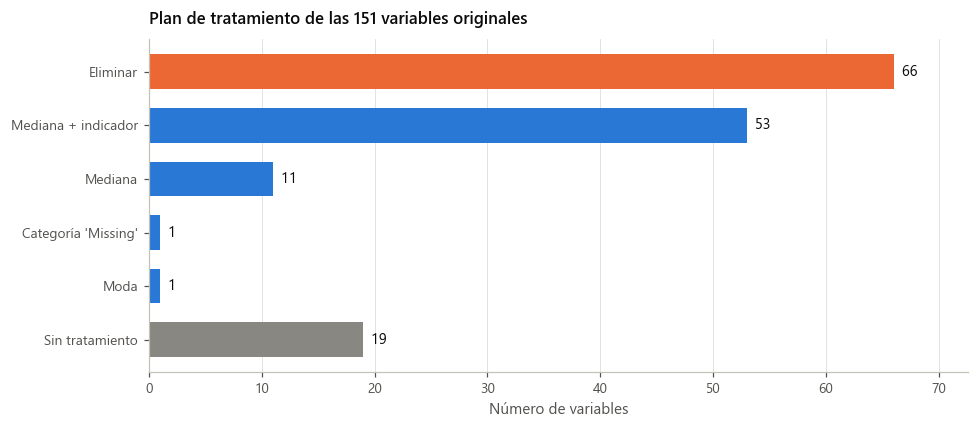

In [50]:
orden_plan = ["Eliminar", "Mediana + indicador", "Mediana", "Categoría 'Missing'", "Moda", "Sin tratamiento"]
conteo = plan["tratamiento"].value_counts().reindex(orden_plan).fillna(0).astype(int)
colores = [COLOR["secundario"]] + [COLOR["principal"]] * 4 + [COLOR["tenue"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(conteo.index[::-1], conteo.values[::-1], color=colores[::-1], height=0.65)
for i, v in enumerate(conteo.values[::-1]):
    ax.text(v, i, f"  {v}", va="center", fontsize=9.5, color=COLOR["texto"])
ax.set_xlabel("Número de variables")
ax.grid(axis="y", visible=False)
ax.margins(x=0.1)
ax.set_title(f"Plan de tratamiento de las {len(plan)} variables originales")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_plan_tratamiento.png")
plt.show()


### Decisiones finales para el preprocesamiento

El plan anterior resume el tratamiento de los nulos (66 variables a eliminar; 53 con mediana + indicador; 11 con mediana; 1 con categoría "Missing"; 1 con moda; 19 sin tratamiento). A continuación se consolidan **todas** las decisiones del EDA.

| # | Tema | Decisión | Origen |
|---|---|---|---|
| 1 | Variable objetivo | `default` según la regla del enunciado (Charged Off = 1). Desbalance de 7.4 : 1 → pesos por clase, partición estratificada y métricas AUC-ROC, AUC-PR, F1 y recall. Sin undersampling | Parte 21 |
| 2 | Sesgo temporal | Crear `issue_year` (año de emisión) como variable de control; interpretar con cautela `initial_list_status` y `application_type` | Partes 21, 26 y 37 |
| 3 | Fuga de información | Eliminar las 40 variables posteriores al otorgamiento (pagos, recuperaciones, `last_fico_*`, `hardship_*`, `settlement_*`, fechas de pago) | Partes 24, 26 y 38 |
| 4 | Identificadores y texto | Eliminar `id`, `member_id`, `url`, `desc`, `title`, `emp_title` y `zip_code` | Partes 19 y 38 |
| 5 | Más de 70 % de nulos | Eliminar las 16 variables del segundo solicitante (`sec_app_*`, `*_joint`) | Parte 38 |
| 6 | `mths_since_last_record`, `mths_since_recent_bc_dlq`, `mths_since_last_major_derog` (74–84 % de nulos) | **No se eliminan:** se convierten en indicadores binarios ("tuvo el evento: sí / no"), porque el nulo significa que el evento nunca ocurrió | Partes 37 y 38 |
| 7 | Variables sin información | Eliminar `policy_code` (constante) y `disbursement_method` (96.5 % Cash; asociación explicada por la fecha) | Partes 7, 26 y 27 |
| 8 | Redundancias | Eliminar `funded_amnt`, `installment`, `fico_range_low` y `grade`. En cada uno de los 22 bloques de la Parte 29 se conserva una sola variable | Partes 29–31 |
| 9 | `int_rate` frente a `sub_grade` (η = 0.98) | Modelos lineales (LogisticRegression, LinearSVC, NaiveBayes): solo `int_rate`. Modelos de árboles: ambas | Parte 31 |
| 10 | Imputación de numéricas | Mediana; más un indicador por bloque si hay más de 30 % de nulos o si el faltante es informativo. En las `mths_since_*` restantes, el nulo se imputa con un valor alto (nunca ocurrió) | Parte 38 |
| 11 | `emp_length` | Usar `emp_length_num` (0–10) más un indicador `emp_length_faltante` | Partes 9, 27 y 37 |
| 12 | Valores imposibles | `dti` < 0 o = 999 → nulo e imputar; `annual_inc` = 0 → nulo; `revol_util` > 150 % → acotar | Partes 11 y 23 |
| 13 | Asimetría | log1p o Yeo-Johnson en las variables con asimetría fuerte, y escalado estándar, para los modelos lineales y NaiveBayes. Los árboles no lo requieren | Parte 14 |
| 14 | `pub_rec` | Convertir en binaria (tiene o no registros públicos) | Parte 23 |
| 15 | Categóricas | `home_ownership`: unificar ANY, NONE y OTHER. `purpose`: agrupar las categorías < 1 %. `addr_state`: agrupar por región o target encoding. `sub_grade` y `grade`: codificación ordinal. `term`: binaria. `verification_status`: one-hot | Partes 17, 19, 26 y 27 |
| 16 | Fechas | `issue_d` → `issue_year`; `earliest_cr_line` → antigüedad del historial crediticio en años | Parte 16 |


# Resumen ejecutivo

## Resumen ejecutivo — Análisis exploratorio de Lending Club
# Resumen ejecutivo — Análisis exploratorio de Lending Club (2007–2018)

## Mensajes clave

1. **Una cartera grande y en crecimiento:** 2.26 millones de préstamos y **34,000 millones de USD** financiados. El volumen anual pasó de 603 préstamos en 2007 a casi medio millón en 2018.
2. **El 11.9 % de los préstamos terminó en default** (Charged Off), con una pérdida neta de capital estimada en **≈ 1,950 millones de USD**. Es un límite inferior: el 38.9 % de la cartera sigue vigente y parte de ella aún podría caer en default.
3. **El cliente típico** pide **10,000–15,000 USD** para **refinanciar deudas** (79 %), gana **≈ 65,000 USD al año**, tiene un FICO cercano a **694** y lleva **más de 10 años** en su empleo.
4. **El riesgo está concentrado y es predecible:** el grado del préstamo y la tasa de interés separan claramente a los buenos de los malos pagadores. En el grado G, el **37.5 %** de los préstamos cae en default; en el grado A, solo el **3.3 %**.
5. **El dataset requiere una depuración importante:** de 151 variables, **66 se eliminan** (40 por fuga de información, 19 por exceso de nulos y 7 identificadores) y **65 requieren imputación**.

---

## 1. El dataset en cifras

| Indicador | Valor |
|---|---|
| Préstamos | **2,260,668** (tras eliminar 33 filas de totales del archivo) |
| Variables | 151 (113 numéricas, 37 categóricas o de texto, 1 identificador) |
| Periodo | Junio de 2007 – diciembre de 2018 |
| Monto total financiado | **34,000 millones de USD** |
| Estado de la cartera | 47.6 % pagados · 38.9 % vigentes · 11.9 % en default · 1.5 % en mora |
| Variable objetivo | `default = 1` si Charged Off (268,559); `0` en otro caso (1,992,109) |
| Tasa de default | **11.88 %** → desbalance de clases de **7.4 : 1** |

**Crecimiento de la cartera**

| Año | 2009 | 2011 | 2013 | 2015 | 2017 | 2018 |
|---|---|---|---|---|---|---|
| Préstamos | 5,281 | 21,721 | 134,814 | 421,095 | 443,579 | 495,242 |
| Monto (millones de USD) | 52 | 262 | 1,983 | 6,418 | 6,585 | 7,936 |

---

## 2. ¿Quién pide los préstamos?

**Montos:** el más frecuente es **10,000 USD** (8.3 %), seguido de 20,000, 15,000 y 12,000 USD. Mediana de **12,900 USD**, media de 15,047 USD y máximo de 40,000 USD. El **63 %** está entre 5,000 y 20,000 USD. El 71 % es a **36 meses**.

**Propósito:** consolidación de deudas **56.5 %**, tarjeta de crédito **22.9 %**, mejoras del hogar 6.7 %, otros 6.2 %, compra importante 2.2 %. → **8 de cada 10 clientes refinancian deudas existentes.**

**Ocupación:** las más frecuentes son **docentes** (48,460), **gerentes** (45,852), **dueños de negocio** (33,591), **enfermeras** (≈ 40,500) y **conductores** (≈ 35,000). La base es muy diversa: las 10 principales suman solo el 11.5 %. El 33 % lleva 10 años o más en su empleo; el 6.5 % no lo declara.

**Situación financiera**

| Indicador | Valor típico |
|---|---|
| Ingreso anual | Mediana de **65,000 USD**; el 48 % gana entre 40,000 y 80,000 |
| Vivienda | **49 % con hipoteca**, 40 % alquila, 11 % propietario sin hipoteca |
| FICO | Mediana de **694** |
| Deuda / ingreso (DTI) | Mediana de **17.8 %** |
| Uso del cupo de tarjetas | Mediana de **50 %** |
| Historial crediticio | Mediana de **14.8 años** |
| Antecedentes negativos | 18.6 % con moras en los últimos 2 años; 15.8 % con registros públicos; 12 % con alguna bancarrota |

**Ubicación:** California (13.9 %), Nueva York (8.2 %), Texas (8.2 %) y Florida (7.2 %) concentran el 38 %.

**Calidad crediticia:** la mayoría está en los grados **B y C (29 % cada uno)**. La tasa de interés media es **13.1 %**: va de 7.2 % (A) a 28.2 % (G).

---

## 3. ¿Quién no paga? Segmentos de riesgo

| Segmento | Tasa de default | Frente a la media (11.9 %) |
|---|---|---|
| Subgrado **G3** / grado **G** | **39.6 %** / **37.5 %** | × 3.2 |
| Grado F | 34.7 % | × 2.9 |
| Grado E | 26.6 % | × 2.2 |
| Grado D | 18.8 % | × 1.6 |
| Propósito **pequeño negocio** | **18.6 %** | × 1.6 |
| Plazo de **60 meses** | 16.2 % (frente a 10.1 % a 36 meses) | × 1.4 |
| Ingreso **verificado** | 15.9 % (frente a 8.0 % no verificado) | × 1.3 |
| Vive en alquiler | 13.9 % (frente a 10.3 % con hipoteca) | × 1.2 |
| Grado **A** | **3.3 %** | × 0.3 |

- Los subgrados de **C5 a G5** reúnen el **28 % de la cartera**, con tasas de 15 % a 40 %.
- **Hallazgo contraintuitivo:** los ingresos verificados incumplen más, porque Lending Club verifica a quienes considera más riesgosos.
- **Pérdidas:** los préstamos en default recibieron **4,178 millones de USD** y recuperaron 2,227 millones (incluidos 325 millones de cobranza): una pérdida neta de **≈ 1,950 millones de USD**.
- **Precaución con los años recientes:** la tasa observada cae a 8.8 % en 2017 y 1.8 % en 2018, pero no porque los préstamos sean mejores: el **59 % y el 86 %** de ellos siguen vigentes. Las tasas por año solo son comparables hasta 2015.

---

## 4. Variables más relevantes para predecir el default

| Tipo | Variable | Fuerza | Lectura de negocio |
|---|---|---|---|
| Numérica | **`int_rate`** | r = 0.20 (la mayor) | La tasa ya refleja el riesgo asignado |
| Categórica | **`sub_grade` / `grade`** | V = 0.23 / 0.22 | Gradiente de 1.6 % a 39.6 % |
| Numérica | **`fico_range_high`** | r = −0.12 | A menor puntaje, más riesgo |
| Categórica | `verification_status` | V = 0.10 | Los verificados tienen más riesgo |
| Numérica | `acc_open_past_24mths`, `inq_last_6mths`, `num_tl_op_past_12m` | r ≈ 0.08–0.09 | Abrir cuentas o pedir crédito recientemente es una señal de alerta |
| Numérica | `bc_open_to_buy`, `revol_util`, `bc_util` | r ≈ 0.07–0.08 | Menos crédito disponible y más uso del cupo → más riesgo |
| Categórica | `term`, `home_ownership`, `purpose`, `addr_state`, `emp_length` | V = 0.03–0.08 | Débiles, pero con segmentos de alto riesgo |

**Ninguna variable predice el default por sí sola** (la mejor explica el 4 % de la variabilidad): el modelo deberá combinar varias.

---

## 5. Plan de depuración de variables

**Se eliminan 66 variables:**
- **40 de fuga de información:** pagos (`total_pymnt`, `total_rec_prncp`, `last_pymnt_amnt`…), recuperaciones (`recoveries`), puntajes posteriores (`last_fico_*`), acuerdos de pago (`debt_settlement_flag`, `settlement_*`) y planes de alivio (`hardship_*`). Por ejemplo, `debt_settlement_flag = Y` tiene **97 %** de default, porque el acuerdo solo existe después del impago.
- **19 con más de 70 % de nulos:** 16 del segundo solicitante (`sec_app_*`, `*_joint`) y 3 de historial negativo, que se transformarán en indicadores binarios en lugar de perderse.
- **7 identificadores o texto libre:** `id`, `member_id`, `url`, `desc`, `title`, `emp_title` y `zip_code`.

Además, se descartan `policy_code` (constante) y `disbursement_method`, y las redundantes (`funded_amnt`, `installment`, `fico_range_low`, `grade`).

**Se imputan 65 variables:**

| Situación | Variables | Tratamiento |
|---|---|---|
| Entre 30 % y 70 % de nulos | 16 (bloque de 2015 con 38 %, `mths_since_last_delinq` con 51 %, `il_util`…) | Mediana + indicador |
| Menos de 30 %, con faltante informativo | 37 (bloque de historial de 2012, ≈ 3 %) | Mediana + indicador (uno por bloque) |
| Menos de 0.1 % de nulos | 11 (`dti`, `revol_util`, `annual_inc`…) | Mediana |
| `emp_length` (6.5 %) | 1 | Categoría "Missing" (o `emp_length_num` + indicador) |
| `earliest_cr_line` (29 nulos) | 1 | Moda |

**Los nulos no son aleatorios** (se rechazó MCAR en 101 de 112 variables): dependen de la fecha de emisión, porque Lending Club incorporó variables en 2012, 2015 y 2017. Por eso no se eliminan filas.

---

## 6. Consideraciones para el modelado

| Aspecto | Acción |
|---|---|
| Desbalance de 7.4 : 1 | Pesos por clase, partición estratificada y métricas AUC-ROC, AUC-PR, F1 y recall; no accuracy |
| Sesgo temporal de la etiqueta | Incluir el año de emisión; interpretar con cautela las variables asociadas a préstamos recientes |
| Asimetría (84 variables) | log1p o Yeo-Johnson para los modelos lineales y NaiveBayes |
| Valores imposibles | `dti` = −1 / 999, `annual_inc` = 0, `revol_util` = 892 % → tratamiento puntual |
| Variables ordinales | `sub_grade` y `grade` con codificación ordinal |
| Alta cardinalidad | `addr_state` agrupada por región o con target encoding |

---

## 7. Recomendaciones de negocio a un gerente

1. **Segmentar por grado:** los grados D a G combinan tasas de default de 19 % a 38 %; conviene exigir más garantías o ajustar la tasa.
2. **El perfil ideal para promocionar:** grados A–B, con hipoteca, ingreso no verificado por riesgo bajo, a 36 meses y para consolidar tarjetas de crédito. Estos perfiles tienen tasas de default por debajo del 8 %.
3. **Revisar la política para pequeños negocios:** con 18.6 %, es el propósito de mayor riesgo.
4. **Hacer obligatorio el dato laboral:** los clientes que no declaran su antigüedad incumplen más (14.4 % frente a 11.9 %).
5. **Vigilar la cartera reciente:** los préstamos de 2016–2018 aún no muestran su default real; su riesgo está subestimado en las cifras actuales.


# Preprocesamiento

9.10.4.2 Configuración común

In [2]:
%%writefile config_modelado.py
# ============================================================
# 9.10.4.2. PREPROCESAMIENTO — CONFIGURACIÓN COMÚN (scikit-learn y PySpark)
# ============================================================
import json
import os
import platform
import sys
from pathlib import Path

RANDOM_STATE = 42

# Depuración: True ejecuta todo con una fracción estratificada y guarda en results_prueba/.
# La entrega DEBE ejecutarse con MODO_PRUEBA = False (dataset completo, sin muestreo).
MODO_PRUEBA = False
FRACCION_PRUEBA = 0.01

# ⚠ POBLACIÓN DE MODELADO
#   "completa"   -> regla literal del enunciado (9.10.3) sobre los 2,260,668 préstamos (decisión actual del EDA).
#                   El conjunto de prueba tendrá ~452 mil observaciones.
#   "terminados" -> solo Fully Paid + Charged Off (1,345,310). Prueba de ~269 mil observaciones, que es lo que
#                   corresponde a las "unas 260 mil observaciones de prueba" que menciona el enunciado en 9.10.4.6.1.
POBLACION = "completa"

# Si existen resultados guardados de un modelo, se cargan en lugar de reentrenar (útil si se interrumpe la ejecución).
FORZAR_REENTRENAMIENTO = False

# ------------------------------------------------------------
# Rutas
# ------------------------------------------------------------
RUTA_CSV = Path("accepted_2007_to_2018Q4.csv") / "accepted_2007_to_2018Q4.csv"
DIR_RESULTADOS = Path("results_prueba" if MODO_PRUEBA else "results")
DIR_FIGURAS = DIR_RESULTADOS / "figures"
DIR_SK = DIR_RESULTADOS / "sklearn"
DIR_SPARK = DIR_RESULTADOS / "spark"
DIR_LIME = DIR_RESULTADOS / "lime"

RUTA_PARTICION = DIR_RESULTADOS / "split_assignment.parquet"
RUTA_METRICAS_SK = DIR_RESULTADOS / "sklearn_metrics.csv"
RUTA_METRICAS_SPARK = DIR_RESULTADOS / "spark_metrics.csv"
RUTA_PRED_SK = DIR_RESULTADOS / "sklearn_predictions.parquet"
RUTA_PRED_SPARK = DIR_RESULTADOS / "spark_predictions.parquet"
RUTA_TIEMPOS_SK = DIR_RESULTADOS / "sklearn_timing.csv"
RUTA_TIEMPOS_SPARK = DIR_RESULTADOS / "spark_timing.csv"
RUTA_TIEMPOS = DIR_RESULTADOS / "timing_results.csv"
RUTA_COMPARACION_METRICAS = DIR_RESULTADOS / "model_comparison.csv"
RUTA_DELONG_VALIDACION = DIR_RESULTADOS / "delong_validation.csv"
RUTA_DELONG = DIR_RESULTADOS / "delong_results.csv"
RUTA_MCNEMAR = DIR_RESULTADOS / "mcnemar_results.csv"
RUTA_BOOTSTRAP = DIR_RESULTADOS / "bootstrap_results.csv"
RUTA_COMPARACION_ESTADISTICA = DIR_RESULTADOS / "statistical_comparison.csv"


def crear_directorios():
    for d in [DIR_RESULTADOS, DIR_FIGURAS, DIR_SK, DIR_SPARK, DIR_LIME]:
        d.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Columnas de origen (nombres reales del CSV)
# ------------------------------------------------------------
# Numéricas conservadas tras el EDA: sin fuga (Partes 24, 26, 37-38), con 70 % de nulos o menos,
# y una sola variable por bloque redundante (Parte 29).
VARS_NUMERICAS_BASE = [
    "loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high",
    "revol_bal", "revol_util", "open_acc", "total_acc", "delinq_2yrs", "inq_last_6mths",
    "mths_since_last_delinq", "collections_12_mths_ex_med", "acc_now_delinq", "tot_coll_amt",
    "avg_cur_bal", "bc_open_to_buy", "open_acc_6m", "open_act_il", "open_il_24m",
    "mths_since_rcnt_il", "il_util", "max_bal_bc", "all_util", "inq_fi", "total_cu_tl",
    "inq_last_12m", "acc_open_past_24mths", "chargeoff_within_12_mths", "delinq_amnt",
    "mo_sin_old_il_acct", "mo_sin_old_rev_tl_op", "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl",
    "mort_acc", "mths_since_recent_bc", "mths_since_recent_inq", "num_accts_ever_120_pd",
    "num_actv_rev_tl", "num_il_tl", "num_rev_accts", "num_tl_120dpd_2m", "num_tl_90g_dpd_24m",
    "pct_tl_nvr_dlq", "pub_rec_bankruptcies", "tax_liens", "total_bal_ex_mort",
]
# Se usan solo para construir indicadores binarios (EDA: tabla de decisiones, puntos 6 y 14)
VARS_NUMERICAS_AUXILIARES = ["pub_rec", "mths_since_last_record", "mths_since_recent_bc_dlq",
                             "mths_since_last_major_derog"]
COLS_NUMERICAS_ORIGEN = VARS_NUMERICAS_BASE + VARS_NUMERICAS_AUXILIARES
COLS_TEXTO_ORIGEN = ["id", "loan_status", "term", "sub_grade", "emp_length", "home_ownership",
                     "verification_status", "issue_d", "purpose", "addr_state", "earliest_cr_line",
                     "application_type", "initial_list_status"]

# ------------------------------------------------------------
# Variables finales del modelo
# ------------------------------------------------------------
VARS_NUMERICAS_DERIVADAS = ["emp_length_num", "issue_year", "antiguedad_credito_anios"]
VARS_NUMERICAS = VARS_NUMERICAS_BASE + VARS_NUMERICAS_DERIVADAS

# sub_grade como ordinal (A1=1 ... G5=35). Solo para los modelos de árboles (EDA, punto 9: η(sub_grade, int_rate)=0.98)
VAR_ORDINAL = "sub_grade_ord"

# Indicadores de faltante: uno por bloque de nulos (EDA, Partes 35 y 38)
INDICADORES_FALTANTE = {
    "falta_emp_length": "emp_length",
    "falta_bloque_2012": "tot_coll_amt",
    "falta_bloque_2015": "open_acc_6m",
    "falta_il_util": "il_util",
    "falta_mths_since_rcnt_il": "mths_since_rcnt_il",
    "falta_mths_since_last_delinq": "mths_since_last_delinq",
    "falta_mths_since_recent_inq": "mths_since_recent_inq",
    "falta_mo_sin_old_il_acct": "mo_sin_old_il_acct",
    "falta_num_tl_120dpd_2m": "num_tl_120dpd_2m",
    "falta_bc_open_to_buy": "bc_open_to_buy",
    "falta_mort_acc": "mort_acc",
}
VARS_BINARIAS = ["term_60", "solicitud_conjunta", "listado_w", "tiene_registro_publico",
                 "tuvo_registro_publico", "tuvo_mora_tarjeta", "tuvo_derog_mayor"] + list(INDICADORES_FALTANTE)

# Categorías fijas (agrupaciones del EDA, Partes 17, 19, 26 y 27)
CATEGORIAS = {
    "home_ownership_grp": ["MORTGAGE", "OTHER", "OWN", "RENT"],
    "purpose_grp": ["car", "credit_card", "debt_consolidation", "home_improvement",
                    "major_purchase", "medical", "other", "small_business"],
    "verification_status": ["Not Verified", "Source Verified", "Verified"],
    "region": ["East North Central", "East South Central", "Middle Atlantic", "Mountain",
               "New England", "Pacific", "South Atlantic", "West North Central",
               "West South Central", "Desconocida"],
}
VARS_CATEGORICAS = list(CATEGORIAS)

COLS_X = VARS_NUMERICAS + [VAR_ORDINAL] + VARS_BINARIAS + VARS_CATEGORICAS

# log1p (EDA, Parte 14): montos y conteos con asimetría fuerte y valores >= 0
VARS_LOG = [
    "annual_inc", "revol_bal", "tot_coll_amt", "avg_cur_bal", "bc_open_to_buy", "total_bal_ex_mort",
    "max_bal_bc", "delinq_amnt", "delinq_2yrs", "inq_last_6mths", "collections_12_mths_ex_med",
    "acc_now_delinq", "chargeoff_within_12_mths", "num_accts_ever_120_pd", "num_tl_120dpd_2m",
    "num_tl_90g_dpd_24m", "pub_rec_bankruptcies", "tax_liens", "open_acc_6m", "open_il_24m", "inq_fi",
    "inq_last_12m", "total_cu_tl", "mths_since_recent_bc", "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl",
    "mths_since_rcnt_il",
]

# Limpieza de valores imposibles (EDA, Partes 11 y 23)
DTI_INVALIDO = 999.0
REVOL_UTIL_MAX = 150.0

MAPA_EMP_LENGTH = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4, "5 years": 5,
                   "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10}
HOME_OWNERSHIP_OTRAS = ["ANY", "NONE", "OTHER"]
PURPOSE_RARAS = ["vacation", "moving", "house", "wedding", "renewable_energy", "educational"]

# addr_state -> división censal de EE. UU. (EDA, Parte 27: agrupar por región)
REGION_POR_ESTADO = {
    **{e: "New England" for e in ["CT", "ME", "MA", "NH", "RI", "VT"]},
    **{e: "Middle Atlantic" for e in ["NJ", "NY", "PA"]},
    **{e: "East North Central" for e in ["IL", "IN", "MI", "OH", "WI"]},
    **{e: "West North Central" for e in ["IA", "KS", "MN", "MO", "NE", "ND", "SD"]},
    **{e: "South Atlantic" for e in ["DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV"]},
    **{e: "East South Central" for e in ["AL", "KY", "MS", "TN"]},
    **{e: "West South Central" for e in ["AR", "LA", "OK", "TX"]},
    **{e: "Mountain" for e in ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"]},
    **{e: "Pacific" for e in ["AK", "CA", "HI", "OR", "WA"]},
}

# ============================================================
# 9.10.4.3. MODELOS Y ESPACIOS DE BÚSQUEDA — parámetros comunes
# ============================================================
MODELOS = ["regresion_logistica", "arbol_decision", "bosque_aleatorio",
           "gradient_boosting", "svm_lineal", "naive_bayes"]
NOMBRES_MODELOS = {
    "regresion_logistica": "Regresión logística",
    "arbol_decision": "Árbol de decisión",
    "bosque_aleatorio": "Bosque aleatorio",
    "gradient_boosting": "Gradient boosting",
    "svm_lineal": "SVM lineal",
    "naive_bayes": "Naive Bayes",
}
# Lineales/probabilístico: escalado + sin sub_grade_ord. Árboles: sin escalado + con sub_grade_ord.
MODELOS_LINEALES = ["regresion_logistica", "svm_lineal", "naive_bayes"]
MODELOS_ARBOLES = ["arbol_decision", "bosque_aleatorio", "gradient_boosting"]

N_FOLDS = 3
REG_PARAMS = [1e-6, 1e-5, 1e-4]
MAX_DEPTH_ARBOL = [5, 10, 15]
RF_N_ESTIMATORS = [10, 50, 100]
RF_MAX_DEPTH = [5, 10, 15]
GB_N_ESTIMATORS = [50, 100]
GB_MAX_DEPTH = [3, 5]
GB_LEARNING_RATE = 0.1

MAX_ITER_LR_SK = 1000
MAX_ITER_LR_SPARK = 100
MAX_ITER_SVC_SK = 1000
MAX_ITER_SVC_SPARK = 100
MAX_BINS_SPARK = 32                 # valor por defecto de Spark; se reporta en el informe
MAX_MEMORY_MB_ARBOLES_SPARK = 256  # rendimiento de los árboles en Spark (no cambia el modelo)
IMPUTER_RELATIVE_ERROR_SPARK = 1e-4  # Spark calcula la mediana de forma aproximada

# ⚠ "GradientBoostingClassifier" es el modelo del enunciado. Cambiar a "HistGradientBoostingClassifier"
#    solo si el costo resulta prohibitivo, y documentarlo en el informe.
GB_IMPLEMENTACION_SKLEARN = "GradientBoostingClassifier"

# Pesos por clase (EDA, Parte 21 y tabla de decisiones, punto 1). Se aplican en ambos entornos.
USAR_PESOS_CLASE = True
# Mismos 3 pliegues en scikit-learn (PredefinedSplit) y PySpark (foldCol), guardados en la partición.
USAR_PLIEGUES_COMUNES = False

N_JOBS_GRID = 3              # ⚠ REVISAR: con n_jobs=-1 cada proceso copia su pliegue; reducir si hay MemoryError
PARALELISMO_CV_SPARK = 1      # modelos entrenados en paralelo por CrossValidator

TIPO_SCORE = {m: ("decision_function" if m == "svm_lineal" else "probabilidad") for m in MODELOS}
# Umbral fijo, definido sin usar el conjunto de prueba: 0.5 en probabilidades (con pesos balanceados)
# y 0 en la función de decisión de LinearSVC.
UMBRALES = {m: (0.0 if m == "svm_lineal" else 0.5) for m in MODELOS}

# ============================================================
# 9.10.4.6. COMPARACIÓN ESTADÍSTICA — parámetros
# ============================================================
ALFA = 0.05
MARGEN_RELEVANCIA_AUC = 0.005   # margen de relevancia práctica (parametrizable; debe justificarse en el informe)
B_BOOTSTRAP = 2000

# ============================================================
# 9.10.4.7. LIME — parámetros
# ============================================================
LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES = 5000
LIME_N_MUESTRA_SPARK = 5000


# ============================================================
# Utilidades comunes
# ============================================================
def pesos_por_clase(n_negativos, n_positivos):
    n = n_negativos + n_positivos
    return {0: n / (2.0 * n_negativos), 1: n / (2.0 * n_positivos)}


def metricas_desde_confusion(tn, fp, fn, tp):
    tn, fp, fn, tp = int(tn), int(fp), int(fn), int(tp)
    n = tn + fp + fn + tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": (tp + tn) / n if n > 0 else 0.0, "precision": precision, "recall": recall,
            "f1": f1, "tn": tn, "fp": fp, "fn": fn, "tp": tp}


def plot_confusion_matrix(tn, fp, fn, tp, titulo, ruta=None, ax=None):
    import matplotlib.pyplot as plt
    import numpy as np
    matriz = np.array([[tn, fp], [fn, tp]])
    propio = ax is None
    if propio:
        fig, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center",
                    color="white" if matriz[i, j] > matriz.max() / 2 else "black", fontsize=10)
    ax.set_xticks([0, 1], ["Pred. 0", "Pred. 1"])
    ax.set_yticks([0, 1], ["Real 0", "Real 1"])
    ax.set_title(titulo, fontsize=10)
    if propio:
        plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        if ruta is not None:
            plt.savefig(ruta, dpi=150, bbox_inches="tight")
        plt.show()
    return ax


def registrar_hardware(entorno, extra=None):
    info = {
        "entorno": entorno,
        "sistema_operativo": platform.platform(),
        "procesador": platform.processor() or "NO DETECTADO — completar manualmente",
        "python": sys.version.split()[0],
        "nucleos_logicos": os.cpu_count(),
    }
    try:
        import psutil
        memoria = psutil.virtual_memory()
        info["nucleos_fisicos"] = psutil.cpu_count(logical=False)
        info["memoria_total_gb"] = round(memoria.total / 1024 ** 3, 2)
        info["memoria_disponible_gb"] = round(memoria.available / 1024 ** 3, 2)
    except ImportError:
        info["nucleos_fisicos"] = "NO DETECTADO — instalar psutil o completar manualmente"
        info["memoria_total_gb"] = "NO DETECTADO — instalar psutil o completar manualmente"
        info["memoria_disponible_gb"] = "NO DETECTADO — instalar psutil o completar manualmente"
    for modulo in ["numpy", "pandas", "sklearn", "pyspark", "scipy", "lime"]:
        try:
            info[f"version_{modulo}"] = __import__(modulo).__version__
        except Exception:
            info[f"version_{modulo}"] = "NO DISPONIBLE"
    if extra:
        info.update(extra)
    DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)
    (DIR_RESULTADOS / f"hardware_{entorno}.json").write_text(
        json.dumps(info, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    return info


Overwriting config_modelado.py


9.10.4.2 Importaciones y hardware

In [2]:
# ============================================================
# 9.10.4.2. PREPROCESAMIENTO
# ============================================================
import importlib
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import config_modelado as cfg
importlib.reload(cfg)
from config_modelado import *

np.random.seed(RANDOM_STATE)
crear_directorios()

HARDWARE_SK = registrar_hardware("sklearn", extra={"n_jobs_grid": N_JOBS_GRID})
display(pd.Series(HARDWARE_SK, name="valor").to_frame())


,valor
entorno,sklearn
sistema_operativo,Windows-10-10.0.26100-SP0
procesador,"AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD"
python,3.9.25
nucleos_logicos,16
nucleos_fisicos,8
memoria_total_gb,31.87
memoria_disponible_gb,25.64
version_numpy,1.25.2
version_pandas,2.1.0


9.10.4.2.1 Partición común de los datos

In [3]:
# ------------------------------------------------------------
# 9.10.4.2.1. Partición común de los datos
# ------------------------------------------------------------
ids = pd.read_csv(RUTA_CSV, usecols=["id", "loan_status"], dtype={"id": str, "loan_status": str})
ids["id"] = pd.to_numeric(ids["id"], errors="coerce")
ids = ids.dropna(subset=["id"]).astype({"id": "int64"}).reset_index(drop=True)
assert ids["id"].is_unique, "El identificador no es único"

# Regla del enunciado (9.10.3)
ids["default"] = ids["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0).astype("int8")

if POBLACION == "terminados":
    ids = ids[ids["loan_status"].isin(["Fully Paid", "Charged Off"])].reset_index(drop=True)
elif POBLACION != "completa":
    raise ValueError("POBLACION debe ser 'completa' o 'terminados'")

if MODO_PRUEBA:
    ids = (ids.groupby("default", group_keys=False)
              .sample(frac=FRACCION_PRUEBA, random_state=RANDOM_STATE)
              .reset_index(drop=True))

id_train, id_test = train_test_split(ids["id"].to_numpy(), test_size=0.20,
                                     stratify=ids["default"].to_numpy(), random_state=RANDOM_STATE)

particion = pd.DataFrame({
    "id": np.concatenate([id_train, id_test]).astype("int64"),
    "split": np.array(["train"] * len(id_train) + ["test"] * len(id_test)),
})
particion = particion.merge(ids[["id", "default"]], on="id", how="left", validate="one_to_one")

# Pliegues de validación cruzada (estratificados, solo en entrenamiento), comunes a ambos entornos
particion["fold"] = -1
posiciones_train = np.flatnonzero(particion["split"].to_numpy() == "train")
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
columna_fold = particion.columns.get_loc("fold")
for k, (_, pos_val) in enumerate(skf.split(posiciones_train, particion["default"].to_numpy()[posiciones_train])):
    particion.iloc[posiciones_train[pos_val], columna_fold] = k
particion["fold"] = particion["fold"].astype("int32")

assert set(id_train).isdisjoint(set(id_test))
assert particion["id"].is_unique

particion[["id", "split", "fold"]].to_parquet(RUTA_PARTICION, index=False)

resumen_particion = (particion.groupby(["split", "fold"])
                     .agg(n=("id", "size"), tasa_default=("default", "mean"))
                     .reset_index())
display(resumen_particion)
print(f"Población: {POBLACION} | filas: {len(particion):,} | train: {len(id_train):,} | test: {len(id_test):,}")
print(f"Partición guardada en: {RUTA_PARTICION.resolve()}")
if POBLACION == "completa":
    print("⚠ El enunciado menciona ~260 mil observaciones de prueba; con POBLACION='completa' el conjunto "
          f"de prueba tiene {len(id_test):,}. Ver POBLACION en config_modelado.py.")
del ids


,split,fold,n,tasa_default
0,test,-1,452134,0.118797
1,train,0,602845,0.118797
2,train,1,602845,0.118797
3,train,2,602844,0.118795


Población: completa | filas: 2,260,668 | train: 1,808,534 | test: 452,134
Partición guardada en: E:\Documents\MachineLearningUN\results\split_assignment.parquet
⚠ El enunciado menciona ~260 mil observaciones de prueba; con POBLACION='completa' el conjunto de prueba tiene 452,134. Ver POBLACION en config_modelado.py.


9.10.4.2.2 scikit-learn

In [4]:
# ------------------------------------------------------------
# 9.10.4.2.2. scikit-learn
# ------------------------------------------------------------
def construir_variables_pandas(df):
    out = pd.DataFrame(index=df.index)
    out["id"] = df["id"].astype("int64")
    out["split"] = df["split"]
    out["fold"] = df["fold"].astype("int32")
    out["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0).astype("int8")

    for c in VARS_NUMERICAS_BASE:
        out[c] = df[c].astype("float64")
    out.loc[(out["dti"] < 0) | (out["dti"] == DTI_INVALIDO), "dti"] = np.nan
    out.loc[out["annual_inc"] <= 0, "annual_inc"] = np.nan
    out["revol_util"] = out["revol_util"].clip(upper=REVOL_UTIL_MAX)

    out["emp_length_num"] = df["emp_length"].map(MAPA_EMP_LENGTH).astype("float64")
    fecha_emision = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
    fecha_credito = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
    out["issue_year"] = fecha_emision.dt.year.astype("float64")
    out["antiguedad_credito_anios"] = (((fecha_emision.dt.year - fecha_credito.dt.year) * 12
                                        + (fecha_emision.dt.month - fecha_credito.dt.month)) / 12.0)
    letra = df["sub_grade"].str[0].map(lambda v: ord(v) - ord("A") if isinstance(v, str) else np.nan)
    out[VAR_ORDINAL] = (letra * 5 + pd.to_numeric(df["sub_grade"].str[1], errors="coerce")).astype("float64")

    out["term_60"] = df["term"].str.contains("60", na=False).astype("int8")
    out["solicitud_conjunta"] = (df["application_type"] == "Joint App").astype("int8")
    out["listado_w"] = (df["initial_list_status"] == "w").astype("int8")
    out["tiene_registro_publico"] = (df["pub_rec"].fillna(0) > 0).astype("int8")
    out["tuvo_registro_publico"] = df["mths_since_last_record"].notna().astype("int8")
    out["tuvo_mora_tarjeta"] = df["mths_since_recent_bc_dlq"].notna().astype("int8")
    out["tuvo_derog_mayor"] = df["mths_since_last_major_derog"].notna().astype("int8")
    for indicador, origen in INDICADORES_FALTANTE.items():
        out[indicador] = df[origen].isna().astype("int8")

    out["home_ownership_grp"] = df["home_ownership"].where(~df["home_ownership"].isin(HOME_OWNERSHIP_OTRAS), "OTHER")
    out["purpose_grp"] = df["purpose"].where(~df["purpose"].isin(PURPOSE_RARAS), "other")
    out["verification_status"] = df["verification_status"]
    out["region"] = df["addr_state"].map(REGION_POR_ESTADO).fillna("Desconocida")

    for c in VARS_LOG:
        out[c] = np.log1p(out[c].clip(lower=0))
    return out


t0_preprocesamiento = time.time()

tipos = {c: "float64" for c in COLS_NUMERICAS_ORIGEN}
tipos.update({c: "str" for c in COLS_TEXTO_ORIGEN})
crudo = pd.read_csv(RUTA_CSV, usecols=COLS_TEXTO_ORIGEN + COLS_NUMERICAS_ORIGEN, dtype=tipos, low_memory=False)
crudo["id"] = pd.to_numeric(crudo["id"], errors="coerce")
crudo = crudo.dropna(subset=["id"]).astype({"id": "int64"})

particion_leida = pd.read_parquet(RUTA_PARTICION)
crudo = crudo.merge(particion_leida, on="id", how="inner", validate="one_to_one")
datos = construir_variables_pandas(crudo)
del crudo

X_df = datos[COLS_X].copy()
for c in VARS_CATEGORICAS:
    X_df[c] = pd.Categorical(X_df[c], categories=CATEGORIAS[c]).codes.astype("float64")
assert (X_df[VARS_CATEGORICAS] >= 0).all().all(), "Hay categorías no previstas en CATEGORIAS"

es_train = datos["split"].to_numpy() == "train"
X = X_df.to_numpy(dtype="float64")
X_train, X_test = X[es_train], X[~es_train]
y_train = datos.loc[es_train, "default"].to_numpy().astype(int)
y_test = datos.loc[~es_train, "default"].to_numpy().astype(int)
id_train_sk = datos.loc[es_train, "id"].to_numpy()
id_test_sk = datos.loc[~es_train, "id"].to_numpy()
fold_train = datos.loc[es_train, "fold"].to_numpy()
del X, X_df

PESOS = pesos_por_clase((y_train == 0).sum(), (y_train == 1).sum())
w_train = np.where(y_train == 1, PESOS[1], PESOS[0])

INDICE = {c: i for i, c in enumerate(COLS_X)}
IDX_NUM = [INDICE[c] for c in VARS_NUMERICAS]
IDX_ORD = INDICE[VAR_ORDINAL]
IDX_BIN = [INDICE[c] for c in VARS_BINARIAS]
IDX_CAT = [INDICE[c] for c in VARS_CATEGORICAS]
IDX_LOG = [INDICE[c] for c in VARS_LOG]

t_preprocesamiento_sk = time.time() - t0_preprocesamiento

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Tasa de default — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")
print(f"Pesos por clase (calculados solo con train): {PESOS}")
print(f"Tiempo de preprocesamiento (carga + variables + matrices): {t_preprocesamiento_sk:.1f} s")


def crear_preprocesador(incluir_ordinal):
    columnas_numericas = IDX_NUM + ([IDX_ORD] if incluir_ordinal else [])
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), columnas_numericas),
            ("bin", "passthrough", IDX_BIN),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), IDX_CAT),
        ],
        remainder="drop",
    )


# ⚠ DECISIÓN METODOLÓGICA: el enunciado pide "GridSearchCV sin Pipeline". Sin Pipeline, el imputador,
#   el OneHotEncoder y el StandardScaler se ajustarían con todo el conjunto de entrenamiento antes de la
#   validación cruzada, y cada pliegue de validación influiría en su propio preprocesamiento (fuga dentro
#   de la CV). Aquí el preprocesamiento va dentro de un Pipeline, de modo que GridSearchCV lo reajusta en
#   cada pliegue únicamente con los datos de entrenamiento de ese pliegue. El conjunto de prueba nunca se usa.
def crear_pipeline(clave, estimador):
    if clave in MODELOS_LINEALES:
        return Pipeline([("preprocesamiento", crear_preprocesador(incluir_ordinal=False)),
                         ("escalado", StandardScaler()),
                         ("modelo", estimador)])
    return Pipeline([("preprocesamiento", crear_preprocesador(incluir_ordinal=True)),
                     ("modelo", estimador)])


CV_SK = (PredefinedSplit(test_fold=fold_train) if USAR_PLIEGUES_COMUNES
         else StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE))
print(f"Validación cruzada: {CV_SK.get_n_splits()} pliegues ({type(CV_SK).__name__})")


X_train: (1808534, 73) | X_test: (452134, 73)
Tasa de default — train: 0.1188 | test: 0.1188
Pesos por clase (calculados solo con train): {0: 0.5674056448976493, 1: 4.208888185545993}
Tiempo de preprocesamiento (carga + variables + matrices): 33.7 s
Validación cruzada: 3 pliegues (StratifiedKFold)


9.10.4.3 Modelos y espacios de búsquedas scikit-learn

In [5]:
# ============================================================
# 9.10.4.3. MODELOS Y ESPACIOS DE BÚSQUEDA
# ============================================================
n_train = len(y_train)
C_POR_REGPARAM = {r: 1.0 / (r * n_train) for r in REG_PARAMS}
C_VALORES = [C_POR_REGPARAM[r] for r in REG_PARAMS]

if GB_IMPLEMENTACION_SKLEARN == "GradientBoostingClassifier":
    ESTIMADOR_GB = GradientBoostingClassifier(learning_rate=GB_LEARNING_RATE, subsample=1.0,
                                              random_state=RANDOM_STATE)
    GRID_GB = {"modelo__n_estimators": GB_N_ESTIMATORS, "modelo__max_depth": GB_MAX_DEPTH}
elif GB_IMPLEMENTACION_SKLEARN == "HistGradientBoostingClassifier":
    ESTIMADOR_GB = HistGradientBoostingClassifier(learning_rate=GB_LEARNING_RATE, max_leaf_nodes=None,
                                                  early_stopping=False, l2_regularization=0.0,
                                                  random_state=RANDOM_STATE)
    GRID_GB = {"modelo__max_iter": GB_N_ESTIMATORS, "modelo__max_depth": GB_MAX_DEPTH}
else:
    raise ValueError("GB_IMPLEMENTACION_SKLEARN no válido")

ESPACIOS_SK = {
    "regresion_logistica": (
        LogisticRegression(penalty="l2", solver="lbfgs", max_iter=MAX_ITER_LR_SK, random_state=RANDOM_STATE),
        {"modelo__C": C_VALORES}),
    "arbol_decision": (
        DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
        {"modelo__max_depth": MAX_DEPTH_ARBOL}),
    "bosque_aleatorio": (
        RandomForestClassifier(max_features="sqrt", bootstrap=True, n_jobs=1, random_state=RANDOM_STATE),
        {"modelo__n_estimators": RF_N_ESTIMATORS, "modelo__max_depth": RF_MAX_DEPTH}),
    "gradient_boosting": (ESTIMADOR_GB, GRID_GB),
    "svm_lineal": (
        LinearSVC(loss="hinge", penalty="l2", dual=True, max_iter=MAX_ITER_SVC_SK, random_state=RANDOM_STATE),
        {"modelo__C": C_VALORES}),
    "naive_bayes": (GaussianNB(), {}),
}

tabla_espacios_sk = pd.DataFrame([
    {"modelo": NOMBRES_MODELOS[m], "clase_sklearn": type(ESPACIOS_SK[m][0]).__name__,
     "espacio_busqueda": str(ESPACIOS_SK[m][1]) if ESPACIOS_SK[m][1] else "sin búsqueda (por defecto)",
     "n_combinaciones": int(np.prod([len(v) for v in ESPACIOS_SK[m][1].values()])) if ESPACIOS_SK[m][1] else 1,
     "escalado": m in MODELOS_LINEALES, "incluye_sub_grade_ord": m in MODELOS_ARBOLES}
    for m in MODELOS])
tabla_espacios_sk.to_csv(DIR_SK / "espacios_busqueda_sklearn.csv", index=False)
display(tabla_espacios_sk)
display(pd.DataFrame({"regParam": REG_PARAMS, "C = 1/(regParam·n)": C_VALORES, "n_train": n_train}))


,modelo,clase_sklearn,espacio_busqueda,n_combinaciones,escalado,incluye_sub_grade_ord
0,Regresión logística,LogisticRegression,"{'modelo__C': [0.5529340338638921, 0.055293403...",3,True,False
1,Árbol de decisión,DecisionTreeClassifier,"{'modelo__max_depth': [5, 10, 15]}",3,False,True
2,Bosque aleatorio,RandomForestClassifier,"{'modelo__n_estimators': [10, 50, 100], 'model...",9,False,True
3,Gradient boosting,GradientBoostingClassifier,"{'modelo__n_estimators': [50, 100], 'modelo__m...",4,False,True
4,SVM lineal,LinearSVC,"{'modelo__C': [0.5529340338638921, 0.055293403...",3,True,False
5,Naive Bayes,GaussianNB,sin búsqueda (por defecto),1,True,False


,regParam,C = 1/(regParam·n),n_train
0,0.000001,0.552934,1808534
1,0.000010,0.055293,1808534
2,0.000100,0.005529,1808534


9.10.4.4 Modelado con scikit-learn

In [6]:
# ============================================================
# 9.10.4.4. MODELADO CON SCIKIT-LEARN
# ============================================================
def calculate_metrics(y_true, score, umbral):
    y_pred = (score > umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metricas = metricas_desde_confusion(tn, fp, fn, tp)
    metricas["roc_auc"] = float(roc_auc_score(y_true, score))
    metricas["auc_pr"] = float(average_precision_score(y_true, score))
    metricas["umbral"] = float(umbral)
    return metricas


def a_tipo_json(valor):
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    return valor if isinstance(valor, (int, float, str, bool)) or valor is None else str(valor)


def entrenar_modelo_sklearn(clave, forzar=FORZAR_REENTRENAMIENTO):
    ruta_resultados = DIR_SK / f"{clave}_resultados.json"
    ruta_scores = DIR_SK / f"{clave}_scores.parquet"
    if ruta_resultados.exists() and ruta_scores.exists() and not forzar:
        print(f"[{clave}] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False)")
        return json.loads(ruta_resultados.read_text(encoding="utf-8"))

    estimador, grid = ESPACIOS_SK[clave]
    busqueda = GridSearchCV(estimator=crear_pipeline(clave, estimador), param_grid=grid, cv=CV_SK,
                            scoring="roc_auc", n_jobs=N_JOBS_GRID, refit=True, error_score="raise", verbose=1)
    parametros_fit = {"modelo__sample_weight": w_train} if USAR_PESOS_CLASE else {}

    t0 = time.time()
    busqueda.fit(X_train, y_train, **parametros_fit)
    t_entrenamiento = time.time() - t0

    t0 = time.time()
    if TIPO_SCORE[clave] == "decision_function":
        score = busqueda.decision_function(X_test)
    else:
        score = busqueda.predict_proba(X_test)[:, 1]
    t_prediccion = time.time() - t0

    metricas = calculate_metrics(y_test, score, UMBRALES[clave])

    pd.DataFrame({"id": id_test_sk, "default": y_test, "score": score}).to_parquet(ruta_scores, index=False)
    pd.DataFrame(busqueda.cv_results_).to_csv(DIR_SK / f"{clave}_cv_results.csv", index=False)
    joblib.dump(busqueda.best_estimator_, DIR_SK / f"{clave}_modelo.joblib", compress=3)

    resultado = {
        "entorno": "sklearn", "modelo": clave, "nombre": NOMBRES_MODELOS[clave],
        "clase": type(estimador).__name__,
        "mejores_parametros": json.dumps({k: a_tipo_json(v) for k, v in busqueda.best_params_.items()}),
        "auc_cv_mejor": float(busqueda.best_score_),
        "t_entrenamiento_cv_s": float(t_entrenamiento), "t_prediccion_s": float(t_prediccion),
        "n_train": int(len(y_train)), "n_test": int(len(y_test)), "tipo_score": TIPO_SCORE[clave],
        **metricas,
    }
    ruta_resultados.write_text(json.dumps(resultado, indent=2, ensure_ascii=False), encoding="utf-8")
    plot_confusion_matrix(metricas["tn"], metricas["fp"], metricas["fn"], metricas["tp"],
                          f"scikit-learn — {NOMBRES_MODELOS[clave]}",
                          ruta=DIR_FIGURAS / f"confusion_sklearn_{clave}.png")
    return resultado


resultados_sk = {}


In [7]:
# 9.10.4.4 — Regresión logística
resultados_sk["regresion_logistica"] = entrenar_modelo_sklearn("regresion_logistica")
display(pd.Series(resultados_sk["regresion_logistica"]).to_frame("valor"))


[regresion_logistica] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False)


,valor
entorno,sklearn
modelo,regresion_logistica
nombre,Regresión logística
clase,LogisticRegression
mejores_parametros,"{""modelo__C"": 0.5529340338638921}"
auc_cv_mejor,0.745257
t_entrenamiento_cv_s,140.818683
t_prediccion_s,0.851659
n_train,1808534
n_test,452134


In [8]:
# 9.10.4.4 — Árbol de decisión
resultados_sk["arbol_decision"] = entrenar_modelo_sklearn("arbol_decision")
display(pd.Series(resultados_sk["arbol_decision"]).to_frame("valor"))


[arbol_decision] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False)


,valor
entorno,sklearn
modelo,arbol_decision
nombre,Árbol de decisión
clase,DecisionTreeClassifier
mejores_parametros,"{""modelo__max_depth"": 10}"
auc_cv_mejor,0.755836
t_entrenamiento_cv_s,188.998513
t_prediccion_s,0.960564
n_train,1808534
n_test,452134


Fitting 3 folds for each of 9 candidates, totalling 27 fits


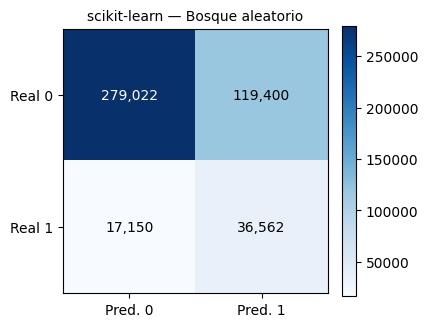

,valor
entorno,sklearn
modelo,bosque_aleatorio
nombre,Bosque aleatorio
clase,RandomForestClassifier
mejores_parametros,"{""modelo__max_depth"": 15, ""modelo__n_estimator..."
auc_cv_mejor,0.76185
t_entrenamiento_cv_s,2181.395065
t_prediccion_s,6.002041
n_train,1808534
n_test,452134


In [9]:
# 9.10.4.4 — Bosque aleatorio
resultados_sk["bosque_aleatorio"] = entrenar_modelo_sklearn("bosque_aleatorio")
display(pd.Series(resultados_sk["bosque_aleatorio"]).to_frame("valor"))


Fitting 3 folds for each of 4 candidates, totalling 12 fits


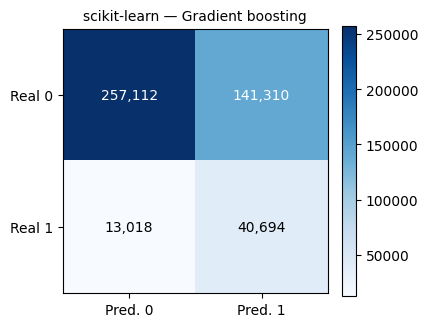

,valor
entorno,sklearn
modelo,gradient_boosting
nombre,Gradient boosting
clase,GradientBoostingClassifier
mejores_parametros,"{""modelo__max_depth"": 5, ""modelo__n_estimators..."
auc_cv_mejor,0.772345
t_entrenamiento_cv_s,6639.797674
t_prediccion_s,1.776397
n_train,1808534
n_test,452134


In [10]:
# 9.10.4.4 — Gradient boosting
resultados_sk["gradient_boosting"] = entrenar_modelo_sklearn("gradient_boosting")
display(pd.Series(resultados_sk["gradient_boosting"]).to_frame("valor"))


Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


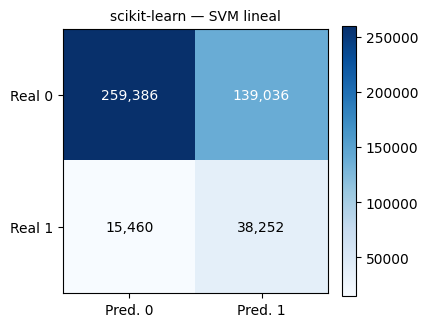

,valor
entorno,sklearn
modelo,svm_lineal
nombre,SVM lineal
clase,LinearSVC
mejores_parametros,"{""modelo__C"": 0.05529340338638919}"
auc_cv_mejor,0.745161
t_entrenamiento_cv_s,1630.203191
t_prediccion_s,0.778509
n_train,1808534
n_test,452134


In [11]:
# 9.10.4.4 — SVM lineal
resultados_sk["svm_lineal"] = entrenar_modelo_sklearn("svm_lineal")
display(pd.Series(resultados_sk["svm_lineal"]).to_frame("valor"))


Fitting 3 folds for each of 1 candidates, totalling 3 fits


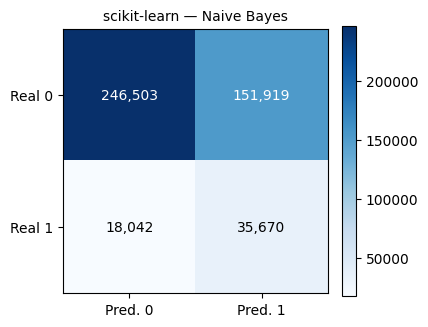

,valor
entorno,sklearn
modelo,naive_bayes
nombre,Naive Bayes
clase,GaussianNB
mejores_parametros,{}
auc_cv_mejor,0.682292
t_entrenamiento_cv_s,34.781378
t_prediccion_s,1.324747
n_train,1808534
n_test,452134


In [12]:
# 9.10.4.4 — Naive Bayes
resultados_sk["naive_bayes"] = entrenar_modelo_sklearn("naive_bayes")
display(pd.Series(resultados_sk["naive_bayes"]).to_frame("valor"))


,nombre,accuracy,precision,recall,f1,roc_auc,auc_pr,auc_cv_mejor,mejores_parametros,t_entrenamiento_cv_s,t_prediccion_s
0,Regresión logística,0.671080,0.219739,0.693402,0.333722,0.745598,0.262368,0.745257,"{""modelo__C"": 0.5529340338638921}",140.818683,0.851659
1,Árbol de decisión,0.639631,0.213342,0.756702,0.332843,0.758172,0.276130,0.755836,"{""modelo__max_depth"": 10}",188.998513,0.960564
2,Bosque aleatorio,0.697988,0.234429,0.680704,0.348751,0.763073,0.287291,0.761850,"{""modelo__max_depth"": 15, ""modelo__n_estimator...",2181.395065,6.002041
3,Gradient boosting,0.658668,0.223588,0.757633,0.345280,0.772840,0.301657,0.772345,"{""modelo__max_depth"": 5, ""modelo__n_estimators...",6639.797674,1.776397
4,SVM lineal,0.658296,0.215762,0.712169,0.331186,0.745416,0.260978,0.745161,"{""modelo__C"": 0.05529340338638919}",1630.203191,0.778509
5,Naive Bayes,0.624092,0.190150,0.664097,0.295647,0.680784,0.195336,0.682292,{},34.781378,1.324747


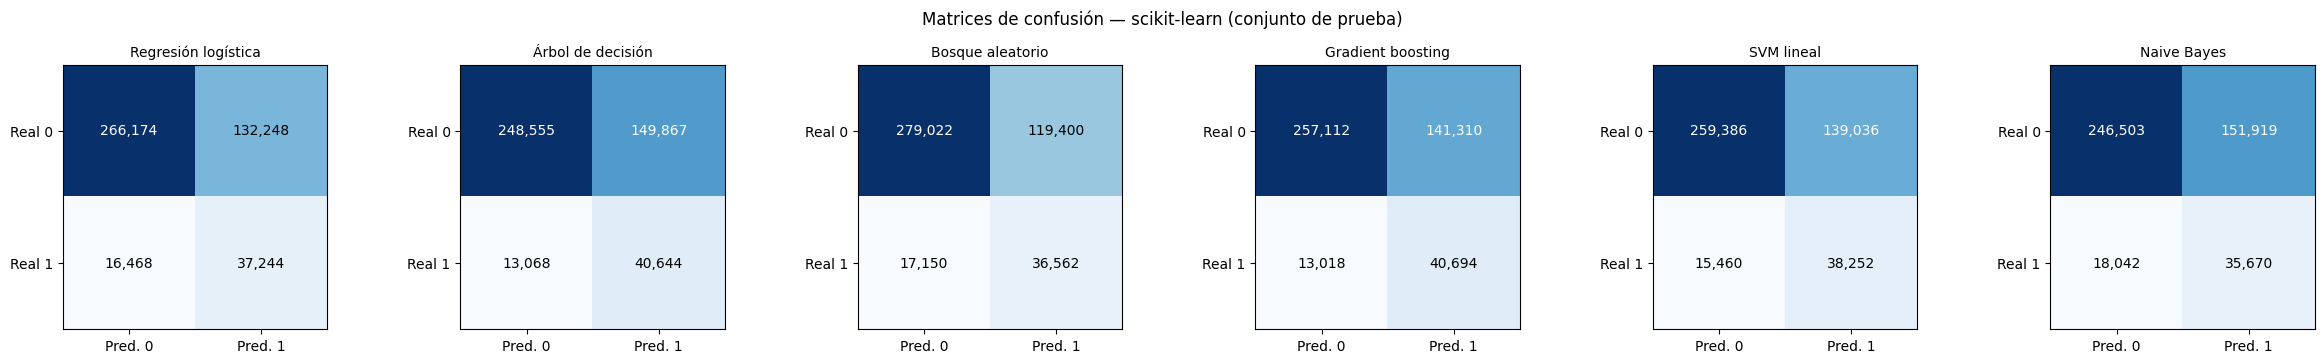

In [13]:
# 9.10.4.4 — Consolidación de resultados de scikit-learn
metricas_sk = pd.DataFrame([resultados_sk[m] for m in MODELOS])
metricas_sk.to_csv(RUTA_METRICAS_SK, index=False)

tiempos_sk = pd.DataFrame({
    "entorno": "sklearn",
    "modelo": MODELOS,
    "t_preprocesamiento_s": t_preprocesamiento_sk,
    "t_entrenamiento_cv_s": [resultados_sk[m]["t_entrenamiento_cv_s"] for m in MODELOS],
    "t_prediccion_s": [resultados_sk[m]["t_prediccion_s"] for m in MODELOS],
    "t_transferencia_s": np.nan,
})
tiempos_sk.to_csv(RUTA_TIEMPOS_SK, index=False)

predicciones_sk = pd.DataFrame({"id": id_test_sk, "default": y_test})
for m in MODELOS:
    scores_m = pd.read_parquet(DIR_SK / f"{m}_scores.parquet")
    assert np.array_equal(scores_m["id"].to_numpy(), id_test_sk)
    predicciones_sk[f"score_{m}"] = scores_m["score"].to_numpy()
predicciones_sk.to_parquet(RUTA_PRED_SK, index=False)

display(metricas_sk[["nombre", "accuracy", "precision", "recall", "f1", "roc_auc", "auc_pr",
                     "auc_cv_mejor", "mejores_parametros", "t_entrenamiento_cv_s", "t_prediccion_s"]])

fig, ejes = plt.subplots(1, len(MODELOS), figsize=(4 * len(MODELOS), 3.6))
for ax, m in zip(ejes, MODELOS):
    r = resultados_sk[m]
    plot_confusion_matrix(r["tn"], r["fp"], r["fn"], r["tp"], NOMBRES_MODELOS[m], ax=ax)
fig.suptitle("Matrices de confusión — scikit-learn (conjunto de prueba)")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "confusion_sklearn_todos.png", dpi=150, bbox_inches="tight")
plt.show()


9.10.4.7 Interpretabilidad con LIME scikit-learn 

Modelo con mayor AUC (entre los que entregan probabilidades): Gradient boosting
Instancias mal clasificadas seleccionadas:


,id,default,score,tipo
90214,129517267,1,0.028726,falso_negativo
436796,93750575,0,0.919501,falso_positivo


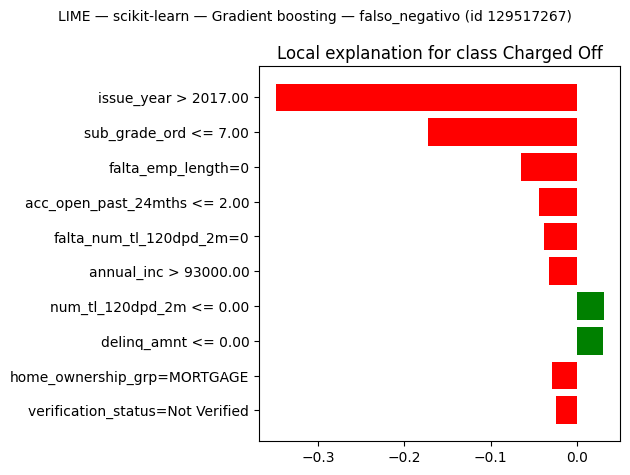

sklearn_gradient_boosting_falso_negativo_129517267 | score del modelo: 0.028726066433195904 | probabilidad LIME local: [-0.07620753]


,condicion,peso
0,issue_year > 2017.00,-0.349351
1,sub_grade_ord <= 7.00,-0.172198
2,falta_emp_length=0,-0.064814
3,acc_open_past_24mths <= 2.00,-0.044211
4,falta_num_tl_120dpd_2m=0,-0.038141
5,annual_inc > 93000.00,-0.032246
6,num_tl_120dpd_2m <= 0.00,0.030673
7,delinq_amnt <= 0.00,0.030205
8,home_ownership_grp=MORTGAGE,-0.029092
9,verification_status=Not Verified,-0.024573


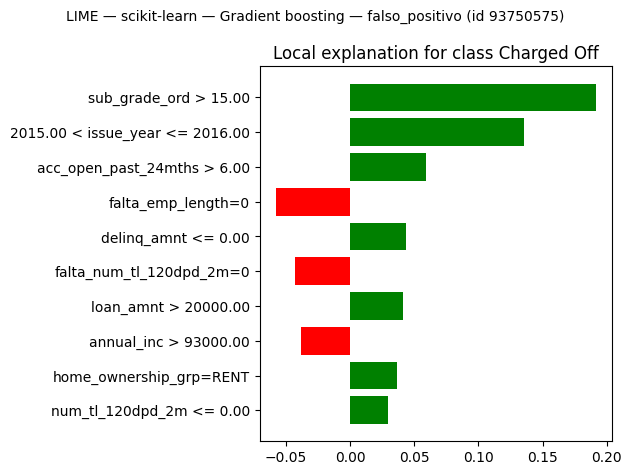

sklearn_gradient_boosting_falso_positivo_93750575 | score del modelo: 0.9195012282936882 | probabilidad LIME local: [0.73615514]


,condicion,peso
0,sub_grade_ord > 15.00,0.191611
1,2015.00 < issue_year <= 2016.00,0.135333
2,acc_open_past_24mths > 6.00,0.059269
3,falta_emp_length=0,-0.057825
4,delinq_amnt <= 0.00,0.043629
5,falta_num_tl_120dpd_2m=0,-0.042843
6,loan_amnt > 20000.00,0.041281
7,annual_inc > 93000.00,-0.038209
8,home_ownership_grp=RENT,0.036944
9,num_tl_120dpd_2m <= 0.00,0.029378


Tiempo LIME (scikit-learn): 19.2 s


In [14]:
# ============================================================
# 9.10.4.7. INTERPRETABILIDAD CON LIME — scikit-learn
# ============================================================
# Requiere: pip install lime
from lime.lime_tabular import LimeTabularExplainer

candidatos_lime = [m for m in MODELOS if TIPO_SCORE[m] == "probabilidad"]
mejor_sk = max(candidatos_lime, key=lambda m: resultados_sk[m]["roc_auc"])
modelo_lime_sk = joblib.load(DIR_SK / f"{mejor_sk}_modelo.joblib")
print(f"Modelo con mayor AUC (entre los que entregan probabilidades): {NOMBRES_MODELOS[mejor_sk]}")

usa_ordinal = mejor_sk in MODELOS_ARBOLES
COLS_LIME = [c for c in COLS_X if usa_ordinal or c != VAR_ORDINAL]
IDX_LIME = [INDICE[c] for c in COLS_LIME]

imputador_ajustado = modelo_lime_sk.named_steps["preprocesamiento"].named_transformers_["num"]
columnas_imputadas = IDX_NUM + ([IDX_ORD] if usa_ordinal else [])
MEDIANAS_IMPUTADOR = dict(zip(columnas_imputadas, imputador_ajustado.statistics_))


def a_espacio_lime_sk(matriz):
    Z = matriz.copy()
    for j, mediana in MEDIANAS_IMPUTADOR.items():
        faltantes = np.isnan(Z[:, j])
        Z[faltantes, j] = mediana
    for j in IDX_LOG:
        Z[:, j] = np.expm1(Z[:, j])
    return Z[:, IDX_LIME]


def predecir_proba_lime_sk(Z_lime):
    completa = np.zeros((Z_lime.shape[0], len(COLS_X)))
    completa[:, IDX_LIME] = Z_lime
    for j in IDX_LOG:
        completa[:, j] = np.log1p(np.clip(completa[:, j], 0, None))
    return modelo_lime_sk.predict_proba(completa)


posicion_lime = {c: i for i, c in enumerate(COLS_LIME)}
categoricas_lime = [posicion_lime[c] for c in VARS_BINARIAS + VARS_CATEGORICAS]
nombres_categoricos_lime = {posicion_lime[c]: ["0", "1"] for c in VARS_BINARIAS}
nombres_categoricos_lime.update({posicion_lime[c]: CATEGORIAS[c] for c in VARS_CATEGORICAS})

t0_lime = time.time()
explicador_sk = LimeTabularExplainer(
    training_data=a_espacio_lime_sk(X_train),
    feature_names=COLS_LIME,
    class_names=["No Charged Off", "Charged Off"],
    categorical_features=categoricas_lime,
    categorical_names=nombres_categoricos_lime,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

scores_mejor_sk = pd.read_parquet(DIR_SK / f"{mejor_sk}_scores.parquet")
prediccion_mejor = scores_mejor_sk["score"] > UMBRALES[mejor_sk]
instancias_sk = pd.concat([
    scores_mejor_sk[(scores_mejor_sk["default"] == 1) & ~prediccion_mejor].nsmallest(1, "score").assign(tipo="falso_negativo"),
    scores_mejor_sk[(scores_mejor_sk["default"] == 0) & prediccion_mejor].nlargest(1, "score").assign(tipo="falso_positivo"),
])
print("Instancias mal clasificadas seleccionadas:")
display(instancias_sk)

posicion_test = pd.Index(id_test_sk).get_indexer(instancias_sk["id"])
X_instancias_lime = a_espacio_lime_sk(X_test[posicion_test])

explicaciones_sk = {}
for fila, (_, instancia) in enumerate(instancias_sk.iterrows()):
    explicacion = explicador_sk.explain_instance(X_instancias_lime[fila], predecir_proba_lime_sk,
                                                 labels=(1,), num_features=LIME_NUM_FEATURES,
                                                 num_samples=LIME_NUM_SAMPLES)
    etiqueta = f"sklearn_{mejor_sk}_{instancia['tipo']}_{int(instancia['id'])}"
    tabla = pd.DataFrame(explicacion.as_list(label=1), columns=["condicion", "peso"])
    tabla.to_csv(DIR_LIME / f"{etiqueta}.csv", index=False)
    explicacion.save_to_file(str(DIR_LIME / f"{etiqueta}.html"))
    figura = explicacion.as_pyplot_figure(label=1)
    figura.suptitle(f"LIME — scikit-learn — {NOMBRES_MODELOS[mejor_sk]} — {instancia['tipo']} (id {int(instancia['id'])})",
                    fontsize=10)
    figura.tight_layout()
    figura.savefig(DIR_LIME / f"{etiqueta}.png", dpi=150, bbox_inches="tight")
    plt.show()
    explicaciones_sk[etiqueta] = tabla
    print(etiqueta, "| score del modelo:", float(instancia["score"]),
          "| probabilidad LIME local:", explicacion.local_pred)
    display(tabla)

t_lime_sk = time.time() - t0_lime
print(f"Tiempo LIME (scikit-learn): {t_lime_sk:.1f} s")


9.10.4.2.3 PySpark sesión y configuración

In [4]:
# ============================================================
# 9.10.4.2. PREPROCESAMIENTO
# ============================================================
# 9.10.4.2.3. PySpark
import os
import sys

# Windows: los procesos de Python de Spark deben usar el mismo intérprete del notebook
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import importlib
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LinearSVC, LogisticRegression,
                                       NaiveBayes, RandomForestClassifier)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler, VectorSlicer
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import config_modelado as cfg
importlib.reload(cfg)
from config_modelado import *

np.random.seed(RANDOM_STATE)
crear_directorios()
assert RUTA_PARTICION.exists(), "Primero se debe generar la partición común (9.10.4.2.1, notebook de scikit-learn)"

# Configuración obligatoria del enunciado.
# ⚠ REVISAR: .master("local[*]") se agrega para ejecución local explícita.
# ⚠ REVISAR: en modo local todo corre en el proceso driver, por lo que spark.executor.memory no tiene efecto;
#            la memoria efectiva es spark.driver.memory (solo se aplica si la sesión se crea por primera vez en el kernel).
# ⚠ REVISAR: spark.sql.execution.arrow.pyspark.enabled se agrega para transferir id/default/score con Arrow.

# La sesión creada en el EDA no tiene la configuración obligatoria: se detiene antes de crear la nueva
sesion_previa = SparkSession.getActiveSession()
if sesion_previa is not None:
    sesion_previa.stop()

spark = SparkSession.builder \
    .appName("LendingClub_Optimized") \
    .master("local[8]") \
    .config("spark.sql.shuffle.partitions", "400") \
    .config("spark.default.parallelism", "400") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "18g") \
    .config("spark.memory.fraction", 0.8) \
    .config("spark.memory.storageFraction", 0.3) \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

conf_spark = {k: v for k, v in spark.sparkContext.getConf().getAll()
              if k.startswith("spark.") and ("memory" in k or "partitions" in k or "parallelism" in k
                                              or "master" in k or "arrow" in k or "app.name" in k)}
HARDWARE_SPARK = registrar_hardware("spark", extra={
    "spark_version": spark.version,
    "java_version": spark.sparkContext._jvm.System.getProperty("java.version"),
    "spark_default_parallelism_efectivo": spark.sparkContext.defaultParallelism,
    "spark_conf": conf_spark,
})
display(pd.Series(HARDWARE_SPARK, name="valor").to_frame())


,valor
entorno,spark
sistema_operativo,Windows-10-10.0.26100-SP0
procesador,"AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD"
python,3.9.25
nucleos_logicos,16
nucleos_fisicos,8
memoria_total_gb,31.87
memoria_disponible_gb,23.73
version_numpy,1.25.2
version_pandas,2.1.0


9.10.4.2.3 PySpark lectura, variables, partición común y caché

In [5]:
# 9.10.4.2.3 — Lectura del CSV completo y construcción de variables (todo en Spark DataFrame)
def mapear_categoria(columna, mapa, defecto):
    expresion = None
    for origen, destino in mapa.items():
        condicion = F.col(columna) == F.lit(origen)
        expresion = F.when(condicion, F.lit(destino)) if expresion is None else expresion.when(condicion, F.lit(destino))
    return expresion.otherwise(F.lit(defecto))


def construir_variables_spark(df):
    col = F.col
    limpieza = {
        "dti": F.when((col("dti") < 0) | (col("dti") == F.lit(DTI_INVALIDO)), F.lit(None).cast("double")).otherwise(col("dti")),
        "annual_inc": F.when(col("annual_inc") <= 0, F.lit(None).cast("double")).otherwise(col("annual_inc")),
        "revol_util": F.when(col("revol_util") > F.lit(REVOL_UTIL_MAX), F.lit(REVOL_UTIL_MAX)).otherwise(col("revol_util")),
    }
    fecha_emision = F.expr("try_to_timestamp(issue_d, 'MMM-yyyy')")
    fecha_credito = F.expr("try_to_timestamp(earliest_cr_line, 'MMM-yyyy')")

    expresiones = [col("id"), col("split"), col("fold"),
                   F.when(col("loan_status") == "Charged Off", 1).otherwise(0).cast("int").alias("default")]
    expresiones += [limpieza.get(c, col(c)).alias(c) for c in VARS_NUMERICAS_BASE]
    expresiones += [
        mapear_categoria("emp_length", MAPA_EMP_LENGTH, None).cast("double").alias("emp_length_num"),
        F.year(fecha_emision).cast("double").alias("issue_year"),
        (((F.year(fecha_emision) - F.year(fecha_credito)) * 12
          + (F.month(fecha_emision) - F.month(fecha_credito))) / F.lit(12.0)).alias("antiguedad_credito_anios"),
        ((F.ascii(F.substring("sub_grade", 1, 1)) - F.lit(65)) * 5
         + F.expr("try_cast(substring(sub_grade, 2, 1) AS INT)")).cast("double").alias(VAR_ORDINAL),
        F.coalesce(col("term").contains("60"), F.lit(False)).cast("int").alias("term_60"),
        F.coalesce(col("application_type") == "Joint App", F.lit(False)).cast("int").alias("solicitud_conjunta"),
        F.coalesce(col("initial_list_status") == "w", F.lit(False)).cast("int").alias("listado_w"),
        (F.coalesce(col("pub_rec"), F.lit(0.0)) > 0).cast("int").alias("tiene_registro_publico"),
        col("mths_since_last_record").isNotNull().cast("int").alias("tuvo_registro_publico"),
        col("mths_since_recent_bc_dlq").isNotNull().cast("int").alias("tuvo_mora_tarjeta"),
        col("mths_since_last_major_derog").isNotNull().cast("int").alias("tuvo_derog_mayor"),
    ]
    expresiones += [col(origen).isNull().cast("int").alias(indicador)
                    for indicador, origen in INDICADORES_FALTANTE.items()]
    expresiones += [
        F.when(col("home_ownership").isin(HOME_OWNERSHIP_OTRAS), F.lit("OTHER"))
         .otherwise(col("home_ownership")).alias("home_ownership_grp"),
        F.when(col("purpose").isin(PURPOSE_RARAS), F.lit("other")).otherwise(col("purpose")).alias("purpose_grp"),
        col("verification_status").alias("verification_status"),
        mapear_categoria("addr_state", REGION_POR_ESTADO, "Desconocida").alias("region"),
    ]
    return df.select(*expresiones)


def aplicar_log_spark(df):
    return df.select(*[
        F.log1p(F.when(F.col(c) < 0, F.lit(0.0)).otherwise(F.col(c))).alias(c) if c in VARS_LOG else F.col(c)
        for c in df.columns])


t0_preprocesamiento = time.time()

# Spark 4 usa modo ANSI por defecto: se usa try_cast para que las filas no numéricas queden como nulas.
crudo = spark.read.csv(str(RUTA_CSV.resolve()), header=True, inferSchema=False, escape='"')
crudo = crudo.select(
    F.expr("try_cast(id AS BIGINT)").alias("id"),
    *[F.col(c) for c in COLS_TEXTO_ORIGEN if c != "id"],
    *[F.expr(f"try_cast({c} AS DOUBLE)").alias(c) for c in COLS_NUMERICAS_ORIGEN],
).filter(F.col("id").isNotNull())

# Partición común (misma que scikit-learn): no se usa randomSplit
particion_spark = spark.read.parquet(str(RUTA_PARTICION.resolve()))
crudo = crudo.join(particion_spark, on="id", how="inner")

base = construir_variables_spark(crudo)      # unidades originales (se reutiliza en LIME)
modelado = aplicar_log_spark(base)

train_df = modelado.filter(F.col("split") == "train")
test_df = modelado.filter(F.col("split") == "test")

# Conteo por clase del entrenamiento (resultado agregado de 2 filas; no se transfiere el dataset)
conteo_clases = {int(r["default"]): int(r["count"]) for r in train_df.groupBy("default").count().collect()}
PESOS = pesos_por_clase(conteo_clases[0], conteo_clases[1])
train_df = train_df.withColumn(
    "peso", F.when(F.col("default") == 1, F.lit(PESOS[1])).otherwise(F.lit(PESOS[0])))

# Transformadores que aprenden de los datos: se ajustan SOLO con el conjunto de entrenamiento.
# ⚠ DECISIÓN METODOLÓGICA: el enunciado exige cachear el DataFrame después del VectorAssembler y antes del
#   modelo. Por eso el imputador, el StringIndexer y el OneHotEncoder se ajustan una vez con todo el
#   entrenamiento (antes de la CV) y no dentro de cada pliegue. El StandardScaler sí se ajusta dentro de
#   cada pliegue (va en el estimador del CrossValidator). El conjunto de prueba nunca participa en ningún ajuste.
COLS_NUM_IMPUTAR = [VAR_ORDINAL] + VARS_NUMERICAS
imputador = Imputer(inputCols=COLS_NUM_IMPUTAR, outputCols=[f"{c}_imp" for c in COLS_NUM_IMPUTAR],
                    strategy="median", relativeError=IMPUTER_RELATIVE_ERROR_SPARK)
indexadores = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", stringOrderType="alphabetAsc", handleInvalid="keep")
               for c in VARS_CATEGORICAS]
codificador = OneHotEncoder(inputCols=[f"{c}_idx" for c in VARS_CATEGORICAS],
                            outputCols=[f"{c}_ohe" for c in VARS_CATEGORICAS],
                            dropLast=False, handleInvalid="keep")
# sub_grade_ord va en la posición 0 del vector para poder excluirlo en los modelos lineales
ensamblador = VectorAssembler(
    inputCols=[f"{c}_imp" for c in COLS_NUM_IMPUTAR] + VARS_BINARIAS + [f"{c}_ohe" for c in VARS_CATEGORICAS],
    outputCol="features", handleInvalid="error")

modelo_preprocesamiento = Pipeline(stages=[imputador, *indexadores, codificador, ensamblador]).fit(train_df)

# Caché obligatoria después del VectorAssembler y antes del modelo
train_vec = (modelo_preprocesamiento.transform(train_df)
             .select("id", "default", "peso", "fold", "features")
             .persist(StorageLevel.MEMORY_AND_DISK))
test_vec = (modelo_preprocesamiento.transform(test_df)
            .select("id", "default", "features")
            .persist(StorageLevel.MEMORY_AND_DISK))
n_train_spark = train_vec.count()
n_test_spark = test_vec.count()
t_preprocesamiento_spark = time.time() - t0_preprocesamiento

metadatos = train_vec.schema["features"].metadata["ml_attr"]
atributos = sorted([a for grupo in metadatos["attrs"].values() for a in grupo], key=lambda a: a["idx"])
NOMBRES_FEATURES_SPARK = [a["name"] for a in atributos]
N_FEATURES_SPARK = int(metadatos["num_attrs"])
assert NOMBRES_FEATURES_SPARK[0].startswith(VAR_ORDINAL)
IDX_LINEALES_SPARK = [i for i, n in enumerate(NOMBRES_FEATURES_SPARK) if not n.startswith(VAR_ORDINAL)]

particion_local = pd.read_parquet(RUTA_PARTICION)
assert n_train_spark == int((particion_local["split"] == "train").sum()), "El train de Spark no coincide con la partición"
assert n_test_spark == int((particion_local["split"] == "test").sum()), "El test de Spark no coincide con la partición"

print(f"Train: {n_train_spark:,} | Test: {n_test_spark:,} | features: {N_FEATURES_SPARK}")
print(f"Pesos por clase (calculados solo con train): {PESOS}")
print(f"Tiempo de preprocesamiento Spark (lectura + variables + ajuste + caché): {t_preprocesamiento_spark:.1f} s")


Train: 1,808,534 | Test: 452,134 | features: 101
Pesos por clase (calculados solo con train): {0: 0.5674056448976493, 1: 4.208888185545993}
Tiempo de preprocesamiento Spark (lectura + variables + ajuste + caché): 89.4 s


9.10.4.3 Modelos y espacios de búsqueda PySpark

In [6]:
# ============================================================
# 9.10.4.3. MODELOS Y ESPACIOS DE BÚSQUEDA
# ============================================================
def crear_evaluador(clave):
    # Árboles y Naive Bayes: la segunda componente de rawPrediction no es monótona con la probabilidad,
    # por eso se evalúa sobre "probability". LinearSVC no entrega probabilidades: se usa rawPrediction.
    return BinaryClassificationEvaluator(
        labelCol="default",
        rawPredictionCol="rawPrediction" if TIPO_SCORE[clave] == "decision_function" else "probability",
        metricName="areaUnderROC", numBins=0)


def crear_estimador_spark(clave):
    columna_features = "features_modelo" if clave in MODELOS_LINEALES else "features"
    comunes = {"labelCol": "default", "featuresCol": columna_features}
    if clave == "regresion_logistica":
        estimador = LogisticRegression(elasticNetParam=0.0, standardization=False, family="binomial",
                                       maxIter=MAX_ITER_LR_SPARK, **comunes)
        grid = ParamGridBuilder().addGrid(estimador.regParam, REG_PARAMS).build()
    elif clave == "arbol_decision":
        estimador = DecisionTreeClassifier(impurity="gini", maxBins=MAX_BINS_SPARK,
                                           maxMemoryInMB=MAX_MEMORY_MB_ARBOLES_SPARK, seed=RANDOM_STATE, **comunes)
        grid = ParamGridBuilder().addGrid(estimador.maxDepth, MAX_DEPTH_ARBOL).build()
    elif clave == "bosque_aleatorio":
        estimador = RandomForestClassifier(impurity="gini", featureSubsetStrategy="sqrt", subsamplingRate=1.0,
                                           bootstrap=True, maxBins=MAX_BINS_SPARK,
                                           maxMemoryInMB=MAX_MEMORY_MB_ARBOLES_SPARK, seed=RANDOM_STATE, **comunes)
        grid = (ParamGridBuilder().addGrid(estimador.numTrees, RF_N_ESTIMATORS)
                .addGrid(estimador.maxDepth, RF_MAX_DEPTH).build())
    elif clave == "gradient_boosting":
        estimador = GBTClassifier(lossType="logistic", stepSize=GB_LEARNING_RATE, subsamplingRate=1.0,
                                  featureSubsetStrategy="all", maxBins=MAX_BINS_SPARK,
                                  maxMemoryInMB=MAX_MEMORY_MB_ARBOLES_SPARK, seed=RANDOM_STATE, **comunes)
        grid = (ParamGridBuilder().addGrid(estimador.maxIter, GB_N_ESTIMATORS)
                .addGrid(estimador.maxDepth, GB_MAX_DEPTH).build())
    elif clave == "svm_lineal":
        estimador = LinearSVC(standardization=False, fitIntercept=True, maxIter=MAX_ITER_SVC_SPARK,
                              threshold=0.0, **comunes)
        grid = ParamGridBuilder().addGrid(estimador.regParam, REG_PARAMS).build()
    elif clave == "naive_bayes":
        estimador = NaiveBayes(modelType="gaussian", **comunes)
        grid = ParamGridBuilder().build()
    else:
        raise ValueError(clave)

    if USAR_PESOS_CLASE:
        estimador.setWeightCol("peso")

    if clave in MODELOS_LINEALES:
        estimador_cv = Pipeline(stages=[
            VectorSlicer(inputCol="features", outputCol="features_lineal", indices=IDX_LINEALES_SPARK),
            StandardScaler(inputCol="features_lineal", outputCol="features_modelo", withMean=True, withStd=True),
            estimador])
    else:
        estimador_cv = estimador
    return estimador, estimador_cv, grid


def crear_cross_validator(clave):
    estimador, estimador_cv, grid = crear_estimador_spark(clave)
    validador = CrossValidator(estimator=estimador_cv, estimatorParamMaps=grid, evaluator=crear_evaluador(clave),
                               numFolds=N_FOLDS, seed=RANDOM_STATE, parallelism=PARALELISMO_CV_SPARK)
    if USAR_PLIEGUES_COMUNES:
        validador = validador.setFoldCol("fold")
    return estimador, validador, grid


tabla_espacios_spark = pd.DataFrame([
    {"modelo": NOMBRES_MODELOS[m],
     "clase_pyspark": type(crear_estimador_spark(m)[0]).__name__,
     "espacio_busqueda": str([{p.name: v for p, v in pm.items()} for pm in crear_estimador_spark(m)[2]]),
     "n_combinaciones": len(crear_estimador_spark(m)[2]),
     "escalado": m in MODELOS_LINEALES, "incluye_sub_grade_ord": m in MODELOS_ARBOLES,
     "maxBins": MAX_BINS_SPARK if m in MODELOS_ARBOLES else None}
    for m in MODELOS])
tabla_espacios_spark.to_csv(DIR_SPARK / "espacios_busqueda_spark.csv", index=False)
display(tabla_espacios_spark)


,modelo,clase_pyspark,espacio_busqueda,n_combinaciones,escalado,incluye_sub_grade_ord,maxBins
0,Regresión logística,LogisticRegression,"[{'regParam': 1e-06}, {'regParam': 1e-05}, {'r...",3,True,False,NaN
1,Árbol de decisión,DecisionTreeClassifier,"[{'maxDepth': 5}, {'maxDepth': 10}, {'maxDepth...",3,False,True,32.0
2,Bosque aleatorio,RandomForestClassifier,"[{'numTrees': 10, 'maxDepth': 5}, {'numTrees':...",9,False,True,32.0
3,Gradient boosting,GBTClassifier,"[{'maxIter': 50, 'maxDepth': 3}, {'maxIter': 5...",4,False,True,32.0
4,SVM lineal,LinearSVC,"[{'regParam': 1e-06}, {'regParam': 1e-05}, {'r...",3,True,False,NaN
5,Naive Bayes,NaiveBayes,[{}],1,True,False,NaN


9.10.4.5 Modelado con PySpark

In [7]:
# ============================================================
# 9.10.4.5. MODELADO CON PYSPARK
# ============================================================
def extract_spark_scores(predicciones, clave):
    columna = "rawPrediction" if TIPO_SCORE[clave] == "decision_function" else "probability"
    return predicciones.withColumn("score", vector_to_array(F.col(columna)).getItem(1))


MODELOS_SPARK = {}


def entrenar_modelo_spark(clave, forzar=FORZAR_REENTRENAMIENTO):
    ruta_resultados = DIR_SPARK / f"{clave}_resultados.json"
    ruta_scores = DIR_SPARK / f"{clave}_scores.parquet"
    if ruta_resultados.exists() and ruta_scores.exists() and not forzar:
        print(f"[{clave}] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False). "
              "El modelo no queda en memoria para LIME.")
        return json.loads(ruta_resultados.read_text(encoding="utf-8"))

    estimador, validador, grid = crear_cross_validator(clave)
    columna_score = "rawPrediction" if TIPO_SCORE[clave] == "decision_function" else "probability"

    t0 = time.time()
    modelo_cv = validador.fit(train_vec)
    t_entrenamiento = time.time() - t0

    t0 = time.time()
    predicciones = (extract_spark_scores(modelo_cv.transform(test_vec), clave)
                    .select("id", "default", "score", columna_score)
                    .persist(StorageLevel.MEMORY_AND_DISK))
    predicciones.count()
    t_prediccion = time.time() - t0

    evaluador_prueba = crear_evaluador(clave)
    auc_roc = evaluador_prueba.evaluate(predicciones)
    auc_pr = evaluador_prueba.setMetricName("areaUnderPR").evaluate(predicciones)

    umbral = UMBRALES[clave]
    confusion = (predicciones.withColumn("pred", (F.col("score") > F.lit(umbral)).cast("int"))
                 .groupBy("default", "pred").count().collect())      # agregado de 4 filas como máximo
    celdas = {(int(r["default"]), int(r["pred"])): int(r["count"]) for r in confusion}
    tn, fp = celdas.get((0, 0), 0), celdas.get((0, 1), 0)
    fn, tp = celdas.get((1, 0), 0), celdas.get((1, 1), 0)
    metricas = metricas_desde_confusion(tn, fp, fn, tp)
    metricas.update({"roc_auc": float(auc_roc), "auc_pr": float(auc_pr), "umbral": float(umbral)})

    # Transferencia al driver SOLO de id, default y score del conjunto de prueba (después del entrenamiento)
    t0 = time.time()
    scores_locales = predicciones.select("id", "default", "score").toPandas()
    t_transferencia = time.time() - t0
    scores_locales.sort_values("id").to_parquet(ruta_scores, index=False)

    mapas = modelo_cv.getEstimatorParamMaps()
    indice_mejor = int(np.argmax(modelo_cv.avgMetrics))
    mejores_parametros = {p.name: v for p, v in mapas[indice_mejor].items()}
    pd.DataFrame([{**{p.name: v for p, v in pm.items()}, "auc_cv_media": m}
                  for pm, m in zip(mapas, modelo_cv.avgMetrics)]).to_csv(DIR_SPARK / f"{clave}_cv_results.csv",
                                                                          index=False)
    resultado = {
        "entorno": "spark", "modelo": clave, "nombre": NOMBRES_MODELOS[clave], "clase": type(estimador).__name__,
        "mejores_parametros": json.dumps(mejores_parametros),
        "auc_cv_mejor": float(modelo_cv.avgMetrics[indice_mejor]),
        "t_entrenamiento_cv_s": float(t_entrenamiento), "t_prediccion_s": float(t_prediccion),
        "t_transferencia_s": float(t_transferencia),
        "n_train": int(n_train_spark), "n_test": int(n_test_spark), "tipo_score": TIPO_SCORE[clave],
        "maxBins": MAX_BINS_SPARK if clave in MODELOS_ARBOLES else None,
        **metricas,
    }
    ruta_resultados.write_text(json.dumps(resultado, indent=2, ensure_ascii=False), encoding="utf-8")
    MODELOS_SPARK[clave] = modelo_cv.bestModel
    predicciones.unpersist()
    plot_confusion_matrix(tn, fp, fn, tp, f"PySpark — {NOMBRES_MODELOS[clave]}",
                          ruta=DIR_FIGURAS / f"confusion_spark_{clave}.png")
    return resultado


resultados_spark = {}


In [8]:
# 9.10.4.5 — Regresión logística
resultados_spark["regresion_logistica"] = entrenar_modelo_spark("regresion_logistica")
display(pd.Series(resultados_spark["regresion_logistica"]).to_frame("valor"))


[regresion_logistica] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False). El modelo no queda en memoria para LIME.


,valor
entorno,spark
modelo,regresion_logistica
nombre,Regresión logística
clase,LogisticRegression
mejores_parametros,"{""regParam"": 1e-06}"
auc_cv_mejor,0.745274
t_entrenamiento_cv_s,1245.49488
t_prediccion_s,2.158528
t_transferencia_s,0.463525
n_train,1808534


In [9]:
# 9.10.4.5 — Árbol de decisión
resultados_spark["arbol_decision"] = entrenar_modelo_spark("arbol_decision")
display(pd.Series(resultados_spark["arbol_decision"]).to_frame("valor"))


[arbol_decision] se cargan resultados existentes (FORZAR_REENTRENAMIENTO=False). El modelo no queda en memoria para LIME.


,valor
entorno,spark
modelo,arbol_decision
nombre,Árbol de decisión
clase,DecisionTreeClassifier
mejores_parametros,"{""maxDepth"": 10}"
auc_cv_mejor,0.754974
t_entrenamiento_cv_s,725.355874
t_prediccion_s,1.957567
t_transferencia_s,0.506909
n_train,1808534


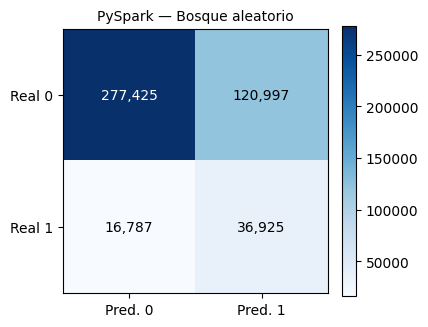

,valor
entorno,spark
modelo,bosque_aleatorio
nombre,Bosque aleatorio
clase,RandomForestClassifier
mejores_parametros,"{""numTrees"": 100, ""maxDepth"": 15}"
auc_cv_mejor,0.762359
t_entrenamiento_cv_s,18169.299107
t_prediccion_s,526.078343
t_transferencia_s,257.966136
n_train,1808534


In [10]:
# 9.10.4.5 — Bosque aleatorio
resultados_spark["bosque_aleatorio"] = entrenar_modelo_spark("bosque_aleatorio")
display(pd.Series(resultados_spark["bosque_aleatorio"]).to_frame("valor"))


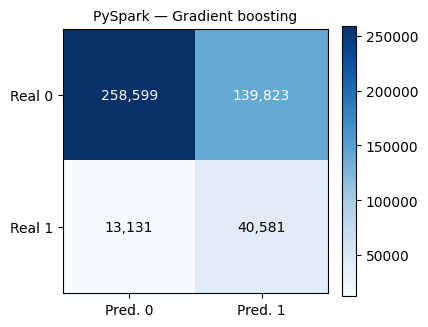

,valor
entorno,spark
modelo,gradient_boosting
nombre,Gradient boosting
clase,GBTClassifier
mejores_parametros,"{""maxIter"": 100, ""maxDepth"": 5}"
auc_cv_mejor,0.772867
t_entrenamiento_cv_s,14671.817837
t_prediccion_s,3.361107
t_transferencia_s,0.700763
n_train,1808534


In [11]:
# 9.10.4.5 — Gradient boosting (GBTClassifier)
resultados_spark["gradient_boosting"] = entrenar_modelo_spark("gradient_boosting")
display(pd.Series(resultados_spark["gradient_boosting"]).to_frame("valor"))


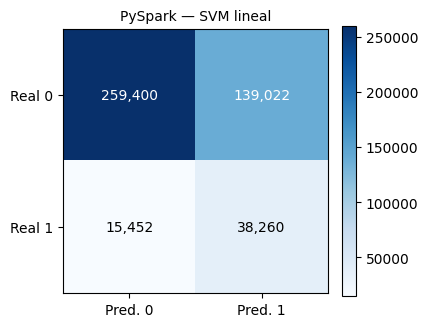

,valor
entorno,spark
modelo,svm_lineal
nombre,SVM lineal
clase,LinearSVC
mejores_parametros,"{""regParam"": 1e-05}"
auc_cv_mejor,0.745086
t_entrenamiento_cv_s,3941.797213
t_prediccion_s,2.108085
t_transferencia_s,0.294842
n_train,1808534


In [12]:
# 9.10.4.5 — SVM lineal
resultados_spark["svm_lineal"] = entrenar_modelo_spark("svm_lineal")
display(pd.Series(resultados_spark["svm_lineal"]).to_frame("valor"))


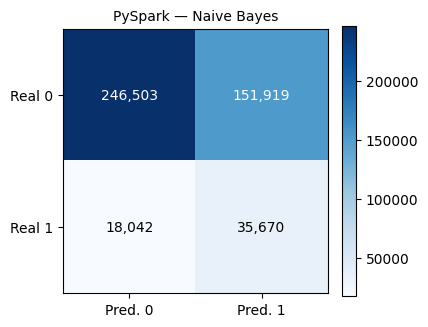

,valor
entorno,spark
modelo,naive_bayes
nombre,Naive Bayes
clase,NaiveBayes
mejores_parametros,{}
auc_cv_mejor,0.682207
t_entrenamiento_cv_s,119.431441
t_prediccion_s,2.095203
t_transferencia_s,0.346115
n_train,1808534


In [13]:
# 9.10.4.5 — Naive Bayes
resultados_spark["naive_bayes"] = entrenar_modelo_spark("naive_bayes")
display(pd.Series(resultados_spark["naive_bayes"]).to_frame("valor"))


,nombre,accuracy,precision,recall,f1,roc_auc,auc_pr,auc_cv_mejor,mejores_parametros,t_entrenamiento_cv_s,t_prediccion_s,t_transferencia_s
0,Regresión logística,0.671075,0.219730,0.693365,0.333707,0.745600,0.262353,0.745274,"{""regParam"": 1e-06}",1245.494880,2.158528,0.463525
1,Árbol de decisión,0.649487,0.216569,0.745197,0.335604,0.756375,0.259709,0.754974,"{""maxDepth"": 10}",725.355874,1.957567,0.506909
2,Bosque aleatorio,0.695258,0.233818,0.687463,0.348951,0.763514,0.287281,0.762359,"{""numTrees"": 100, ""maxDepth"": 15}",18169.299107,526.078343,257.966136
3,Gradient boosting,0.661706,0.224945,0.755529,0.346674,0.773511,0.302331,0.772867,"{""maxIter"": 100, ""maxDepth"": 5}",14671.817837,3.361107,0.700763
4,SVM lineal,0.658345,0.215814,0.712318,0.331264,0.745414,0.260981,0.745086,"{""regParam"": 1e-05}",3941.797213,2.108085,0.294842
5,Naive Bayes,0.624092,0.190150,0.664097,0.295647,0.680782,0.195243,0.682207,{},119.431441,2.095203,0.346115


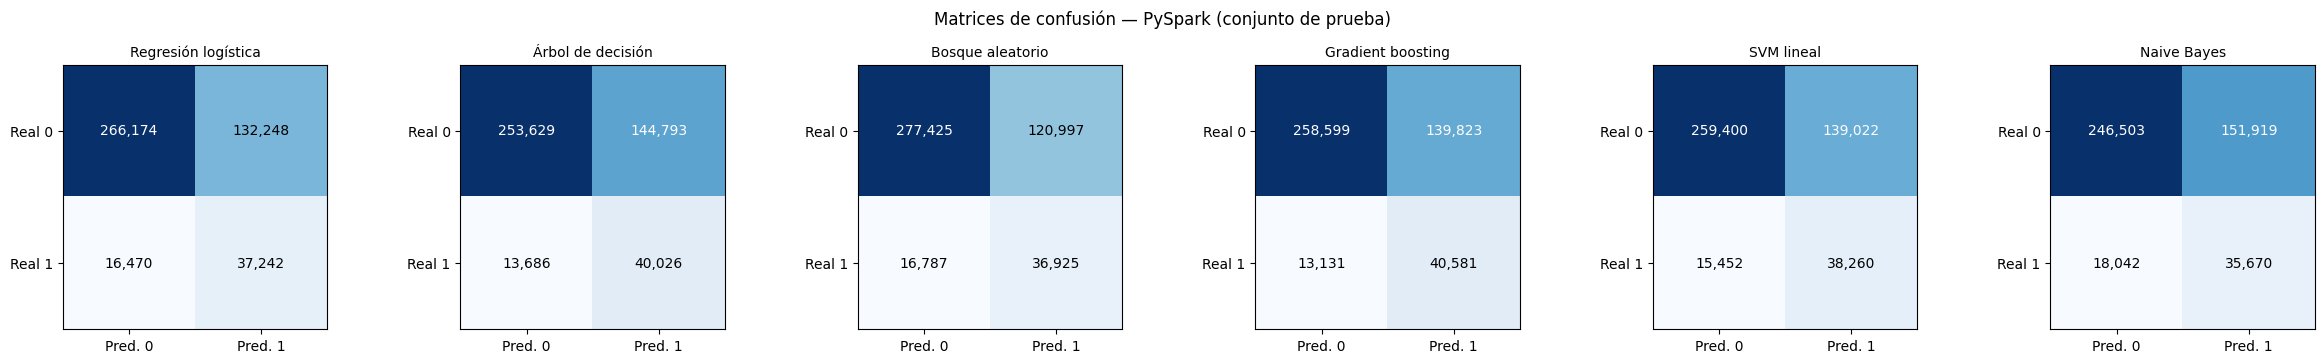

In [14]:
# 9.10.4.5 — Consolidación de resultados de PySpark
metricas_spark = pd.DataFrame([resultados_spark[m] for m in MODELOS])
metricas_spark.to_csv(RUTA_METRICAS_SPARK, index=False)

tiempos_spark = pd.DataFrame({
    "entorno": "spark",
    "modelo": MODELOS,
    "t_preprocesamiento_s": t_preprocesamiento_spark,
    "t_entrenamiento_cv_s": [resultados_spark[m]["t_entrenamiento_cv_s"] for m in MODELOS],
    "t_prediccion_s": [resultados_spark[m]["t_prediccion_s"] for m in MODELOS],
    "t_transferencia_s": [resultados_spark[m]["t_transferencia_s"] for m in MODELOS],
})
tiempos_spark.to_csv(RUTA_TIEMPOS_SPARK, index=False)

ids_test_particion = np.sort(particion_local.loc[particion_local["split"] == "test", "id"].to_numpy())
predicciones_spark = None
for m in MODELOS:
    scores_m = pd.read_parquet(DIR_SPARK / f"{m}_scores.parquet").sort_values("id")
    assert np.array_equal(scores_m["id"].to_numpy(), ids_test_particion)
    if predicciones_spark is None:
        predicciones_spark = scores_m[["id", "default"]].reset_index(drop=True)
    predicciones_spark[f"score_{m}"] = scores_m["score"].to_numpy()
predicciones_spark.to_parquet(RUTA_PRED_SPARK, index=False)

display(metricas_spark[["nombre", "accuracy", "precision", "recall", "f1", "roc_auc", "auc_pr", "auc_cv_mejor",
                        "mejores_parametros", "t_entrenamiento_cv_s", "t_prediccion_s", "t_transferencia_s"]])

fig, ejes = plt.subplots(1, len(MODELOS), figsize=(4 * len(MODELOS), 3.6))
for ax, m in zip(ejes, MODELOS):
    r = resultados_spark[m]
    plot_confusion_matrix(r["tn"], r["fp"], r["fn"], r["tp"], NOMBRES_MODELOS[m], ax=ax)
fig.suptitle("Matrices de confusión — PySpark (conjunto de prueba)")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "confusion_spark_todos.png", dpi=150, bbox_inches="tight")
plt.show()


9.10.4.7 Interpretabilidad con LIME PySpark

Modelo con mayor AUC (entre los que entregan probabilidades): Gradient boosting
Filas de entrenamiento transferidas para LIME: 5,000 de 1,808,534 (6.7 s)
Instancias mal clasificadas seleccionadas:


,id,default,score,tipo
421368,139794277,1,0.026477,falso_negativo
256457,93750575,0,0.936704,falso_positivo


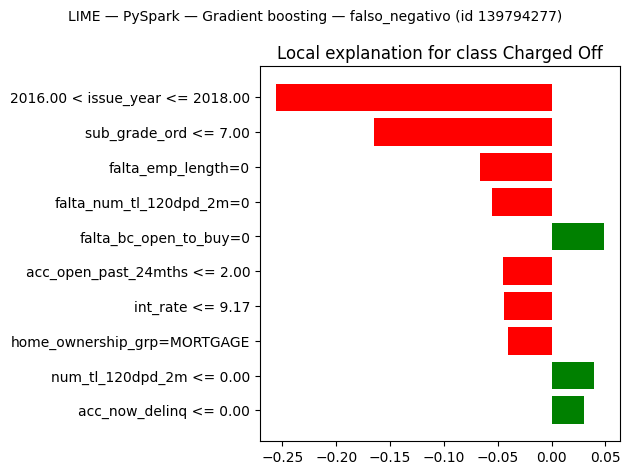

spark_gradient_boosting_falso_negativo_139794277 | score del modelo: 0.02647736298060166 | probabilidad LIME local: [0.04338035]


,condicion,peso
0,2016.00 < issue_year <= 2018.00,-0.255807
1,sub_grade_ord <= 7.00,-0.165011
2,falta_emp_length=0,-0.066438
3,falta_num_tl_120dpd_2m=0,-0.055105
4,falta_bc_open_to_buy=0,0.048264
5,acc_open_past_24mths <= 2.00,-0.045359
6,int_rate <= 9.17,-0.044277
7,home_ownership_grp=MORTGAGE,-0.040826
8,num_tl_120dpd_2m <= 0.00,0.039640
9,acc_now_delinq <= 0.00,0.030459


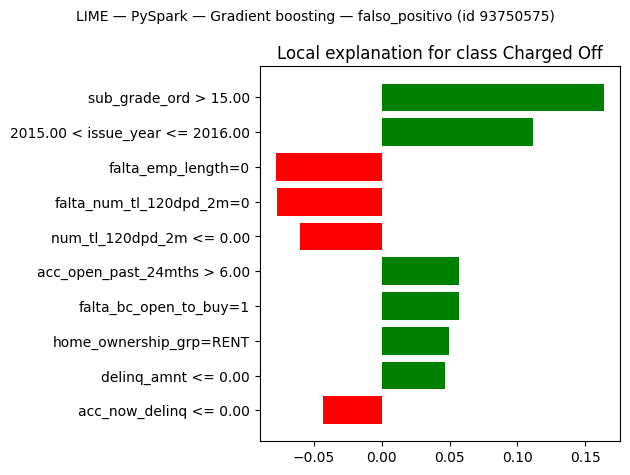

spark_gradient_boosting_falso_positivo_93750575 | score del modelo: 0.9367038144555448 | probabilidad LIME local: [0.74484798]


,condicion,peso
0,sub_grade_ord > 15.00,0.163499
1,2015.00 < issue_year <= 2016.00,0.111515
2,falta_emp_length=0,-0.077705
3,falta_num_tl_120dpd_2m=0,-0.077051
4,num_tl_120dpd_2m <= 0.00,-0.059908
5,acc_open_past_24mths > 6.00,0.057343
6,falta_bc_open_to_buy=1,0.056636
7,home_ownership_grp=RENT,0.049321
8,delinq_amnt <= 0.00,0.046903
9,acc_now_delinq <= 0.00,-0.042805


Tiempo LIME (PySpark, incluye transferencias pequeñas): 19.3 s


In [15]:
# ============================================================
# 9.10.4.7. INTERPRETABILIDAD CON LIME — PySpark
# ============================================================
# Requiere: pip install lime
# LIME opera en memoria local (NumPy). Con PySpark solo se llevan al driver, DESPUÉS del entrenamiento:
#   (1) una muestra pequeña del entrenamiento (LIME_N_MUESTRA_SPARK filas) para las estadísticas de LIME,
#   (2) las 1-2 instancias a explicar y (3) las predicciones de las muestras perturbadas que genera LIME.
from lime.lime_tabular import LimeTabularExplainer

candidatos_lime = [m for m in MODELOS if TIPO_SCORE[m] == "probabilidad"]
mejor_spark = max(candidatos_lime, key=lambda m: resultados_spark[m]["roc_auc"])
if mejor_spark not in MODELOS_SPARK:
    raise RuntimeError(f"El modelo {mejor_spark} no está en memoria: reentrenarlo con forzar=True antes de LIME.")
modelo_lime_spark = MODELOS_SPARK[mejor_spark]
print(f"Modelo con mayor AUC (entre los que entregan probabilidades): {NOMBRES_MODELOS[mejor_spark]}")

usa_ordinal = mejor_spark in MODELOS_ARBOLES
COLS_LIME = [c for c in COLS_X if usa_ordinal or c != VAR_ORDINAL]

# Medianas aprendidas por el Imputer de Spark (tabla de 1 fila), en la escala log1p para VARS_LOG
medianas_spark = modelo_preprocesamiento.stages[0].surrogateDF.first().asDict()
MEDIANAS_ORIGINALES = {c: (float(np.expm1(medianas_spark[c])) if c in VARS_LOG else float(medianas_spark[c]))
                       for c in COLS_NUM_IMPUTAR}


def a_espacio_lime_spark(pdf):
    Z = pd.DataFrame(index=pdf.index)
    for c in COLS_LIME:
        if c in CATEGORIAS:
            Z[c] = pd.Categorical(pdf[c], categories=CATEGORIAS[c]).codes.astype("float64")
        elif c in VARS_BINARIAS:
            Z[c] = pdf[c].astype("float64")
        else:
            Z[c] = pdf[c].astype("float64").fillna(MEDIANAS_ORIGINALES[c])
    return Z[COLS_LIME].to_numpy()


def predecir_proba_lime_spark(Z_lime):
    local = pd.DataFrame(Z_lime, columns=COLS_LIME)
    if VAR_ORDINAL not in local.columns:
        local[VAR_ORDINAL] = 0.0      # no lo usan los modelos lineales (VectorSlicer lo excluye)
    for c in VARS_BINARIAS:
        local[c] = local[c].round().astype("int32")
    for c in VARS_CATEGORICAS:
        codigos = local[c].round().astype(int).clip(0, len(CATEGORIAS[c]) - 1)
        local[c] = np.array(CATEGORIAS[c], dtype=object)[codigos.to_numpy()]
    local["_fila"] = np.arange(len(local))
    sdf = aplicar_log_spark(spark.createDataFrame(local))
    probas = (modelo_lime_spark.transform(modelo_preprocesamiento.transform(sdf))
              .select("_fila", vector_to_array("probability").getItem(1).alias("p1"))
              .toPandas().sort_values("_fila")["p1"].to_numpy())
    return np.column_stack([1.0 - probas, probas])


t0_lime = time.time()
fraccion_lime = min(1.0, 1.5 * LIME_N_MUESTRA_SPARK / n_train_spark)
muestra_entrenamiento = (base.filter(F.col("split") == "train")
                         .select(*COLS_X)
                         .sample(withReplacement=False, fraction=fraccion_lime, seed=RANDOM_STATE)
                         .limit(LIME_N_MUESTRA_SPARK)
                         .toPandas())
t_transferencia_lime = time.time() - t0_lime
print(f"Filas de entrenamiento transferidas para LIME: {len(muestra_entrenamiento):,} "
      f"de {n_train_spark:,} ({t_transferencia_lime:.1f} s)")

posicion_lime = {c: i for i, c in enumerate(COLS_LIME)}
categoricas_lime = [posicion_lime[c] for c in VARS_BINARIAS + VARS_CATEGORICAS]
nombres_categoricos_lime = {posicion_lime[c]: ["0", "1"] for c in VARS_BINARIAS}
nombres_categoricos_lime.update({posicion_lime[c]: CATEGORIAS[c] for c in VARS_CATEGORICAS})

explicador_spark = LimeTabularExplainer(
    training_data=a_espacio_lime_spark(muestra_entrenamiento),
    feature_names=COLS_LIME,
    class_names=["No Charged Off", "Charged Off"],
    categorical_features=categoricas_lime,
    categorical_names=nombres_categoricos_lime,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

scores_mejor_spark = pd.read_parquet(DIR_SPARK / f"{mejor_spark}_scores.parquet")
prediccion_mejor = scores_mejor_spark["score"] > UMBRALES[mejor_spark]
instancias_spark = pd.concat([
    scores_mejor_spark[(scores_mejor_spark["default"] == 1) & ~prediccion_mejor].nsmallest(1, "score").assign(tipo="falso_negativo"),
    scores_mejor_spark[(scores_mejor_spark["default"] == 0) & prediccion_mejor].nlargest(1, "score").assign(tipo="falso_positivo"),
])
print("Instancias mal clasificadas seleccionadas:")
display(instancias_spark)

ids_instancias = [int(i) for i in instancias_spark["id"]]
filas_instancias = (base.filter((F.col("split") == "test") & F.col("id").isin(ids_instancias))
                    .select("id", *COLS_X).toPandas().set_index("id").loc[ids_instancias].reset_index())
X_instancias_lime = a_espacio_lime_spark(filas_instancias)

explicaciones_spark = {}
for fila, (_, instancia) in enumerate(instancias_spark.iterrows()):
    explicacion = explicador_spark.explain_instance(X_instancias_lime[fila], predecir_proba_lime_spark,
                                                    labels=(1,), num_features=LIME_NUM_FEATURES,
                                                    num_samples=LIME_NUM_SAMPLES)
    etiqueta = f"spark_{mejor_spark}_{instancia['tipo']}_{int(instancia['id'])}"
    tabla = pd.DataFrame(explicacion.as_list(label=1), columns=["condicion", "peso"])
    tabla.to_csv(DIR_LIME / f"{etiqueta}.csv", index=False)
    explicacion.save_to_file(str(DIR_LIME / f"{etiqueta}.html"))
    figura = explicacion.as_pyplot_figure(label=1)
    figura.suptitle(f"LIME — PySpark — {NOMBRES_MODELOS[mejor_spark]} — {instancia['tipo']} (id {int(instancia['id'])})",
                    fontsize=10)
    figura.tight_layout()
    figura.savefig(DIR_LIME / f"{etiqueta}.png", dpi=150, bbox_inches="tight")
    plt.show()
    explicaciones_spark[etiqueta] = tabla
    print(etiqueta, "| score del modelo:", float(instancia["score"]),
          "| probabilidad LIME local:", explicacion.local_pred)
    display(tabla)

t_lime_spark = time.time() - t0_lime
print(f"Tiempo LIME (PySpark, incluye transferencias pequeñas): {t_lime_spark:.1f} s")


In [16]:
# Liberar memoria de Spark al terminar
train_vec.unpersist()
test_vec.unpersist()
# spark.stop()


DataFrame[id: bigint, default: int, features: vector]

9.10.4.6 Comparación estadística de los modelos

In [17]:
# ============================================================
# 9.10.4.6. COMPARACIÓN ESTADÍSTICA DE LOS MODELOS
# ============================================================
import importlib
import itertools
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

import config_modelado as cfg
importlib.reload(cfg)
from config_modelado import *

np.random.seed(RANDOM_STATE)
crear_directorios()
ENTORNOS = ["sklearn", "spark"]
NOMBRE_ENTORNO = {"sklearn": "scikit-learn", "spark": "PySpark"}

# Vector común de etiquetas y puntuaciones: mismas observaciones de prueba en ambos entornos
pred_sk = pd.read_parquet(RUTA_PRED_SK)
pred_sp = pd.read_parquet(RUTA_PRED_SPARK)
comun = pred_sk.merge(pred_sp, on="id", how="inner", suffixes=("_sk", "_sp"), validate="one_to_one")
particion = pd.read_parquet(RUTA_PARTICION)
n_test_particion = int((particion["split"] == "test").sum())
assert len(comun) == len(pred_sk) == len(pred_sp) == n_test_particion, "Los conjuntos de prueba no coinciden"
assert (comun["default_sk"].to_numpy() == comun["default_sp"].to_numpy()).all(), "Las etiquetas no coinciden"
comun = comun.sort_values("id").reset_index(drop=True)

Y_TEST = comun["default_sk"].to_numpy().astype(int)
SCORES = {
    "sklearn": {m: comun[f"score_{m}_sk"].to_numpy().astype(float) for m in MODELOS},
    "spark": {m: comun[f"score_{m}_sp"].to_numpy().astype(float) for m in MODELOS},
}
print(f"Observaciones de prueba comunes: {len(Y_TEST):,} | positivos: {Y_TEST.sum():,} | tasa: {Y_TEST.mean():.4f}")


def apply_holm(p_valores, alfa=ALFA):
    p = np.asarray(p_valores, dtype=float)
    m = len(p)
    orden = np.argsort(p)
    ajustados = np.empty(m)
    acumulado = 0.0
    for rango, i in enumerate(orden):
        acumulado = max(acumulado, min(1.0, (m - rango) * p[i]))
        ajustados[i] = acumulado
    return ajustados, ajustados < alfa


Observaciones de prueba comunes: 452,134 | positivos: 53,712 | tasa: 0.1188


9.10.4.6.1 Prueba de DeLong

In [18]:
# ------------------------------------------------------------
# 9.10.4.6.1. Prueba de DeLong
# ------------------------------------------------------------
# Versión rápida O(n log n) de Sun y Xu (2014), "Fast implementation of DeLong's algorithm for comparing the
# areas under correlated receiver operating characteristic curves", IEEE Signal Processing Letters 21(11).
# Estructura adaptada de la implementación de referencia yandexdataschool/roc_comparison (licencia MIT).
def _rangos_medios(x):
    return stats.rankdata(x, method="average")


def fast_delong(predicciones_ordenadas, n_positivos):
    m = n_positivos
    n = predicciones_ordenadas.shape[1] - m
    positivos = predicciones_ordenadas[:, :m]
    negativos = predicciones_ordenadas[:, m:]
    k = predicciones_ordenadas.shape[0]
    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = _rangos_medios(positivos[r, :])
        ty[r, :] = _rangos_medios(negativos[r, :])
        tz[r, :] = _rangos_medios(predicciones_ordenadas[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    covarianza = sx / m + sy / n
    return aucs, covarianza


def delong_aucs_covarianza(y_true, lista_scores):
    y_true = np.asarray(y_true).astype(int)
    orden = np.argsort(-y_true, kind="mergesort")      # positivos primero
    n_positivos = int(y_true.sum())
    matriz = np.vstack([np.asarray(s, dtype=float) for s in lista_scores])[:, orden]
    return fast_delong(matriz, n_positivos)


def delong_directo(y_true, lista_scores):
    """Versión directa O(m·n) solo para validar con conjuntos pequeños."""
    y_true = np.asarray(y_true).astype(int)
    k = len(lista_scores)
    m, n = int(y_true.sum()), int((1 - y_true).sum())
    v10 = np.empty([k, m])
    v01 = np.empty([k, n])
    aucs = np.empty(k)
    for r, s in enumerate(lista_scores):
        s = np.asarray(s, dtype=float)
        x, yy = s[y_true == 1], s[y_true == 0]
        psi = (x[:, None] > yy[None, :]).astype(float) + 0.5 * (x[:, None] == yy[None, :])
        aucs[r] = psi.mean()
        v10[r] = psi.mean(axis=1)
        v01[r] = psi.mean(axis=0)
    covarianza = np.atleast_2d(np.cov(v10)) / m + np.atleast_2d(np.cov(v01)) / n
    return aucs, covarianza


def run_delong(y_true, score_1, score_2, alfa=ALFA):
    aucs, cov = delong_aucs_covarianza(y_true, [score_1, score_2])
    z_critico = stats.norm.ppf(1 - alfa / 2)
    se_1, se_2 = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
    delta = aucs[0] - aucs[1]
    var_delta = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    se_delta = np.sqrt(var_delta) if var_delta > 0 else 0.0
    if se_delta > 0:
        z = delta / se_delta
        p = 2 * stats.norm.sf(abs(z))
    else:
        z, p = np.nan, 1.0
    return {
        "auc_1": aucs[0], "ic95_auc_1_inf": aucs[0] - z_critico * se_1, "ic95_auc_1_sup": aucs[0] + z_critico * se_1,
        "auc_2": aucs[1], "ic95_auc_2_inf": aucs[1] - z_critico * se_2, "ic95_auc_2_sup": aucs[1] + z_critico * se_2,
        "delta_auc": delta, "ic95_delta_inf": delta - z_critico * se_delta, "ic95_delta_sup": delta + z_critico * se_delta,
        "z": z, "p_valor": p,
    }


In [19]:
# 9.10.4.6.1 — Validación de la implementación rápida (conjunto pequeño)
rng_validacion = np.random.default_rng(RANDOM_STATE)
filas_validacion = []
for caso in range(5):
    n_val = 400
    y_val = rng_validacion.binomial(1, 0.25, n_val)
    base_val = y_val * 0.8 + rng_validacion.normal(size=n_val)
    s_a = np.round(base_val + rng_validacion.normal(scale=0.5, size=n_val), 1)     # con empates
    s_b = np.round(base_val + rng_validacion.normal(scale=1.0, size=n_val), 1)
    auc_rapido, cov_rapida = delong_aucs_covarianza(y_val, [s_a, s_b])
    auc_directo, cov_directa = delong_directo(y_val, [s_a, s_b])
    filas_validacion.append({
        "caso": caso,
        "max_dif_auc_rapido_vs_directo": float(np.max(np.abs(auc_rapido - auc_directo))),
        "max_dif_cov_rapida_vs_directa": float(np.max(np.abs(cov_rapida - cov_directa))),
        "max_dif_auc_rapido_vs_sklearn": float(max(abs(auc_rapido[0] - roc_auc_score(y_val, s_a)),
                                                   abs(auc_rapido[1] - roc_auc_score(y_val, s_b)))),
        "coincide": bool(np.allclose(auc_rapido, auc_directo) and np.allclose(cov_rapida, cov_directa)),
    })
    if caso == 0:
        pd.DataFrame({"y": y_val, "s_a": s_a, "s_b": s_b}).to_csv(DIR_RESULTADOS / "delong_validacion_datos.csv",
                                                                  index=False)
validacion_delong = pd.DataFrame(filas_validacion)
validacion_delong.to_csv(RUTA_DELONG_VALIDACION, index=False)
display(validacion_delong)
assert validacion_delong["coincide"].all(), "La implementación rápida de DeLong no coincide con la directa"

# Validación opcional con R/pROC (ejecutar en R con el archivo delong_validacion_datos.csv):
CODIGO_R_PROC = """
library(pROC)
d <- read.csv("delong_validacion_datos.csv")
r1 <- roc(d$y, d$s_a, direction = "<", quiet = TRUE)
r2 <- roc(d$y, d$s_b, direction = "<", quiet = TRUE)
roc.test(r1, r2, method = "delong", paired = TRUE)
"""
print(CODIGO_R_PROC)
r_py = run_delong(pd.read_csv(DIR_RESULTADOS / "delong_validacion_datos.csv")["y"],
                  pd.read_csv(DIR_RESULTADOS / "delong_validacion_datos.csv")["s_a"],
                  pd.read_csv(DIR_RESULTADOS / "delong_validacion_datos.csv")["s_b"])
print("Resultado Python para comparar con pROC (caso 0):", {k: r_py[k] for k in ["auc_1", "auc_2", "z", "p_valor"]})


,caso,max_dif_auc_rapido_vs_directo,max_dif_cov_rapida_vs_directa,max_dif_auc_rapido_vs_sklearn,coincide
0,0,0.000000e+00,0.000000e+00,1.110223e-16,True
1,1,1.110223e-16,0.000000e+00,1.110223e-16,True
2,2,1.110223e-16,0.000000e+00,1.110223e-16,True
3,3,0.000000e+00,1.084202e-19,1.110223e-16,True
4,4,0.000000e+00,0.000000e+00,1.110223e-16,True



library(pROC)
d <- read.csv("delong_validacion_datos.csv")
r1 <- roc(d$y, d$s_a, direction = "<", quiet = TRUE)
r2 <- roc(d$y, d$s_b, direction = "<", quiet = TRUE)
roc.test(r1, r2, method = "delong", paired = TRUE)

Resultado Python para comparar con pROC (caso 0): {'auc_1': 0.704841219907944, 'auc_2': 0.6834994536242922, 'z': 0.7844830928563521, 'p_valor': 0.43275669874417344}


In [20]:
# 9.10.4.6.1 — Familias de comparaciones
def etiqueta(entorno, modelo):
    return f"{NOMBRE_ENTORNO[entorno]} · {NOMBRES_MODELOS[modelo]}"


filas_delong = []
for m in MODELOS:
    r = run_delong(Y_TEST, SCORES["sklearn"][m], SCORES["spark"][m])
    filas_delong.append({"familia": "entre_entornos", "entorno": "sklearn vs spark",
                         "modelo_1": m, "entorno_1": "sklearn", "modelo_2": m, "entorno_2": "spark",
                         "comparacion": f"{NOMBRES_MODELOS[m]}: scikit-learn vs PySpark", **r})
for entorno in ENTORNOS:
    for m1, m2 in itertools.combinations(MODELOS, 2):
        r = run_delong(Y_TEST, SCORES[entorno][m1], SCORES[entorno][m2])
        filas_delong.append({"familia": f"entre_modelos_{entorno}", "entorno": entorno,
                             "modelo_1": m1, "entorno_1": entorno, "modelo_2": m2, "entorno_2": entorno,
                             "comparacion": f"{NOMBRES_MODELOS[m1]} vs {NOMBRES_MODELOS[m2]} ({NOMBRE_ENTORNO[entorno]})",
                             **r})
delong = pd.DataFrame(filas_delong)

delong["p_ajustado_holm"] = np.nan
delong["significativo_holm"] = False
for familia, indices in delong.groupby("familia").groups.items():
    ajustados, significativos = apply_holm(delong.loc[indices, "p_valor"].to_numpy())
    delong.loc[indices, "p_ajustado_holm"] = ajustados
    delong.loc[indices, "significativo_holm"] = significativos
delong["relevante_practica"] = delong["delta_auc"].abs() >= MARGEN_RELEVANCIA_AUC
delong["conclusion"] = np.select(
    [delong["significativo_holm"] & delong["relevante_practica"],
     delong["significativo_holm"] & ~delong["relevante_practica"]],
    ["significativa y relevante", "significativa pero no relevante"],
    default="no significativa")
delong["margen_relevancia"] = MARGEN_RELEVANCIA_AUC
delong.to_csv(RUTA_DELONG, index=False)

print("Número de comparaciones por familia:")
display(delong["familia"].value_counts().to_frame("n"))
display(delong[["familia", "comparacion", "auc_1", "ic95_auc_1_inf", "ic95_auc_1_sup", "auc_2", "ic95_auc_2_inf",
                "ic95_auc_2_sup", "delta_auc", "ic95_delta_inf", "ic95_delta_sup", "z", "p_valor",
                "p_ajustado_holm", "significativo_holm", "relevante_practica", "conclusion"]])

LIMITACIONES_DELONG = pd.DataFrame({"limitacion": [
    "Solo captura la variabilidad por el muestreo del conjunto de prueba.",
    "No incorpora la variabilidad del entrenamiento (particiones de la validación cruzada, datos de entrenamiento).",
    "No captura la variabilidad por semillas aleatorias.",
    "No captura completamente la variabilidad de modelos estocásticos (bosque aleatorio, boosting).",
    "Supone observaciones independientes.",
    "El AUC resume todos los umbrales; puede no reflejar el desempeño en el umbral operativo.",
    f"Con n grande, diferencias pequeñas son significativas: se usa un margen de relevancia |ΔAUC| ≥ {MARGEN_RELEVANCIA_AUC} (parametrizable).",
]})
display(LIMITACIONES_DELONG)


Número de comparaciones por familia:


,n
familia,
entre_modelos_sklearn,15
entre_modelos_spark,15
entre_entornos,6


,familia,comparacion,auc_1,ic95_auc_1_inf,ic95_auc_1_sup,auc_2,ic95_auc_2_inf,ic95_auc_2_sup,delta_auc,ic95_delta_inf,ic95_delta_sup,z,p_valor,p_ajustado_holm,significativo_holm,relevante_practica,conclusion
0,entre_entornos,Regresión logística: scikit-learn vs PySpark,0.745598,0.743561,0.747636,0.745600,0.743563,0.747638,-0.000002,-5.075483e-06,0.000001,-1.282945,1.995112e-01,3.990224e-01,False,False,no significativa
1,entre_entornos,Árbol de decisión: scikit-learn vs PySpark,0.758172,0.756203,0.760140,0.756375,0.754402,0.758348,0.001797,1.143522e-03,0.002450,5.391586,6.983840e-08,4.190304e-07,True,False,significativa pero no relevante
2,entre_entornos,Bosque aleatorio: scikit-learn vs PySpark,0.763073,0.761123,0.765023,0.763514,0.761566,0.765461,-0.000440,-7.380341e-04,-0.000143,-2.898586,3.748499e-03,1.268893e-02,True,False,significativa pero no relevante
3,entre_entornos,Gradient boosting: scikit-learn vs PySpark,0.772840,0.770929,0.774751,0.773511,0.771604,0.775418,-0.000671,-1.010719e-03,-0.000331,-3.872212,1.078522e-04,5.392611e-04,True,False,significativa pero no relevante
4,entre_entornos,SVM lineal: scikit-learn vs PySpark,0.745416,0.743381,0.747451,0.745414,0.743379,0.747448,0.000002,-8.662089e-05,0.000091,0.047394,9.621992e-01,9.621992e-01,False,False,no significativa
5,entre_entornos,Naive Bayes: scikit-learn vs PySpark,0.680784,0.678476,0.683091,0.680782,0.678475,0.683089,0.000001,4.157504e-07,0.000002,2.950536,3.172232e-03,1.268893e-02,True,False,significativa pero no relevante
6,entre_modelos_sklearn,Regresión logística vs Árbol de decisión (scik...,0.745598,0.743561,0.747636,0.758172,0.756203,0.760140,-0.012573,-1.387374e-02,-0.011272,-18.946265,4.740627e-80,1.422188e-79,True,True,significativa y relevante
7,entre_modelos_sklearn,Regresión logística vs Bosque aleatorio (sciki...,0.745598,0.743561,0.747636,0.763073,0.761123,0.765023,-0.017475,-1.854358e-02,-0.016406,-32.045997,2.496179e-225,1.497707e-224,True,True,significativa y relevante
8,entre_modelos_sklearn,Regresión logística vs Gradient boosting (scik...,0.745598,0.743561,0.747636,0.772840,0.770929,0.774751,-0.027241,-2.830782e-02,-0.026175,-50.070991,0.000000e+00,0.000000e+00,True,True,significativa y relevante
9,entre_modelos_sklearn,Regresión logística vs SVM lineal (scikit-learn),0.745598,0.743561,0.747636,0.745416,0.743381,0.747451,0.000183,5.107448e-05,0.000314,2.720843,6.511569e-03,6.511569e-03,True,False,significativa pero no relevante


,limitacion
0,Solo captura la variabilidad por el muestreo d...
1,No incorpora la variabilidad del entrenamiento...
2,No captura la variabilidad por semillas aleato...
3,No captura completamente la variabilidad de mo...
4,Supone observaciones independientes.
5,El AUC resume todos los umbrales; puede no ref...
6,"Con n grande, diferencias pequeñas son signifi..."


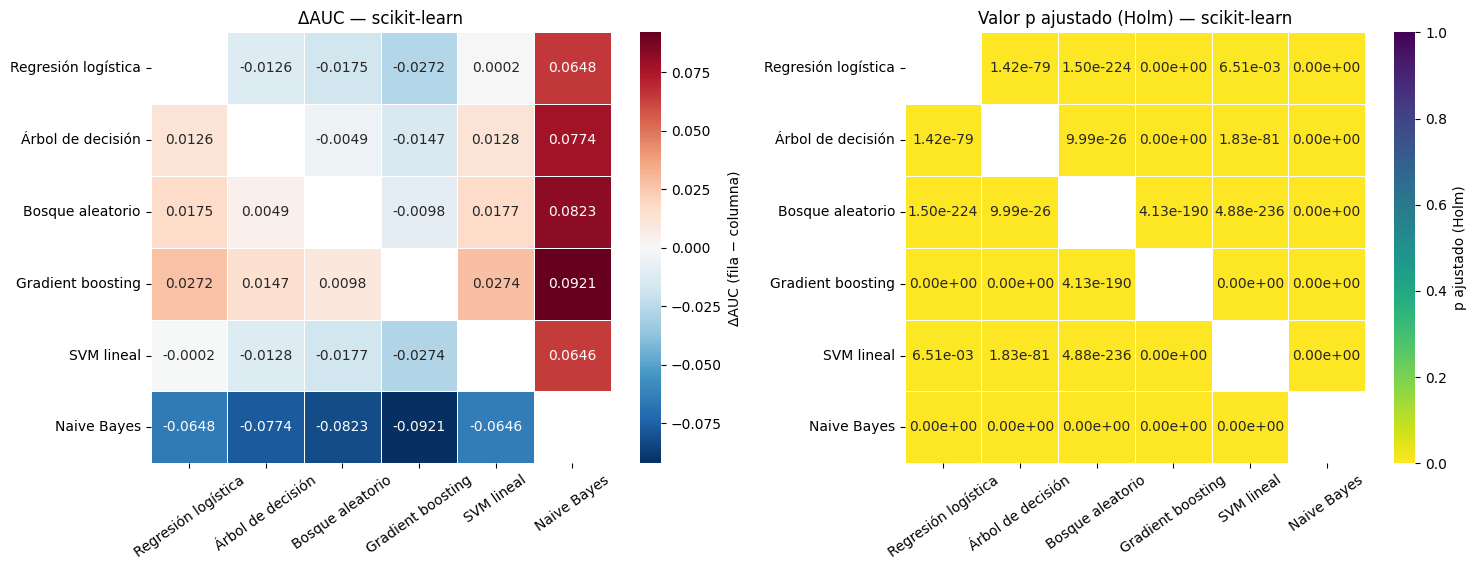

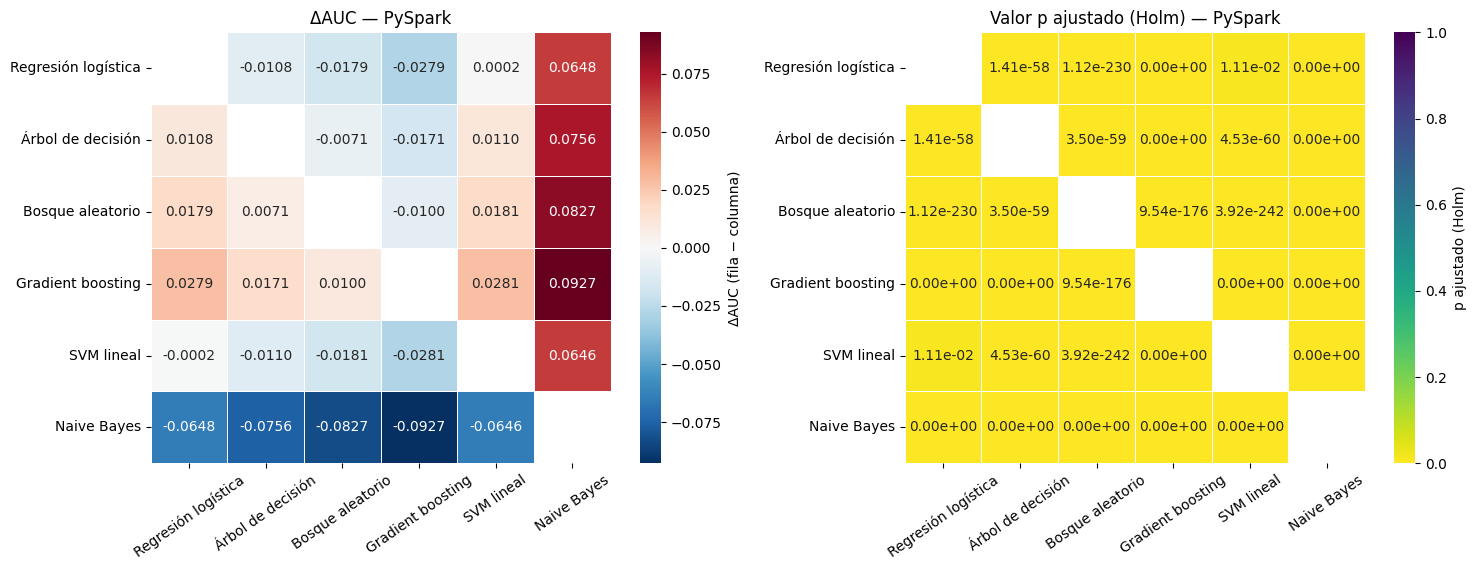

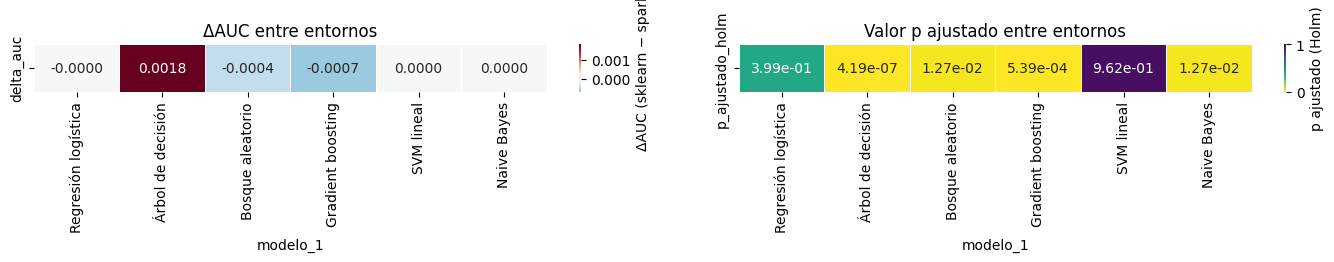

In [21]:
# 9.10.4.6.1 — Mapas de calor de ΔAUC y p ajustado (uno por entorno)
def matrices_delong(entorno):
    familia = delong[delong["familia"] == f"entre_modelos_{entorno}"]
    nombres = [NOMBRES_MODELOS[m] for m in MODELOS]
    delta = pd.DataFrame(np.nan, index=nombres, columns=nombres)
    p_aj = pd.DataFrame(np.nan, index=nombres, columns=nombres)
    for _, fila in familia.iterrows():
        a, b = NOMBRES_MODELOS[fila["modelo_1"]], NOMBRES_MODELOS[fila["modelo_2"]]
        delta.loc[a, b], delta.loc[b, a] = fila["delta_auc"], -fila["delta_auc"]
        p_aj.loc[a, b] = p_aj.loc[b, a] = fila["p_ajustado_holm"]
    return delta, p_aj


def plot_heatmaps_delong(entorno):
    delta, p_aj = matrices_delong(entorno)
    fig, ejes = plt.subplots(1, 2, figsize=(15, 5.8))
    limite = np.nanmax(np.abs(delta.to_numpy())) if np.isfinite(delta.to_numpy()).any() else 1.0
    sns.heatmap(delta, annot=True, fmt=".4f", cmap="RdBu_r", center=0, vmin=-limite, vmax=limite,
                linewidths=0.5, ax=ejes[0], cbar_kws={"label": "ΔAUC (fila − columna)"})
    ejes[0].set_title(f"ΔAUC — {NOMBRE_ENTORNO[entorno]}")
    sns.heatmap(p_aj, annot=True, fmt=".2e", cmap="viridis_r", vmin=0, vmax=1, linewidths=0.5, ax=ejes[1],
                cbar_kws={"label": "p ajustado (Holm)"})
    ejes[1].set_title(f"Valor p ajustado (Holm) — {NOMBRE_ENTORNO[entorno]}")
    for ax in ejes:
        ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(DIR_FIGURAS / f"delong_heatmap_{entorno}.png", dpi=150, bbox_inches="tight")
    plt.show()


for entorno in ENTORNOS:
    plot_heatmaps_delong(entorno)

entre = delong[delong["familia"] == "entre_entornos"].set_index("modelo_1")
fig, ejes = plt.subplots(1, 2, figsize=(14, 2.6))
sns.heatmap(entre[["delta_auc"]].rename(index=NOMBRES_MODELOS).T, annot=True, fmt=".4f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ejes[0], cbar_kws={"label": "ΔAUC (sklearn − spark)"})
ejes[0].set_title("ΔAUC entre entornos")
sns.heatmap(entre[["p_ajustado_holm"]].rename(index=NOMBRES_MODELOS).T, annot=True, fmt=".2e", cmap="viridis_r",
            vmin=0, vmax=1, linewidths=0.5, ax=ejes[1], cbar_kws={"label": "p ajustado (Holm)"})
ejes[1].set_title("Valor p ajustado entre entornos")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "delong_heatmap_entre_entornos.png", dpi=150, bbox_inches="tight")
plt.show()


9.10.4.6.2 Pruebas complementarias_ McNemar y bootstrap pareadp

In [22]:
# ------------------------------------------------------------
# 9.10.4.6.2. Pruebas complementarias: McNemar y bootstrap pareado
# ------------------------------------------------------------
AUC_TEST = {e: {m: float(roc_auc_score(Y_TEST, SCORES[e][m])) for m in MODELOS} for e in ENTORNOS}
MEJOR_PAR = {e: sorted(MODELOS, key=lambda m: AUC_TEST[e][m], reverse=True)[:2] for e in ENTORNOS}
display(pd.DataFrame(AUC_TEST).rename(index=NOMBRES_MODELOS))
print("Par con mayor AUC por entorno:", {e: [NOMBRES_MODELOS[m] for m in par] for e, par in MEJOR_PAR.items()})

COMPARACIONES = (
    [{"familia": "A_entre_entornos", "entorno": "sklearn vs spark", "comparacion": f"{NOMBRES_MODELOS[m]}: scikit-learn vs PySpark",
      "entorno_1": "sklearn", "modelo_1": m, "entorno_2": "spark", "modelo_2": m} for m in MODELOS]
    + [{"familia": "B_mejor_par_por_entorno", "entorno": e,
        "comparacion": f"{NOMBRES_MODELOS[MEJOR_PAR[e][0]]} vs {NOMBRES_MODELOS[MEJOR_PAR[e][1]]} ({NOMBRE_ENTORNO[e]})",
        "entorno_1": e, "modelo_1": MEJOR_PAR[e][0], "entorno_2": e, "modelo_2": MEJOR_PAR[e][1]} for e in ENTORNOS]
)


def predicciones_binarias(entorno, modelo):
    return (SCORES[entorno][modelo] > UMBRALES[modelo]).astype(int)


def run_mcnemar(y_true, pred_1, pred_2):
    acierta_1 = pred_1 == y_true
    acierta_2 = pred_2 == y_true
    a = int(np.sum(acierta_1 & acierta_2))
    b = int(np.sum(acierta_1 & ~acierta_2))
    c = int(np.sum(~acierta_1 & acierta_2))
    d = int(np.sum(~acierta_1 & ~acierta_2))
    if b + c == 0:
        estadistico, p, metodo = np.nan, 1.0, "sin discordantes"
    elif b + c < 25:
        estadistico, p, metodo = np.nan, float(stats.binomtest(b, b + c, 0.5).pvalue), "exacta (binomial)"
    else:
        estadistico = (abs(b - c) - 1) ** 2 / (b + c)
        p, metodo = float(stats.chi2.sf(estadistico, df=1)), "chi-cuadrado con corrección de continuidad"
    return {"a_ambos_aciertan": a, "b_acierta_1_falla_2": b, "c_falla_1_acierta_2": c, "d_ambos_fallan": d,
            "chi2_mcnemar": estadistico, "p_mcnemar": p, "metodo_mcnemar": metodo}


filas_mcnemar = []
for comp in COMPARACIONES:
    r = run_mcnemar(Y_TEST, predicciones_binarias(comp["entorno_1"], comp["modelo_1"]),
                    predicciones_binarias(comp["entorno_2"], comp["modelo_2"]))
    filas_mcnemar.append({**comp, "umbral_1": UMBRALES[comp["modelo_1"]], "umbral_2": UMBRALES[comp["modelo_2"]], **r})
mcnemar = pd.DataFrame(filas_mcnemar)
mcnemar["p_mcnemar_ajustado_holm"] = np.nan
for familia, indices in mcnemar.groupby("familia").groups.items():
    mcnemar.loc[indices, "p_mcnemar_ajustado_holm"] = apply_holm(mcnemar.loc[indices, "p_mcnemar"].to_numpy())[0]
mcnemar["significativo_mcnemar_holm"] = mcnemar["p_mcnemar_ajustado_holm"] < ALFA

try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_statsmodels
    mcnemar["p_statsmodels"] = [
        mcnemar_statsmodels([[f["a_ambos_aciertan"], f["b_acierta_1_falla_2"]],
                             [f["c_falla_1_acierta_2"], f["d_ambos_fallan"]]],
                            exact=(f["b_acierta_1_falla_2"] + f["c_falla_1_acierta_2"]) < 25, correction=True).pvalue
        for _, f in mcnemar.iterrows()]
except ImportError:
    print("statsmodels no está instalado: se usa la implementación manual (fórmula del enunciado).")

mcnemar.to_csv(RUTA_MCNEMAR, index=False)
display(mcnemar)


,sklearn,spark
Regresión logística,0.745598,0.745600
Árbol de decisión,0.758172,0.756375
Bosque aleatorio,0.763073,0.763514
Gradient boosting,0.772840,0.773511
SVM lineal,0.745416,0.745414
Naive Bayes,0.680784,0.680782


Par con mayor AUC por entorno: {'sklearn': ['Gradient boosting', 'Bosque aleatorio'], 'spark': ['Gradient boosting', 'Bosque aleatorio']}
statsmodels no está instalado: se usa la implementación manual (fórmula del enunciado).


,familia,entorno,comparacion,entorno_1,modelo_1,entorno_2,modelo_2,umbral_1,umbral_2,a_ambos_aciertan,b_acierta_1_falla_2,c_falla_1_acierta_2,d_ambos_fallan,chi2_mcnemar,p_mcnemar,metodo_mcnemar,p_mcnemar_ajustado_holm,significativo_mcnemar_holm
0,A_entre_entornos,sklearn vs spark,Regresión logística: scikit-learn vs PySpark,sklearn,regresion_logistica,spark,regresion_logistica,0.5,0.5,303389,29,27,148689,0.017857,8.936947e-01,chi-cuadrado con corrección de continuidad,1.000000e+00,False
1,A_entre_entornos,sklearn vs spark,Árbol de decisión: scikit-learn vs PySpark,sklearn,arbol_decision,spark,arbol_decision,0.5,0.5,277674,11525,15981,146954,721.552570,6.152568e-159,chi-cuadrado con corrección de continuidad,3.691541e-158,True
2,A_entre_entornos,sklearn vs spark,Bosque aleatorio: scikit-learn vs PySpark,sklearn,bosque_aleatorio,spark,bosque_aleatorio,0.5,0.5,307474,8110,6876,129674,101.447284,7.339082e-24,chi-cuadrado con corrección de continuidad,2.935633e-23,True
3,A_entre_entornos,sklearn vs spark,Gradient boosting: scikit-learn vs PySpark,sklearn,gradient_boosting,spark,gradient_boosting,0.5,0.5,289288,8518,9892,144436,102.397012,4.543863e-24,chi-cuadrado con corrección de continuidad,2.271932e-23,True
4,A_entre_entornos,sklearn vs spark,SVM lineal: scikit-learn vs PySpark,sklearn,svm_lineal,spark,svm_lineal,0.0,0.0,296963,675,697,153799,0.321429,5.707504e-01,chi-cuadrado con corrección de continuidad,1.000000e+00,False
5,A_entre_entornos,sklearn vs spark,Naive Bayes: scikit-learn vs PySpark,sklearn,naive_bayes,spark,naive_bayes,0.5,0.5,282173,0,0,169961,NaN,1.000000e+00,sin discordantes,1.000000e+00,False
6,B_mejor_par_por_entorno,sklearn,Gradient boosting vs Bosque aleatorio (scikit-...,sklearn,gradient_boosting,sklearn,bosque_aleatorio,0.5,0.5,287663,10143,27921,126407,8302.378336,0.000000e+00,chi-cuadrado con corrección de continuidad,0.000000e+00,True
7,B_mejor_par_por_entorno,spark,Gradient boosting vs Bosque aleatorio (PySpark),spark,gradient_boosting,spark,bosque_aleatorio,0.5,0.5,286851,12329,27499,125455,5777.306443,0.000000e+00,chi-cuadrado con corrección de continuidad,0.000000e+00,True


In [23]:
# 9.10.4.6.2 — Bootstrap pareado (ΔAUC, ΔAUC-PR, ΔF1)
def preparar_score(score):
    valores_unicos, inverso = np.unique(score, return_inverse=True)
    return inverso, len(valores_unicos)


def auc_ponderada(inverso, n_unicos, y, w):
    peso_pos = np.bincount(inverso, weights=w * y, minlength=n_unicos)
    peso_neg = np.bincount(inverso, weights=w * (1 - y), minlength=n_unicos)
    negativos_antes = np.cumsum(peso_neg) - peso_neg
    return float(np.sum(peso_pos * (negativos_antes + 0.5 * peso_neg)) / (peso_pos.sum() * peso_neg.sum()))


def auc_pr_ponderada(inverso, n_unicos, y, w):
    peso_pos = np.bincount(inverso, weights=w * y, minlength=n_unicos)[::-1]
    peso_neg = np.bincount(inverso, weights=w * (1 - y), minlength=n_unicos)[::-1]
    tp = np.cumsum(peso_pos)
    fp = np.cumsum(peso_neg)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = tp / tp[-1]
    return float(np.sum(np.diff(np.concatenate([[0.0], recall])) * precision))


def f1_ponderado(pred, y, w):
    tp = np.sum(w * y * pred)
    fp = np.sum(w * (1 - y) * pred)
    fn = np.sum(w * y * (1 - pred))
    return float(2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else 0.0


def validar_metricas_ponderadas(y, score, pred, semilla=RANDOM_STATE):
    rng = np.random.default_rng(semilla)
    n = len(y)
    w = np.bincount(rng.integers(0, n, n), minlength=n).astype(float)
    inverso, n_unicos = preparar_score(score)
    from sklearn.metrics import f1_score
    return {
        "dif_auc": abs(auc_ponderada(inverso, n_unicos, y, w) - roc_auc_score(y, score, sample_weight=w)),
        "dif_auc_pr": abs(auc_pr_ponderada(inverso, n_unicos, y, w) - average_precision_score(y, score, sample_weight=w)),
        "dif_f1": abs(f1_ponderado(pred, y, w) - f1_score(y, pred, sample_weight=w, zero_division=0)),
    }


def valor_p_bootstrap(diferencias):
    B = len(diferencias)
    return float(min(1.0, 2 * min((np.sum(diferencias <= 0) + 1) / (B + 1), (np.sum(diferencias >= 0) + 1) / (B + 1))))


def run_paired_bootstrap(y, score_1, score_2, pred_1, pred_2, B=B_BOOTSTRAP, semilla=RANDOM_STATE):
    y = np.asarray(y).astype(float)
    n = len(y)
    inv_1, k_1 = preparar_score(score_1)
    inv_2, k_2 = preparar_score(score_2)
    pred_1, pred_2 = pred_1.astype(float), pred_2.astype(float)
    uno = np.ones(n)
    observado = {
        "delta_auc_obs": auc_ponderada(inv_1, k_1, y, uno) - auc_ponderada(inv_2, k_2, y, uno),
        "delta_auc_pr_obs": auc_pr_ponderada(inv_1, k_1, y, uno) - auc_pr_ponderada(inv_2, k_2, y, uno),
        "delta_f1_obs": f1_ponderado(pred_1, y, uno) - f1_ponderado(pred_2, y, uno),
    }
    rng = np.random.default_rng(semilla)
    deltas = np.empty((B, 3))
    for b in range(B):
        w = np.bincount(rng.integers(0, n, n), minlength=n).astype(float)   # mismos índices para ambos modelos
        deltas[b, 0] = auc_ponderada(inv_1, k_1, y, w) - auc_ponderada(inv_2, k_2, y, w)
        deltas[b, 1] = auc_pr_ponderada(inv_1, k_1, y, w) - auc_pr_ponderada(inv_2, k_2, y, w)
        deltas[b, 2] = f1_ponderado(pred_1, y, w) - f1_ponderado(pred_2, y, w)
    resultado = dict(observado)
    for j, metrica in enumerate(["auc", "auc_pr", "f1"]):
        d = deltas[:, j]
        inf, sup = np.percentile(d, [2.5, 97.5])
        resultado.update({f"delta_{metrica}_media": float(d.mean()), f"ic95_{metrica}_inf": float(inf),
                          f"ic95_{metrica}_sup": float(sup), f"p_boot_{metrica}": valor_p_bootstrap(d),
                          f"diferencia_{metrica}": bool(inf > 0 or sup < 0)})
    return resultado, deltas


# Validación de las métricas ponderadas contra scikit-learn (un remuestreo)
m_val = MODELOS[0]
validacion_boot = validar_metricas_ponderadas(Y_TEST, SCORES["sklearn"][m_val], predicciones_binarias("sklearn", m_val))
print("Diferencias máximas frente a scikit-learn con sample_weight:", validacion_boot)
assert all(v < 1e-6 for v in validacion_boot.values()), "Las métricas ponderadas del bootstrap no coinciden con sklearn"

filas_bootstrap = []
for comp in COMPARACIONES:
    t0 = time.time()
    r, _ = run_paired_bootstrap(Y_TEST, SCORES[comp["entorno_1"]][comp["modelo_1"]],
                                SCORES[comp["entorno_2"]][comp["modelo_2"]],
                                predicciones_binarias(comp["entorno_1"], comp["modelo_1"]),
                                predicciones_binarias(comp["entorno_2"], comp["modelo_2"]))
    filas_bootstrap.append({**comp, "B": B_BOOTSTRAP, "semilla": RANDOM_STATE, **r, "t_s": time.time() - t0})
    print(f"{comp['comparacion']}: {time.time() - t0:.1f} s")
bootstrap = pd.DataFrame(filas_bootstrap)
for metrica in ["auc", "auc_pr", "f1"]:
    bootstrap[f"p_boot_{metrica}_ajustado_holm"] = np.nan
    for familia, indices in bootstrap.groupby("familia").groups.items():
        bootstrap.loc[indices, f"p_boot_{metrica}_ajustado_holm"] = apply_holm(
            bootstrap.loc[indices, f"p_boot_{metrica}"].to_numpy())[0]
bootstrap.to_csv(RUTA_BOOTSTRAP, index=False)
display(bootstrap)


Diferencias máximas frente a scikit-learn con sample_weight: {'dif_auc': 1.1102230246251565e-16, 'dif_auc_pr': 0.0, 'dif_f1': 0.0}
Regresión logística: scikit-learn vs PySpark: 172.5 s
Árbol de decisión: scikit-learn vs PySpark: 66.6 s
Bosque aleatorio: scikit-learn vs PySpark: 159.9 s
Gradient boosting: scikit-learn vs PySpark: 157.2 s
SVM lineal: scikit-learn vs PySpark: 157.1 s
Naive Bayes: scikit-learn vs PySpark: 166.0 s
Gradient boosting vs Bosque aleatorio (scikit-learn): 173.4 s
Gradient boosting vs Bosque aleatorio (PySpark): 171.5 s


,familia,entorno,comparacion,entorno_1,modelo_1,entorno_2,modelo_2,B,semilla,delta_auc_obs,...,diferencia_auc_pr,delta_f1_media,ic95_f1_inf,ic95_f1_sup,p_boot_f1,diferencia_f1,t_s,p_boot_auc_ajustado_holm,p_boot_auc_pr_ajustado_holm,p_boot_f1_ajustado_holm
0,A_entre_entornos,sklearn vs spark,Regresión logística: scikit-learn vs PySpark,sklearn,regresion_logistica,spark,regresion_logistica,2000,42,-0.000002,...,True,0.000015,-0.000020,0.000052,0.437781,False,172.472548,0.393803,0.005997,1.000000
1,A_entre_entornos,sklearn vs spark,Árbol de decisión: scikit-learn vs PySpark,sklearn,arbol_decision,spark,arbol_decision,2000,42,0.001797,...,True,-0.002758,-0.003627,-0.001906,0.001000,True,66.635703,0.005997,0.005997,0.005997
2,A_entre_entornos,sklearn vs spark,Bosque aleatorio: scikit-learn vs PySpark,sklearn,bosque_aleatorio,spark,bosque_aleatorio,2000,42,-0.000440,...,False,-0.000205,-0.000973,0.000609,0.591704,False,159.930495,0.011994,0.975512,1.000000
3,A_entre_entornos,sklearn vs spark,Gradient boosting: scikit-learn vs PySpark,sklearn,gradient_boosting,spark,gradient_boosting,2000,42,-0.000671,...,False,-0.001384,-0.002139,-0.000603,0.001000,True,157.213898,0.005997,0.200900,0.005997
4,A_entre_entornos,sklearn vs spark,SVM lineal: scikit-learn vs PySpark,sklearn,svm_lineal,spark,svm_lineal,2000,42,0.000002,...,False,-0.000078,-0.000285,0.000125,0.463768,False,157.056685,0.965517,0.975512,1.000000
5,A_entre_entornos,sklearn vs spark,Naive Bayes: scikit-learn vs PySpark,sklearn,naive_bayes,spark,naive_bayes,2000,42,0.000001,...,True,0.000000,0.000000,0.000000,1.000000,False,165.958251,0.014993,0.019990,1.000000
6,B_mejor_par_por_entorno,sklearn,Gradient boosting vs Bosque aleatorio (scikit-...,sklearn,gradient_boosting,sklearn,bosque_aleatorio,2000,42,0.009767,...,True,-0.003464,-0.004648,-0.002264,0.001000,True,173.397597,0.001999,0.001999,0.001999
7,B_mejor_par_por_entorno,spark,Gradient boosting vs Bosque aleatorio (PySpark),spark,gradient_boosting,spark,bosque_aleatorio,2000,42,0.009997,...,True,-0.002286,-0.003536,-0.001064,0.001000,True,171.493799,0.001999,0.001999,0.001999


In [24]:
# 9.10.4.6.2 — Tabla resumen: DeLong, McNemar y bootstrap pareado
def buscar_delong(comp):
    if comp["familia"] == "A_entre_entornos":
        filtro = (delong["familia"] == "entre_entornos") & (delong["modelo_1"] == comp["modelo_1"])
        signo = 1.0
    else:
        familia = f"entre_modelos_{comp['entorno']}"
        directo = (delong["familia"] == familia) & (delong["modelo_1"] == comp["modelo_1"]) & (delong["modelo_2"] == comp["modelo_2"])
        inverso = (delong["familia"] == familia) & (delong["modelo_1"] == comp["modelo_2"]) & (delong["modelo_2"] == comp["modelo_1"])
        filtro, signo = (directo, 1.0) if directo.any() else (inverso, -1.0)
    fila = delong[filtro].iloc[0]
    inf, sup = sorted([signo * fila["ic95_delta_inf"], signo * fila["ic95_delta_sup"]])
    return {"delong_delta_auc": signo * fila["delta_auc"], "delong_ic95_inf": inf, "delong_ic95_sup": sup,
            "delong_p": fila["p_valor"], "delong_p_ajustado": fila["p_ajustado_holm"],
            "delong_familia_holm": fila["familia"]}


filas_resumen = []
for comp, (_, fila_mc), (_, fila_bs) in zip(COMPARACIONES, mcnemar.iterrows(), bootstrap.iterrows()):
    d = buscar_delong(comp)
    delong_sig = d["delong_p_ajustado"] < ALFA
    boot_sig = bool(fila_bs["diferencia_auc"])
    filas_resumen.append({
        "comparacion": comp["comparacion"], "familia": comp["familia"], "entorno": comp["entorno"],
        "modelo_1": f"{NOMBRE_ENTORNO[comp['entorno_1']]} · {NOMBRES_MODELOS[comp['modelo_1']]}",
        "modelo_2": f"{NOMBRE_ENTORNO[comp['entorno_2']]} · {NOMBRES_MODELOS[comp['modelo_2']]}",
        "DeLong ΔAUC": d["delong_delta_auc"],
        "DeLong IC95%": f"[{d['delong_ic95_inf']:.5f}, {d['delong_ic95_sup']:.5f}]",
        "DeLong p": d["delong_p"], "DeLong p ajustado": d["delong_p_ajustado"],
        "McNemar p": fila_mc["p_mcnemar"], "McNemar p ajustado": fila_mc["p_mcnemar_ajustado_holm"],
        "Bootstrap ΔAUC": fila_bs["delta_auc_media"],
        "Bootstrap ΔAUC IC95%": f"[{fila_bs['ic95_auc_inf']:.5f}, {fila_bs['ic95_auc_sup']:.5f}]",
        "Bootstrap ΔAUC-PR": fila_bs["delta_auc_pr_media"],
        "Bootstrap ΔAUC-PR IC95%": f"[{fila_bs['ic95_auc_pr_inf']:.5f}, {fila_bs['ic95_auc_pr_sup']:.5f}]",
        "Bootstrap ΔF1": fila_bs["delta_f1_media"],
        "Bootstrap ΔF1 IC95%": f"[{fila_bs['ic95_f1_inf']:.5f}, {fila_bs['ic95_f1_sup']:.5f}]",
        "DeLong significativo": delong_sig,
        "Bootstrap AUC: IC sin cero": boot_sig,
        "DeLong y bootstrap coinciden (AUC)": delong_sig == boot_sig,
        "Relevante (|ΔAUC| ≥ margen)": abs(d["delong_delta_auc"]) >= MARGEN_RELEVANCIA_AUC,
    })
comparacion_estadistica = pd.DataFrame(filas_resumen)
comparacion_estadistica.to_csv(RUTA_COMPARACION_ESTADISTICA, index=False)
display(comparacion_estadistica)
discrepancias = comparacion_estadistica[~comparacion_estadistica["DeLong y bootstrap coinciden (AUC)"]]
print(f"Comparaciones con discrepancia DeLong vs bootstrap (AUC): {len(discrepancias)}")
display(discrepancias)


,comparacion,familia,entorno,modelo_1,modelo_2,DeLong ΔAUC,DeLong IC95%,DeLong p,DeLong p ajustado,McNemar p,...,Bootstrap ΔAUC,Bootstrap ΔAUC IC95%,Bootstrap ΔAUC-PR,Bootstrap ΔAUC-PR IC95%,Bootstrap ΔF1,Bootstrap ΔF1 IC95%,DeLong significativo,Bootstrap AUC: IC sin cero,DeLong y bootstrap coinciden (AUC),Relevante (|ΔAUC| ≥ margen)
0,Regresión logística: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Regresión logística,PySpark · Regresión logística,-0.000002,"[-0.00001, 0.00000]",1.995112e-01,3.990224e-01,8.936947e-01,...,-0.000002,"[-0.00001, 0.00000]",-0.000007,"[-0.00001, -0.00000]",0.000015,"[-0.00002, 0.00005]",False,False,True,False
1,Árbol de decisión: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Árbol de decisión,PySpark · Árbol de decisión,0.001797,"[0.00114, 0.00245]",6.983840e-08,4.190304e-07,6.152568e-159,...,0.001800,"[0.00113, 0.00241]",0.008391,"[0.00724, 0.00952]",-0.002758,"[-0.00363, -0.00191]",True,True,True,False
2,Bosque aleatorio: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Bosque aleatorio,PySpark · Bosque aleatorio,-0.000440,"[-0.00074, -0.00014]",3.748499e-03,1.268893e-02,7.339082e-24,...,-0.000448,"[-0.00074, -0.00015]",-0.000030,"[-0.00071, 0.00065]",-0.000205,"[-0.00097, 0.00061]",True,True,True,False
3,Gradient boosting: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Gradient boosting,PySpark · Gradient boosting,-0.000671,"[-0.00101, -0.00033]",1.078522e-04,5.392611e-04,4.543863e-24,...,-0.000670,"[-0.00101, -0.00032]",-0.000716,"[-0.00145, 0.00007]",-0.001384,"[-0.00214, -0.00060]",True,True,True,False
4,SVM lineal: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · SVM lineal,PySpark · SVM lineal,0.000002,"[-0.00009, 0.00009]",9.621992e-01,9.621992e-01,5.707504e-01,...,0.000001,"[-0.00009, 0.00009]",-0.000025,"[-0.00010, 0.00004]",-0.000078,"[-0.00028, 0.00013]",False,False,True,False
5,Naive Bayes: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Naive Bayes,PySpark · Naive Bayes,0.000001,"[0.00000, 0.00000]",3.172232e-03,1.268893e-02,1.000000e+00,...,0.000001,"[0.00000, 0.00000]",0.000084,"[0.00003, 0.00014]",0.000000,"[0.00000, 0.00000]",True,True,True,False
6,Gradient boosting vs Bosque aleatorio (scikit-...,B_mejor_par_por_entorno,sklearn,scikit-learn · Gradient boosting,scikit-learn · Bosque aleatorio,0.009767,"[0.00912, 0.01042]",8.257270e-191,4.128635e-190,0.000000e+00,...,0.009762,"[0.00912, 0.01039]",0.014336,"[0.01268, 0.01596]",-0.003464,"[-0.00465, -0.00226]",True,True,True,True
7,Gradient boosting vs Bosque aleatorio (PySpark),B_mejor_par_por_entorno,spark,PySpark · Gradient boosting,PySpark · Bosque aleatorio,0.009997,"[0.00931, 0.01069]",1.907911e-176,9.539553e-176,0.000000e+00,...,0.009983,"[0.00928, 0.01068]",0.015022,"[0.01338, 0.01669]",-0.002286,"[-0.00354, -0.00106]",True,True,True,True


Comparaciones con discrepancia DeLong vs bootstrap (AUC): 0


,comparacion,familia,entorno,modelo_1,modelo_2,DeLong ΔAUC,DeLong IC95%,DeLong p,DeLong p ajustado,McNemar p,...,Bootstrap ΔAUC,Bootstrap ΔAUC IC95%,Bootstrap ΔAUC-PR,Bootstrap ΔAUC-PR IC95%,Bootstrap ΔF1,Bootstrap ΔF1 IC95%,DeLong significativo,Bootstrap AUC: IC sin cero,DeLong y bootstrap coinciden (AUC),Relevante (|ΔAUC| ≥ margen)


9.10.4.7 Interpretabilidad con LIME resultados de ambos entornos

Explicaciones LIME encontradas: 4
sklearn_gradient_boosting_falso_negativo_129517267.png


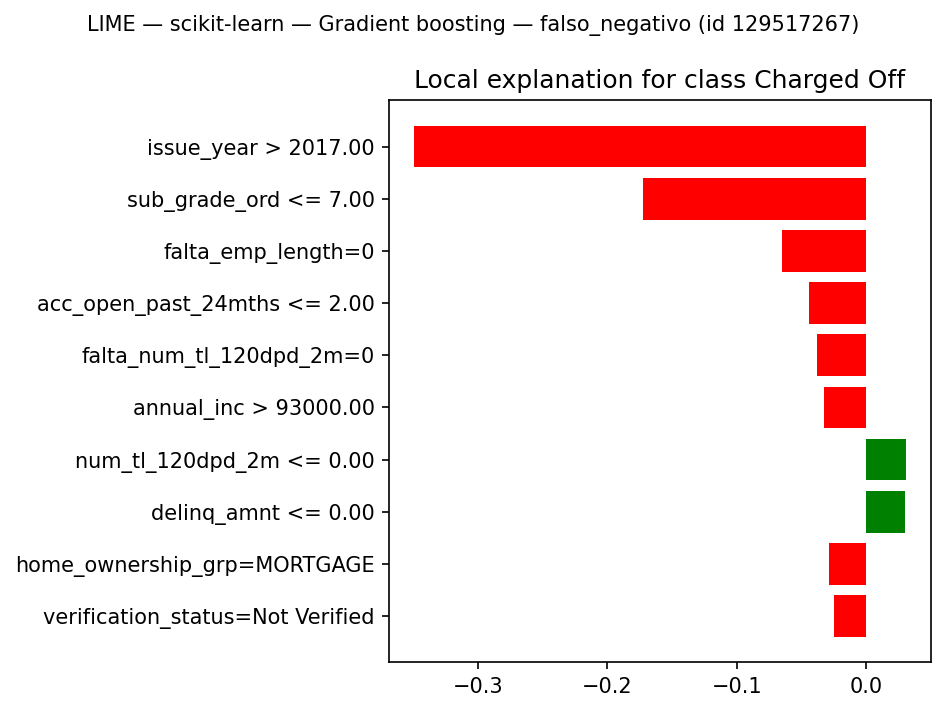

,condicion,peso
0,issue_year > 2017.00,-0.349351
1,sub_grade_ord <= 7.00,-0.172198
2,falta_emp_length=0,-0.064814
3,acc_open_past_24mths <= 2.00,-0.044211
4,falta_num_tl_120dpd_2m=0,-0.038141
5,annual_inc > 93000.00,-0.032246
6,num_tl_120dpd_2m <= 0.00,0.030673
7,delinq_amnt <= 0.00,0.030205
8,home_ownership_grp=MORTGAGE,-0.029092
9,verification_status=Not Verified,-0.024573


sklearn_gradient_boosting_falso_positivo_93750575.png


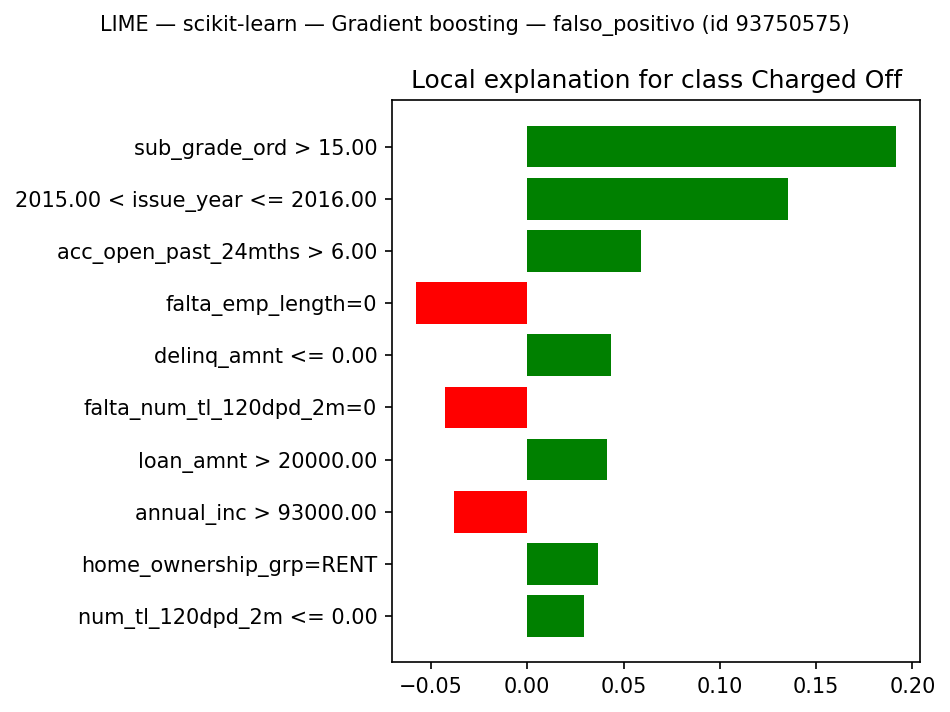

,condicion,peso
0,sub_grade_ord > 15.00,0.191611
1,2015.00 < issue_year <= 2016.00,0.135333
2,acc_open_past_24mths > 6.00,0.059269
3,falta_emp_length=0,-0.057825
4,delinq_amnt <= 0.00,0.043629
5,falta_num_tl_120dpd_2m=0,-0.042843
6,loan_amnt > 20000.00,0.041281
7,annual_inc > 93000.00,-0.038209
8,home_ownership_grp=RENT,0.036944
9,num_tl_120dpd_2m <= 0.00,0.029378


spark_gradient_boosting_falso_negativo_139794277.png


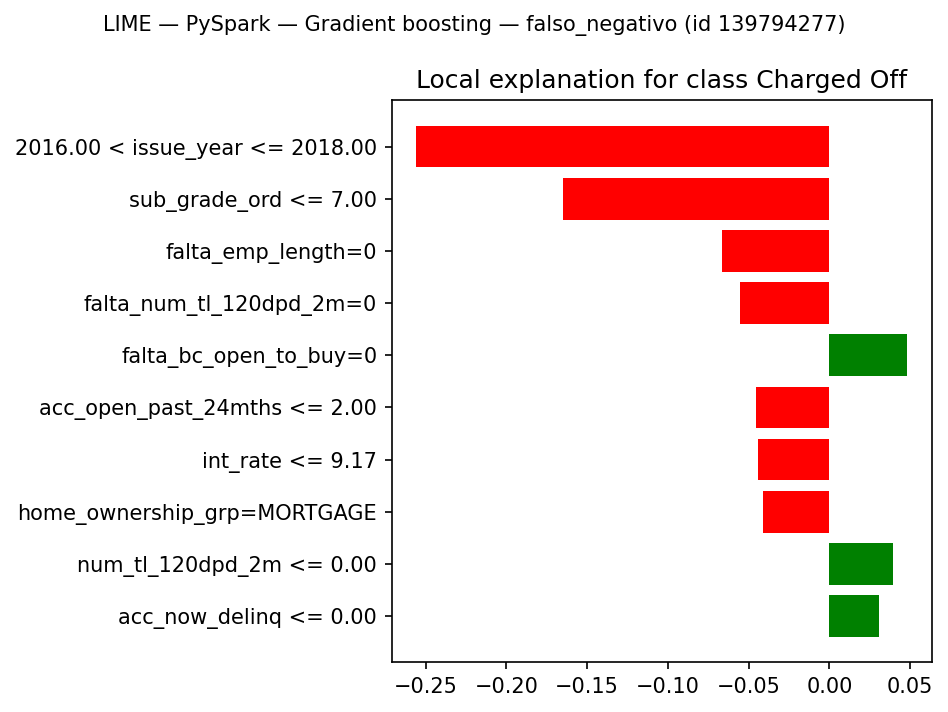

,condicion,peso
0,2016.00 < issue_year <= 2018.00,-0.255807
1,sub_grade_ord <= 7.00,-0.165011
2,falta_emp_length=0,-0.066438
3,falta_num_tl_120dpd_2m=0,-0.055105
4,falta_bc_open_to_buy=0,0.048264
5,acc_open_past_24mths <= 2.00,-0.045359
6,int_rate <= 9.17,-0.044277
7,home_ownership_grp=MORTGAGE,-0.040826
8,num_tl_120dpd_2m <= 0.00,0.039640
9,acc_now_delinq <= 0.00,0.030459


spark_gradient_boosting_falso_positivo_93750575.png


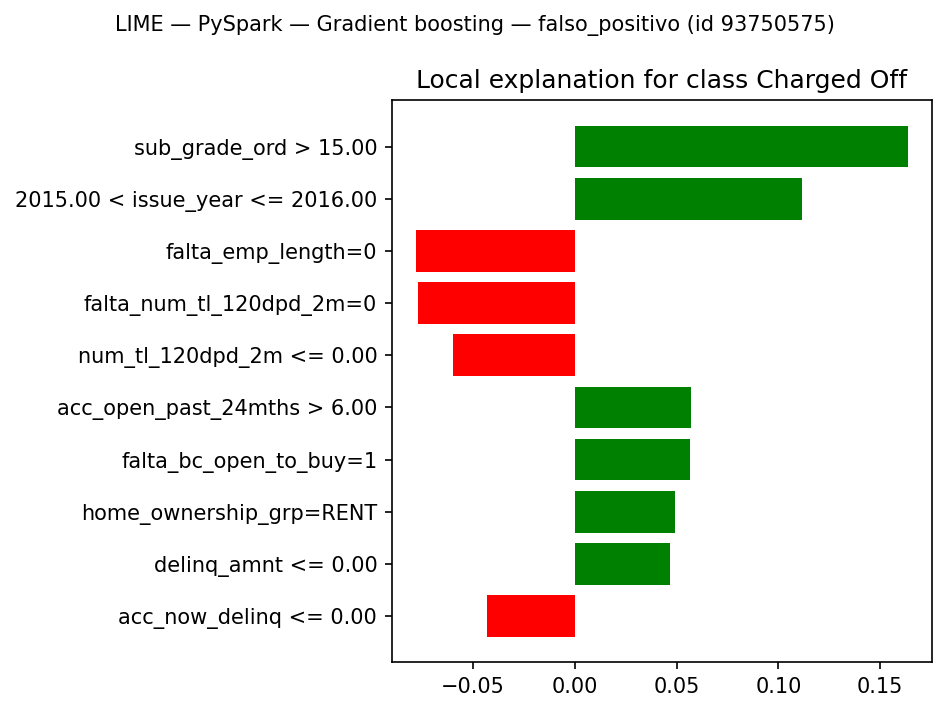

,condicion,peso
0,sub_grade_ord > 15.00,0.163499
1,2015.00 < issue_year <= 2016.00,0.111515
2,falta_emp_length=0,-0.077705
3,falta_num_tl_120dpd_2m=0,-0.077051
4,num_tl_120dpd_2m <= 0.00,-0.059908
5,acc_open_past_24mths > 6.00,0.057343
6,falta_bc_open_to_buy=1,0.056636
7,home_ownership_grp=RENT,0.049321
8,delinq_amnt <= 0.00,0.046903
9,acc_now_delinq <= 0.00,-0.042805


In [25]:
# ============================================================
# 9.10.4.7. INTERPRETABILIDAD CON LIME — resultados de ambos entornos
# ============================================================
# Las explicaciones se generan en los notebooks de scikit-learn y de PySpark (el modelo debe estar en memoria).
archivos_lime = sorted(DIR_LIME.glob("*.png"))
print(f"Explicaciones LIME encontradas: {len(archivos_lime)}")
for archivo in archivos_lime:
    print(archivo.name)
    display(Image(filename=str(archivo)))
    ruta_csv = archivo.with_suffix(".csv")
    if ruta_csv.exists():
        display(pd.read_csv(ruta_csv))


9.10.4.8 Comparación de resultados

,entorno,modelo,nombre,clase,mejores_parametros,accuracy,precision,recall,f1,roc_auc,auc_pr,auc_cv_mejor,umbral,roc_auc_local,auc_pr_local,t_preprocesamiento_s,t_entrenamiento_cv_s,t_prediccion_s,t_transferencia_s
0,scikit-learn,regresion_logistica,Regresión logística,LogisticRegression,"{""modelo__C"": 0.5529340338638921}",0.671080,0.219739,0.693402,0.333722,0.745598,0.262368,0.745257,0.5,0.745598,0.262368,33.747352,140.818683,0.851659,NaN
1,scikit-learn,arbol_decision,Árbol de decisión,DecisionTreeClassifier,"{""modelo__max_depth"": 10}",0.639631,0.213342,0.756702,0.332843,0.758172,0.276130,0.755836,0.5,0.758172,0.276130,33.747352,188.998513,0.960564,NaN
2,scikit-learn,bosque_aleatorio,Bosque aleatorio,RandomForestClassifier,"{""modelo__max_depth"": 15, ""modelo__n_estimator...",0.697988,0.234429,0.680704,0.348751,0.763073,0.287291,0.761850,0.5,0.763073,0.287291,33.747352,2181.395065,6.002041,NaN
3,scikit-learn,gradient_boosting,Gradient boosting,GradientBoostingClassifier,"{""modelo__max_depth"": 5, ""modelo__n_estimators...",0.658668,0.223588,0.757633,0.345280,0.772840,0.301657,0.772345,0.5,0.772840,0.301657,33.747352,6639.797674,1.776397,NaN
4,scikit-learn,svm_lineal,SVM lineal,LinearSVC,"{""modelo__C"": 0.05529340338638919}",0.658296,0.215762,0.712169,0.331186,0.745416,0.260978,0.745161,0.0,0.745416,0.260978,33.747352,1630.203191,0.778509,NaN
5,scikit-learn,naive_bayes,Naive Bayes,GaussianNB,{},0.624092,0.190150,0.664097,0.295647,0.680784,0.195336,0.682292,0.5,0.680784,0.195336,33.747352,34.781378,1.324747,NaN
6,PySpark,regresion_logistica,Regresión logística,LogisticRegression,"{""regParam"": 1e-06}",0.671075,0.219730,0.693365,0.333707,0.745600,0.262353,0.745274,0.5,0.745600,0.262375,89.355992,1245.494880,2.158528,0.463525
7,PySpark,arbol_decision,Árbol de decisión,DecisionTreeClassifier,"{""maxDepth"": 10}",0.649487,0.216569,0.745197,0.335604,0.756375,0.259709,0.754974,0.5,0.756375,0.267758,89.355992,725.355874,1.957567,0.506909
8,PySpark,bosque_aleatorio,Bosque aleatorio,RandomForestClassifier,"{""numTrees"": 100, ""maxDepth"": 15}",0.695258,0.233818,0.687463,0.348951,0.763514,0.287281,0.762359,0.5,0.763514,0.287308,89.355992,18169.299107,526.078343,257.966136
9,PySpark,gradient_boosting,Gradient boosting,GBTClassifier,"{""maxIter"": 100, ""maxDepth"": 5}",0.661706,0.224945,0.755529,0.346674,0.773511,0.302331,0.772867,0.5,0.773511,0.302357,89.355992,14671.817837,3.361107,0.700763


accuracy              precision                 recall  \
entorno               PySpark scikit-learn   PySpark scikit-learn   PySpark   
nombre                                                                        
Bosque aleatorio     0.695258     0.697988  0.233818     0.234429  0.687463   
Gradient boosting    0.661706     0.658668  0.224945     0.223588  0.755529   
Naive Bayes          0.624092     0.624092  0.190150     0.190150  0.664097   
Regresión logística  0.671075     0.671080  0.219730     0.219739  0.693365   
SVM lineal           0.658345     0.658296  0.215814     0.215762  0.712318   
Árbol de decisión    0.649487     0.639631  0.216569     0.213342  0.745197   

                                        f1              roc_auc_local  \
entorno             scikit-learn   PySpark scikit-learn       PySpark   
nombre                                                                  
Bosque aleatorio        0.680704  0.348951     0.348751      0.763514   
Gradient boosting       0.757633  0.346674     0.345280      0.773511   
Naive Bayes             0.664097  0.295647     0.295647      0.680782   
Regresión logística     0.693402  0.333707     0.333722      0.745600   
SVM lineal              0.712169  0.331264     0.331186      0.745414   
Árbol de decisión       0.756702  0.335604     0.332843      0.756375   

                                 t_entrenamiento_cv_s               \
entorno             scikit-learn              PySpark scikit-learn   
nombre                                                               
Bosque aleatorio        0.763073         18169.299107  2181.395065   
Gradient boosting       0.772840         14671.817837  6639.797674   
Naive Bayes             0.680784           119.431441    34.781378   
Regresión logística     0.745598          1245.494880   140.818683   
SVM lineal              0.745416          3941.797213  1630.203191   
Árbol de decisión       0.758172           725.355874   188.998513   

                    t_prediccion_s               
entorno                    PySpark scikit-learn  
nombre                                           
Bosque aleatorio        526.078343     6.002041  
Gradient boosting         3.361107     1.776397  
Naive Bayes               2.095203     1.324747  
Regresión logística       2.158528     0.851659  
SVM lineal                2.108085     0.778509  
Árbol de decisión         1.957567     0.960564

,sklearn,spark
entorno,sklearn,spark
sistema_operativo,Windows-10-10.0.26100-SP0,Windows-10-10.0.26100-SP0
procesador,"AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD","AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD"
python,3.9.25,3.9.25
nucleos_logicos,16,16
nucleos_fisicos,8,8
memoria_total_gb,31.87,31.87
memoria_disponible_gb,25.64,23.73
version_numpy,1.25.2,1.25.2
version_pandas,2.1.0,2.1.0


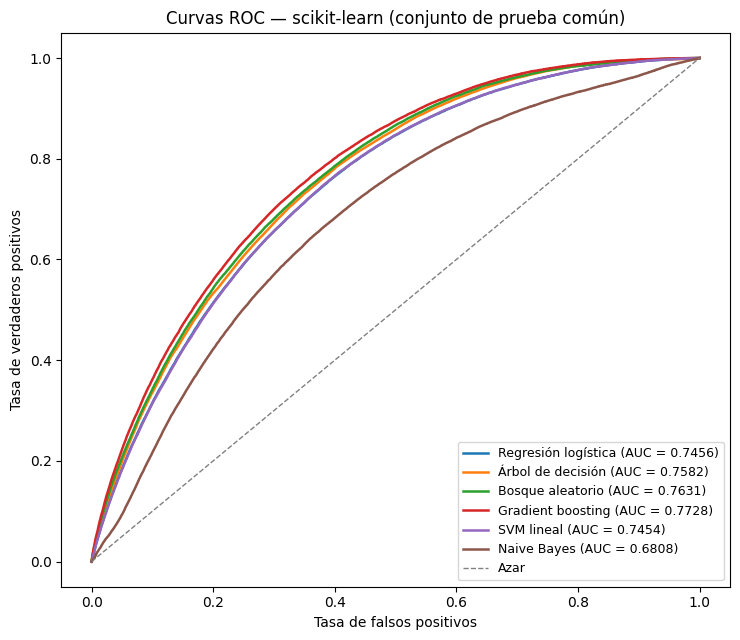

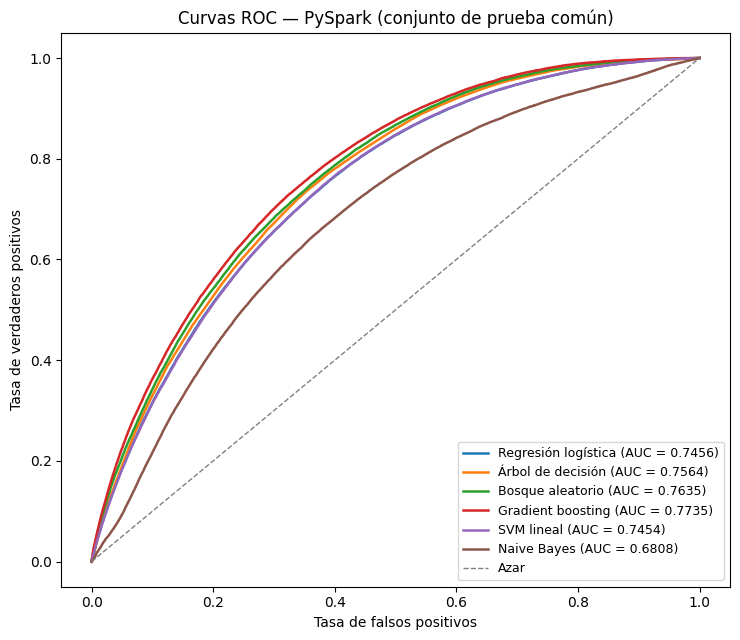

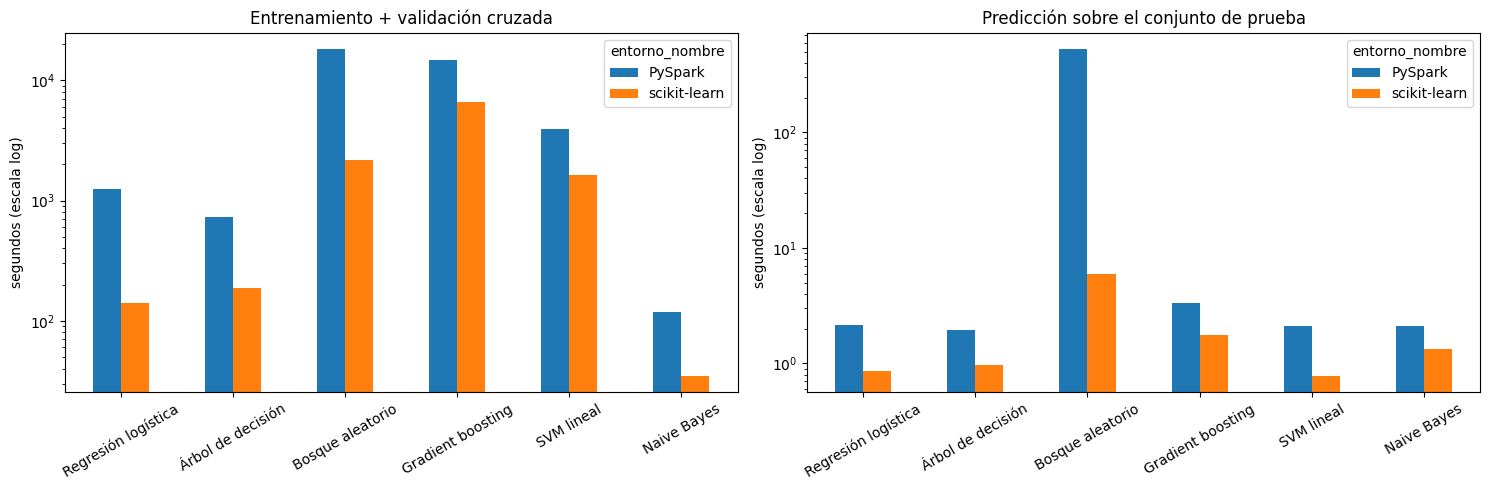

,preprocesamiento,entrenamiento_cv_total,prediccion_total,transferencia_total
entorno,,,,
scikit-learn,33.747352,10815.994503,11.693917,NaN
PySpark,89.355992,38873.196352,537.758832,260.27829


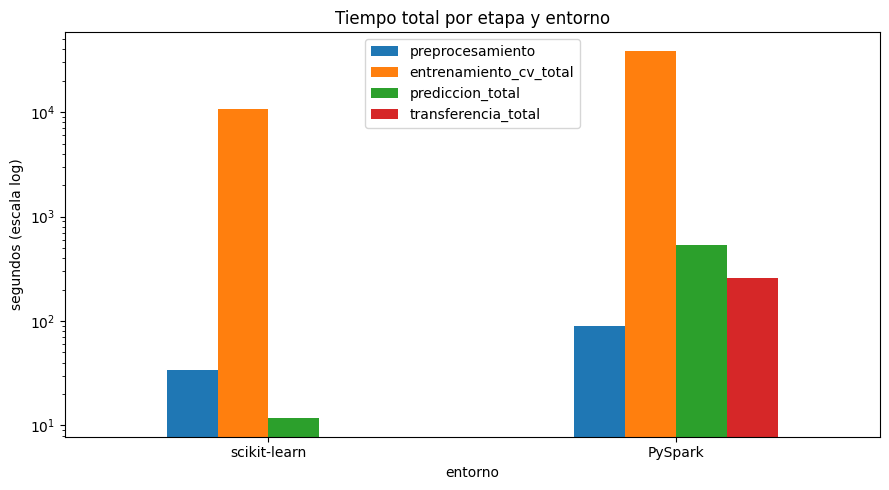

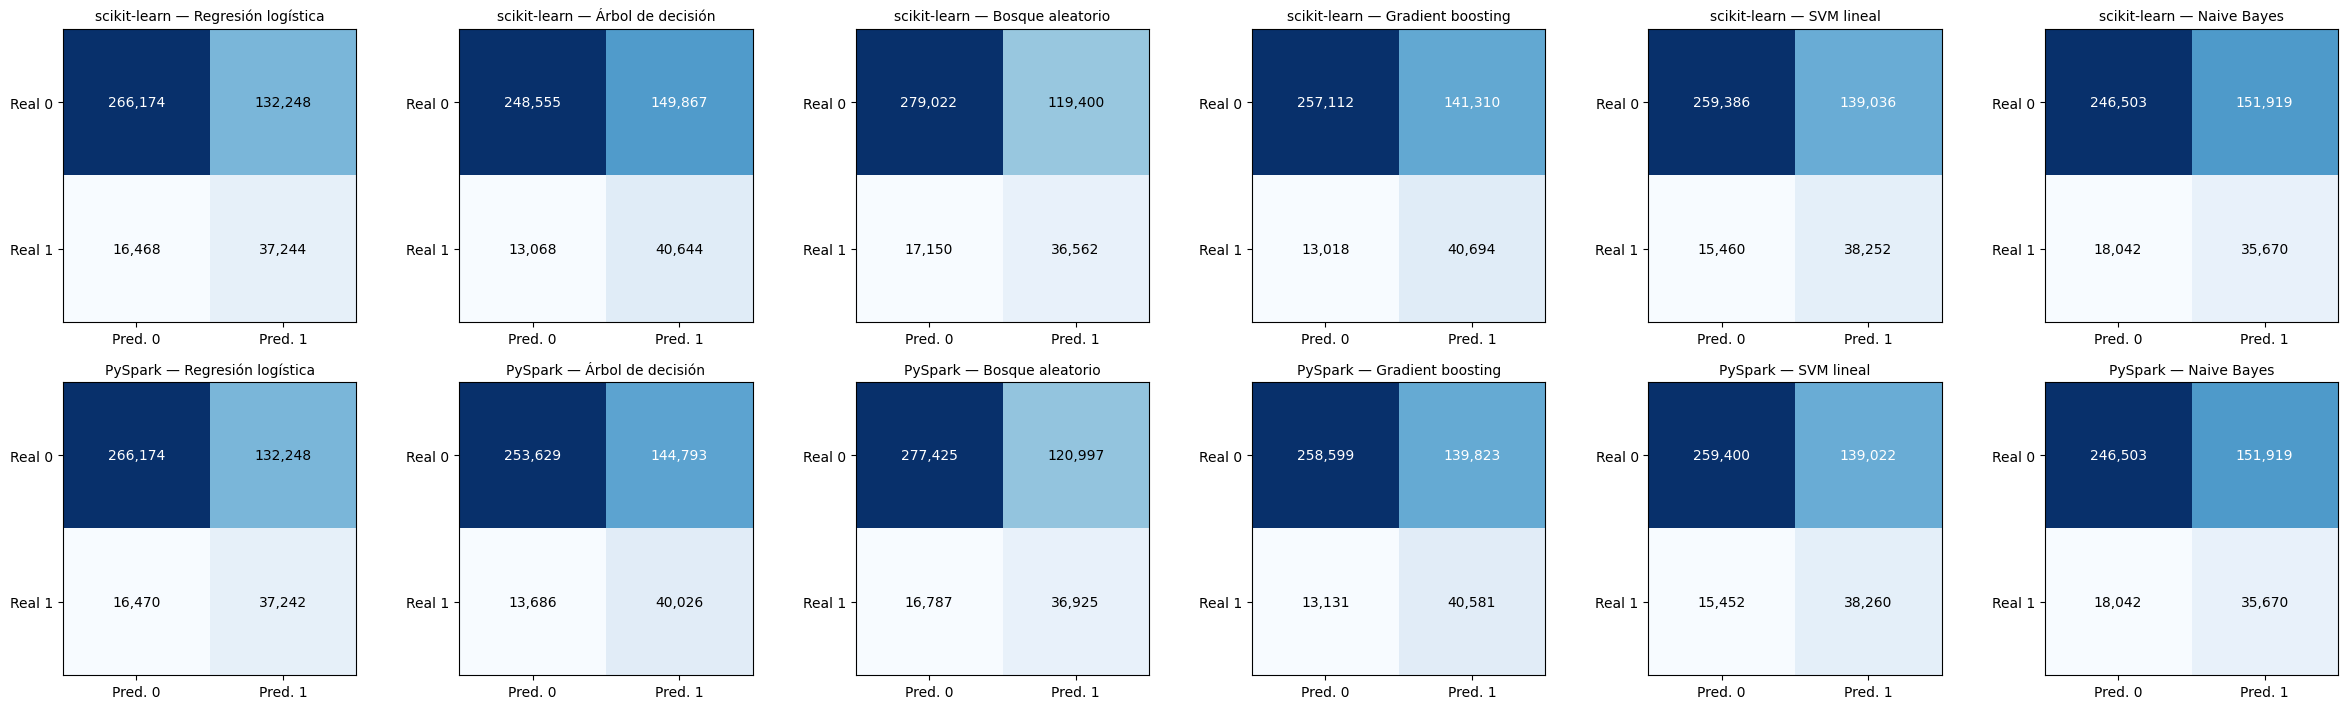

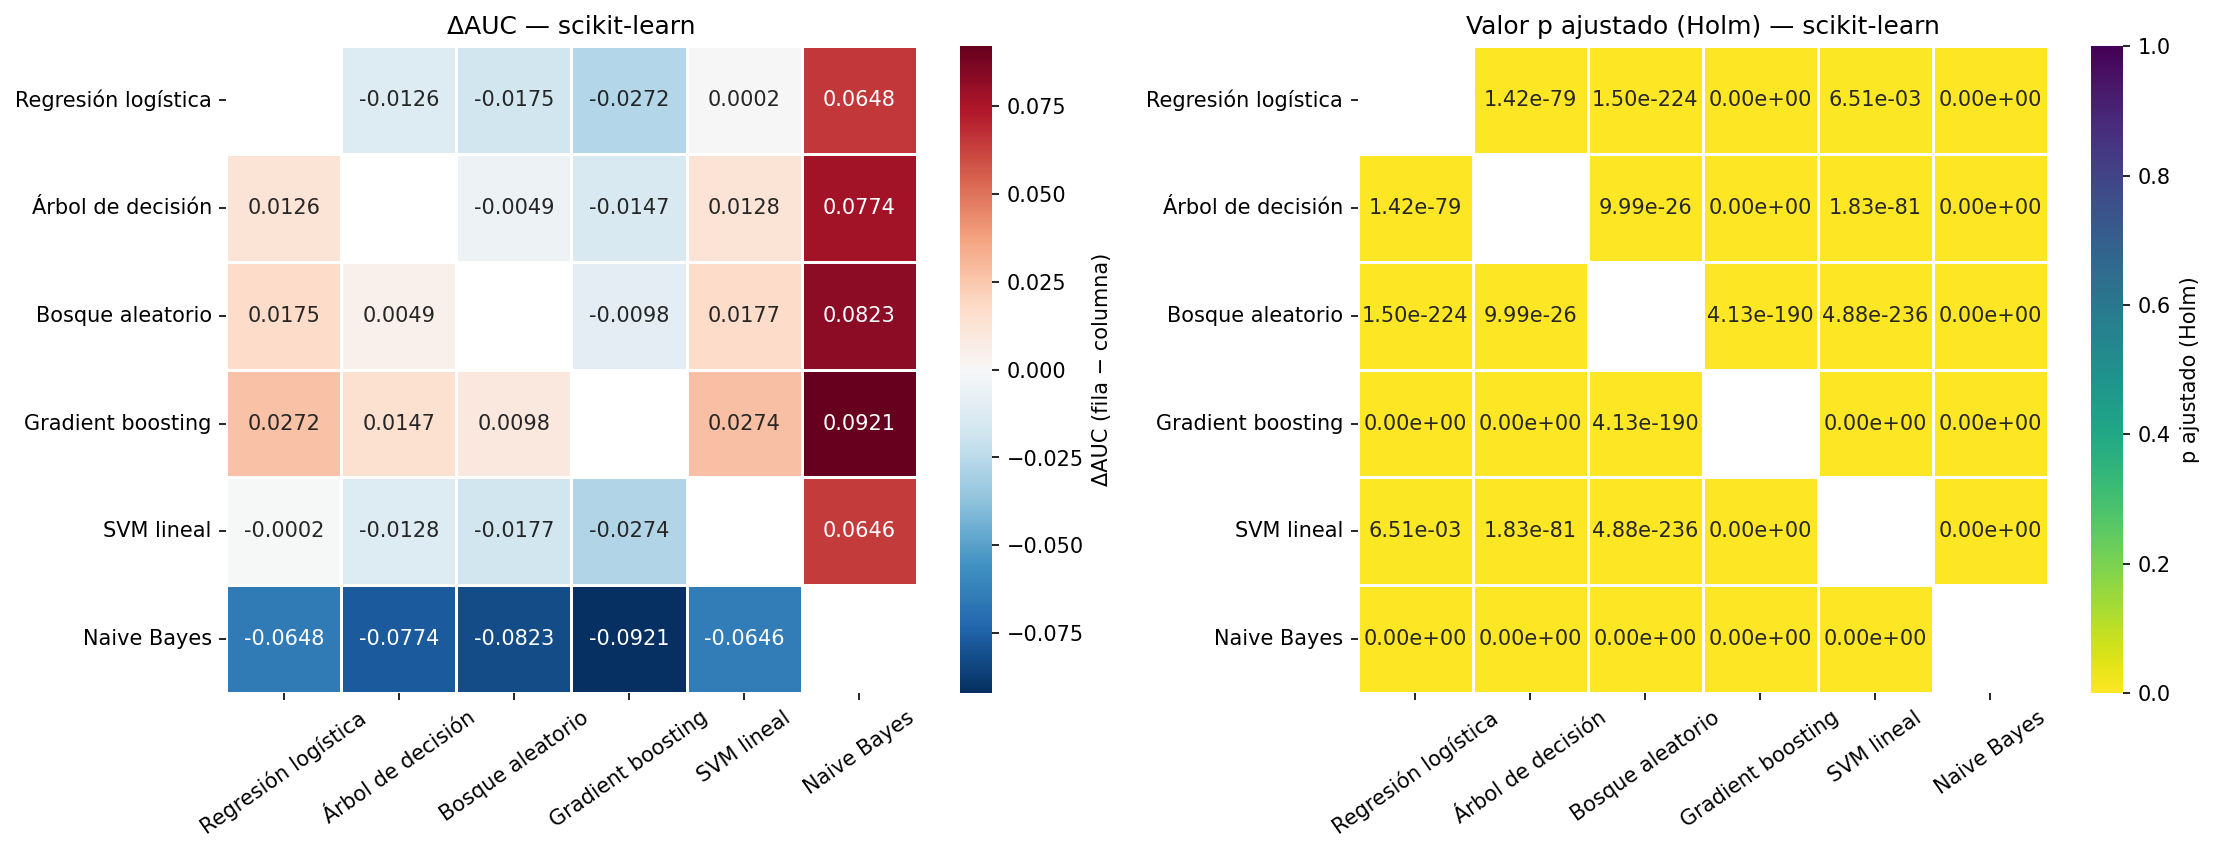

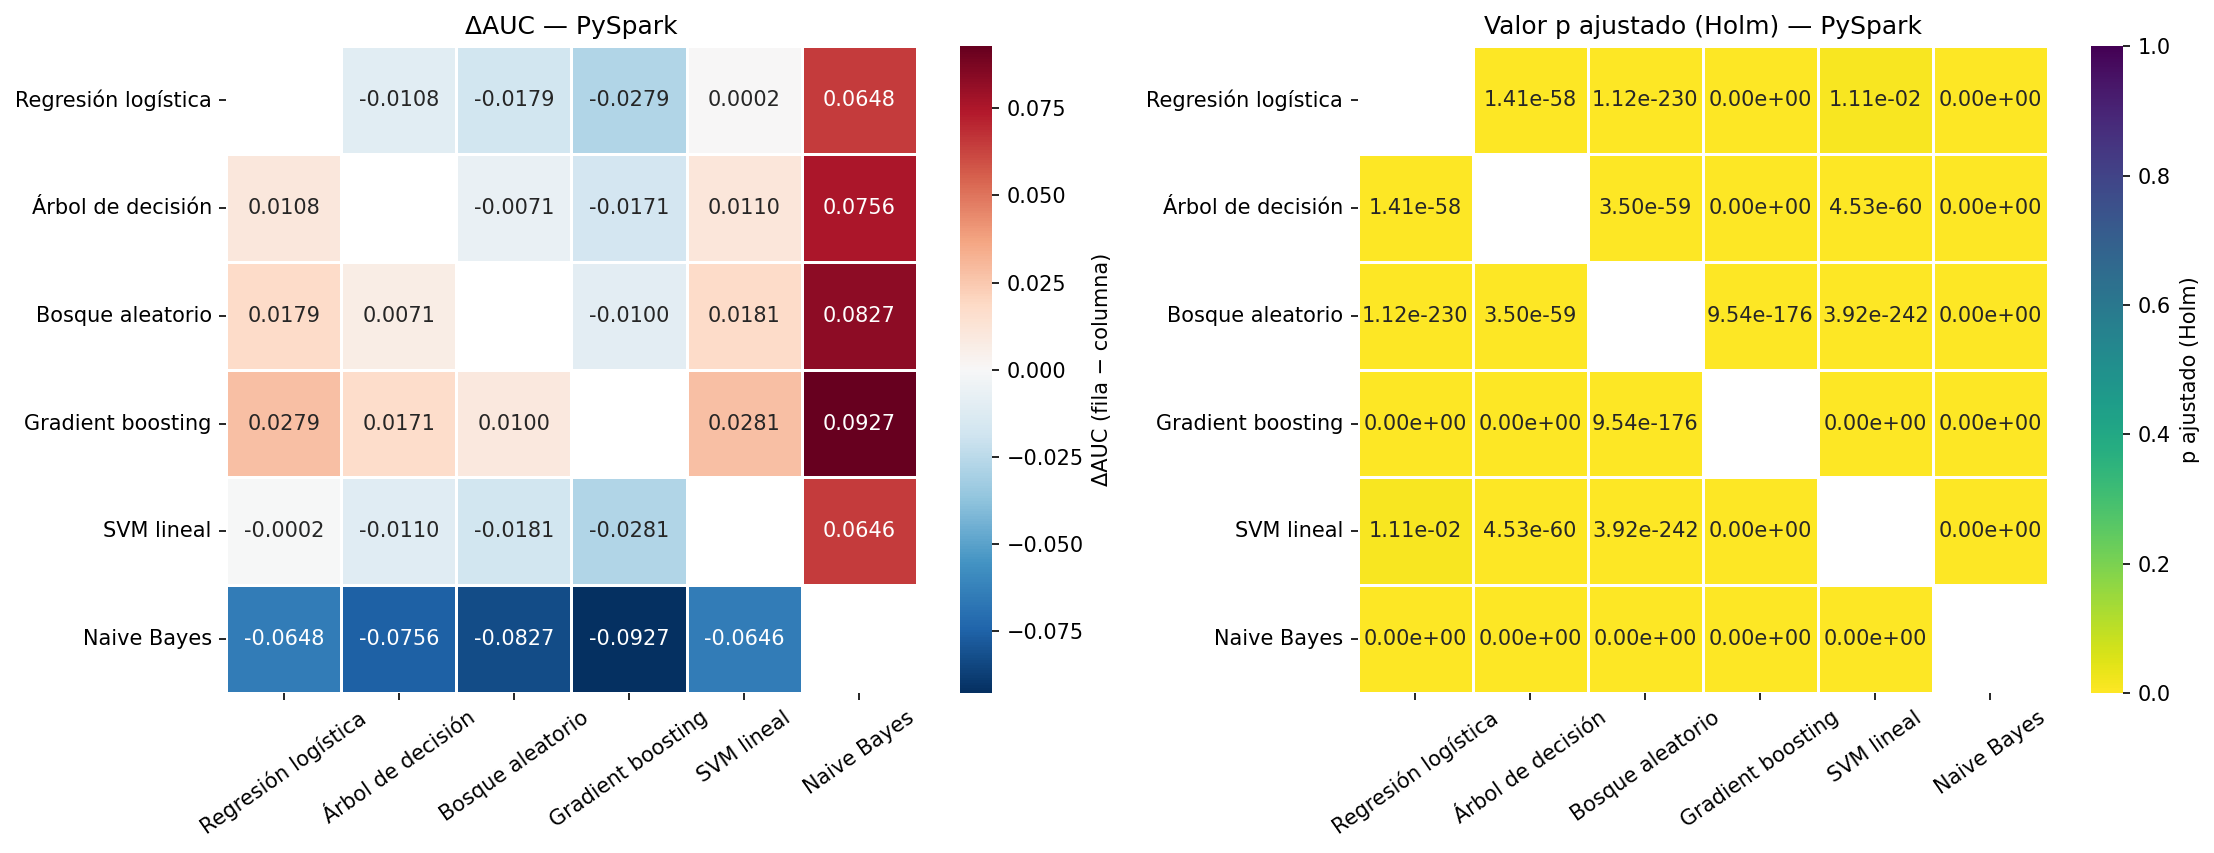

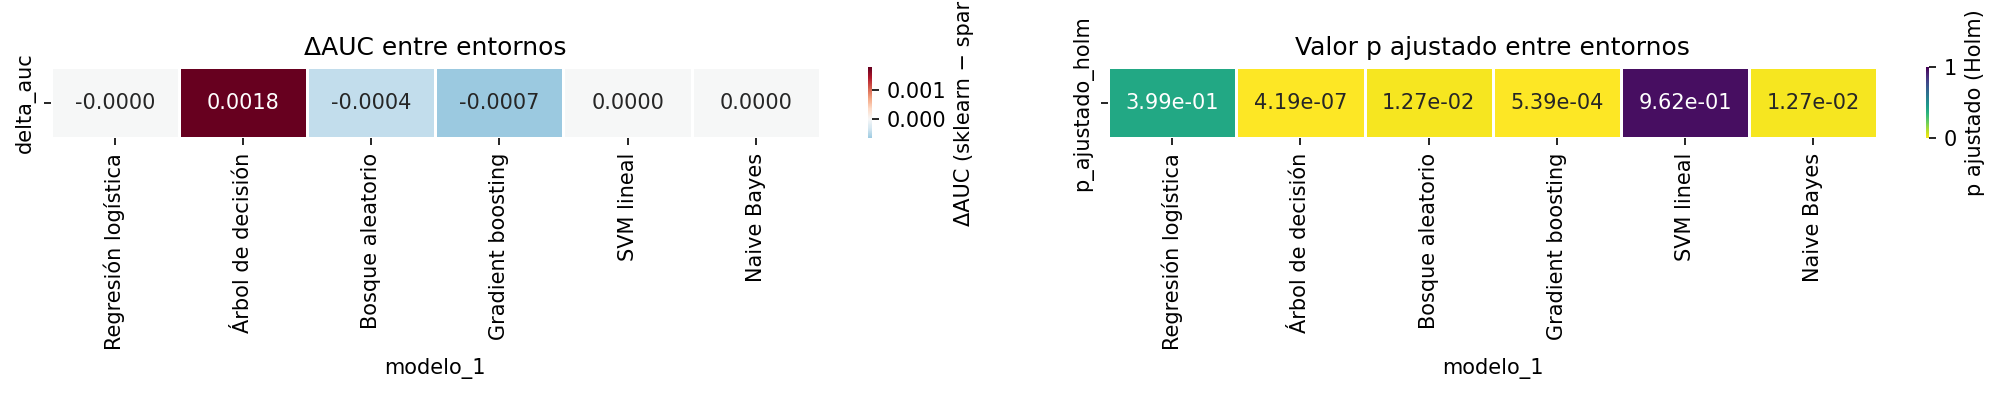

,comparacion,familia,entorno,modelo_1,modelo_2,DeLong ΔAUC,DeLong IC95%,DeLong p,DeLong p ajustado,McNemar p,...,Bootstrap ΔAUC,Bootstrap ΔAUC IC95%,Bootstrap ΔAUC-PR,Bootstrap ΔAUC-PR IC95%,Bootstrap ΔF1,Bootstrap ΔF1 IC95%,DeLong significativo,Bootstrap AUC: IC sin cero,DeLong y bootstrap coinciden (AUC),Relevante (|ΔAUC| ≥ margen)
0,Regresión logística: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Regresión logística,PySpark · Regresión logística,-0.000002,"[-0.00001, 0.00000]",1.995112e-01,3.990224e-01,8.936947e-01,...,-0.000002,"[-0.00001, 0.00000]",-0.000007,"[-0.00001, -0.00000]",0.000015,"[-0.00002, 0.00005]",False,False,True,False
1,Árbol de decisión: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Árbol de decisión,PySpark · Árbol de decisión,0.001797,"[0.00114, 0.00245]",6.983840e-08,4.190304e-07,6.152568e-159,...,0.001800,"[0.00113, 0.00241]",0.008391,"[0.00724, 0.00952]",-0.002758,"[-0.00363, -0.00191]",True,True,True,False
2,Bosque aleatorio: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Bosque aleatorio,PySpark · Bosque aleatorio,-0.000440,"[-0.00074, -0.00014]",3.748499e-03,1.268893e-02,7.339082e-24,...,-0.000448,"[-0.00074, -0.00015]",-0.000030,"[-0.00071, 0.00065]",-0.000205,"[-0.00097, 0.00061]",True,True,True,False
3,Gradient boosting: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Gradient boosting,PySpark · Gradient boosting,-0.000671,"[-0.00101, -0.00033]",1.078522e-04,5.392611e-04,4.543863e-24,...,-0.000670,"[-0.00101, -0.00032]",-0.000716,"[-0.00145, 0.00007]",-0.001384,"[-0.00214, -0.00060]",True,True,True,False
4,SVM lineal: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · SVM lineal,PySpark · SVM lineal,0.000002,"[-0.00009, 0.00009]",9.621992e-01,9.621992e-01,5.707504e-01,...,0.000001,"[-0.00009, 0.00009]",-0.000025,"[-0.00010, 0.00004]",-0.000078,"[-0.00028, 0.00013]",False,False,True,False
5,Naive Bayes: scikit-learn vs PySpark,A_entre_entornos,sklearn vs spark,scikit-learn · Naive Bayes,PySpark · Naive Bayes,0.000001,"[0.00000, 0.00000]",3.172232e-03,1.268893e-02,1.000000e+00,...,0.000001,"[0.00000, 0.00000]",0.000084,"[0.00003, 0.00014]",0.000000,"[0.00000, 0.00000]",True,True,True,False
6,Gradient boosting vs Bosque aleatorio (scikit-...,B_mejor_par_por_entorno,sklearn,scikit-learn · Gradient boosting,scikit-learn · Bosque aleatorio,0.009767,"[0.00912, 0.01042]",8.257270e-191,4.128635e-190,0.000000e+00,...,0.009762,"[0.00912, 0.01039]",0.014336,"[0.01268, 0.01596]",-0.003464,"[-0.00465, -0.00226]",True,True,True,True
7,Gradient boosting vs Bosque aleatorio (PySpark),B_mejor_par_por_entorno,spark,PySpark · Gradient boosting,PySpark · Bosque aleatorio,0.009997,"[0.00931, 0.01069]",1.907911e-176,9.539553e-176,0.000000e+00,...,0.009983,"[0.00928, 0.01068]",0.015022,"[0.01338, 0.01669]",-0.002286,"[-0.00354, -0.00106]",True,True,True,True


In [26]:
# ============================================================
# 9.10.4.8. COMPARACIÓN DE RESULTADOS
# ============================================================
metricas = pd.concat([pd.read_csv(RUTA_METRICAS_SK), pd.read_csv(RUTA_METRICAS_SPARK)], ignore_index=True)
tiempos = pd.concat([pd.read_csv(RUTA_TIEMPOS_SK), pd.read_csv(RUTA_TIEMPOS_SPARK)], ignore_index=True)
tiempos.to_csv(RUTA_TIEMPOS, index=False)

auc_local = pd.DataFrame([{"entorno": e, "modelo": m, "roc_auc_local": AUC_TEST[e][m],
                           "auc_pr_local": float(average_precision_score(Y_TEST, SCORES[e][m]))}
                          for e in ENTORNOS for m in MODELOS])
tabla_comparativa = (metricas[["entorno", "modelo", "nombre", "clase", "mejores_parametros", "accuracy", "precision",
                               "recall", "f1", "roc_auc", "auc_pr", "auc_cv_mejor", "umbral"]]
                     .merge(auc_local, on=["entorno", "modelo"])
                     .merge(tiempos, on=["entorno", "modelo"]))
tabla_comparativa["entorno"] = tabla_comparativa["entorno"].map(NOMBRE_ENTORNO)
tabla_comparativa.to_csv(RUTA_COMPARACION_METRICAS, index=False)
display(tabla_comparativa)

tabla_amplia = tabla_comparativa.pivot(index="nombre", columns="entorno",
                                       values=["accuracy", "precision", "recall", "f1", "roc_auc_local",
                                               "t_entrenamiento_cv_s", "t_prediccion_s"])
display(tabla_amplia)

hardware = {e: json.loads((DIR_RESULTADOS / f"hardware_{e}.json").read_text(encoding="utf-8")) for e in ENTORNOS}
display(pd.DataFrame(hardware).astype(str))


def plot_roc_curves(y_true, scores_por_modelo, titulo, ruta):
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    for m in MODELOS:
        fpr, tpr, _ = roc_curve(y_true, scores_por_modelo[m])
        ax.plot(fpr, tpr, linewidth=1.8, label=f"{NOMBRES_MODELOS[m]} (AUC = {roc_auc_score(y_true, scores_por_modelo[m]):.4f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Azar")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.set_title(titulo)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()


for e in ENTORNOS:
    plot_roc_curves(Y_TEST, SCORES[e], f"Curvas ROC — {NOMBRE_ENTORNO[e]} (conjunto de prueba común)",
                    DIR_FIGURAS / f"roc_{e}.png")

# Comparación de tiempos
tiempos_grafico = tiempos.assign(nombre=tiempos["modelo"].map(NOMBRES_MODELOS),
                                 entorno_nombre=tiempos["entorno"].map(NOMBRE_ENTORNO))
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
for ax, columna, titulo in [(ejes[0], "t_entrenamiento_cv_s", "Entrenamiento + validación cruzada"),
                            (ejes[1], "t_prediccion_s", "Predicción sobre el conjunto de prueba")]:
    pivote = tiempos_grafico.pivot(index="nombre", columns="entorno_nombre", values=columna).reindex(
        [NOMBRES_MODELOS[m] for m in MODELOS])
    pivote.plot(kind="bar", ax=ax, logy=True, rot=30)
    ax.set_ylabel("segundos (escala log)")
    ax.set_xlabel("")
    ax.set_title(titulo)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "tiempos_por_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

resumen_tiempos = pd.DataFrame({
    "preprocesamiento": tiempos.groupby("entorno")["t_preprocesamiento_s"].first(),
    "entrenamiento_cv_total": tiempos.groupby("entorno")["t_entrenamiento_cv_s"].sum(),
    "prediccion_total": tiempos.groupby("entorno")["t_prediccion_s"].sum(),
    "transferencia_total": tiempos.groupby("entorno")["t_transferencia_s"].sum(min_count=1),
}).rename(index=NOMBRE_ENTORNO)
display(resumen_tiempos)
resumen_tiempos.to_csv(DIR_RESULTADOS / "timing_summary.csv")
resumen_tiempos.plot(kind="bar", figsize=(9, 5), rot=0, logy=True)
plt.ylabel("segundos (escala log)")
plt.title("Tiempo total por etapa y entorno")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "tiempos_por_etapa.png", dpi=150, bbox_inches="tight")
plt.show()

# Matrices de confusión de ambos entornos
fig, ejes = plt.subplots(2, len(MODELOS), figsize=(4 * len(MODELOS), 7.2))
for i, e in enumerate(ENTORNOS):
    for j, m in enumerate(MODELOS):
        fila = metricas[(metricas["entorno"] == e) & (metricas["modelo"] == m)].iloc[0]
        plot_confusion_matrix(fila["tn"], fila["fp"], fila["fn"], fila["tp"],
                              f"{NOMBRE_ENTORNO[e]} — {NOMBRES_MODELOS[m]}", ax=ejes[i, j])
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "confusion_ambos_entornos.png", dpi=150, bbox_inches="tight")
plt.show()

# Mapas de calor de DeLong
for archivo in ["delong_heatmap_sklearn.png", "delong_heatmap_spark.png", "delong_heatmap_entre_entornos.png"]:
    display(Image(filename=str(DIR_FIGURAS / archivo)))

display(comparacion_estadistica)


## CONCLUSIONES

## Análisis general de los modelos

El mejor modelo en los dos entornos fue gradient boosting: AUC de 0.7728 en scikit-learn y 0.7735 en PySpark, con un AUC-PR cercano a 0.30. Le siguen el bosque aleatorio (≈0.763), el árbol de decisión (≈0.757), la regresión logística y el SVM lineal, que quedaron prácticamente empatados (≈0.7455), y al final Naive Bayes (0.681). Ningún modelo pasa de 0.78, y creemos que eso refleja lo difícil del problema más que una mala configuración: con la información disponible al momento de la solicitud, predecir el incumplimiento tiene un techo.

Con el umbral fijo de 0.5 y los pesos por clase, todos los modelos tienen un recall alto (0.66–0.76) pero una precisión baja (≈0.22). Es decir, detectan la mayoría de los incumplimientos a costa de muchos falsos positivos.

Cada modelo tiene su uso:

Gradient boosting es el más útil para ordenar solicitudes por riesgo (scoring).
Bosque aleatorio tiene la mejor exactitud y el mejor F1 con el umbral de 0.5, así que sirve si lo que importa es la decisión de aprobar o rechazar.
Regresión logística queda solo 0.027 de AUC por debajo del gradient boosting, es la más rápida de entrenar y es interpretable, lo que en crédito pesa mucho por temas regulatorios.
Árbol de decisión da reglas fáciles de explicar, pero es inestable: con profundidad 15 se sobreajustó en ambos entornos (AUC en validación cruzada de 0.72).
SVM lineal no aporta nada sobre la logística: rinde igual, tarda más y no entrega probabilidades.
Naive Bayes sirve como línea base. Queda muy abajo porque su supuesto de independencia no se cumple: variables como int_rate y sub_grade están muy correlacionadas.
Problemas durante la ejecución. En scikit-learn, el GridSearchCV del bosque aleatorio con n_jobs=-1 se detuvo por MemoryError. Cada proceso en paralelo trabaja con su propia copia de los datos de entrenamiento (≈1.8 M de filas), y con 16 procesos la RAM de 32 GB no alcanzó, así que se bajó a n_jobs=3.

En PySpark también hubo problemas de memoria. El árbol de decisión tumbó la JVM y el bosque aleatorio falló con java.lang.OutOfMemoryError: Java heap space al deserializar el modelo (100 árboles de profundidad 15). En modo local todo corre en el proceso del driver, así que spark.executor.memory no tiene ningún efecto. Por eso:

se subió spark.driver.memory de 8 GB a 14 GB y luego a 18 GB;
se limitó el paralelismo a local[8];
se bajó maxMemoryInMB de los árboles a 256.
La regresión logística y el árbol se entrenaron antes de ese último cambio, así que sus tiempos no se midieron exactamente con la misma configuración que los demás.

Para futuras iteraciones el grupo usará computadores disponibles en el bloque K piso 3 con mayor potencia.

## ¿Qué entorno fue más rápido y por qué?

scikit-learn fue claramente más rápido. La validación cruzada de todos los modelos tomó unas 3.0 horas (10,816 s), contra 10.8 horas (38,873 s) en PySpark, o sea unas 3.6 veces más. También fue más rápido en el preprocesamiento (34 s contra 89 s) y en la predicción (12 s contra 538 s).

La razón principal es que PySpark corrió en una sola máquina y no había ningún clúster sobre el cual repartir el trabajo. Así, solo pagamos los costos de Spark: el arranque de la JVM, la comunicación entre Python y Java (Py4J), la serialización de datos y de modelos, y la planificación de tareas. Además, las 400 particiones que exige la configuración son muchas para 8 núcleos: quedan tareas muy pequeñas y cada iteración paga el costo de planificarlas. Por eso la regresión logística, que recorre los datos muchas veces, fue 8.8 veces más lenta en Spark.

El caché ayudó: sin él, cada pliegue y cada iteración habría vuelto a leer y transformar el CSV. Aun así, no alcanzó para compensar lo demás.

El CrossValidator multiplica el costo, porque cada combinación de la grilla se entrena 3 veces y al final se reentrena el mejor modelo. Con 9 combinaciones, el bosque aleatorio necesitó 28 entrenamientos. Por eso fue el más lento en Spark (5 horas), y en la predicción se sumaron otros 526 s por el tamaño del modelo.

La brecha más pequeña se dio en gradient boosting (2.2 veces) y SVM (2.4 veces). El GradientBoostingClassifier de scikit-learn construye cada árbol con un solo núcleo, mientras que Spark reparte el cálculo de los histogramas entre los 8 núcleos. Cuando scikit-learn no puede paralelizar, Spark se acerca bastante.

## ¿Cuál fue más preciso?

En la práctica ninguno. Las AUC de los dos entornos coinciden hasta la tercera o cuarta cifra decimal en todos los modelos. PySpark quedó levemente arriba en gradient boosting (+0.0007) y en el bosque (+0.0004), y scikit-learn en el árbol de decisión (+0.0018).

Donde sí hay diferencias es entre modelos: gradient boosting es el más preciso en ambos entornos para el AUC y el AUC-PR, y el bosque aleatorio lo es para el F1 y la exactitud con el umbral de 0.5.

## ¿Qué diferencias en el AUC son significativas y cuáles son relevantes?

Entre entornos. Después de la corrección de Holm, DeLong encontró diferencias significativas en el árbol, el bosque, gradient boosting y Naive Bayes. La logística y el SVM no fueron significativas. Pero ninguna de estas diferencias es relevante en la práctica: la más grande es la del árbol (0.0018), y el margen que fijamos es de 0.005. La de Naive Bayes es de 0.0000012 y aun así salió significativa, lo que muestra que con 452 mil observaciones de prueba casi cualquier diferencia termina siendo "significativa".

Entre modelos. Casi todas las diferencias son significativas y relevantes. Las excepciones son:

logística contra SVM (0.0002): significativa pero sin importancia práctica;
árbol contra bosque en scikit-learn (0.0049): queda justo por debajo del margen, aunque en Spark sí lo supera (0.0071).
La diferencia entre gradient boosting y el bosque (≈0.010) es significativa y relevante en los dos entornos.

## ¿Qué diferencias de implementación explican las discrepancias?

Árboles. Spark discretiza las variables continuas en maxBins=32 intervalos antes de buscar los cortes, mientras que scikit-learn evalúa todos los cortes posibles. Eso explica que el árbol individual de scikit-learn sea algo mejor (+0.0018 de AUC y +0.008 de AUC-PR). También explica que, aunque el AUC casi no cambie, los dos árboles clasifiquen distinto 27,506 préstamos (6 % del conjunto de prueba).

En los ensambles pasa lo contrario: Spark queda un poco arriba. Creemos que al promediar muchos árboles, la pérdida por discretizar se compensa e incluso funciona como una regularización. También hay diferencias de fondo:

en el bosque, Spark hace el muestreo bootstrap con una distribución de Poisson;
en el boosting, scikit-learn ajusta el valor de cada hoja con un paso de Newton, que Spark no hace.
LinearSVC. scikit-learn usa por defecto la pérdida hinge al cuadrado con liblinear, y además penaliza el intercepto. Spark usa la pérdida hinge estándar con el optimizador OWL-QN. Aun así, las AUC quedaron iguales (diferencia de 0.000002) y McNemar no encontró diferencias, así que en este caso la función de pérdida no se tradujo en ninguna discrepancia. En scikit-learn además apareció un ConvergenceWarning con max_iter=1000.

Regularización. Pusimos las dos grillas en la misma escala con la equivalencia C = 1/(λ·n), y los dos entornos eligieron valores equivalentes: C = 0.553 ↔ λ = 10⁻⁶ en la logística, y C = 0.055 ↔ λ = 10⁻⁵ en el SVM. Las grillas salieron casi planas: con 1.8 millones de filas, la regularización casi no cambia nada.

Naive Bayes. Dio predicciones idénticas en los dos entornos, sin ningún préstamo discordante. La diferencia mínima en el AUC es solo numérica.

## Limitaciones de DeLong y complemento con McNemar y bootstrap

DeLong tiene varias limitaciones en este diseño:

Solo mide la variabilidad del conjunto de prueba, que es uno solo. No incluye la variabilidad del entrenamiento (la semilla, la partición o los pliegues), así que subestima la incertidumbre real al comparar dos entornos.
Con n = 452 mil tiene tanta potencia que diferencias de 10⁻⁶ salen significativas. Por eso fue necesario el margen de relevancia.
Solo compara el AUC, es decir, la capacidad de ordenar, y no dice nada de las decisiones con un umbral.
Con tantas comparaciones, hay que corregir por multiplicidad.
McNemar complementa lo último, porque compara los aciertos y errores con el umbral fijo. Ahí apareció algo que el AUC no muestra: entre gradient boosting y el bosque, el bosque acierta en 27,921 casos donde gradient boosting falla, y lo contrario ocurre en solo 10,143. Así, gradient boosting ordena mejor el riesgo, pero con el umbral de 0.5 el bosque clasifica mejor. El bootstrap pareado lo confirma con el F1: la diferencia es negativa para gradient boosting.

El bootstrap además es no paramétrico y da intervalos para el AUC, el AUC-PR y el F1.

¿Coinciden las tres pruebas? Para el AUC, DeLong y bootstrap coincidieron en las 8 comparaciones. McNemar coincide en la significancia entre entornos, excepto en Naive Bayes (DeLong es significativo, pero no hay ni un solo préstamo discordante). Entre gradient boosting y el bosque, las tres pruebas dan significativo, pero no apuntan en la misma dirección.

## ¿A partir de qué volumen de datos PySpark supera a scikit-learn?

Con nuestro experimento no lo podemos determinar, porque solo medimos los tiempos con el volumen completo. Con 2.26 millones de préstamos en una sola máquina de 16 hilos y 32 GB, scikit-learn fue más rápido en todos los modelos.

En modo local, lo que decide no es tanto el número de filas sino la memoria. Spark empieza a tener ventaja cuando los datos (más las copias que hace cada proceso) ya no caben en la RAM de un equipo, o cuando hay un clúster real. El MemoryError con n_jobs=-1 muestra que ya estábamos cerca de ese límite para scikit-learn. La brecha más chica en gradient boosting también sugiere que la ventaja de Spark aparecería primero en los modelos que scikit-learn no puede paralelizar.

## ¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?

LIME permitió revisar casos puntuales de gradient boosting y ver que los dos entornos se apoyan en las mismas variables. Para el mismo falso positivo (préstamo 93750575), en los dos pesan sobre todo sub_grade_ord > 15 y que el año de emisión esté entre 2015 y 2016.

También dejó ver algo importante: issue_year > 2017 empuja mucho hacia "no incumple". Eso se debe a que muchos préstamos recientes seguían vigentes y la regla del target los cuenta como 0. Es un efecto de censura, no una relación real, y sin LIME no lo habríamos notado.

Sus limitaciones:

Es local e inestable: depende del muestreo aleatorio y del ancho del kernel.
Perturba cada variable por separado, sin tener en cuenta que están correlacionadas.
En Spark no es distribuido: tuvimos que traer al driver una muestra de 5,000 filas, y cada llamada a la función de predicción crea un DataFrame de Spark con las perturbaciones, lo que es lento.
Explicar muchos casos en Spark no escala.

## ¿Qué efecto tuvo cada condición obligatoria en el rendimiento?

400 particiones de shuffle y paralelismo por defecto de 400. Para 8 núcleos generan muchas tareas pequeñas. Probablemente es la causa principal de la lentitud de la logística y el SVM, que recorren los datos muchas veces. No hicimos una prueba aislada de este efecto, así que es una inferencia.
spark.executor.memory = 8 GB. No tuvo ningún efecto en modo local. Los 8 GB del driver no alcanzaron y hubo que subirlos a 18 GB para los árboles.
memory.fraction 0.8 y storageFraction 0.3. Dejan la mayor parte de la memoria para ejecución, lo que ayuda a los árboles. Lo que no cabe en el caché se va a disco (MEMORY_AND_DISK).
Caché después del VectorAssembler. Fue la condición que más ayudó, porque evitó releer y transformar el CSV en cada pliegue y en cada iteración.
Validación cruzada con 3 pliegues y misma partición en ambos entornos. Multiplicaron el costo de entrenamiento entre 4 y 28 veces según la grilla, pero hicieron que las comparaciones fueran justas: los dos entornos se evaluaron sobre exactamente los mismos 452,134 préstamos de prueba.
La población "completa" que pide la regla del target dejó más observaciones de prueba que las "unas 260 mil" del enunciado. Eso aumenta los tiempos y hace que las pruebas sean todavía más sensibles.